In [1]:
from pathlib import Path as path_cls
import gc
import importlib.metadata as metadata
import json
import platform
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.dataset as ds
import pyarrow.parquet as pq
from cycler import cycler
from IPython.display import display

from quantfinlab.backtest.portfolio import (
    run_many_weights_backtests, run_strategy_backtest,
)
from quantfinlab.dataio import load_par_yield_curve, risk_free_returns
from quantfinlab.dataio.panel import prices_to_returns_panel as price_returns
from quantfinlab.ml.evaluation import forecast_buckets, rank_metrics, rolling_rank_ic
from quantfinlab.plotting import portfolio as portfolio_plots
from quantfinlab.portfolio import covariance, expected_returns, optimizers, selection
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.hrp import hrp_weight_frame, nco_mv_weight_frame
from quantfinlab.portfolio.risk_parity import risk_parity_weight_frame
from quantfinlab.portfolio.robust import wasserstein_weight_frame
from quantfinlab.portfolio.walkforward import (
    run_equal_weight_walkforward, run_walkforward_grid,
)
from quantfinlab.reports.risk_report import risk_report

palette = ["#069AF3", "#FE420F", "#00008B", "#008080", "#CC79A7",
           "#9614fa", "#DC143C", "#7BC8F6", "#0072B2", "#04D8B2",
           "#800080", "#FF8072"]
plt.rcParams["axes.prop_cycle"] = cycler(color=palette)
plt.rcParams.update({
    "figure.figsize": (6, 3),
    "figure.dpi": 200,
    "savefig.dpi": 300,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 7,
})
colors = palette
blue, gold, navy, teal, pink, coral, violet = colors[:7]
ink = navy
muted = "0.40"
grid = "0.85"

def finish_axes(ax, axis="y"):
    ax.set_axisbelow(True)
    ax.margins(x=0.01)
    return ax

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 40)

project_title = "Project 21 — Fundamental Analysis and Equity Selection"
print(project_title)
print({"python": platform.python_version(), "pandas": pd.__version__,
       "numpy": np.__version__, "pyarrow": pa.__version__,
       "quantfinlab": metadata.version("quantfinlab")})

Project 21 — Fundamental Analysis and Equity Selection
{'python': '3.11.0', 'pandas': '3.0.0', 'numpy': '2.4.2', 'pyarrow': '23.0.0', 'quantfinlab': '0.0.1'}


In [2]:
repo_root = path_cls.cwd()
if not (repo_root / "data" / "sp500_market_data.parquet").exists():
    repo_root = repo_root.parent

market_path = repo_root / "data" / "sp500_market_data.parquet"
fundamentals_path = repo_root / "data" / "sp500_fundamentals.parquet"
treasury_path = repo_root / "data" / "us_treasury_yields.csv"
treasury_curve = load_par_yield_curve(treasury_path, source="us_treasury")
output_dir = repo_root / "data" / "datasets" / "project21"
output_dir.mkdir(parents=True, exist_ok=True)

warmup_start = pd.Timestamp("2012-01-01")
backtest_start = pd.Timestamp("2013-01-01")
annualization = 252.0
top_n_values = (15, 50, 100)
cov_lookback = 189
mu_lookback = 189
min_model_obs = 177
max_weight = 0.20
mv_lambda = 10.0
cost_bps = 10.0
turnover_penalty_bps = 10.0
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)

reports = sorted(
    list(repo_root.glob("sp500_point_in_time_datasets_report*.md"))
    + list((repo_root / "workspace").glob("sp500_point_in_time_datasets_report*.md")),
    key=lambda path: path.stat().st_mtime,
)
handoff_path = reports[-1]
handoff_text = handoff_path.read_text(encoding="utf-8")

market_parquet = pq.ParquetFile(market_path)
fundamentals_parquet = pq.ParquetFile(fundamentals_path)
market_meta = {key.decode(): value.decode() for key, value in market_parquet.schema_arrow.metadata.items()}
fundamentals_meta = {key.decode(): value.decode() for key, value in fundamentals_parquet.schema_arrow.metadata.items()}
market_validation = json.loads(market_meta["validation"])
market_sec_validation = json.loads(market_meta["sec_enrichment_validation"])
fundamentals_validation = json.loads(fundamentals_meta["validation"])
assert market_validation["status"] == "pass"
assert market_sec_validation["status"] == "pass"
assert fundamentals_validation["status"] == "pass"

market_columns = [
    "date", "ticker", "adj_close", "close", "volume",
    "is_sp500_member", "industry", "market_cap",
]
market = pq.read_table(
    market_path,
    columns=market_columns,
    filters=[("date", ">=", warmup_start)],
).to_pandas()
market["date"] = pd.to_datetime(market["date"])
market = market.sort_values(["date", "ticker"]).reset_index(drop=True)

build_summary = pd.DataFrame({
    "value": [
        handoff_path.name,
        f"{market_parquet.metadata.num_rows:,}",
        f"{fundamentals_parquet.metadata.num_rows:,}",
        market_validation["status"],
        market_sec_validation["status"],
        fundamentals_validation["status"],
        f"3-month Treasury · latest {treasury_curve['3M'].last_valid_index():%Y-%m-%d}",        str(output_dir.relative_to(repo_root)),
    ]
}, index=[
    "data handoff", "market rows", "fundamental rows", "market validation",
    "SEC enrichment validation", "fundamental validation", "risk-free rate", "output folder",
])
display(build_summary)

,value
data handoff,sp500_point_in_time_datasets_report.md
market rows,"3,223,459"
fundamental rows,"13,528,328"
market validation,pass
SEC enrichment validation,pass
fundamental validation,pass
risk-free rate,3-month Treasury · latest 2026-07-24
output folder,data\datasets\project21


In [3]:
member_counts = market.loc[market["is_sp500_member"]].groupby("date")["ticker"].nunique()
recent_full_count = float(member_counts.iloc[-21:-1].median())
partial_dates = member_counts[member_counts < 0.90 * recent_full_count].index
if len(partial_dates) and partial_dates[-1] == market["date"].max():
    market = market[market["date"] < partial_dates[-1]].copy()

assert not market.duplicated(["date", "ticker"]).any()
assert market["adj_close"].dropna().gt(0).all()
assert market["close"].dropna().gt(0).all()
assert market["volume"].dropna().ge(0).all()

adj_close = market.pivot(index="date", columns="ticker", values="adj_close").sort_index()
adj_close_filled = adj_close.ffill(limit=3)
returns = price_returns(
    adj_close, kind="simple", ffill_limit=3, fill_isolated_with=None
).astype("float32")
rf_daily = risk_free_returns(treasury_curve["3M"], returns.index)
backtest_rf = rf_daily.loc[rf_daily.index >= backtest_start]
assert backtest_rf.notna().all()

market_summary = pd.DataFrame({
    "value": [
        market["date"].min().date(), market["date"].max().date(),
        market["ticker"].nunique(), f"{market['is_sp500_member'].mean():.1%}",
        f"{market['adj_close'].notna().mean():.1%}", f"{returns.notna().mean().mean():.1%}",
        "adjusted close only", "not added to adjusted-close returns",
    ]
}, index=[
    "first date", "last complete session", "tickers", "member-row share",
    "price coverage", "return-panel coverage", "return source", "dividends",
])
assert len(market_summary) == 8

In [4]:
trading_dates = pd.DatetimeIndex(adj_close.index)
month_last_dates = pd.Series(trading_dates, index=trading_dates.to_period("M")).groupby(level=0).max()
decision_dates = pd.DatetimeIndex(month_last_dates.values)
decision_dates = decision_dates[decision_dates < trading_dates.max()]
execution_positions = trading_dates.searchsorted(decision_dates, side="right")
execution_dates = trading_dates[execution_positions]
date_map = pd.DataFrame({"decision_date": decision_dates, "execution_date": execution_dates})
date_map = date_map[date_map["decision_date"] >= warmup_start].reset_index(drop=True)

monthly_market = market[
    market["date"].isin(date_map["decision_date"]) & market["is_sp500_member"]
].copy()
monthly_market = monthly_market.rename(columns={"date": "decision_date", "adj_close": "price"})
assert (date_map["execution_date"] > date_map["decision_date"]).all()

date_map["execution_lag_days"] = (
    date_map["execution_date"] - date_map["decision_date"]
).dt.days

In [5]:
fundamentals_data = ds.dataset(fundamentals_path, format='parquet')
catalog_parts = []
year_rows = []
year_ciks = {}
scanner = fundamentals_data.scanner(columns=['concept', 'label', 'unit', 'period_type', 'period_end', 'cik'], batch_size=524288, use_threads=True)
for batch in scanner.to_batches():
    frame = batch.to_pandas()
    catalog_parts.append(frame.groupby(['concept', 'label', 'unit', 'period_type'], dropna=False).size().rename('rows').reset_index())
    years = frame['period_end'].dt.year
    year_rows.append(years.value_counts())
    for year, ciks in frame.groupby(years)['cik']:
        year_ciks.setdefault(int(year), set()).update(ciks.unique())
concept_catalog = pd.concat(catalog_parts, ignore_index=True).groupby(['concept', 'label', 'unit', 'period_type'], dropna=False)['rows'].sum().reset_index().sort_values('rows', ascending=False)
fact_coverage = pd.concat(year_rows, axis=1).fillna(0).sum(axis=1).sort_index().rename('facts').to_frame()
fact_coverage['issuers'] = pd.Series({year: len(ciks) for year, ciks in year_ciks.items()})
industry_catalog = monthly_market.groupby('industry', dropna=False).agg(monthly_rows=('ticker', 'size'), tickers=('ticker', 'nunique')).sort_values(['tickers', 'monthly_rows'], ascending=False)
display(fact_coverage)

del catalog_parts, year_rows, year_ciks, scanner, batch, frame, years
pa.default_memory_pool().release_unused()
gc.collect()


,facts,issuers
period_end,,
2012,899795.0,538
2013,921726.0,543
2014,932190.0,552
2015,946270.0,562
2016,964338.0,571
2017,965794.0,577
2018,999795.0,584
2019,1058248.0,586
2020,1018843.0,590


0

In [6]:
mapping_parts = []
mapping_scanner = fundamentals_data.scanner(columns=['ticker', 'cik', 'entity_name', 'mapping_source', 'mapping_confidence', 'mapping_valid_from', 'mapping_valid_to'], batch_size=524288)
for batch in mapping_scanner.to_batches():
    mapping_parts.append(batch.to_pandas().drop_duplicates())
ticker_mapping = pd.concat(mapping_parts, ignore_index=True).drop_duplicates()
financial_industries = {'ACCIDENT & HEALTH INSURANCE', 'FINANCE SERVICES', 'FIRE, MARINE & CASUALTY INSURANCE', 'HOSPITAL & MEDICAL SERVICE PLANS', 'INSURANCE AGENTS, BROKERS & SERVICE', 'INSURANCE CARRIERS, NEC', 'INVESTMENT ADVICE', 'LIFE INSURANCE', 'NATIONAL COMMERCIAL BANKS', 'PERSONAL CREDIT INSTITUTIONS', 'SAVINGS INSTITUTIONS, NOT FEDERALLY CHARTERED', 'SECURITY & COMMODITY BROKERS, DEALERS, EXCHANGES & SERVICES', 'SECURITY BROKERS, DEALERS & FLOTATION COMPANIES', 'STATE COMMERCIAL BANKS'}
reit_industries = {'REAL ESTATE INVESTMENT TRUSTS'}
observed_industries = set(monthly_market['industry'].dropna().unique())
corporate_industries = observed_industries - financial_industries - reit_industries
industry_route = {industry: 'corporate' for industry in corporate_industries}
industry_route.update({industry: 'financial' for industry in financial_industries})
industry_route.update({industry: 'reit' for industry in reit_industries})
monthly_mapped = monthly_market.merge(ticker_mapping, on='ticker', how='left')
monthly_mapped = monthly_mapped[monthly_mapped['cik'].notna() & (monthly_mapped['mapping_valid_from'] <= monthly_mapped['decision_date']) & (monthly_mapped['mapping_valid_to'] >= monthly_mapped['decision_date'])].copy()
monthly_mapped['cik'] = monthly_mapped['cik'].astype('int64')
monthly_mapped['score_family'] = monthly_mapped['industry'].map(industry_route).fillna('unclassified')
mapping_summary = pd.DataFrame({'monthly rows': [len(monthly_market), len(monthly_mapped)], 'tickers': [monthly_market['ticker'].nunique(), monthly_mapped['ticker'].nunique()]}, index=['member market rows', 'valid ticker–CIK rows'])
display(mapping_summary)

del mapping_parts, mapping_scanner, batch, ticker_mapping
pa.default_memory_pool().release_unused()
gc.collect()


,monthly rows,tickers
member market rows,76002,634
valid ticker–CIK rows,74275,614


0

In [7]:
ticker_renames = {'ABC': 'COR', 'ANTM': 'ELV', 'BLL': 'BALL', 'CTL': 'LUMN', 'FB': 'META', 'HRS': 'LHX', 'KORS': 'CPRI', 'LB': 'BBWI', 'MYL': 'VTRS', 'PKI': 'RVTY', 'RE': 'EG', 'UTX': 'RTX', 'WLTW': 'WTW'}
dual_class_preferences = {frozenset({'GOOG', 'GOOGL'}): 'GOOG', frozenset({'FOX', 'FOXA'}): 'FOXA', frozenset({'NWS', 'NWSA'}): 'NWSA', frozenset({'UA', 'UAA'}): 'UAA', frozenset({'CPRI', 'KORS'}): 'KORS'}
issuer_ticker_count = monthly_mapped.groupby(
    ['decision_date', 'cik']
)['ticker'].transform('nunique')
duplicate_issuers = monthly_mapped[issuer_ticker_count.gt(1)]
duplicate_summary = duplicate_issuers.groupby('cik').agg(entity=('entity_name', 'first'), first_month=('decision_date', 'min'), last_month=('decision_date', 'max'), months=('decision_date', 'nunique'), tickers=('ticker', lambda values: ', '.join(sorted(values.unique()))))
display(duplicate_summary)
monthly_mapped['keep_ticker'] = True
for (decision_date, cik), group in duplicate_issuers.groupby(['decision_date', 'cik']):
    pair = frozenset(group['ticker'])
    preferred = dual_class_preferences[pair]
    monthly_mapped.loc[group.index, 'keep_ticker'] = group['ticker'].eq(preferred)
removed_share_classes = monthly_mapped[~monthly_mapped['keep_ticker']].copy()
monthly_mapped = monthly_mapped[monthly_mapped['keep_ticker']].drop(columns='keep_ticker')
monthly_mapped['display_ticker'] = monthly_mapped['ticker'].replace(ticker_renames)
monthly_mapped['issuer_label'] = monthly_mapped['entity_name'].str.title()
assert not monthly_mapped.duplicated(['decision_date', 'cik']).any()
assert monthly_mapped.groupby(['decision_date', 'cik'])['ticker'].nunique().max() == 1
display(removed_share_classes[['decision_date', 'cik', 'ticker', 'entity_name']].tail(12))

,entity,first_month,last_month,months,tickers
cik,,,,,
1336917,"Under Armour, Inc.",2016-04-29,2022-05-31,74,"UA, UAA"
1530721,Capri Holdings Ltd,2016-01-29,2018-08-31,32,"CPRI, KORS"
1564708,NEWS CORP,2015-09-30,2026-06-30,130,"NWS, NWSA"
1652044,Alphabet Inc.,2015-10-30,2026-06-30,129,"GOOG, GOOGL"
1754301,Fox Corp,2019-03-29,2026-06-30,88,"FOX, FOXA"


,decision_date,cik,ticker,entity_name
74190,2026-03-31,1754301,FOX,Fox Corp
74209,2026-03-31,1652044,GOOGL,Alphabet Inc.
74337,2026-03-31,1564708,NWS,NEWS CORP
74690,2026-04-30,1754301,FOX,Fox Corp
74709,2026-04-30,1652044,GOOGL,Alphabet Inc.
74837,2026-04-30,1564708,NWS,NEWS CORP
75191,2026-05-29,1754301,FOX,Fox Corp
75210,2026-05-29,1652044,GOOGL,Alphabet Inc.
75338,2026-05-29,1564708,NWS,NEWS CORP
75693,2026-06-30,1754301,FOX,Fox Corp


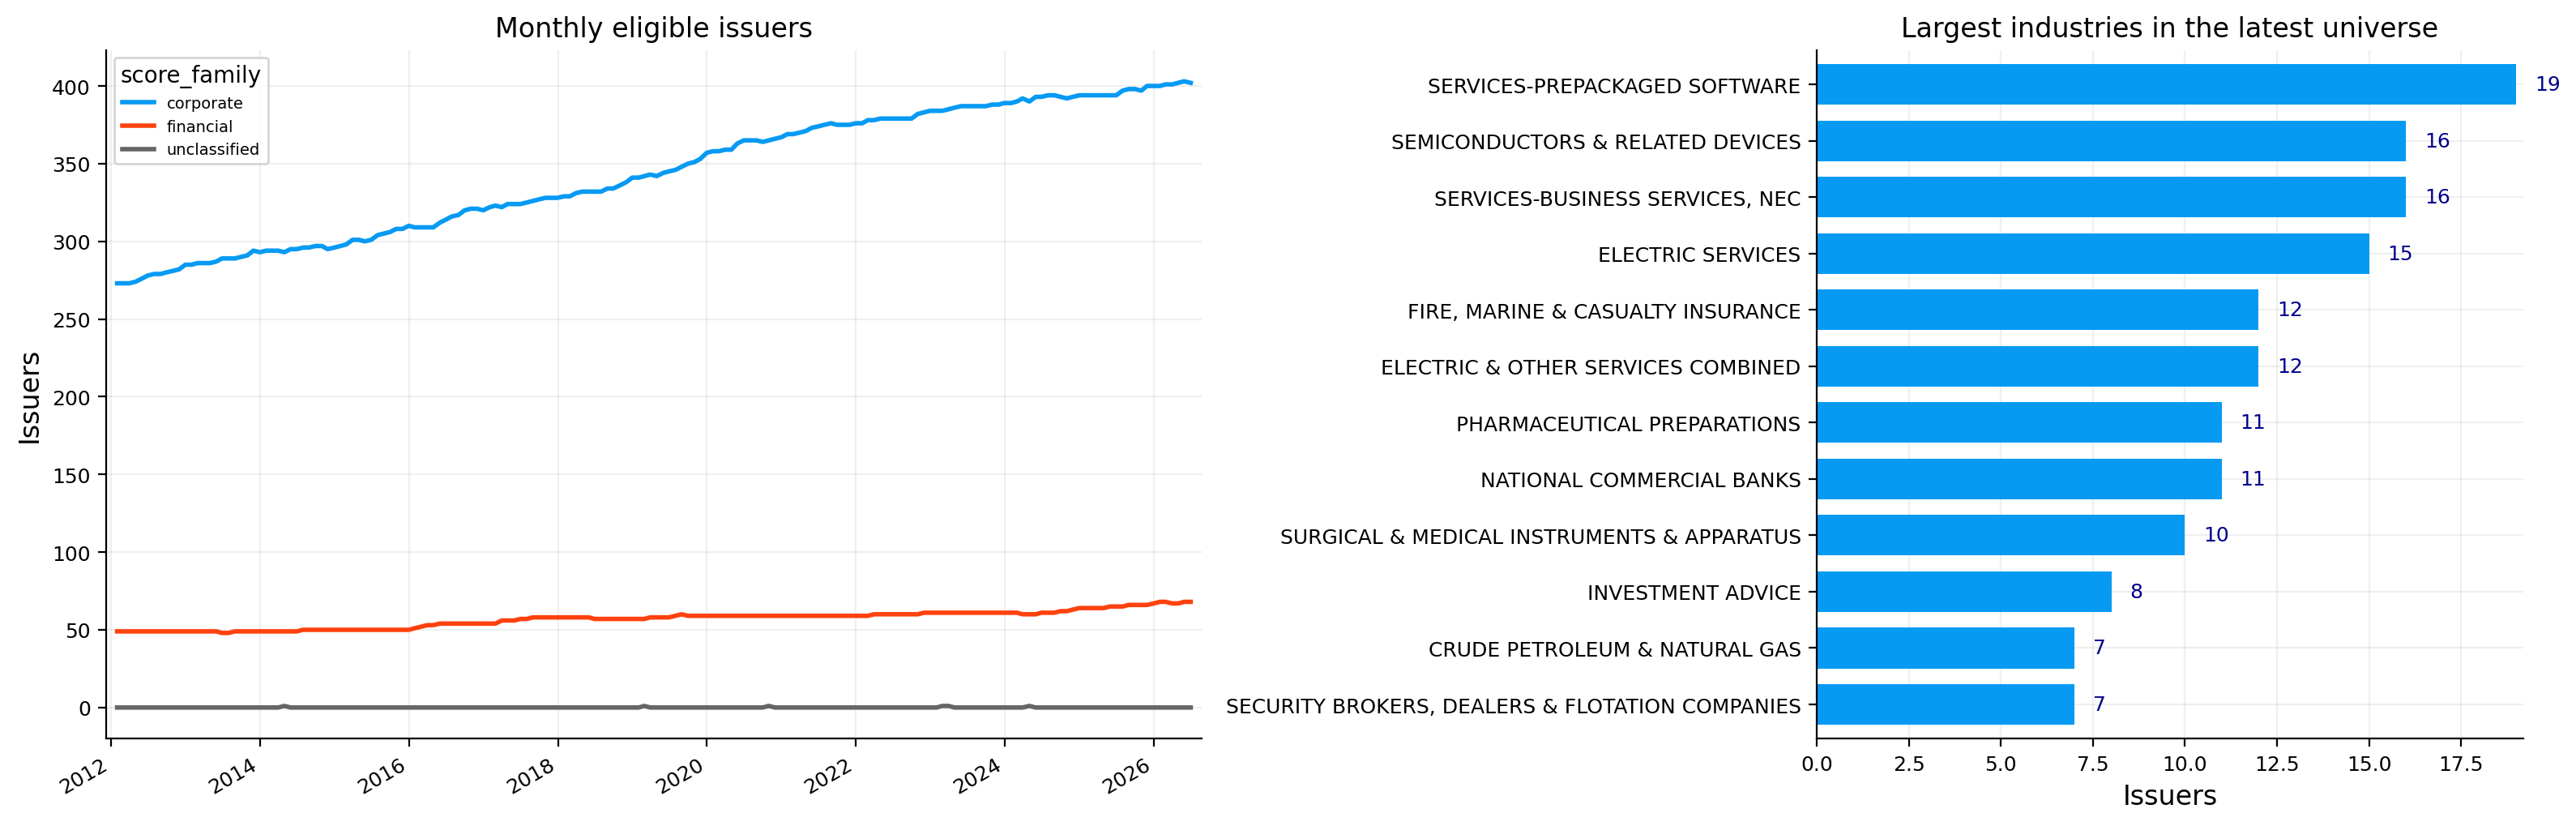

In [8]:
monthly_universe = monthly_mapped[monthly_mapped["score_family"] != "reit"].copy()
monthly_universe = monthly_universe.sort_values(["decision_date", "cik"]).reset_index(drop=True)

assert not monthly_universe.duplicated(["decision_date", "cik"]).any()
assert not monthly_universe["industry"].isin(reit_industries).any()

universe_counts = (
    monthly_universe.groupby(["decision_date", "score_family"]).size()
    .unstack(fill_value=0)
)
latest_universe = monthly_universe[monthly_universe["decision_date"] == monthly_universe["decision_date"].max()]
universe_summary = pd.DataFrame({
    "latest count": latest_universe.groupby("score_family").size(),
    "market-cap coverage": latest_universe.groupby("score_family")["market_cap"].apply(lambda s: s.notna().mean()),
})
latest_industry_counts = (
    latest_universe.groupby("industry").size().sort_values().tail(12)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), gridspec_kw={"width_ratios": [1.55, 1]})
universe_counts.plot(ax=axes[0], color=[blue, gold, muted], linewidth=2.0)
axes[0].set_title("Monthly eligible issuers")
axes[0].set_ylabel("Issuers")
axes[0].set_xlabel("")
finish_axes(axes[0])
latest_industry_counts.plot.barh(ax=axes[1], color=blue, width=0.72)
axes[1].set_title("Largest industries in the latest universe")
axes[1].set_xlabel("Issuers")
axes[1].set_ylabel("")
for y, value in enumerate(latest_industry_counts):
    axes[1].text(value + 0.5, y, f"{value}", va="center", color=ink, fontsize=9)
finish_axes(axes[1], axis="x")
plt.tight_layout()
plt.show()

del monthly_mapped


In [9]:
duration_concepts = {'revenue': ['us-gaap:RevenueFromContractWithCustomerExcludingAssessedTax', 'us-gaap:Revenues', 'us-gaap:SalesRevenueNet', 'us-gaap:SalesRevenueGoodsNet', 'us-gaap:SalesRevenueServicesNet'], 'cost_of_revenue': ['us-gaap:CostOfRevenue', 'us-gaap:CostOfGoodsAndServicesSold', 'us-gaap:CostOfGoodsSold'], 'gross_profit': ['us-gaap:GrossProfit'], 'operating_income': ['us-gaap:OperatingIncomeLoss'], 'pretax_income': ['us-gaap:IncomeLossFromContinuingOperationsBeforeIncomeTaxesExtraordinaryItemsNoncontrollingInterest', 'us-gaap:IncomeLossFromContinuingOperationsBeforeIncomeTaxesMinorityInterestAndIncomeLossFromEquityMethodInvestments'], 'net_income': ['us-gaap:NetIncomeLoss', 'us-gaap:ProfitLoss'], 'interest_expense': ['us-gaap:InterestExpense', 'us-gaap:InterestExpenseNonoperating', 'us-gaap:InterestExpenseDebt'], 'tax_expense': ['us-gaap:IncomeTaxExpenseBenefit'], 'eps_diluted': ['us-gaap:EarningsPerShareDiluted'], 'cfo': ['us-gaap:NetCashProvidedByUsedInOperatingActivities', 'us-gaap:NetCashProvidedByUsedInOperatingActivitiesContinuingOperations'], 'capex': ['us-gaap:PaymentsToAcquirePropertyPlantAndEquipment', 'us-gaap:PaymentsToAcquireProductiveAssets'], 'depreciation': ['us-gaap:DepreciationDepletionAndAmortization', 'us-gaap:Depreciation'], 'dividends': ['us-gaap:PaymentsOfDividendsCommonStock', 'us-gaap:PaymentsOfDividends', 'us-gaap:PaymentsOfOrdinaryDividends'], 'repurchases': ['us-gaap:PaymentsForRepurchaseOfCommonStock'], 'share_issuance': ['us-gaap:ProceedsFromIssuanceOfCommonStock', 'us-gaap:ProceedsFromIssuanceOfSharesUnderIncentiveAndShareBasedCompensationPlansIncludingStockOptions', 'us-gaap:ProceedsFromStockOptionsExercised'], 'rd_expense': ['us-gaap:ResearchAndDevelopmentExpense'], 'operating_expenses': ['us-gaap:OperatingExpenses', 'us-gaap:NoninterestExpense'], 'sga_expense': ['us-gaap:SellingGeneralAndAdministrativeExpense', 'us-gaap:GeneralAndAdministrativeExpense'], 'credit_loss_provision': ['us-gaap:ProvisionForLoanLeaseAndOtherLosses', 'us-gaap:ProvisionForLoanAndLeaseLosses', 'us-gaap:ProvisionForLoanLossesExpensed']}
instant_concepts = {'cash': ['us-gaap:CashAndCashEquivalentsAtCarryingValue', 'us-gaap:CashCashEquivalentsRestrictedCashAndRestrictedCashEquivalents'], 'receivables': ['us-gaap:AccountsReceivableNetCurrent'], 'inventory': ['us-gaap:InventoryNet'], 'current_assets': ['us-gaap:AssetsCurrent'], 'total_assets': ['us-gaap:Assets'], 'current_liabilities': ['us-gaap:LiabilitiesCurrent'], 'accounts_payable': ['us-gaap:AccountsPayableCurrent'], 'total_debt_reported': ['us-gaap:LongTermDebtAndCapitalLeaseObligations'], 'long_term_debt_noncurrent': ['us-gaap:LongTermDebtNoncurrent'], 'debt_current': ['us-gaap:DebtCurrent', 'us-gaap:LongTermDebtCurrent', 'us-gaap:LongTermDebtAndCapitalLeaseObligationsCurrent'], 'short_term_borrowings': ['us-gaap:ShortTermBorrowings', 'us-gaap:CommercialPaper'], 'total_liabilities': ['us-gaap:Liabilities'], 'common_equity': ['us-gaap:StockholdersEquity'], 'retained_earnings': ['us-gaap:RetainedEarningsAccumulatedDeficit'], 'goodwill': ['us-gaap:Goodwill'], 'intangibles': ['us-gaap:IntangibleAssetsNetExcludingGoodwill', 'us-gaap:FiniteLivedIntangibleAssetsNet', 'us-gaap:IndefiniteLivedIntangibleAssetsExcludingGoodwill'], 'shares_outstanding': ['dei:EntityCommonStockSharesOutstanding', 'us-gaap:CommonStockSharesOutstanding'], 'ppe': ['us-gaap:PropertyPlantAndEquipmentNet'], 'loans': ['us-gaap:LoansAndLeasesReceivableNetReportedAmount', 'us-gaap:LoansAndLeasesReceivableNetOfDeferredIncome', 'us-gaap:LoansReceivableNet'], 'deposits': ['us-gaap:Deposits']}
concepts = {**duration_concepts, **instant_concepts}
concept_lookup = {concept: (field, priority) for field, concepts in concepts.items() for priority, concept in enumerate(concepts)}
required_concepts = sorted(concept_lookup)
candidate_coverage = concept_catalog[concept_catalog['concept'].isin(required_concepts)].copy()
candidate_coverage[['field', 'priority']] = candidate_coverage['concept'].map(concept_lookup).apply(pd.Series)
candidate_coverage = candidate_coverage.sort_values(['field', 'priority', 'rows'])
display(candidate_coverage[['field', 'priority', 'concept', 'period_type', 'unit', 'rows']])

,field,priority,concept,period_type,unit,rows
516,accounts_payable,0,us-gaap:AccountsPayableCurrent,instant,USD,45024
8162,capex,0,us-gaap:PaymentsToAcquirePropertyPlantAndEquip...,instant,USD,7
8161,capex,0,us-gaap:PaymentsToAcquirePropertyPlantAndEquip...,duration,USD,51623
8159,capex,1,us-gaap:PaymentsToAcquireProductiveAssets,instant,USD,5
8158,capex,1,us-gaap:PaymentsToAcquireProductiveAssets,duration,USD,15440
...,...,...,...,...,...,...
5021,tax_expense,0,us-gaap:IncomeTaxExpenseBenefit,instant,USD,14
5020,tax_expense,0,us-gaap:IncomeTaxExpenseBenefit,duration,USD,106510
886,total_assets,0,us-gaap:Assets,instant,USD,69641
6153,total_debt_reported,0,us-gaap:LongTermDebtAndCapitalLeaseObligations,instant,USD,17144


In [10]:
fact_columns = ['cik', 'concept', 'label', 'value', 'unit', 'period_type', 'period_start', 'period_end', 'fiscal_year', 'fiscal_period', 'filed_date', 'form_type', 'accession', 'statement_type', 'taxonomy', 'is_annual_filing', 'is_amendment', 'filing_version']
periodic_forms = ['10-Q', '10-Q/A', '10-K', '10-K/A', '20-F', '20-F/A', '40-F', '40-F/A', '6-K', '6-K/A']
eligible_ciks = sorted(monthly_universe['cik'].unique().tolist())
facts_table = fundamentals_data.to_table(columns=fact_columns, filter=ds.field('concept').isin(required_concepts) & ds.field('cik').isin(eligible_ciks) & (ds.field('period_end') >= warmup_start) & ds.field('form_type').isin(periodic_forms))
facts = facts_table.to_pandas()
facts_table = None
pa.default_memory_pool().release_unused()
facts['field'] = facts['concept'].map(lambda concept: concept_lookup[concept][0])
facts['concept_priority'] = facts['concept'].map(lambda concept: concept_lookup[concept][1]).astype('int16')
fact_load_summary = pd.DataFrame({'value': [f'{len(facts):,}', facts['cik'].nunique(), facts['concept'].nunique(), f'{facts.memory_usage(deep=True).sum() / 1024 ** 2:,.1f} MB', ', '.join(sorted(facts['form_type'].unique()))]}, index=['selected rows', 'issuers', 'concepts', 'pandas memory', 'forms'])
display(fact_load_summary)
display(facts.groupby(['field', 'period_type']).size().unstack(fill_value=0))

,value
selected rows,"2,443,299"
issuers,569
concepts,69
pandas memory,638.0 MB
forms,"10-K, 10-K/A, 10-Q, 10-Q/A, 20-F, 20-F/A"


period_type,duration,instant
field,,
accounts_payable,0,44186
capex,65061,8
cash,0,142221
cfo,72240,0
common_equity,0,80385
cost_of_revenue,67721,0
credit_loss_provision,9767,2
current_assets,0,54484
current_liabilities,0,54433


In [11]:
date_columns = ['period_start', 'period_end', 'filed_date']
for column in date_columns:
    facts[column] = pd.to_datetime(facts[column])
facts['form_type'] = facts['form_type'].str.upper().str.strip()
facts['taxonomy'] = facts['taxonomy'].str.lower().str.strip()
facts['value'] = pd.to_numeric(facts['value'], errors='coerce')
unit_valid = (
    facts["field"].eq("shares_outstanding") & facts["unit"].eq("shares")
    | facts["field"].eq("eps_diluted") & facts["unit"].isin(["USD per share", "USD/shares"])
    | ~facts["field"].isin(["shares_outstanding", "eps_diluted"]) & facts["unit"].eq("USD")
)
facts = facts[
    np.isfinite(facts["value"])
    & (facts["filed_date"] >= facts["period_end"])
    & unit_valid
].copy()
fact_version_key = ['cik', 'concept', 'unit', 'period_start', 'period_end']
exact_version_key = fact_version_key + ['filed_date', 'accession', 'filing_version']
facts = facts.sort_values(exact_version_key).drop_duplicates(exact_version_key, keep='last').reset_index(drop=True)
assert (facts['filed_date'] >= facts['period_end']).all()
assert np.isfinite(facts['value']).all()
display(facts[['cik', 'field', 'concept', 'value', 'unit', 'period_start', 'period_end', 'filed_date', 'form_type', 'filing_version']].sample(12, random_state=random_seed).sort_values(['cik', 'filed_date']))

,cik,field,concept,value,unit,period_start,period_end,filed_date,form_type,filing_version
262083,40704,eps_diluted,us-gaap:EarningsPerShareDiluted,6.800000e-01,USD per share,2021-03-01,2021-05-30,2022-06-30,10-K,2
673259,217346,tax_expense,us-gaap:IncomeTaxExpenseBenefit,1.540000e+08,USD,2022-01-02,2022-12-31,2023-02-16,10-K,1
723141,316709,cfo,us-gaap:NetCashProvidedByUsedInOperatingActivi...,6.852000e+09,USD,2020-01-01,2020-12-31,2023-02-24,10-K,3
778130,702165,operating_income,us-gaap:OperatingIncomeLoss,9.840000e+08,USD,2020-10-01,2020-12-31,2021-02-04,10-K,1
825865,723254,shares_outstanding,us-gaap:CommonStockSharesOutstanding,1.265198e+08,shares,NaT,2012-05-31,2013-01-09,10-Q,3
871511,749251,revenue,us-gaap:SalesRevenueNet,1.615808e+09,USD,2012-01-01,2012-12-31,2013-02-22,10-K,1
905472,769397,revenue,us-gaap:RevenueFromContractWithCustomerExcludi...,1.853000e+09,USD,2025-08-01,2025-10-31,2025-11-26,10-Q,1
994528,816761,gross_profit,us-gaap:GrossProfit,1.026000e+09,USD,2018-01-01,2018-12-31,2021-02-26,10-K,4
1674071,1103982,goodwill,us-gaap:Goodwill,2.189500e+10,USD,NaT,2020-12-31,2021-04-28,10-Q,2
2101010,1467858,interest_expense,us-gaap:InterestExpense,6.500000e+07,USD,2013-07-01,2013-09-30,2013-10-30,10-Q,1


In [12]:
duration_mask = facts['period_type'].eq('duration') & facts['period_start'].notna()
facts['period_days'] = (facts['period_end'] - facts['period_start']).dt.days + 1
facts['duration_class'] = 'instant'
facts.loc[duration_mask & facts['period_days'].between(70, 120), 'duration_class'] = 'quarter'
facts.loc[duration_mask & facts['period_days'].between(150, 220), 'duration_class'] = 'six_month_ytd'
facts.loc[duration_mask & facts['period_days'].between(230, 310), 'duration_class'] = 'nine_month_ytd'
facts.loc[duration_mask & facts['period_days'].between(320, 410), 'duration_class'] = 'annual'
facts.loc[duration_mask & ~facts['period_days'].between(70, 410), 'duration_class'] = 'irregular'
classification = facts.groupby(['period_type', 'duration_class']).size().rename('facts').to_frame()
display(classification)

facts
period_type duration_class        
duration    annual          328257
            instant             97
            irregular          964
            nine_month_ytd  208072
            quarter         654663
            six_month_ytd   209887
instant     instant         969096

In [13]:
facts_by_filing = facts.sort_values(
    ["filed_date", "filing_version", "accession"]
).reset_index(drop=True)
economic_key = ["cik", "field", "unit", "period_start", "period_end"]


def select_filing_facts(available_facts):
    latest = available_facts.drop_duplicates(fact_version_key, keep="last")
    best_priority = latest.groupby(
        economic_key, sort=False, dropna=False
    )["concept_priority"].transform("min")
    return latest[
        latest["concept_priority"].eq(best_priority)
    ].drop_duplicates(economic_key, keep="last")


def reconstruct_quarters(selected_facts):
    duration = selected_facts[
        selected_facts["period_type"].eq("duration")
        & selected_facts["duration_class"].isin(
            ["quarter", "six_month_ytd", "nine_month_ytd", "annual"]
        )
    ]
    columns = [
        "cik", "field", "unit", "fiscal_year", "period_start",
        "period_end", "value", "filed_date", "concept", "source_class",
    ]
    direct = duration[duration["duration_class"].eq("quarter")].copy()
    direct["source_class"] = "direct"
    candidates = [direct[columns]]
    previous_class = {
        "six_month_ytd": "quarter",
        "nine_month_ytd": "six_month_ytd",
        "annual": "nine_month_ytd",
    }
    join_columns = ["cik", "field", "unit", "fiscal_year", "period_start"]
    for current_class, prior_class in previous_class.items():
        current = duration[duration["duration_class"].eq(current_class)]
        prior = duration[duration["duration_class"].eq(prior_class)]
        pairs = current.merge(
            prior[join_columns + ["period_end", "value", "filed_date"]],
            on=join_columns, how="inner", suffixes=("", "_prior"),
        )
        pairs = pairs[pairs["period_end_prior"].lt(pairs["period_end"])]
        pairs = (
            pairs.sort_values(join_columns + ["period_end", "period_end_prior"])
            .drop_duplicates(join_columns + ["period_end"], keep="last")
        )
        quarter_gap = (pairs["period_end"] - pairs["period_end_prior"]).dt.days
        quarter_value = pairs["value"] - pairs["value_prior"]
        scale = pairs[["value", "value_prior"]].abs().max(axis=1).clip(lower=1.0)
        pairs = pairs[
            quarter_gap.between(55, 140)
            & quarter_value.abs().le(10.0 * scale)
        ].copy()
        pairs["period_start"] = pairs["period_end_prior"] + pd.Timedelta(days=1)
        pairs["value"] = quarter_value.loc[pairs.index]
        pairs["filed_date"] = pairs[["filed_date", "filed_date_prior"]].max(axis=1)
        pairs["source_class"] = f"reconstructed_{current_class}"
        candidates.append(pairs[columns])
    quarter_candidates = pd.concat(candidates, ignore_index=True)
    quarter_candidates["source_rank"] = quarter_candidates[
        "source_class"
    ].ne("direct")
    quarterly = (
        quarter_candidates.sort_values([
            "cik", "field", "period_end", "source_rank", "filed_date",
        ])
        .drop_duplicates(["cik", "field", "period_end"], keep="first")
        .drop(columns="source_rank")
    )
    return quarterly, quarter_candidates


latest_selected = select_filing_facts(facts_by_filing)
quarterly_latest, quarter_candidates_latest = reconstruct_quarters(
    latest_selected
)
display(
    quarterly_latest.groupby(["field", "source_class"]).size()
    .unstack(fill_value=0)
)


source_class,direct,reconstructed_annual,reconstructed_nine_month_ytd,reconstructed_six_month_ytd
field,,,,
capex,8489,1070,5975,5791
cfo,8452,1331,7023,6750
cost_of_revenue,15304,806,1,2
credit_loss_provision,1776,172,189,172
depreciation,10176,876,2906,2852
dividends,6801,874,5036,4814
eps_diluted,25886,1009,0,4
gross_profit,12541,408,3,4
interest_expense,16970,1207,11,12


In [14]:
def duration_ttm_frame(selected_facts):
    duration = selected_facts[
        selected_facts["period_type"].eq("duration")
        & selected_facts["duration_class"].isin(
            ["quarter", "six_month_ytd", "nine_month_ytd", "annual"]
        )
    ]
    keys = ["cik", "field", "unit"]
    annual = (
        duration[duration["duration_class"].eq("annual")]
        .sort_values("period_end").groupby(keys, sort=False).tail(1)
    )
    annual = annual[
        keys + ["period_end", "value"]
    ].rename(columns={
        "period_end": "annual_end", "value": "annual_value",
    })
    current = duration[
        duration["duration_class"].isin(
            ["quarter", "six_month_ytd", "nine_month_ytd"]
        )
    ].merge(annual, on=keys, how="inner")
    distance = (current["period_end"] - current["annual_end"]).dt.days
    current = current[
        current["period_end"].gt(current["annual_end"])
        & distance.between(40, 320)
    ]
    current = (
        current.sort_values("period_end")
        .groupby(keys + ["duration_class"], sort=False).tail(1)
    )
    current = current[
        keys + [
            "duration_class", "period_end", "value",
            "annual_end", "annual_value",
        ]
    ].rename(columns={
        "period_end": "current_end", "value": "current_value",
    })
    prior = duration[
        duration["duration_class"].isin(
            ["quarter", "six_month_ytd", "nine_month_ytd"]
        )
    ][
        keys + ["duration_class", "period_end", "value"]
    ].rename(columns={
        "period_end": "prior_end", "value": "prior_value",
    })
    updates = current.merge(
        prior, on=keys + ["duration_class"], how="inner"
    )
    year_gap = (updates["current_end"] - updates["prior_end"]).dt.days
    updates = updates[year_gap.between(300, 430)]
    updates = (
        updates.sort_values("prior_end")
        .groupby(keys + ["duration_class", "current_end"], sort=False).tail(1)
    )
    updates["ttm_fallback"] = (
        updates["annual_value"]
        + updates["current_value"]
        - updates["prior_value"]
    )
    updates["period_end"] = updates["current_end"]
    updates["ttm_fallback_method"] = "annual + current YTD - prior YTD"

    candidates = annual.rename(columns={
        "annual_end": "period_end", "annual_value": "ttm_fallback",
    })
    candidates["ttm_fallback_method"] = "annual"
    candidates = pd.concat([
        candidates[
            keys + [
                "period_end", "ttm_fallback", "ttm_fallback_method",
            ]
        ],
        updates[
            keys + [
                "period_end", "ttm_fallback", "ttm_fallback_method",
            ]
        ],
    ], ignore_index=True)
    chosen = (
        candidates.sort_values("period_end")
        .groupby(["cik", "field"], sort=False).tail(1)
    )
    if chosen.empty:
        return pd.DataFrame(columns=["cik"])
    amount = chosen.pivot(
        index="cik", columns="field", values="ttm_fallback"
    )
    amount.columns = [f"{field}_ttm_fallback" for field in amount]
    method = chosen.pivot(
        index="cik", columns="field", values="ttm_fallback_method"
    )
    method.columns = [
        f"{field}_ttm_fallback_method" for field in method
    ]
    result = pd.concat([amount, method], axis=1).reset_index()
    duration_end = chosen.groupby("cik")["period_end"].max()
    result["latest_duration_end"] = duration_end.reindex(
        result["cik"]
    ).to_numpy()
    return result


def duration_frame(quarters, selected_facts):
    values = (
        quarters.sort_values(["cik", "field", "period_end", "filed_date"])
        .drop_duplicates(["cik", "field", "period_end"], keep="last")
        .copy()
    )
    grouped = values.groupby(["cik", "field"], sort=False)
    previous_value = grouped["value"].shift(1)
    previous_end = grouped["period_end"].shift(1)
    year_ago_value = grouped["value"].shift(4)
    year_ago_end = grouped["period_end"].shift(4)
    gap = (values["period_end"] - previous_end).dt.days
    year_gap = (values["period_end"] - year_ago_end).dt.days
    values["q"] = values["value"]
    values["qoq"] = values["value"].div(
        previous_value.where(previous_value.abs() > 1e-12)
    ) - 1.0
    values.loc[~gap.between(55, 140), "qoq"] = np.nan
    values["q_yoy"] = values["value"].div(
        year_ago_value.where(year_ago_value.abs() > 1e-12)
    ) - 1.0
    values.loc[~year_gap.between(300, 430), "q_yoy"] = np.nan
    values["ttm"] = (
        grouped["value"].rolling(4, min_periods=4).sum()
        .reset_index(level=[0, 1], drop=True)
    )
    valid_ttm = (
        gap.between(55, 140)
        .groupby([values["cik"], values["field"]])
        .rolling(3, min_periods=3).sum()
        .reset_index(level=[0, 1], drop=True).eq(3)
    )
    values.loc[~valid_ttm.fillna(False), "ttm"] = np.nan
    prior_ttm = values.groupby(
        ["cik", "field"], sort=False
    )["ttm"].shift(4)
    values["ttm_yoy"] = values["ttm"].div(
        prior_ttm.where(prior_ttm.abs() > 1e-12)
    ) - 1.0
    values.loc[~year_gap.between(300, 430), "ttm_yoy"] = np.nan

    latest = values.groupby(["cik", "field"], sort=False).tail(1)
    measures = ["q", "qoq", "q_yoy", "ttm", "ttm_yoy"]
    result = latest.pivot(
        index="cik", columns="field", values=measures
    )
    result.columns = [
        f"{field}_{measure}" for measure, field in result.columns
    ]
    result = result.reset_index()
    quarter_end = latest.groupby("cik")["period_end"].max()
    result["latest_quarter_end"] = quarter_end.reindex(
        result["cik"]
    ).to_numpy()
    revenue_periods = (
        values[values["field"].eq("revenue")]
        .groupby("cik", sort=False).tail(4)
        .groupby("cik")["period_end"]
        .agg(lambda dates: "|".join(dates.dt.strftime("%Y-%m-%d")))
    )
    result["ttm_quarter_ends"] = revenue_periods.reindex(
        result["cik"]
    ).to_numpy(dtype=object)

    fallback = duration_ttm_frame(selected_facts)
    result = result.merge(fallback, on="cik", how="outer")
    for field in duration_concepts:
        ttm = f"{field}_ttm"
        fallback_value = f"{field}_ttm_fallback"
        fallback_method = f"{field}_ttm_fallback_method"
        if ttm not in result:
            result[ttm] = np.nan
        if fallback_value not in result:
            continue
        scale = result[[ttm, fallback_value]].abs().max(axis=1).clip(lower=1.0)
        result[f"{field}_ttm_reconciliation"] = (
            result[ttm] - result[fallback_value]
        ).div(scale).where(
            result[ttm].notna() & result[fallback_value].notna()
        )
        result[f"{field}_ttm_method"] = np.where(
            result[ttm].notna(),
            "four standalone quarters",
            result[fallback_method],
        )
        result[ttm] = result[ttm].combine_first(result[fallback_value])
    return result.drop(columns=[
        column for column in result if "_ttm_fallback" in column
    ]).copy()


latest_duration = duration_frame(quarterly_latest, latest_selected)
ttm_columns = [
    column for column in latest_duration if column.endswith("_ttm")
]
display(
    latest_duration[ttm_columns].notna().mean()
    .sort_values(ascending=False)
    .rename("latest issuer coverage").to_frame()
)


,latest issuer coverage
cfo_ttm,1.000000
tax_expense_ttm,1.000000
net_income_ttm,1.000000
revenue_ttm,0.984183
eps_diluted_ttm,0.984183
pretax_income_ttm,0.978910
repurchases_ttm,0.947276
capex_ttm,0.936731
depreciation_ttm,0.901582
interest_expense_ttm,0.898067


In [15]:
def instant_frame(selected_facts):
    instant = selected_facts[
        selected_facts["period_type"].eq("instant")
    ].sort_values(["cik", "field", "period_end", "filed_date"])
    grouped = instant.groupby(["cik", "field"], sort=False)
    instant = instant.copy()
    instant["prior_value"] = grouped["value"].shift(1)
    instant["prior_period_end"] = grouped["period_end"].shift(1)
    latest = instant.groupby(["cik", "field"], sort=False).tail(1)
    values = ["value", "period_end", "prior_value", "prior_period_end"]
    result = latest.pivot(
        index="cik", columns="field", values=values
    )
    names = {
        "value": lambda field: field,
        "period_end": lambda field: f"{field}_period_end",
        "prior_value": lambda field: f"{field}_prior",
        "prior_period_end": lambda field: f"{field}_prior_period_end",
    }
    result.columns = [
        names[measure](field) for measure, field in result.columns
    ]
    result = result.reset_index()
    balance_end = latest.groupby("cik")["period_end"].max()
    result["latest_balance_end"] = balance_end.reindex(
        result["cik"]
    ).to_numpy()
    return result


latest_instant = instant_frame(latest_selected)
instant_columns = list(instant_concepts)
display(
    latest_instant.reindex(columns=instant_columns).notna().mean()
    .sort_values(ascending=False)
    .rename("latest_issuer_coverage").to_frame()
)


,latest_issuer_coverage
cash,1.000000
total_assets,1.000000
retained_earnings,0.992970
common_equity,0.978910
ppe,0.964851
goodwill,0.954306
shares_outstanding,0.952548
intangibles,0.912127
current_assets,0.880492
current_liabilities,0.880492


In [16]:
monthly_filing_cache = output_dir / "monthly_filing_financials_v2.parquet"
if monthly_filing_cache.exists():
    monthly_filing_financials = pd.read_parquet(monthly_filing_cache)
else:
    filing_dates = facts_by_filing["filed_date"]
    latest_records = pd.DataFrame()
    monthly_records = []
    cursor = 0
    for decision_date in date_map["decision_date"]:
        stop = filing_dates.searchsorted(decision_date, side="left")
        new_facts = facts_by_filing.iloc[cursor:stop]
        cursor = stop
        changed_ciks = new_facts["cik"].drop_duplicates()
        if not changed_ciks.empty:
            oldest_period = decision_date - pd.DateOffset(years=3)
            available = facts_by_filing.iloc[:stop]
            available = available[
                available["cik"].isin(changed_ciks)
                & available["period_end"].ge(oldest_period)
            ]
            selected = select_filing_facts(available)
            quarters, _ = reconstruct_quarters(selected)
            duration_values = duration_frame(quarters, selected)
            instant_values = instant_frame(selected)
            current = duration_values.merge(
                instant_values, on="cik", how="outer"
            )
            latest_filed = available.groupby("cik")["filed_date"].max()
            current["filed_date"] = latest_filed.reindex(
                current["cik"]
            ).to_numpy()
            period_dates = current.reindex(columns=[
                "latest_quarter_end", "latest_duration_end",
                "latest_balance_end",
            ]).apply(pd.to_datetime)
            current["latest_period_end"] = period_dates.max(axis=1)
            current = current.set_index("cik")
            latest_records = pd.concat([
                latest_records.drop(index=changed_ciks, errors="ignore"),
                current,
            ]).copy()
            latest_records.index.name = "cik"
        current_ciks = pd.Index(
            monthly_universe.loc[
                monthly_universe["decision_date"].eq(decision_date), "cik"
            ].unique()
        )
        available_ciks = current_ciks.intersection(latest_records.index)
        month = (
            latest_records.loc[available_ciks]
            .rename_axis("cik").reset_index()
        )
        month["decision_date"] = decision_date
        monthly_records.append(month)
    monthly_filing_financials = (
        pd.concat(monthly_records, ignore_index=True)
        .sort_values(["decision_date", "cik"])
    )
    monthly_filing_financials.to_parquet(monthly_filing_cache, index=False)
assert not monthly_filing_financials.duplicated(["decision_date", "cik"]).any()
display(pd.DataFrame({
    "value": [
        len(monthly_filing_financials),
        monthly_filing_financials["cik"].nunique(),
        monthly_filing_financials["decision_date"].min(),
        monthly_filing_financials["decision_date"].max(),
        monthly_filing_financials.shape[1],
        monthly_filing_cache.name,
    ]
}, index=[
    "monthly filing records", "issuers", "first decision", "last decision",
    "columns", "cache",
]))


,value
monthly filing records,69062
issuers,568
first decision,2012-01-31 00:00:00
last decision,2026-06-30 00:00:00
columns,257
cache,monthly_filing_financials_v2.parquet


In [17]:
monthly_financials = monthly_universe.merge(monthly_filing_financials, on=['decision_date', 'cik'], how='left', validate='one_to_one')
monthly_financials = monthly_financials.sort_values(['decision_date', 'cik']).reset_index(drop=True)
known = monthly_financials['filed_date'].notna()
assert (monthly_financials.loc[known, 'filed_date'] < monthly_financials.loc[known, 'decision_date']).all()
assert (monthly_financials['mapping_valid_from'] <= monthly_financials['decision_date']).all()
assert (monthly_financials['mapping_valid_to'] >= monthly_financials['decision_date']).all()
assert not monthly_financials.duplicated(['decision_date', 'cik']).any()
assert not monthly_financials['industry'].isin(reit_industries).any()
monthly_financials.to_parquet(output_dir / 'monthly_financials.parquet', index=False)
display(pd.DataFrame({'value': [len(monthly_financials), monthly_financials['cik'].nunique(), monthly_financials['decision_date'].min(), monthly_financials['decision_date'].max(), f'{known.mean():.1%}', monthly_financials.shape[1]]}, index=['monthly rows', 'issuers', 'first decision', 'last decision', 'filing coverage', 'columns']))

,value
monthly rows,69592
issuers,569
first decision,2012-01-31 00:00:00
last decision,2026-06-30 00:00:00
filing coverage,99.2%
columns,272


In [18]:
direct_reconstructed = quarter_candidates_latest[
    quarter_candidates_latest.duplicated(["cik", "field", "period_end"], keep=False)
].pivot_table(
    index=["cik", "field", "period_end"],
    columns="source_class",
    values="value",
    aggfunc="last",
)
reconstructed_columns = [column for column in direct_reconstructed if str(column).startswith("reconstructed_")]
reconciliation_rows = []
for column in reconstructed_columns:
    pairs = direct_reconstructed[["direct", column]].dropna()
    scale = pairs[["direct", column]].abs().max(axis=1).clip(lower=1.0)
    error = (pairs["direct"] - pairs[column]) / scale
    reconciliation_rows.append({
        "comparison": f"direct vs {column.replace('reconstructed_', '')}",
        "pairs": len(pairs), "median_abs_error": error.abs().median(),
        "p90_abs_error": error.abs().quantile(0.90),
    })
reconstruction_validation = pd.DataFrame(reconciliation_rows).set_index("comparison")

coverage_fields = ["revenue_ttm", "operating_income_ttm", "net_income_ttm", "cfo_ttm",
                   "total_assets", "common_equity", "shares_outstanding"]
coverage_by_year_family = (
    monthly_financials.assign(year=monthly_financials["decision_date"].dt.year)
    .groupby(["year", "score_family"])[coverage_fields]
    .agg(lambda values: values.notna().mean())
)
display(reconstruction_validation.style.format({
    "median_abs_error": "{:.2%}", "p90_abs_error": "{:.2%}",
}).set_caption("Standalone-quarter reconstruction checks"))

,pairs,median_abs_error,p90_abs_error
comparison,,,
direct vs annual,776,0.00%,21.00%
direct vs nine_month_ytd,67850,0.00%,0.02%
direct vs six_month_ytd,65202,0.00%,0.01%


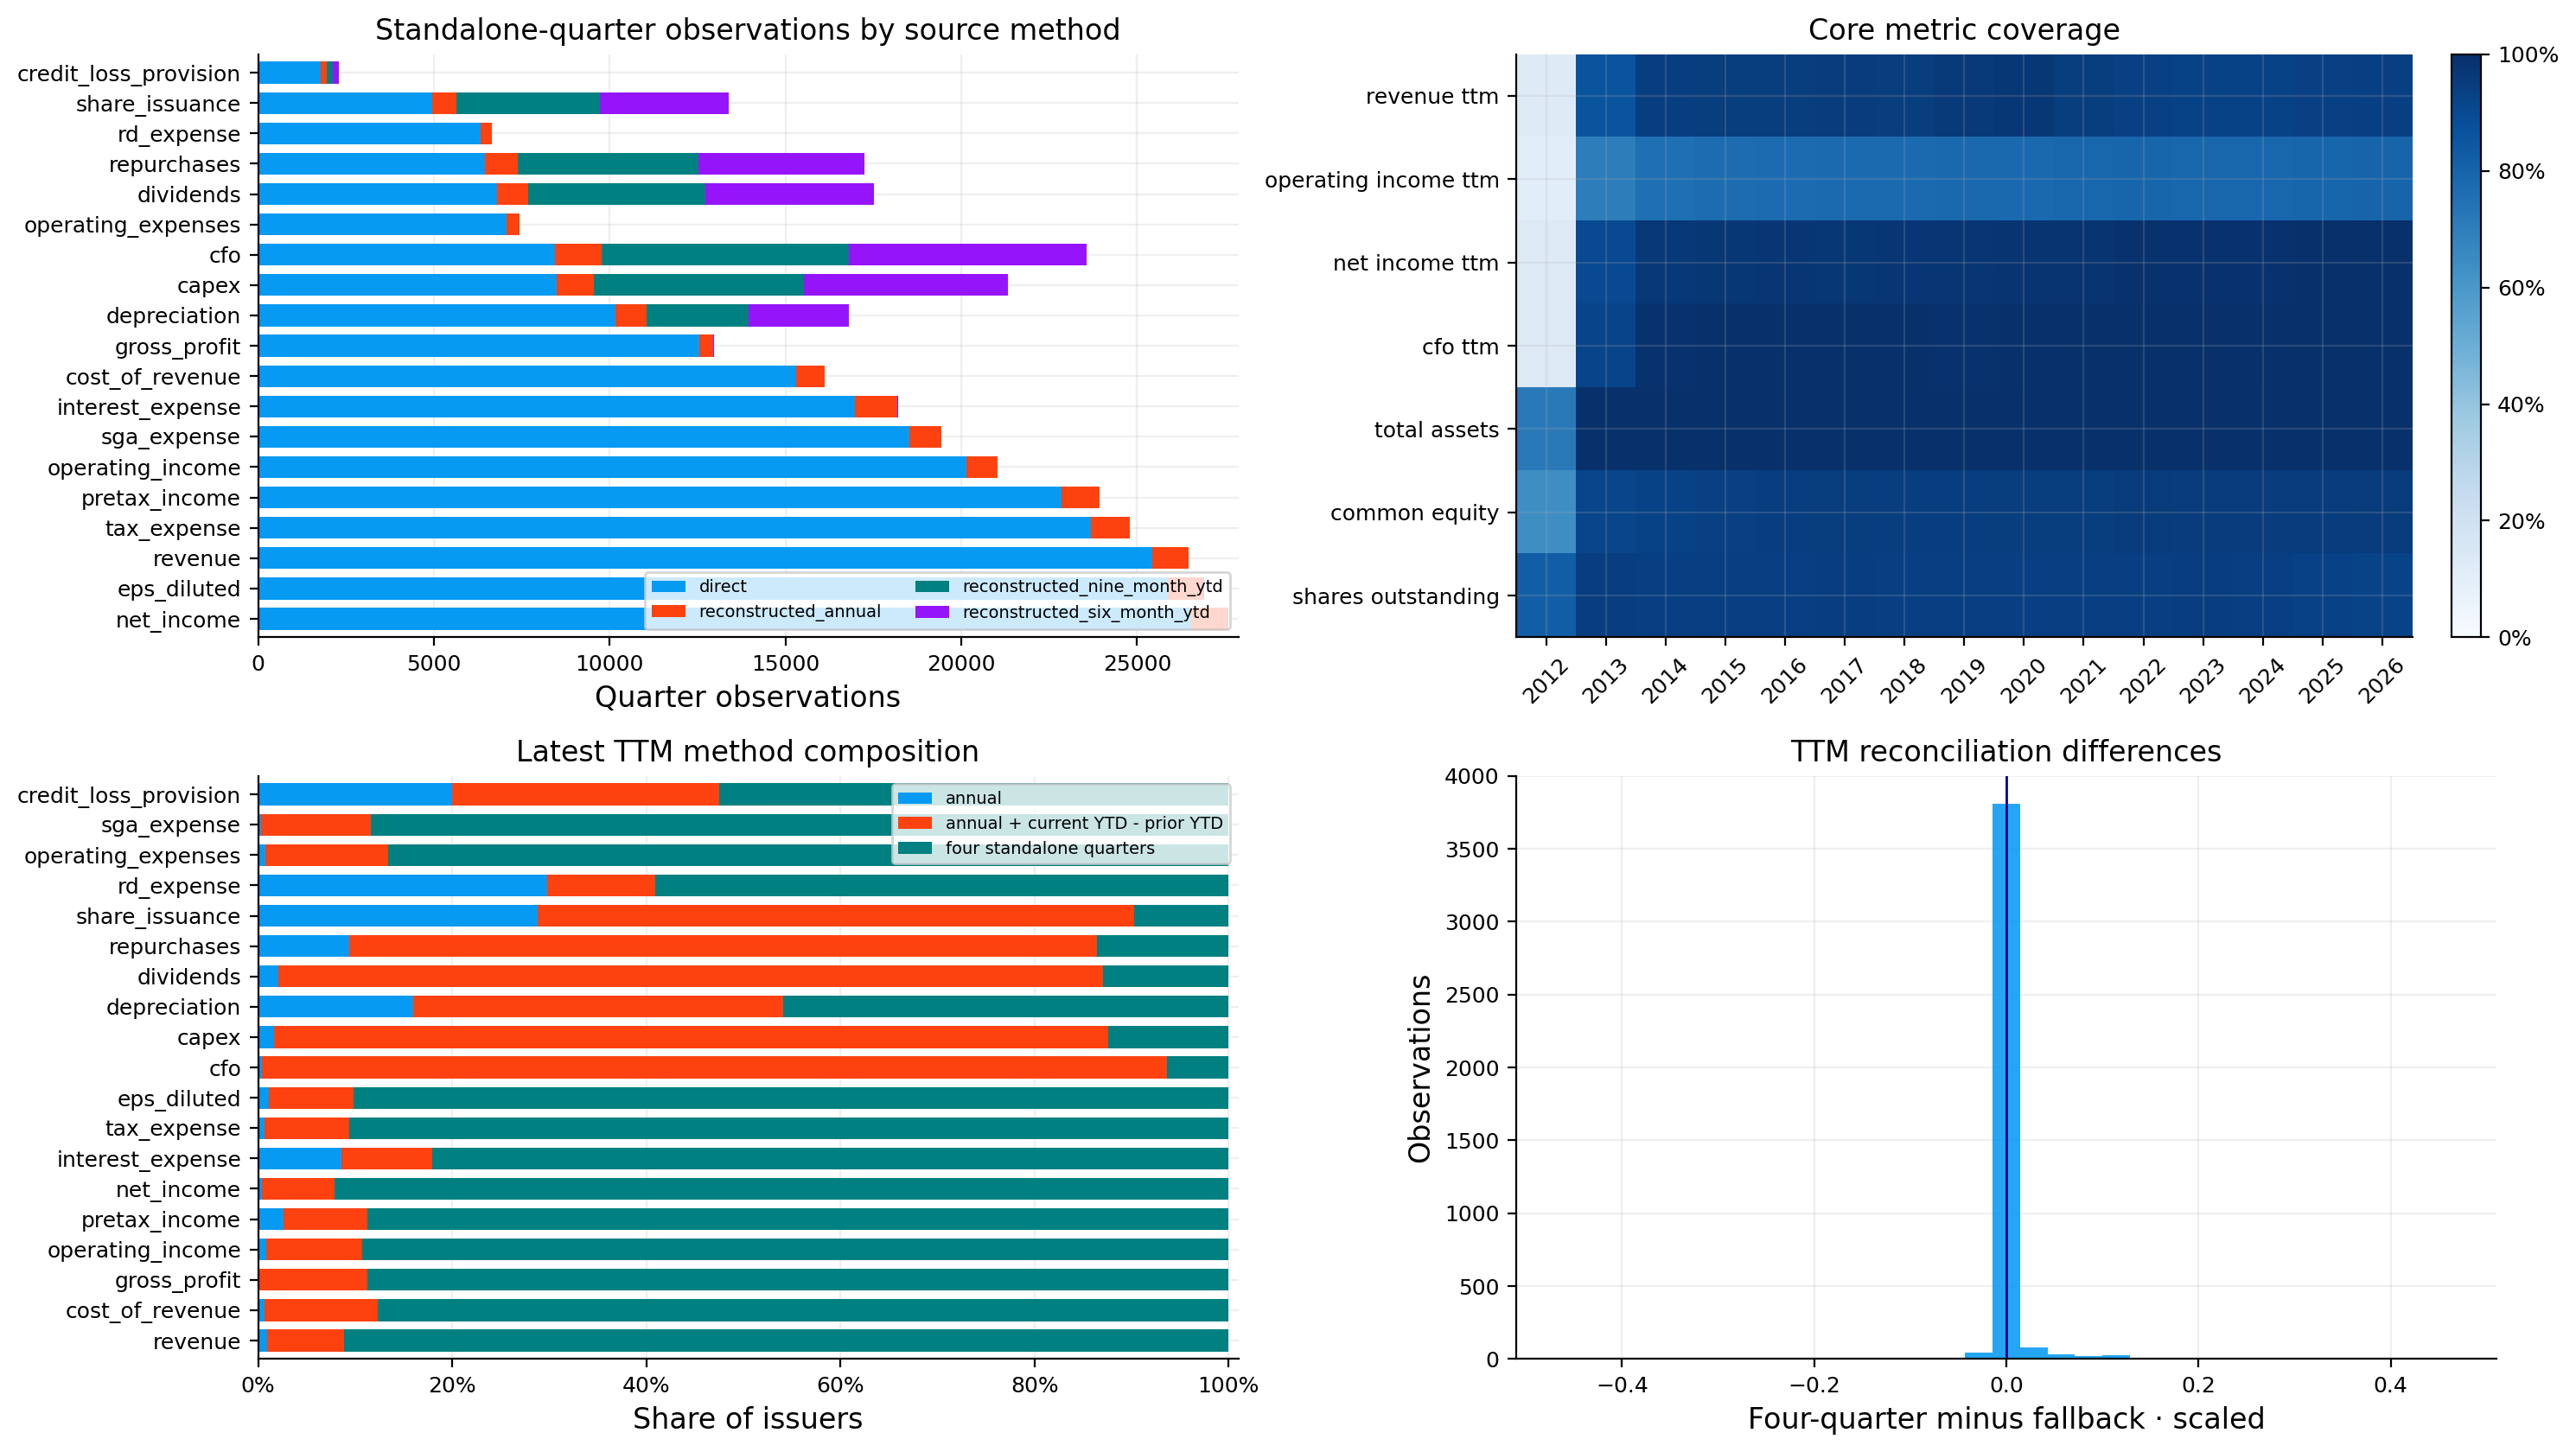

,ticker,entity_name,score_family,filed_date,latest_period_end,revenue_ttm,operating_income_ttm,net_income_ttm,cfo_ttm,total_assets,common_equity,market_cap
69404,NVDA,NVIDIA CORP,corporate,2026-05-20 00:00:00,2026-05-15 00:00:00,"$253,491,000,000","$162,285,000,000","$159,613,000,000","$125,648,000,000","$259,474,000,000","$195,474,000,000","$4,842,177,911,377"
69547,GOOG,Alphabet Inc.,corporate,2026-04-30 00:00:00,2026-03-31 00:00:00,"$422,499,000,000","$138,129,000,000","$160,208,000,000","$174,353,000,000","$703,919,000,000","$478,746,000,000","$4,280,946,117,310"
69261,AAPL,Apple Inc.,corporate,2026-05-01 00:00:00,2026-04-17 00:00:00,"$451,442,000,000","$147,366,000,000","$122,575,000,000","$140,222,000,000","$371,082,000,000","$106,491,000,000","$4,249,933,117,013"
69298,MSFT,MICROSOFT CORP,corporate,2026-04-29 00:00:00,2026-04-23 00:00:00,"$294,544,000,000","$148,957,000,000","$125,216,000,000","$170,141,000,000","$694,228,000,000","$414,367,000,000","$2,770,954,631,675"
69389,AMZN,AMAZON COM INC,corporate,2026-04-30 00:00:00,2026-04-22 00:00:00,"$742,776,000,000","$85,422,000,000","$90,798,000,000","$148,531,000,000","$916,630,000,000","$441,914,000,000","$2,563,849,423,583"
69561,AVGO,Broadcom Inc.,corporate,2026-06-09 00:00:00,2026-05-29 00:00:00,"$75,465,000,000","$32,746,000,000","$29,317,000,000","$33,622,000,000","$179,158,000,000",—,"$1,797,175,919,794"
69476,TSLA,"Tesla, Inc.",corporate,2026-04-30 00:00:00,2026-04-16 00:00:00,"$97,879,000,000","$4,897,000,000","$3,862,000,000","$16,528,000,000","$143,724,000,000","$84,116,000,000","$1,578,272,915,373"
69276,MU,MICRON TECHNOLOGY INC,corporate,2026-06-25 00:00:00,2026-06-17 00:00:00,"$69,533,000,000","$59,243,000,000","$50,469,000,000","$51,432,000,000","$134,112,000,000","$100,724,000,000","$1,303,647,264,385"
69189,LLY,ELI LILLY & Co,corporate,2026-04-30 00:00:00,2026-04-27 00:00:00,"$72,249,500,000",—,"$25,276,700,000","$20,480,000,000","$116,576,000,000","$31,198,000,000","$1,129,552,945,180"
69123,AMD,ADVANCED MICRO DEVICES INC,corporate,2026-05-06 00:00:00,2026-04-29 00:00:00,"$37,454,000,000","$4,364,000,000","$5,009,000,000","$9,725,000,000","$79,642,000,000","$64,462,000,000","$947,232,173,411"


9448

In [19]:
source_mix = (
    quarterly_latest.groupby(["field", "source_class"]).size()
    .unstack(fill_value=0).sort_values("direct", ascending=False)
)
coverage_heatmap = (
    monthly_financials.assign(year=monthly_financials["decision_date"].dt.year)
    .groupby("year")[coverage_fields]
    .agg(lambda values: values.notna().mean())
)
latest_date = monthly_financials["decision_date"].max()
latest_month = monthly_financials[monthly_financials["decision_date"].eq(latest_date)]
method_columns = [
    column for column in latest_month
    if column.endswith("_ttm_method")
    and column.split("_ttm_method")[0] in duration_concepts
]
method_mix = pd.DataFrame({
    column.replace("_ttm_method", ""): latest_month[column].value_counts(normalize=True)
    for column in method_columns
}).T.fillna(0.0)
reconciliation_columns = [
    column for column in latest_month if column.endswith("_ttm_reconciliation")
]
reconciliation = latest_month[reconciliation_columns].stack().rename("difference")

fig, axes = plt.subplots(2, 2, figsize=(15, 8.5))
source_mix[["direct"] + reconstructed_columns].plot.barh(
    stacked=True, ax=axes[0, 0],
    color=[blue, gold, teal, coral][:1 + len(reconstructed_columns)], width=0.72,
)
axes[0, 0].set_title("Standalone-quarter observations by source method")
axes[0, 0].set_xlabel("Quarter observations")
axes[0, 0].set_ylabel("")
finish_axes(axes[0, 0], axis="x")
axes[0, 0].legend(loc="lower right", ncol=2)

coverage_view = coverage_heatmap.T
coverage_image = axes[0, 1].imshow(
    coverage_view, aspect="auto", cmap="Blues", vmin=0, vmax=1
)
axes[0, 1].set_title("Core metric coverage")
axes[0, 1].set_yticks(range(len(coverage_view)))
axes[0, 1].set_yticklabels([label.replace("_", " ") for label in coverage_view.index])
axes[0, 1].set_xticks(range(len(coverage_view.columns)))
axes[0, 1].set_xticklabels(coverage_view.columns, rotation=45)
fig.colorbar(
    coverage_image, ax=axes[0, 1], fraction=0.046, pad=0.04,
    format=lambda value, _: f"{value:.0%}",
)

method_mix.plot.barh(
    stacked=True, ax=axes[1, 0],
    color=[blue, gold, teal], width=0.72,
)
axes[1, 0].set_title("Latest TTM method composition")
axes[1, 0].set_xlabel("Share of issuers")
axes[1, 0].set_ylabel("")
axes[1, 0].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
finish_axes(axes[1, 0], axis="x")

axes[1, 1].hist(reconciliation.clip(-0.5, 0.5), bins=35, color=blue, alpha=0.88)
axes[1, 1].axvline(0, color=ink, linewidth=1)
axes[1, 1].set_title("TTM reconciliation differences")
axes[1, 1].set_xlabel("Four-quarter minus fallback · scaled")
axes[1, 1].set_ylabel("Observations")
finish_axes(axes[1, 1])
plt.tight_layout()
plt.show()

latest_standardized = latest_month[[
    "ticker", "entity_name", "score_family", "filed_date", "latest_period_end",
    "revenue_ttm", "operating_income_ttm", "net_income_ttm", "cfo_ttm",
    "total_assets", "common_equity", "market_cap",
]].sort_values("market_cap", ascending=False).head(15)
display(latest_standardized.style.format({
    "revenue_ttm": "${:,.0f}", "operating_income_ttm": "${:,.0f}",
    "net_income_ttm": "${:,.0f}", "cfo_ttm": "${:,.0f}",
    "total_assets": "${:,.0f}", "common_equity": "${:,.0f}",
    "market_cap": "${:,.0f}",
}, na_rep="—"))


del facts, facts_by_filing, latest_selected, quarterly_latest
del quarter_candidates_latest, latest_duration, latest_instant
del monthly_filing_financials, direct_reconstructed
pa.default_memory_pool().release_unused()
gc.collect()


In [20]:
financial_history = monthly_financials.copy()

def ratio(numerator, denominator, positive_denominator=True):
    numerator = pd.to_numeric(numerator, errors="coerce")
    denominator = pd.to_numeric(denominator, errors="coerce")
    valid = denominator.gt(0) if positive_denominator else denominator.abs().gt(1e-12)
    return (numerator / denominator).where(valid).replace([np.inf, -np.inf], np.nan)

for field in duration_concepts:
    ttm_column = f"{field}_ttm"
    if ttm_column in financial_history:
        financial_history[field] = financial_history[ttm_column]

financial_history["gross_profit"] = financial_history["gross_profit"].combine_first(
    financial_history["revenue"] - financial_history["cost_of_revenue"]
)
financial_history["free_cash_flow"] = financial_history["cfo"] - financial_history["capex"]
financial_history["total_liabilities"] = financial_history["total_liabilities"].combine_first(
    financial_history["total_assets"] - financial_history["common_equity"]
)
current_debt = financial_history["debt_current"].combine_first(
    financial_history["short_term_borrowings"]
)
debt_components = (
    financial_history["long_term_debt_noncurrent"] + current_debt
).where(
    financial_history["long_term_debt_noncurrent"].notna() & current_debt.notna()
)
financial_history["total_debt"] = financial_history["total_debt_reported"].combine_first(
    debt_components
)
financial_history["total_debt_source"] = np.select(
    [financial_history["total_debt_reported"].notna(), debt_components.notna()],
    ["reported total", "long-term plus current"],
    default="missing",
)
tangible_known = (
    financial_history["common_equity"].notna()
    & financial_history["goodwill"].notna()
    & financial_history["intangibles"].notna()
)
financial_history["tangible_equity"] = (
    financial_history["common_equity"]
    - financial_history["goodwill"]
    - financial_history["intangibles"]
).where(tangible_known)
financial_history["tangible_equity_approx"] = (
    financial_history["common_equity"]
    - financial_history["goodwill"].fillna(0.0)
    - financial_history["intangibles"].fillna(0.0)
).where(financial_history["common_equity"].notna())
financial_history["tangible_equity_source"] = np.where(
    tangible_known, "reported components", "approximation"
)
financial_history["enterprise_value"] = (
    financial_history["market_cap"]
    + financial_history["total_debt"]
    - financial_history["cash"]
)
financial_history["net_debt"] = financial_history["total_debt"] - financial_history["cash"]
financial_history["working_capital"] = (
    financial_history["current_assets"] - financial_history["current_liabilities"]
)
payout_known = financial_history[
    ["dividends", "repurchases", "share_issuance"]
].notna().all(axis=1)
financial_history["net_payout_amount"] = (
    financial_history["dividends"]
    + financial_history["repurchases"]
    - financial_history["share_issuance"]
).where(payout_known)

financial_history["average_assets"] = (
    financial_history["total_assets"] + financial_history["total_assets_prior"]
) / 2.0
financial_history["average_equity"] = (
    financial_history["common_equity"] + financial_history["common_equity_prior"]
) / 2.0
prior_tangible_known = (
    financial_history["common_equity_prior"].notna()
    & financial_history["goodwill_prior"].notna()
    & financial_history["intangibles_prior"].notna()
)
prior_tangible_equity = (
    financial_history["common_equity_prior"]
    - financial_history["goodwill_prior"]
    - financial_history["intangibles_prior"]
).where(prior_tangible_known)
financial_history["average_tangible_equity"] = (
    financial_history["tangible_equity"] + prior_tangible_equity
) / 2.0
financial_history["average_receivables"] = (
    financial_history["receivables"] + financial_history["receivables_prior"]
) / 2.0
financial_history["average_inventory"] = (
    financial_history["inventory"] + financial_history["inventory_prior"]
) / 2.0
financial_history["average_payables"] = (
    financial_history["accounts_payable"] + financial_history["accounts_payable_prior"]
) / 2.0
financial_history["average_debt"] = (
    financial_history["total_debt"]
    + financial_history["total_debt"].groupby(financial_history["cik"]).shift(12)
) / 2.0

financial_history["revenue_per_share"] = ratio(
    financial_history["revenue"], financial_history["shares_outstanding"]
)
eps_approx = ratio(financial_history["net_income"], financial_history["shares_outstanding"])
financial_history["earnings_per_share"] = financial_history["eps_diluted"].combine_first(
    eps_approx
)
financial_history["eps_source"] = np.where(
    financial_history["eps_diluted"].notna(),
    "reported diluted EPS",
    "point-in-time share approximation",
)
financial_history["fcf_per_share"] = ratio(
    financial_history["free_cash_flow"], financial_history["shares_outstanding"]
)
financial_history["book_value_per_share"] = ratio(
    financial_history["common_equity"], financial_history["shares_outstanding"]
)
financial_history["tangible_book_value_per_share"] = ratio(
    financial_history["tangible_equity"], financial_history["shares_outstanding"]
)
financial_history["shareholder_yield"] = ratio(
    financial_history["net_payout_amount"], financial_history["market_cap"]
)

display(
    financial_history[[
        "ticker", "decision_date", "free_cash_flow", "total_debt",
        "total_debt_source", "tangible_equity", "tangible_equity_source",
        "earnings_per_share", "eps_source", "shareholder_yield",
    ]].tail(12).style.format({
        "free_cash_flow": "${:,.0f}", "total_debt": "${:,.0f}",
        "tangible_equity": "${:,.0f}", "earnings_per_share": "${:,.2f}",
        "shareholder_yield": "{:.2%}",
    }, na_rep="—")
)


,ticker,decision_date,free_cash_flow,total_debt,total_debt_source,tangible_equity,tangible_equity_source,earnings_per_share,eps_source,shareholder_yield
69580,GEHC,2026-06-30 00:00:00,"$1,519,000,000","$10,129,000,000",long-term plus current,"$-6,300,000,000",reported components,$4.18,reported diluted EPS,1.16%
69581,KVUE,2026-06-30 00:00:00,"$1,823,000,000",—,missing,"$-7,308,000,000",reported components,$0.85,reported diluted EPS,4.36%
69582,SOLV,2026-06-30 00:00:00,"$-203,000,000","$5,080,000,000",long-term plus current,"$-3,154,000,000",reported components,$8.15,reported diluted EPS,—
69583,VLTO,2026-06-30 00:00:00,"$1,042,000,000","$2,662,000,000",long-term plus current,"$-787,000,000",reported components,$3.88,reported diluted EPS,—
69584,TKO,2026-06-30 00:00:00,—,"$4,639,920,000",long-term plus current,"$-8,280,487,000",reported components,$2.68,reported diluted EPS,—
69585,GEV,2026-06-30 00:00:00,"$7,526,000,000","$2,806,000,000",reported total,"$-476,000,000",reported components,$34.22,reported diluted EPS,1.20%
69586,BG,2026-06-30 00:00:00,"$-1,161,000,000","$14,553,000,000",long-term plus current,"$12,450,000,000",reported components,$4.29,reported diluted EPS,5.04%
69587,SW,2026-06-30 00:00:00,"$1,022,000,000","$13,275,000,000",reported total,"$9,836,000,000",reported components,$0.73,reported diluted EPS,—
69588,BLK,2026-06-30 00:00:00,"$3,672,000,000",—,missing,"$-6,299,000,000",reported components,$39.78,reported diluted EPS,3.24%
69589,SNDK,2026-06-30 00:00:00,"$4,460,000,000",$0,long-term plus current,—,approximation,$29.26,reported diluted EPS,—


In [21]:
income_common_size = {
    "gross_profit": "gross_profit_margin_cs",
    "operating_income": "operating_income_margin_cs",
    "pretax_income": "pretax_income_margin_cs",
    "net_income": "net_income_margin_cs",
    "cfo": "cfo_margin_cs",
    "free_cash_flow": "fcf_margin_cs",
}
balance_common_size = {
    "cash": "cash_assets_cs", "receivables": "receivables_assets_cs",
    "inventory": "inventory_assets_cs", "current_assets": "current_assets_cs",
    "total_debt": "debt_assets_cs", "total_liabilities": "liabilities_assets_cs",
    "common_equity": "equity_assets_cs", "tangible_equity": "tangible_equity_assets_cs",
}
for source, target in income_common_size.items():
    financial_history[target] = ratio(financial_history[source], financial_history["revenue"])
for source, target in balance_common_size.items():
    financial_history[target] = ratio(financial_history[source], financial_history["total_assets"])

def lag_12(column):
    return financial_history.groupby("cik", sort=False)[column].shift(12)

def annual_growth(column):
    prior = lag_12(column)
    return ratio(financial_history[column], prior) - 1.0

financial_history["assets_growth"] = annual_growth("total_assets")
financial_history["equity_growth"] = annual_growth("common_equity")
financial_history["shares_growth"] = annual_growth("shares_outstanding")
financial_history["working_capital_change"] = financial_history["working_capital"] - lag_12("working_capital")

latest_common_size = financial_history[financial_history["decision_date"].eq(financial_history["decision_date"].max())]
display(
    latest_common_size.groupby("score_family")[
        list(income_common_size.values()) + list(balance_common_size.values())
    ].median().T.style.format("{:.1%}", na_rep="—")
)

score_family,corporate,financial
gross_profit_margin_cs,46.8%,43.5%
operating_income_margin_cs,18.2%,21.7%
pretax_income_margin_cs,15.3%,26.3%
net_income_margin_cs,12.6%,20.4%
cfo_margin_cs,20.0%,23.9%
fcf_margin_cs,13.4%,20.2%
cash_assets_cs,5.7%,5.0%
receivables_assets_cs,7.6%,7.6%
inventory_assets_cs,7.2%,2.0%
current_assets_cs,29.1%,53.7%


In [22]:
financial_history["gross_margin"] = ratio(financial_history["gross_profit"], financial_history["revenue"])
financial_history["operating_margin"] = ratio(financial_history["operating_income"], financial_history["revenue"])
financial_history["pretax_margin"] = ratio(financial_history["pretax_income"], financial_history["revenue"])
financial_history["net_margin"] = ratio(financial_history["net_income"], financial_history["revenue"])
financial_history["fcf_margin"] = ratio(financial_history["free_cash_flow"], financial_history["revenue"])
financial_history["gross_profitability_assets"] = ratio(financial_history["gross_profit"], financial_history["average_assets"])
financial_history["roa"] = ratio(financial_history["net_income"], financial_history["average_assets"])
financial_history["roe"] = ratio(financial_history["net_income"], financial_history["average_equity"])
financial_history["return_on_tangible_equity"] = ratio(financial_history["net_income"], financial_history["average_tangible_equity"])
financial_history["asset_turnover"] = ratio(financial_history["revenue"], financial_history["average_assets"])

effective_tax_rate = ratio(financial_history["tax_expense"], financial_history["pretax_income"]).clip(0.0, 0.50)
financial_history["nopat"] = financial_history["operating_income"] * (1.0 - effective_tax_rate.fillna(0.21))
invested_capital = financial_history["average_debt"] + financial_history["average_equity"] - financial_history["cash"]
financial_history["roic_proxy"] = ratio(financial_history["nopat"], invested_capital)

corporate_latest = financial_history[
    financial_history["decision_date"].eq(financial_history["decision_date"].max())
    & financial_history["score_family"].eq("corporate")
]
display(
    corporate_latest[[
        "ticker", "gross_margin", "operating_margin", "net_margin", "fcf_margin",
        "gross_profitability_assets", "roa", "roe", "roic_proxy", "asset_turnover",
    ]].sort_values("roic_proxy", ascending=False).head(15).style.format({
        column: "{:.1%}" for column in [
            "gross_margin", "operating_margin", "net_margin", "fcf_margin",
            "gross_profitability_assets", "roa", "roe", "roic_proxy",
        ]
    }, na_rep="—")
)

,ticker,gross_margin,operating_margin,net_margin,fcf_margin,gross_profitability_assets,roa,roe,roic_proxy,asset_turnover
69473,DPZ,40.1%,19.6%,11.9%,13.1%,112.0%,33.2%,—,354.9%,2.796184
69479,EXPE,—,14.4%,9.8%,27.0%,—,5.8%,160.0%,243.3%,0.595981
69570,OTIS,—,15.4%,10.1%,11.4%,—,14.0%,—,101.8%,1.382118
69306,FICO,84.2%,50.4%,33.7%,39.9%,97.3%,38.9%,—,96.1%,1.156107
69275,CAH,3.7%,1.0%,0.7%,2.2%,16.0%,2.9%,—,89.5%,4.318610
69261,AAPL,47.9%,32.6%,27.2%,28.6%,57.6%,32.7%,125.9%,87.9%,1.203237
69455,MA,—,57.9%,45.9%,52.4%,—,29.2%,215.4%,86.8%,0.636718
69404,NVDA,74.1%,64.0%,63.0%,47.0%,80.6%,68.5%,90.5%,79.7%,1.087298
69402,YUM,68.9%,31.5%,20.5%,19.4%,71.3%,21.2%,—,77.3%,1.034373
69276,MU,94.2%,85.2%,72.6%,37.6%,55.6%,42.8%,58.3%,70.6%,0.590211


In [23]:
financial_history["cfo_assets"] = ratio(financial_history["cfo"], financial_history["average_assets"])
financial_history["fcf_assets"] = ratio(financial_history["free_cash_flow"], financial_history["average_assets"])
financial_history["cfo_net_income"] = ratio(financial_history["cfo"], financial_history["net_income"])
financial_history["fcf_conversion"] = ratio(financial_history["free_cash_flow"], financial_history["net_income"])
financial_history["total_accruals"] = ratio(financial_history["net_income"] - financial_history["cfo"], financial_history["average_assets"])
financial_history["working_capital_accruals"] = ratio(financial_history["working_capital_change"], financial_history["average_assets"])
financial_history["cash_earnings_gap"] = financial_history["net_income"] - financial_history["cfo"]

positive_cfo = financial_history["cfo"].gt(0).where(financial_history["cfo"].notna())
positive_fcf = financial_history["free_cash_flow"].gt(0).where(financial_history["free_cash_flow"].notna())
financial_history["positive_cfo_frequency"] = (
    positive_cfo.groupby(financial_history["cik"]).transform(
        lambda values: values.rolling(24, min_periods=12).mean()
    )
)
financial_history["positive_fcf_frequency"] = (
    positive_fcf.groupby(financial_history["cik"]).transform(
        lambda values: values.rolling(24, min_periods=12).mean()
    )
)

display(
    financial_history[financial_history["decision_date"].eq(financial_history["decision_date"].max())][[
        "ticker", "cfo_assets", "fcf_assets", "cfo_net_income", "fcf_conversion",
        "total_accruals", "positive_cfo_frequency", "positive_fcf_frequency",
    ]].sort_values("total_accruals").head(15).style.format({
        "cfo_assets": "{:.1%}", "fcf_assets": "{:.1%}", "cfo_net_income": "{:.2f}",
        "fcf_conversion": "{:.2f}", "total_accruals": "{:.1%}",
        "positive_cfo_frequency": "{:.0%}", "positive_fcf_frequency": "{:.0%}",
    }, na_rep="—")
)

,ticker,cfo_assets,fcf_assets,cfo_net_income,fcf_conversion,total_accruals,positive_cfo_frequency,positive_fcf_frequency
69507,ECHO,-0.2%,-2.2%,—,—,-34.1%,—,—
69441,TPR,29.3%,27.0%,5.88,5.42,-24.3%,100%,100%
69174,HAS,19.0%,17.8%,—,—,-22.9%,100%,100%
69421,CNC,10.1%,9.0%,—,—,-18.2%,100%,92%
69388,VRSN,81.8%,79.9%,1.28,1.25,-17.6%,100%,100%
69150,TAP,7.8%,4.7%,—,—,-17.2%,100%,100%
69525,CRWD,16.3%,13.5%,—,—,-16.5%,100%,100%
69185,IP,7.0%,1.5%,—,—,-16.0%,100%,50%
69590,PSKY,1.7%,1.1%,—,—,-15.8%,—,—
69488,CBOE,27.5%,26.7%,2.27,2.21,-15.4%,88%,88%


In [24]:
financial_history = financial_history.copy()
financial_history["revenue_growth"] = financial_history["revenue_ttm_yoy"].combine_first(annual_growth("revenue"))
financial_history["gross_profit_growth"] = financial_history["gross_profit_ttm_yoy"].combine_first(annual_growth("gross_profit"))
financial_history["operating_income_growth"] = financial_history["operating_income_ttm_yoy"].combine_first(annual_growth("operating_income"))
financial_history["net_income_growth"] = financial_history["net_income_ttm_yoy"].combine_first(annual_growth("net_income"))
financial_history["cfo_growth"] = financial_history["cfo_ttm_yoy"].combine_first(annual_growth("cfo"))
financial_history["fcf_growth"] = annual_growth("free_cash_flow")
financial_history["eps_growth"] = annual_growth("earnings_per_share")
financial_history["book_value_per_share_growth"] = annual_growth("book_value_per_share")
financial_history["tangible_book_value_per_share_growth"] = annual_growth("tangible_book_value_per_share")
financial_history["gross_margin_change"] = financial_history["gross_margin"] - lag_12("gross_margin")
financial_history["operating_margin_change"] = financial_history["operating_margin"] - lag_12("operating_margin")
financial_history["roa_change"] = financial_history["roa"] - lag_12("roa")
financial_history["roe_change"] = financial_history["roe"] - lag_12("roe")
financial_history["roic_change"] = financial_history["roic_proxy"] - lag_12("roic_proxy")
financial_history["cash_conversion_change"] = financial_history["cfo_net_income"] - lag_12("cfo_net_income")

growth_columns = [
    "revenue_growth", "gross_profit_growth", "operating_income_growth",
    "net_income_growth", "cfo_growth", "fcf_growth", "eps_growth",
    "book_value_per_share_growth", "operating_margin_change", "roa_change",
    "roic_change", "cash_conversion_change",
]
display(
    financial_history[financial_history["decision_date"].eq(financial_history["decision_date"].max())][["ticker"] + growth_columns]
    .sort_values("revenue_growth", ascending=False).head(15)
    .style.format({column: "{:.1%}" for column in growth_columns}, na_rep="—")
)

,ticker,revenue_growth,gross_profit_growth,operating_income_growth,net_income_growth,cfo_growth,fcf_growth,eps_growth,book_value_per_share_growth,operating_margin_change,roa_change,roic_change,cash_conversion_change
69349,EXE,167.8%,—,-487.1%,-426.3%,178.9%,632.0%,—,13.1%,50.4%,14.7%,—,—
69276,MU,151.9%,798.8%,2051.2%,2065.1%,238.4%,1291.4%,451.0%,96.7%,75.2%,39.8%,66.4%,-550.2%
69162,EQT,85.7%,130.4%,379.5%,789.5%,88.7%,239.5%,631.9%,16.0%,28.5%,6.9%,8.8%,-728.1%
69404,NVDA,70.7%,80.5%,88.3%,107.9%,65.0%,65.2%,110.0%,135.1%,6.0%,3.6%,-19.3%,-20.5%
69477,PLTR,67.7%,76.2%,391.2%,299.8%,104.1%,103.9%,282.6%,53.3%,25.1%,15.2%,—,-114.5%
69565,APP,66.4%,—,99.1%,106.4%,—,—,—,—,—,—,—,—
69564,AMCR,64.8%,57.7%,-5.2%,-16.0%,37.0%,5.2%,-57.0%,845.8%,-3.8%,-2.5%,-5.9%,81.4%
69310,APH,54.4%,69.9%,90.9%,70.9%,92.3%,108.6%,68.9%,33.4%,4.9%,-0.4%,2.0%,14.3%
69555,CVNA,51.7%,41.1%,65.4%,262.1%,—,—,—,—,—,—,—,—
69369,COF,49.4%,—,—,-33.9%,46.7%,47.4%,-71.5%,8.8%,—,-0.5%,—,495.5%


In [25]:
financial_history["current_ratio"] = ratio(financial_history["current_assets"], financial_history["current_liabilities"])
financial_history["cash_ratio"] = ratio(financial_history["cash"], financial_history["current_liabilities"])
financial_history["debt_equity"] = ratio(financial_history["total_debt"], financial_history["common_equity"])
financial_history["debt_assets"] = ratio(financial_history["total_debt"], financial_history["total_assets"])
financial_history["net_debt_assets"] = ratio(financial_history["net_debt"], financial_history["total_assets"])
financial_history["liabilities_assets"] = ratio(financial_history["total_liabilities"], financial_history["total_assets"])
financial_history["interest_coverage"] = ratio(financial_history["operating_income"], financial_history["interest_expense"])
financial_history["cfo_debt"] = ratio(financial_history["cfo"], financial_history["total_debt"])
financial_history["fcf_debt"] = ratio(financial_history["free_cash_flow"], financial_history["total_debt"])
financial_history["cash_assets"] = ratio(financial_history["cash"], financial_history["total_assets"])
financial_history["tangible_equity_assets"] = ratio(financial_history["tangible_equity"], financial_history["total_assets"])
financial_history["leverage_improvement"] = -(financial_history["net_debt_assets"] - lag_12("net_debt_assets"))

display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max())
        & financial_history["score_family"].eq("corporate")
    ][[
        "ticker", "current_ratio", "cash_ratio", "debt_equity", "debt_assets",
        "net_debt_assets", "interest_coverage", "cfo_debt", "cash_assets",
        "tangible_equity_assets",
    ]].sort_values("net_debt_assets").head(15).style.format({
        "current_ratio": "{:.2f}", "cash_ratio": "{:.2f}", "debt_equity": "{:.2f}",
        "debt_assets": "{:.1%}", "net_debt_assets": "{:.1%}",
        "interest_coverage": "{:.1f}×", "cfo_debt": "{:.1%}",
        "cash_assets": "{:.1%}", "tangible_equity_assets": "{:.1%}",
    }, na_rep="—")
)

,ticker,current_ratio,cash_ratio,debt_equity,debt_assets,net_debt_assets,interest_coverage,cfo_debt,cash_assets,tangible_equity_assets
69356,CPRT,7.61,4.89,0.00,0.0%,-34.8%,—,—,34.8%,56.1%
69589,SNDK,4.78,1.95,0.00,0.0%,-21.9%,101.3×,—,21.9%,—
69285,ROST,1.54,0.84,0.16,6.5%,-20.0%,—,339.1%,26.6%,—
69466,FTNT,1.15,0.48,0.50,5.0%,-17.5%,114.0×,564.5%,22.5%,6.5%
69531,ABNB,1.44,0.43,0.32,9.2%,-17.0%,—,184.4%,26.2%,25.6%
69330,MNST,3.26,1.12,0.02,1.8%,-17.0%,—,1103.0%,18.8%,55.5%
69358,COST,1.07,0.45,0.17,6.6%,-15.4%,76.9×,264.6%,21.9%,—
69276,MU,3.42,1.28,0.05,3.8%,-14.8%,167.4×,1000.6%,18.6%,73.9%
69468,FSLR,2.56,1.07,0.04,3.2%,-14.5%,40.8×,575.5%,17.7%,73.3%
69397,FIX,1.24,0.29,0.02,0.9%,-14.2%,50.8×,2668.9%,15.1%,19.1%


In [26]:
financial_history["receivable_turnover"] = ratio(financial_history["revenue"], financial_history["average_receivables"])
financial_history["days_sales_outstanding"] = 365.0 * ratio(financial_history["average_receivables"], financial_history["revenue"])
financial_history["inventory_turnover"] = ratio(financial_history["cost_of_revenue"], financial_history["average_inventory"])
financial_history["inventory_days"] = 365.0 * ratio(financial_history["average_inventory"], financial_history["cost_of_revenue"])
financial_history["payable_days"] = 365.0 * ratio(financial_history["average_payables"], financial_history["cost_of_revenue"])
financial_history["cash_conversion_cycle"] = (
    financial_history["days_sales_outstanding"] + financial_history["inventory_days"] - financial_history["payable_days"]
)
financial_history["working_capital_revenue"] = ratio(financial_history["working_capital"], financial_history["revenue"])

efficiency_coverage = financial_history[
    ["asset_turnover", "receivable_turnover", "days_sales_outstanding",
     "inventory_turnover", "inventory_days", "payable_days",
     "cash_conversion_cycle", "working_capital_revenue"]
].notna().mean().rename("coverage").to_frame()
display(efficiency_coverage.style.format("{:.1%}"))
display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max())
        & financial_history["ticker"].isin(["AAPL", "LLY", "CAT"])
    ][[
        "ticker", "asset_turnover", "days_sales_outstanding", "inventory_days",
        "payable_days", "cash_conversion_cycle", "working_capital_revenue",
    ]].style.format({
        "asset_turnover": "{:.2f}", "days_sales_outstanding": "{:.0f}",
        "inventory_days": "{:.0f}", "payable_days": "{:.0f}",
        "cash_conversion_cycle": "{:.0f}", "working_capital_revenue": "{:.1%}",
    }, na_rep="—")
)

,coverage
asset_turnover,89.2%
receivable_turnover,58.9%
days_sales_outstanding,58.9%
inventory_turnover,49.3%
inventory_days,49.3%
payable_days,50.4%
cash_conversion_cycle,30.5%
working_capital_revenue,78.9%


,ticker,asset_turnover,days_sales_outstanding,inventory_days,payable_days,cash_conversion_cycle,working_capital_revenue
69144,CAT,0.73,58,146,72,132,17.9%
69189,LLY,0.63,91,416,153,354,25.2%
69261,AAPL,1.20,28,10,99,-61,2.1%


In [27]:
financial_history["capex_revenue"] = ratio(financial_history["capex"], financial_history["revenue"])
financial_history["capex_depreciation"] = ratio(financial_history["capex"], financial_history["depreciation"])
financial_history["rd_revenue"] = ratio(financial_history["rd_expense"], financial_history["revenue"])
financial_history["reinvestment_proxy"] = ratio(
    financial_history["capex"] - financial_history["depreciation"] + financial_history["working_capital_change"],
    financial_history["nopat"],
)
financial_history["dividend_payout_ratio"] = ratio(financial_history["dividends"], financial_history["net_income"])
financial_history["dividend_coverage_cfo"] = ratio(financial_history["cfo"], financial_history["dividends"])
financial_history["dividend_coverage_fcf"] = ratio(financial_history["free_cash_flow"], financial_history["dividends"])
financial_history["repurchase_yield"] = ratio(financial_history["repurchases"], financial_history["market_cap"])
financial_history["issuance_yield"] = ratio(financial_history["share_issuance"], financial_history["market_cap"])
financial_history["net_shareholder_yield"] = financial_history["shareholder_yield"]
financial_history["share_count_dilution"] = financial_history["shares_growth"]
financial_history["per_share_growth_spread"] = financial_history["eps_growth"] - financial_history["net_income_growth"]
financial_history["book_per_share_growth_spread"] = financial_history["book_value_per_share_growth"] - financial_history["equity_growth"]
financial_history["reinvestment_quality"] = financial_history["reinvestment_proxy"].where(
    financial_history["reinvestment_proxy"].between(-1.0, 3.0)
)

capital_allocation_columns = [
    "capex_revenue", "capex_depreciation", "rd_revenue", "reinvestment_proxy",
    "dividend_payout_ratio", "dividend_coverage_cfo", "dividend_coverage_fcf",
    "repurchase_yield", "issuance_yield", "net_shareholder_yield",
    "share_count_dilution", "per_share_growth_spread",
]
display(
    financial_history[financial_history["decision_date"].eq(financial_history["decision_date"].max())][
        ["ticker"] + capital_allocation_columns
    ].sort_values("net_shareholder_yield", ascending=False).head(15)
    .style.format({
        column: "{:.1%}" for column in [
            "capex_revenue", "rd_revenue", "dividend_payout_ratio",
            "repurchase_yield", "issuance_yield", "net_shareholder_yield",
            "share_count_dilution", "per_share_growth_spread",
        ]
    } | {
        "capex_depreciation": "{:.2f}", "reinvestment_proxy": "{:.2f}",
        "dividend_coverage_cfo": "{:.2f}", "dividend_coverage_fcf": "{:.2f}",
    }, na_rep="—")
)

,ticker,capex_revenue,capex_depreciation,rd_revenue,reinvestment_proxy,dividend_payout_ratio,dividend_coverage_cfo,dividend_coverage_fcf,repurchase_yield,issuance_yield,net_shareholder_yield,share_count_dilution,per_share_growth_spread
69543,PYPL,2.6%,0.93,—,-0.36,5.1%,24.58,21.17,15.9%,0.3%,16.3%,-9.3%,8.2%
69530,ZTS,5.8%,1.14,—,—,33.6%,3.14,2.52,11.3%,0.0%,14.2%,-5.8%,2.1%
69130,AIG,0.9%,—,—,—,31.1%,3.59,3.34,10.4%,0.4%,12.5%,-8.0%,—
69412,CTSH,1.3%,0.52,—,-0.04,27.5%,4.49,4.02,8.8%,0.3%,11.8%,-3.9%,2.3%
69166,MTB,15.3%,0.80,—,—,30.7%,3.75,3.47,9.2%,0.1%,11.7%,-8.8%,8.6%
69171,GIS,3.1%,1.04,1.4%,-0.48,59.5%,1.69,1.25,4.3%,0.0%,11.4%,-1.6%,13.2%
69188,KR,2.8%,1.25,—,-1.26,84.4%,7.80,3.19,8.0%,0.2%,10.4%,-7.3%,4.5%
69284,T,16.9%,1.04,—,0.50,37.7%,4.80,2.15,4.7%,0.0%,10.3%,-3.4%,2.0%
69548,FTV,2.9%,0.26,7.2%,-1.45,15.3%,12.91,11.44,10.2%,0.4%,10.3%,-10.3%,5.1%
69474,LVS,7.2%,—,1.8%,—,46.5%,3.77,2.62,8.3%,0.9%,10.3%,-6.2%,8.7%


In [28]:
financial_history = financial_history.copy()
financial_history["earnings_yield"] = ratio(financial_history["net_income"], financial_history["market_cap"])
financial_history["price_earnings"] = ratio(financial_history["market_cap"], financial_history["net_income"])
financial_history["fcf_yield"] = ratio(financial_history["free_cash_flow"], financial_history["market_cap"])
financial_history["price_fcf"] = ratio(financial_history["market_cap"], financial_history["free_cash_flow"])
financial_history["sales_yield"] = ratio(financial_history["revenue"], financial_history["market_cap"])
financial_history["price_sales"] = ratio(financial_history["market_cap"], financial_history["revenue"])
financial_history["book_to_market"] = ratio(financial_history["common_equity"], financial_history["market_cap"])
financial_history["price_book"] = ratio(financial_history["market_cap"], financial_history["common_equity"])
financial_history["tangible_book_to_market"] = ratio(financial_history["tangible_equity"], financial_history["market_cap"])
financial_history["price_tangible_book"] = ratio(financial_history["market_cap"], financial_history["tangible_equity"])
financial_history["ebit_ev"] = ratio(financial_history["operating_income"], financial_history["enterprise_value"])
financial_history["ev_ebit"] = ratio(financial_history["enterprise_value"], financial_history["operating_income"])
financial_history["ev_sales"] = ratio(financial_history["enterprise_value"], financial_history["revenue"])
financial_history["sales_ev"] = ratio(financial_history["revenue"], financial_history["enterprise_value"])
financial_history["ev_fcf"] = ratio(financial_history["enterprise_value"], financial_history["free_cash_flow"])

valuation_columns = [
    "earnings_yield", "price_earnings", "fcf_yield", "price_fcf",
    "price_sales", "price_book", "price_tangible_book", "ebit_ev", "ev_ebit", "ev_sales",
]
display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max())
        & financial_history["score_family"].eq("corporate")
    ][["ticker"] + valuation_columns].sort_values("earnings_yield", ascending=False).head(15)
    .style.format({
        "earnings_yield": "{:.1%}", "fcf_yield": "{:.1%}", "ebit_ev": "{:.1%}",
        "price_earnings": "{:.1f}×", "price_fcf": "{:.1f}×",
        "price_sales": "{:.1f}×", "price_book": "{:.1f}×",
        "price_tangible_book": "{:.1f}×", "ev_ebit": "{:.1f}×", "ev_sales": "{:.1f}×",
    }, na_rep="—")
)

,ticker,earnings_yield,price_earnings,fcf_yield,price_fcf,price_sales,price_book,price_tangible_book,ebit_ev,ev_ebit,ev_sales
69284,T,14.9%,6.7×,12.1%,8.3×,1.1×,—,—,9.5%,10.5×,2.1×
69349,EXE,14.8%,6.8×,13.8%,7.3×,1.5×,1.1×,—,17.4%,5.8×,1.7×
69577,APA,13.3%,7.5×,—,—,—,1.8×,—,21.1%,4.7×,—
69449,FIS,13.3%,7.5×,13.4%,7.5×,1.8×,1.3×,—,5.0%,19.9×,3.2×
69543,PYPL,13.3%,7.5×,14.4%,6.9×,1.1×,1.9×,4.3×,—,—,—
69335,AES,12.9%,7.7×,-14.1%,—,0.8×,2.4×,5.1×,—,—,—
69478,CF,12.8%,7.8×,9.7%,10.3×,2.2×,3.1×,7.0×,—,—,—
69176,HPQ,12.7%,7.9×,18.8%,5.3×,0.3×,—,—,11.7%,8.5×,0.5×
69315,EIX,12.4%,8.1×,-2.2%,—,1.5×,1.7×,—,8.8%,11.4×,3.5×
69302,FISV,12.2%,8.2×,15.8%,6.3×,1.2×,1.0×,—,10.0%,10.0×,2.5×


In [29]:
financial_mask = financial_history["score_family"].eq("financial")
financial_history["fin_roa"] = financial_history["roa"].where(financial_mask)
financial_history["fin_roe"] = financial_history["roe"].where(financial_mask)
financial_history["fin_pretax_assets"] = ratio(financial_history["pretax_income"], financial_history["average_assets"]).where(financial_mask)
financial_history["fin_net_margin"] = financial_history["net_margin"].where(financial_mask)
financial_history["fin_equity_assets"] = ratio(financial_history["common_equity"], financial_history["total_assets"]).where(financial_mask)
financial_history["fin_tangible_equity_assets"] = ratio(financial_history["tangible_equity"], financial_history["total_assets"]).where(financial_mask)
financial_history["fin_liabilities_assets"] = ratio(financial_history["total_liabilities"], financial_history["total_assets"]).where(financial_mask)
financial_history["fin_assets_equity"] = ratio(financial_history["total_assets"], financial_history["common_equity"]).where(financial_mask)
financial_history["fin_tangible_bvps"] = financial_history["tangible_book_value_per_share"].where(financial_mask)

display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max()) & financial_mask
    ][[
        "ticker", "fin_roa", "fin_roe", "fin_pretax_assets", "fin_net_margin",
        "fin_equity_assets", "fin_tangible_equity_assets", "fin_assets_equity",
        "book_value_per_share", "fin_tangible_bvps",
    ]].sort_values("fin_roe", ascending=False).style.format({
        "fin_roa": "{:.2%}", "fin_roe": "{:.1%}", "fin_pretax_assets": "{:.2%}",
        "fin_net_margin": "{:.1%}", "fin_equity_assets": "{:.1%}",
        "fin_tangible_equity_assets": "{:.1%}", "fin_assets_equity": "{:.1f}×",
        "book_value_per_share": "${:,.2f}", "fin_tangible_bvps": "${:,.2f}",
    }, na_rep="—")
)

,ticker,fin_roa,fin_roe,fin_pretax_assets,fin_net_margin,fin_equity_assets,fin_tangible_equity_assets,fin_assets_equity,book_value_per_share,fin_tangible_bvps
69490,IBKR,2.16%,83.4%,2.37%,179.2%,2.6%,—,39.2×,—,—
69309,AMP,2.08%,61.0%,2.64%,20.2%,3.4%,2.4%,29.7×,$69.10,$49.12
69256,AON,7.71%,41.1%,9.90%,22.5%,19.1%,-23.2%,5.2×,$46.04,$-55.80
69355,ALL,9.97%,39.0%,10.80%,17.8%,25.5%,22.5%,3.9×,$122.78,$108.50
69217,PGR,9.43%,37.1%,11.87%,12.9%,26.2%,26.0%,3.8×,$54.83,$54.31
69496,BX,6.36%,35.9%,14.94%,20.7%,17.3%,13.2%,5.8×,$11.27,$8.56
69128,AXP,3.69%,33.3%,4.68%,26.6%,11.0%,9.4%,9.1×,$49.82,$42.55
69367,ERIE,16.98%,24.6%,21.57%,14.0%,69.7%,—,1.4×,—,—
69488,CBOE,12.12%,23.5%,17.00%,—,48.5%,8.6%,2.1×,$51.35,$9.14
69219,TRV,5.32%,23.4%,6.61%,15.5%,22.5%,19.4%,4.4×,$150.42,$129.77


In [30]:
financial_history["fin_revenue_growth"] = financial_history["revenue_growth"].where(financial_mask)
financial_history["fin_net_income_growth"] = financial_history["net_income_growth"].where(financial_mask)
financial_history["fin_asset_growth"] = financial_history["assets_growth"].where(financial_mask)
financial_history["fin_equity_growth"] = financial_history["equity_growth"].where(financial_mask)
financial_history["fin_bvps_growth"] = financial_history["book_value_per_share_growth"].where(financial_mask)
financial_history["fin_tbvps_growth"] = financial_history["tangible_book_value_per_share_growth"].where(financial_mask)
financial_history["fin_roa_change"] = financial_history["roa_change"].where(financial_mask)
financial_history["fin_roe_change"] = financial_history["roe_change"].where(financial_mask)
financial_history["fin_equity_assets_change"] = (
    financial_history["fin_equity_assets"] - financial_history.groupby("cik")["fin_equity_assets"].shift(12)
).where(financial_mask)

for source, target in [
    ("fin_roa", "fin_roa_variability"),
    ("fin_roe", "fin_roe_variability"),
    ("net_income", "fin_net_income_variability"),
]:
    rolling_std = financial_history[source].groupby(financial_history["cik"]).transform(
        lambda values: values.rolling(36, min_periods=24).std()
    )
    scale = financial_history[source].abs().groupby(financial_history["cik"]).transform(
        lambda values: values.rolling(36, min_periods=24).mean()
    )
    financial_history[target] = ratio(rolling_std, scale).where(financial_mask)

positive_earnings = financial_history["net_income"].gt(0).where(financial_history["net_income"].notna())
financial_history["fin_positive_earnings_frequency"] = positive_earnings.groupby(financial_history["cik"]).transform(
    lambda values: values.rolling(36, min_periods=24).mean()
).where(financial_mask)

financial_stability_columns = [
    "fin_revenue_growth", "fin_net_income_growth", "fin_asset_growth",
    "fin_equity_growth", "fin_bvps_growth", "fin_tbvps_growth",
    "fin_roa_change", "fin_roe_change", "fin_equity_assets_change",
    "fin_roa_variability", "fin_roe_variability",
    "fin_net_income_variability", "fin_positive_earnings_frequency",
]
display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max()) & financial_mask
    ][["ticker"] + financial_stability_columns].style.format({
        column: "{:.1%}" for column in financial_stability_columns
    }, na_rep="—")
)

,ticker,fin_revenue_growth,fin_net_income_growth,fin_asset_growth,fin_equity_growth,fin_bvps_growth,fin_tbvps_growth,fin_roa_change,fin_roe_change,fin_equity_assets_change,fin_roa_variability,fin_roe_variability,fin_net_income_variability,fin_positive_earnings_frequency
69128,AXP,7.9%,9.2%,9.4%,9.0%,11.9%,10.9%,-0.0%,-0.2%,-0.0%,6.6%,6.3%,12.6%,100.0%
69129,AFL,7.2%,29.0%,-3.3%,13.8%,20.8%,—,1.0%,1.9%,3.9%,25.9%,26.9%,25.9%,100.0%
69130,AIG,-2.3%,-264.5%,-0.2%,-2.5%,6.0%,—,3.1%,12.3%,-0.6%,100.1%,86.2%,87.0%,66.7%
69139,WRB,6.6%,8.4%,7.2%,9.3%,11.3%,—,0.0%,-0.7%,0.4%,6.1%,6.4%,11.3%,100.0%
69145,JPM,2.8%,-1.3%,12.5%,3.6%,7.4%,8.2%,-0.2%,-0.9%,-0.6%,5.8%,5.4%,9.0%,100.0%
69146,CINF,17.9%,90.5%,10.6%,14.6%,15.7%,—,2.8%,7.0%,1.3%,45.6%,45.5%,46.0%,88.9%
69164,FITB,—,-5.9%,39.7%,67.2%,23.1%,9.5%,-0.2%,-3.7%,1.9%,7.8%,13.2%,4.9%,100.0%
69165,USB,4.7%,16.7%,3.6%,9.5%,9.9%,15.1%,0.1%,0.6%,0.5%,13.4%,8.6%,14.3%,100.0%
69166,MTB,6.8%,11.0%,2.1%,-3.5%,5.8%,4.3%,0.1%,1.2%,-0.8%,8.2%,10.7%,8.0%,100.0%
69168,BEN,3.8%,81.4%,6.6%,-1.8%,-0.7%,9.5%,0.9%,2.8%,-3.1%,45.1%,43.0%,41.5%,100.0%


In [31]:
financial_history["fin_operating_expense_ratio"] = ratio(financial_history["operating_expenses"], financial_history["revenue"]).where(financial_mask)
financial_history["fin_pretax_margin"] = financial_history["pretax_margin"].where(financial_mask)
financial_history["fin_revenue_assets"] = ratio(financial_history["revenue"], financial_history["average_assets"]).where(financial_mask)
financial_history["fin_earnings_yield"] = financial_history["earnings_yield"].where(financial_mask)
financial_history["fin_price_book"] = financial_history["price_book"].where(financial_mask)
financial_history["fin_book_to_market"] = financial_history["book_to_market"].where(financial_mask)
financial_history["fin_price_tangible_book"] = financial_history["price_tangible_book"].where(financial_mask)
financial_history["fin_tangible_book_to_market"] = financial_history["tangible_book_to_market"].where(financial_mask)
financial_history["fin_revenue_market_cap"] = financial_history["sales_yield"].where(financial_mask)
financial_history["fin_dividend_yield"] = ratio(financial_history["dividends"], financial_history["market_cap"]).where(financial_mask)
financial_history["fin_repurchase_yield"] = financial_history["repurchase_yield"].where(financial_mask)
financial_history["fin_issuance_yield"] = financial_history["issuance_yield"].where(financial_mask)
financial_history["fin_net_payout_yield"] = financial_history["net_shareholder_yield"].where(financial_mask)
financial_history["fin_share_dilution"] = financial_history["share_count_dilution"].where(financial_mask)

financial_value_columns = [
    "fin_operating_expense_ratio", "fin_pretax_margin", "fin_revenue_assets",
    "fin_earnings_yield", "fin_price_book", "fin_price_tangible_book",
    "fin_dividend_yield", "fin_repurchase_yield", "fin_issuance_yield",
    "fin_net_payout_yield", "fin_share_dilution",
]
display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max()) & financial_mask
    ][["ticker"] + financial_value_columns].style.format({
        "fin_operating_expense_ratio": "{:.1%}", "fin_pretax_margin": "{:.1%}",
        "fin_revenue_assets": "{:.2f}", "fin_earnings_yield": "{:.1%}",
        "fin_price_book": "{:.1f}×", "fin_price_tangible_book": "{:.1f}×",
        "fin_dividend_yield": "{:.1%}", "fin_repurchase_yield": "{:.1%}",
        "fin_issuance_yield": "{:.1%}", "fin_net_payout_yield": "{:.1%}",
        "fin_share_dilution": "{:.1%}",
    }, na_rep="—")
)

,ticker,fin_operating_expense_ratio,fin_pretax_margin,fin_revenue_assets,fin_earnings_yield,fin_price_book,fin_price_tangible_book,fin_dividend_yield,fin_repurchase_yield,fin_issuance_yield,fin_net_payout_yield,fin_share_dilution
69128,AXP,129.3%,33.8%,0.14,4.9%,6.8×,7.9×,1.0%,2.8%,0.0%,3.8%,-2.6%
69129,AFL,29.4%,31.0%,0.16,7.8%,2.0×,—,2.0%,6.1%,0.0%,8.1%,-5.9%
69130,AIG,—,14.7%,0.17,8.0%,1.0×,—,2.5%,10.4%,0.4%,12.5%,-8.0%
69139,WRB,—,15.9%,0.34,7.1%,2.7×,2.8×,2.7%,2.0%,—,—,-1.9%
69145,JPM,54.2%,40.9%,0.04,6.7%,2.4×,2.8×,2.0%,3.7%,—,—,-3.6%
69146,CINF,—,26.6%,0.31,9.6%,1.8×,—,1.9%,1.2%,0.0%,3.0%,-1.0%
69164,FITB,—,—,—,4.3%,1.5×,2.2×,2.3%,0.6%,0.0%,2.9%,35.8%
69165,USB,58.2%,33.7%,0.04,8.3%,1.4×,1.9×,3.4%,0.6%,0.0%,4.0%,-0.4%
69166,MTB,328.7%,226.1%,0.01,8.4%,1.2×,1.8×,2.6%,9.2%,0.1%,11.7%,-8.8%
69168,BEN,90.7%,14.7%,0.27,4.2%,1.4×,10.0×,4.0%,1.9%,0.2%,5.7%,-1.1%


In [32]:
financial_history = financial_history.copy()
financial_history["dupont_net_margin"] = financial_history["net_margin"].where(financial_history["score_family"].eq("corporate"))
financial_history["dupont_asset_turnover"] = financial_history["asset_turnover"].where(financial_history["score_family"].eq("corporate"))
financial_history["dupont_equity_multiplier"] = ratio(financial_history["average_assets"], financial_history["average_equity"]).where(
    financial_history["score_family"].eq("corporate")
)
financial_history["dupont_roe"] = (
    financial_history["dupont_net_margin"]
    * financial_history["dupont_asset_turnover"]
    * financial_history["dupont_equity_multiplier"]
)
financial_history["dupont_gap"] = financial_history["roe"] - financial_history["dupont_roe"]
financial_history["cash_earnings_accrual"] = financial_history["net_income"] - financial_history["cfo"]
financial_history["cash_conversion_ratio"] = financial_history["cfo_net_income"]

display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max())
        & financial_history["ticker"].isin(["AAPL", "GOOG", "LLY", "CAT"])
    ][[
        "ticker", "dupont_net_margin", "dupont_asset_turnover",
        "dupont_equity_multiplier", "dupont_roe", "roe", "dupont_gap",
        "net_income", "cfo", "free_cash_flow", "cash_earnings_accrual",
        "cash_conversion_ratio",
    ]].style.format({
        "dupont_net_margin": "{:.1%}", "dupont_asset_turnover": "{:.2f}",
        "dupont_equity_multiplier": "{:.2f}", "dupont_roe": "{:.1%}",
        "roe": "{:.1%}", "dupont_gap": "{:.1%}",
        "net_income": "${:,.0f}", "cfo": "${:,.0f}", "free_cash_flow": "${:,.0f}",
        "cash_earnings_accrual": "${:,.0f}", "cash_conversion_ratio": "{:.2f}",
    }, na_rep="—")
)

,ticker,dupont_net_margin,dupont_asset_turnover,dupont_equity_multiplier,dupont_roe,roe,dupont_gap,net_income,cfo,free_cash_flow,cash_earnings_accrual,cash_conversion_ratio
69144,CAT,13.3%,0.73,—,—,—,—,"$9,427,000,000","$12,320,000,000","$9,481,000,000","$-2,893,000,000",1.31
69189,LLY,35.0%,0.63,3.97,87.6%,87.6%,0.0%,"$25,276,700,000","$20,480,000,000",—,"$4,796,700,000",0.81
69261,AAPL,27.2%,1.20,3.85,125.9%,125.9%,0.0%,"$122,575,000,000","$140,222,000,000","$129,174,000,000","$-17,647,000,000",1.14
69547,GOOG,37.9%,0.65,1.45,35.8%,35.8%,-0.0%,"$160,208,000,000","$174,353,000,000","$64,429,000,000","$-14,145,000,000",1.09


In [33]:
def binary_component(valid, condition):
    result = pd.Series(np.nan, index=financial_history.index, dtype=float)
    result.loc[valid] = condition.loc[valid].astype(int)
    return result

corporate_mask = financial_history["score_family"].eq("corporate")
prior_roa = lag_12("roa")
prior_debt_assets = lag_12("debt_assets")
prior_current_ratio = lag_12("current_ratio")
prior_gross_margin = lag_12("gross_margin")
prior_asset_turnover = lag_12("asset_turnover")

financial_history["f_roa_positive"] = binary_component(corporate_mask & financial_history["roa"].notna(), financial_history["roa"].gt(0))
financial_history["f_cfo_positive"] = binary_component(corporate_mask & financial_history["cfo"].notna(), financial_history["cfo"].gt(0))
financial_history["f_roa_improved"] = binary_component(
    corporate_mask & financial_history["roa"].notna() & prior_roa.notna(), financial_history["roa"].gt(prior_roa)
)
financial_history["f_accrual_quality"] = binary_component(
    corporate_mask & financial_history["cfo"].notna() & financial_history["net_income"].notna(),
    financial_history["cfo"].gt(financial_history["net_income"]),
)
financial_history["f_leverage_down"] = binary_component(
    corporate_mask & financial_history["debt_assets"].notna() & prior_debt_assets.notna(),
    financial_history["debt_assets"].lt(prior_debt_assets),
)
financial_history["f_liquidity_up"] = binary_component(
    corporate_mask & financial_history["current_ratio"].notna() & prior_current_ratio.notna(),
    financial_history["current_ratio"].gt(prior_current_ratio),
)
financial_history["f_no_dilution"] = binary_component(
    corporate_mask & financial_history["share_count_dilution"].notna(),
    financial_history["share_count_dilution"].le(0),
)
financial_history["f_margin_up"] = binary_component(
    corporate_mask & financial_history["gross_margin"].notna() & prior_gross_margin.notna(),
    financial_history["gross_margin"].gt(prior_gross_margin),
)
financial_history["f_turnover_up"] = binary_component(
    corporate_mask & financial_history["asset_turnover"].notna() & prior_asset_turnover.notna(),
    financial_history["asset_turnover"].gt(prior_asset_turnover),
)
piotroski_components = [
    "f_roa_positive", "f_cfo_positive", "f_roa_improved", "f_accrual_quality",
    "f_leverage_down", "f_liquidity_up", "f_no_dilution", "f_margin_up", "f_turnover_up",
]
financial_history["piotroski_f_score"] = financial_history[piotroski_components].sum(axis=1, min_count=9)

component_coverage = financial_history.loc[corporate_mask, piotroski_components].notna().mean().rename("coverage").to_frame()
display(component_coverage.style.format("{:.1%}"))
display(
    financial_history[
        financial_history["decision_date"].eq(financial_history["decision_date"].max()) & corporate_mask
    ][["ticker"] + piotroski_components + ["piotroski_f_score"]]
    .sort_values("piotroski_f_score", ascending=False).head(20)
)

,coverage
f_roa_positive,92.8%
f_cfo_positive,94.4%
f_roa_improved,83.1%
f_accrual_quality,92.8%
f_leverage_down,73.8%
f_liquidity_up,86.5%
f_no_dilution,83.9%
f_margin_up,62.3%
f_turnover_up,81.5%


,ticker,f_roa_positive,f_cfo_positive,f_roa_improved,f_accrual_quality,f_leverage_down,f_liquidity_up,f_no_dilution,f_margin_up,f_turnover_up,piotroski_f_score
69261,AAPL,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69160,EMR,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69268,LRCX,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69202,NDSN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69148,KO,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69320,IEX,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69314,WM,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69492,TEL,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69493,TRGP,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0
69392,ROK,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,9.0


In [34]:
altman_parts = pd.DataFrame({
    "working_capital_assets": ratio(financial_history["working_capital"], financial_history["total_assets"]),
    "retained_earnings_assets": ratio(financial_history["retained_earnings"], financial_history["total_assets"]),
    "ebit_assets": ratio(financial_history["operating_income"], financial_history["total_assets"]),
    "market_equity_liabilities": ratio(financial_history["market_cap"], financial_history["total_liabilities"]),
    "sales_assets": ratio(financial_history["revenue"], financial_history["total_assets"]),
})
altman_valid = corporate_mask & altman_parts.notna().all(axis=1)
financial_history["altman_z"] = (
    1.2 * altman_parts["working_capital_assets"]
    + 1.4 * altman_parts["retained_earnings_assets"]
    + 3.3 * altman_parts["ebit_assets"]
    + 0.6 * altman_parts["market_equity_liabilities"]
    + altman_parts["sales_assets"]
).where(altman_valid)
financial_history["altman_class"] = pd.cut(
    financial_history["altman_z"], [-np.inf, 1.81, 2.99, np.inf],
    labels=["distress", "grey", "safe"], right=False,
)

prior_revenue = lag_12("revenue")
prior_receivables = lag_12("receivables")
prior_gross_margin = lag_12("gross_margin")
prior_current_assets = lag_12("current_assets")
prior_ppe = lag_12("ppe")
prior_total_assets = lag_12("total_assets")
prior_depreciation = lag_12("depreciation")
prior_sga = lag_12("sga_expense")
prior_debt_assets = lag_12("debt_assets")

financial_history["beneish_dsri"] = ratio(
    ratio(financial_history["receivables"], financial_history["revenue"]),
    ratio(prior_receivables, prior_revenue),
)
financial_history["beneish_gmi"] = ratio(prior_gross_margin, financial_history["gross_margin"])
financial_history["beneish_aqi"] = ratio(
    1.0 - ratio(financial_history["current_assets"] + financial_history["ppe"], financial_history["total_assets"]),
    1.0 - ratio(prior_current_assets + prior_ppe, prior_total_assets),
)
financial_history["beneish_sgi"] = ratio(financial_history["revenue"], prior_revenue)
financial_history["beneish_depi"] = ratio(
    ratio(prior_depreciation, prior_depreciation + prior_ppe),
    ratio(financial_history["depreciation"], financial_history["depreciation"] + financial_history["ppe"]),
)
financial_history["beneish_sgai"] = ratio(
    ratio(financial_history["sga_expense"], financial_history["revenue"]),
    ratio(prior_sga, prior_revenue),
)
financial_history["beneish_lvgi"] = ratio(financial_history["debt_assets"], prior_debt_assets)
financial_history["beneish_tata"] = ratio(financial_history["net_income"] - financial_history["cfo"], financial_history["total_assets"])
beneish_components = [
    "beneish_dsri", "beneish_gmi", "beneish_aqi", "beneish_sgi",
    "beneish_depi", "beneish_sgai", "beneish_lvgi", "beneish_tata",
]
beneish_valid = corporate_mask & financial_history[beneish_components].notna().all(axis=1)
financial_history["beneish_m"] = (
    -4.84
    + 0.920 * financial_history["beneish_dsri"]
    + 0.528 * financial_history["beneish_gmi"]
    + 0.404 * financial_history["beneish_aqi"]
    + 0.892 * financial_history["beneish_sgi"]
    + 0.115 * financial_history["beneish_depi"]
    - 0.172 * financial_history["beneish_sgai"]
    + 4.679 * financial_history["beneish_tata"]
    - 0.327 * financial_history["beneish_lvgi"]
).where(beneish_valid)
financial_history["beneish_warning"] = financial_history["beneish_m"].gt(-1.78).where(financial_history["beneish_m"].notna())

latest_models = financial_history[financial_history["decision_date"].eq(financial_history["decision_date"].max()) & corporate_mask]
display(latest_models["altman_class"].value_counts(dropna=False).rename("companies").to_frame())
display(pd.DataFrame({
    "Altman coverage": [latest_models["altman_z"].notna().mean()],
    "Beneish coverage": [latest_models["beneish_m"].notna().mean()],
    "Beneish warnings": [int(latest_models["beneish_warning"].fillna(False).sum())],
}).style.format({"Altman coverage": "{:.1%}", "Beneish coverage": "{:.1%}"}))

,companies
altman_class,
safe,185
NaN,104
distress,58
grey,55


,Altman coverage,Beneish coverage,Beneish warnings
0,74.1%,31.1%,9


In [35]:
def warning_value(valid, condition):
    result = pd.Series(pd.NA, index=financial_history.index, dtype="boolean")
    result.loc[valid] = condition.loc[valid]
    return result

financial_history["warning_earnings_without_cash"] = warning_value(
    corporate_mask & financial_history["net_income"].notna() & financial_history["cfo"].notna(),
    financial_history["net_income"].gt(0) & financial_history["cfo"].lt(0),
)
financial_history["warning_persistent_negative_cfo"] = warning_value(
    corporate_mask & financial_history["positive_cfo_frequency"].notna(),
    financial_history["positive_cfo_frequency"].lt(0.25),
)
financial_history["warning_persistent_negative_fcf"] = warning_value(
    corporate_mask & financial_history["positive_fcf_frequency"].notna(),
    financial_history["positive_fcf_frequency"].lt(0.25),
)
financial_history["warning_extreme_accruals"] = warning_value(
    corporate_mask & financial_history["total_accruals"].notna(),
    financial_history["total_accruals"].abs().gt(0.10),
)
financial_history["warning_low_interest_coverage"] = warning_value(
    corporate_mask & financial_history["interest_coverage"].notna(),
    financial_history["interest_coverage"].lt(1.0),
)
financial_history["warning_rising_debt_falling_cash"] = warning_value(
    corporate_mask & financial_history["debt_assets"].notna() & lag_12("debt_assets").notna() & financial_history["cfo_growth"].notna(),
    financial_history["debt_assets"].gt(lag_12("debt_assets") + 0.03) & financial_history["cfo_growth"].lt(0),
)
financial_history["warning_negative_equity"] = warning_value(
    corporate_mask & financial_history["common_equity"].notna(), financial_history["common_equity"].le(0)
)
financial_history["warning_severe_dilution"] = warning_value(
    corporate_mask & financial_history["share_count_dilution"].notna(), financial_history["share_count_dilution"].gt(0.10)
)
financial_history["warning_unsupported_payout"] = warning_value(
    corporate_mask & financial_history["dividends"].notna() & financial_history["cfo"].notna() & financial_history["free_cash_flow"].notna(),
    financial_history["dividends"].gt(financial_history["cfo"].clip(lower=0)) | financial_history["dividends"].gt(financial_history["free_cash_flow"].clip(lower=0)),
)
financial_history["warning_altman_distress"] = warning_value(
    corporate_mask & financial_history["altman_z"].notna(), financial_history["altman_z"].lt(1.81)
)
financial_history["warning_beneish_warning"] = warning_value(
    corporate_mask & financial_history["beneish_m"].notna(), financial_history["beneish_m"].gt(-1.78)
)
financial_history["warning_profitability_deterioration"] = warning_value(
    corporate_mask & financial_history["operating_margin_change"].notna() & financial_history["roa_change"].notna(),
    financial_history["operating_margin_change"].lt(-0.05) | financial_history["roa_change"].lt(-0.03),
)

financial_leverage_cutoff = financial_history.groupby("decision_date")["fin_assets_equity"].transform(lambda values: values.quantile(0.95))
financial_history["warning_fin_negative_earnings"] = warning_value(
    financial_mask & financial_history["net_income"].notna() & financial_history["fin_positive_earnings_frequency"].notna(),
    financial_history["net_income"].lt(0) & financial_history["fin_positive_earnings_frequency"].lt(0.50),
)
financial_history["warning_fin_roa_deterioration"] = warning_value(
    financial_mask & financial_history["fin_roa_change"].notna(), financial_history["fin_roa_change"].lt(-0.01)
)
financial_history["warning_fin_roe_deterioration"] = warning_value(
    financial_mask & financial_history["fin_roe_change"].notna(), financial_history["fin_roe_change"].lt(-0.05)
)
financial_history["warning_fin_capital_deterioration"] = warning_value(
    financial_mask & financial_history["fin_equity_assets_change"].notna(), financial_history["fin_equity_assets_change"].lt(-0.02)
)
financial_history["warning_fin_nonpositive_tangible_equity"] = warning_value(
    financial_mask & financial_history["tangible_equity"].notna(), financial_history["tangible_equity"].le(0)
)
financial_history["warning_fin_extreme_leverage"] = warning_value(
    financial_mask & financial_history["fin_assets_equity"].notna(),
    financial_history["fin_assets_equity"].gt(financial_leverage_cutoff),
)
financial_history["warning_fin_severe_dilution"] = warning_value(
    financial_mask & financial_history["fin_share_dilution"].notna(), financial_history["fin_share_dilution"].gt(0.10)
)
financial_history["warning_fin_falling_bvps"] = warning_value(
    financial_mask & financial_history["fin_bvps_growth"].notna(), financial_history["fin_bvps_growth"].lt(-0.10)
)
financial_history["warning_fin_weak_payout_capital"] = warning_value(
    financial_mask & financial_history["fin_net_payout_yield"].notna() & financial_history["fin_equity_assets_change"].notna(),
    financial_history["fin_net_payout_yield"].gt(0.08) & financial_history["fin_equity_assets_change"].lt(0),
)
financial_history["warning_fin_earnings_instability"] = warning_value(
    financial_mask & financial_history["fin_net_income_variability"].notna(),
    financial_history["fin_net_income_variability"].gt(1.5),
)

warning_penalties = {
    "warning_altman_distress": 6, "warning_beneish_warning": 5,
    "warning_earnings_without_cash": 4, "warning_persistent_negative_cfo": 4,
    "warning_persistent_negative_fcf": 3, "warning_extreme_accruals": 3,
    "warning_low_interest_coverage": 5, "warning_rising_debt_falling_cash": 4,
    "warning_negative_equity": 4, "warning_severe_dilution": 4,
    "warning_unsupported_payout": 3, "warning_profitability_deterioration": 3,
    "warning_fin_negative_earnings": 5, "warning_fin_roa_deterioration": 4,
    "warning_fin_roe_deterioration": 4, "warning_fin_capital_deterioration": 5,
    "warning_fin_nonpositive_tangible_equity": 6, "warning_fin_extreme_leverage": 4,
    "warning_fin_severe_dilution": 4, "warning_fin_falling_bvps": 4,
    "warning_fin_weak_payout_capital": 3, "warning_fin_earnings_instability": 3,
}
financial_history["warning_penalty"] = sum(
    financial_history[column].fillna(False).astype(int) * penalty
    for column, penalty in warning_penalties.items()
)
financial_history["severe_warning_count"] = sum(
    financial_history[column].fillna(False).astype(int)
    for column, penalty in warning_penalties.items() if penalty >= 4
)

latest_warnings = financial_history[financial_history["decision_date"].eq(financial_history["decision_date"].max())]
warning_counts = pd.Series({
    column: int(latest_warnings[column].fillna(False).sum())
    for column in warning_penalties
}).sort_values(ascending=False)
display(warning_counts.rename("latest warnings").to_frame())

,latest warnings
warning_altman_distress,58
warning_profitability_deterioration,49
warning_unsupported_payout,44
warning_extreme_accruals,38
warning_negative_equity,30
warning_persistent_negative_fcf,26
warning_low_interest_coverage,21
warning_rising_debt_falling_cash,19
warning_severe_dilution,17
warning_fin_nonpositive_tangible_equity,10


In [36]:
fundamental_metrics = financial_history.replace([np.inf, -np.inf], np.nan).copy()
assert not fundamental_metrics.duplicated(["decision_date", "cik"]).any()
assert not fundamental_metrics["industry"].isin(reit_industries).any()
assert (
    fundamental_metrics.loc[fundamental_metrics["filed_date"].notna(), "filed_date"]
    < fundamental_metrics.loc[fundamental_metrics["filed_date"].notna(), "decision_date"]
).all()
fundamental_metrics.to_parquet(output_dir / "fundamental_metrics.parquet", index=False)

display(pd.DataFrame({
    "value": [
        len(fundamental_metrics), fundamental_metrics["cik"].nunique(),
        fundamental_metrics.shape[1],
        fundamental_metrics["decision_date"].min(),
        fundamental_metrics["decision_date"].max(),
        f"{fundamental_metrics['market_cap'].notna().mean():.1%}",
        f"{fundamental_metrics['revenue'].notna().mean():.1%}",
        f"{fundamental_metrics['net_income'].notna().mean():.1%}",
    ]
}, index=[
    "rows", "issuers", "analytical columns", "first month", "last month",
    "market-cap coverage", "revenue coverage", "net-income coverage",
]))

del financial_history, monthly_financials, market
gc.collect()


,value
rows,69592
issuers,569
analytical columns,497
first month,2012-01-31 00:00:00
last month,2026-06-30 00:00:00
market-cap coverage,92.5%
revenue coverage,89.3%
net-income coverage,92.9%


38

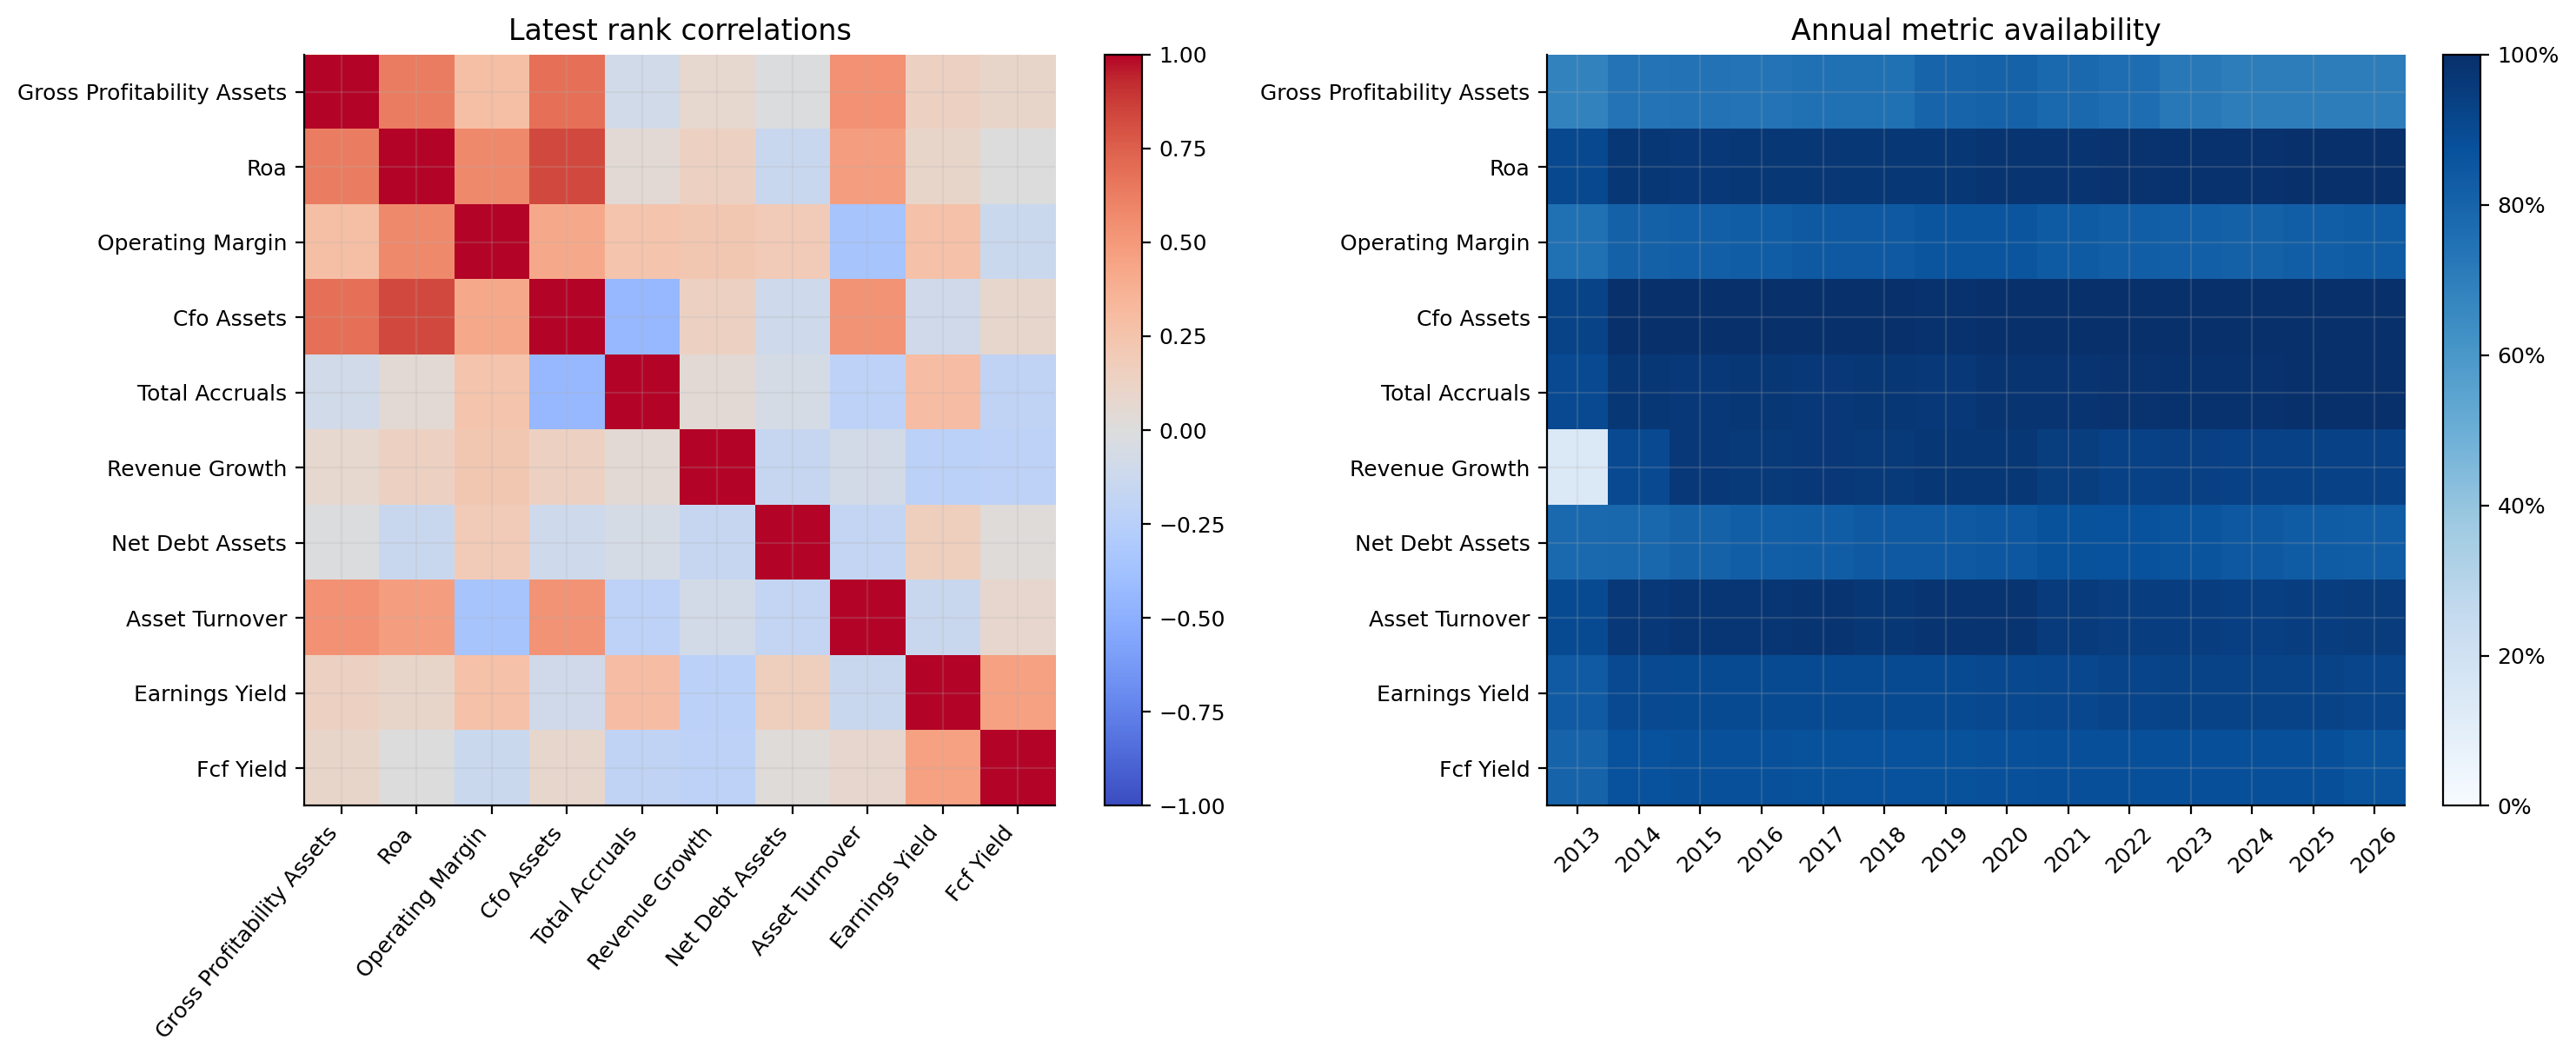

In [37]:
diagnostic_metrics = [
    "gross_profitability_assets", "roa", "roe", "roic_proxy", "operating_margin",
    "cfo_assets", "fcf_assets", "cfo_net_income", "total_accruals",
    "revenue_growth", "operating_income_growth", "cfo_growth", "eps_growth",
    "net_debt_assets", "interest_coverage", "current_ratio", "cash_assets",
    "asset_turnover", "receivable_turnover", "inventory_turnover",
    "net_shareholder_yield", "share_count_dilution", "earnings_yield", "fcf_yield",
    "book_to_market", "ebit_ev",
    "fin_roa", "fin_roe", "fin_equity_assets", "fin_assets_equity",
    "fin_bvps_growth", "fin_roa_variability", "fin_operating_expense_ratio",
    "fin_earnings_yield", "fin_book_to_market", "fin_net_payout_yield",
]
diagnostic_metrics = [column for column in diagnostic_metrics if column in fundamental_metrics]
coverage_diagnostics = (
    fundamental_metrics.assign(year=fundamental_metrics["decision_date"].dt.year)
    .groupby(["year", "score_family"])[diagnostic_metrics]
    .agg(lambda values: values.notna().mean())
)
latest_metrics = fundamental_metrics[
    fundamental_metrics["decision_date"].eq(fundamental_metrics["decision_date"].max())
]
distribution_summary = latest_metrics[diagnostic_metrics].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
).T
peer_medians = latest_metrics.groupby("score_family")[diagnostic_metrics].median().T

corr_columns = [
    column for column in [
        "gross_profitability_assets", "roa", "operating_margin", "cfo_assets",
        "total_accruals", "revenue_growth", "net_debt_assets",
        "asset_turnover", "earnings_yield", "fcf_yield",
    ] if latest_metrics[column].notna().sum() >= 30
]
corr = latest_metrics[corr_columns].corr(method="spearman")
coverage_plot = (
    fundamental_metrics[
        fundamental_metrics["score_family"].eq("corporate")
        & fundamental_metrics["decision_date"].dt.year.ge(2013)
    ]
    .assign(year=lambda frame: frame["decision_date"].dt.year)
    .groupby("year")[corr_columns]
    .agg(lambda values: values.notna().mean())
)
fig, axes = plt.subplots(1, 2, figsize=(16, 6.2), gridspec_kw={"width_ratios": [1.3, 1]})
im = axes[0].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_xticks(range(len(corr_columns)))
axes[0].set_xticklabels([column.replace("_", " ").title() for column in corr_columns], rotation=50, ha="right")
axes[0].set_yticks(range(len(corr_columns)))
axes[0].set_yticklabels([column.replace("_", " ").title() for column in corr_columns])
axes[0].set_title("Latest rank correlations")
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
coverage_view = coverage_plot.T
coverage_image = axes[1].imshow(coverage_view, aspect="auto", cmap="Blues", vmin=0, vmax=1)
axes[1].set_yticks(range(len(coverage_view)), [column.replace("_", " ").title() for column in coverage_view.index])
axes[1].set_xticks(range(len(coverage_view.columns)), coverage_view.columns, rotation=45)
axes[1].set_title("Annual metric availability")
fig.colorbar(coverage_image, ax=axes[1], fraction=0.046, pad=0.04, format=lambda value, _: f"{value:.0%}")
plt.tight_layout()
plt.show()

extremes = latest_metrics.nlargest(12, "warning_penalty")[
    ["ticker", "entity_name", "score_family", "industry", "warning_penalty",
     "severe_warning_count", "piotroski_f_score", "altman_z", "beneish_m"]
]

In [38]:
def money(value):
    if pd.isna(value):
        return "—"
    magnitude = abs(float(value))
    if magnitude >= 1e12:
        return f"${value / 1e12:,.2f}T"
    if magnitude >= 1e9:
        return f"${value / 1e9:,.2f}B"
    if magnitude >= 1e6:
        return f"${value / 1e6:,.1f}M"
    return f"${value:,.2f}"


def percentage(value):
    return "—" if pd.isna(value) else f"{value:.1%}"


def clean_label(value):
    return str(value).replace("_", " ").title()


def format_metric(name, value):
    if pd.isna(value):
        return "—"
    if any(token in name for token in [
        "margin", "yield", "growth", "change", "assets", "dilution", "frequency",
    ]):
        return percentage(value)
    if any(token in name for token in [
        "price_", "turnover", "coverage", "ratio", "conversion", "multiplier",
    ]):
        return f"{value:,.2f}×"
    return f"{value:,.3f}"


def peer_table(current, peers, metrics, lower_is_better=()):
    favorable = pd.Series({
        metric: peers[metric].rank(pct=True).get(current.name, np.nan)
        for metric in metrics
    })
    for metric in lower_is_better:
        favorable[metric] = 1.0 - favorable[metric]
    comparison = pd.DataFrame({
        "company": current[metrics],
        "peer 25th percentile": peers[metrics].quantile(0.25),
        "peer median": peers[metrics].median(),
        "peer 75th percentile": peers[metrics].quantile(0.75),
        "favorable percentile": favorable,
    })
    formatted = comparison.astype(object)
    for metric in metrics:
        for column in comparison.columns[:-1]:
            formatted.loc[metric, column] = format_metric(metric, comparison.loc[metric, column])
        formatted.loc[metric, "favorable percentile"] = percentage(
            comparison.loc[metric, "favorable percentile"]
        )
    return comparison, formatted


def report_style(frame, caption):
    return (
        frame.rename(index=clean_label, columns=clean_label).style
        .set_caption(caption)
        .set_properties(**{"text-align": "right"})
        .set_table_styles([
            {"selector": "caption", "props": "caption-side: top; font-weight: 600; text-align: left;"},
            {"selector": "th", "props": "text-align: left;"},
        ])
    )


def company_snapshot(current):
    return pd.DataFrame({
        "value": [
            money(current["price"]), money(current["market_cap"]),
            money(current["enterprise_value"]), current["filed_date"].date(),
            current["latest_period_end"].date(), current["industry"],
        ]
    }, index=[
        "price", "market cap", "enterprise value", "latest filing date",
        "latest period end", "industry",
    ])


def financial_snapshot(current):
    return pd.DataFrame({
        "value": [
            money(current["revenue"]), money(current["operating_income"]),
            money(current["net_income"]), money(current["cfo"]),
            money(current["free_cash_flow"]), money(current["total_assets"]),
            money(current["total_debt"]), money(current["common_equity"]),
        ]
    }, index=[
        "revenue TTM", "operating income TTM", "net income TTM", "CFO TTM",
        "FCF TTM", "assets", "debt", "equity",
    ])


def corporate_report(ticker):
    company = fundamental_metrics[
        fundamental_metrics["ticker"].eq(ticker)
    ].sort_values("decision_date")
    current = company.iloc[-1]
    history = (
        company.dropna(subset=["latest_quarter_end"])
        .drop_duplicates("latest_quarter_end", keep="last")
        .tail(12).set_index("latest_quarter_end")
    )
    cross_section = fundamental_metrics[
        fundamental_metrics["decision_date"].eq(current["decision_date"])
        & fundamental_metrics["score_family"].eq("corporate")
    ]
    industry = cross_section[cross_section["industry"].eq(current["industry"])]
    peers = industry if len(industry) >= 10 else cross_section
    metrics = [
        "operating_margin", "roa", "cfo_assets", "revenue_growth",
        "net_debt_assets", "earnings_yield", "fcf_yield", "net_shareholder_yield",
    ]
    comparison, comparison_display = peer_table(
        current, peers, metrics, lower_is_better=("net_debt_assets",)
    )
    display(report_style(
        company_snapshot(current),
        f"{ticker} · {current['entity_name']} · snapshot",
    ))
    display(report_style(
        financial_snapshot(current),
        f"{ticker} · trailing-twelve-month financial summary",
    ))
    display(report_style(
        comparison_display,
        f"{ticker} · {current['industry']} peers · n={len(peers)}",
    ))

    warning_columns = [
        column for column in warning_penalties
        if column.startswith("warning_") and not column.startswith("warning_fin_")
    ]
    active_warnings = [
        clean_label(column.replace("warning_", ""))
        for column in warning_columns
        if pd.notna(current[column]) and bool(current[column])
    ]
    diagnostics = pd.DataFrame({
        "value": [
            current["piotroski_f_score"], current["altman_z"], current["beneish_m"],
            int(current["warning_penalty"]),
            ", ".join(active_warnings) if active_warnings else "None",
        ]
    }, index=[
        "Piotroski F-score", "Altman Z-score", "Beneish M-score",
        "weighted red-flag points", "active red flags",
    ])
    display(report_style(diagnostics, f"{ticker} · traditional diagnostics"))

    revenue = history["revenue_q"].div(1e9)
    operating_margin = history["operating_margin"]
    cash = history[["net_income_q", "cfo_q"]].assign(
        free_cash_flow=history["cfo_q"] - history["capex_q"]
    ).div(1e9)
    cash.columns = ["Net income", "Operating cash flow", "Free cash flow"]
    percentile_plot = comparison["favorable percentile"].sort_values()
    quarter_positions = np.arange(len(history))
    quarter_ticks = np.linspace(
        0, len(history) - 1, min(6, len(history))
    ).round().astype(int)
    quarter_labels = [
        history.index[position].strftime("%Y-%m")
        for position in quarter_ticks
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    axes[0].bar(quarter_positions, revenue, color=blue, width=0.68)
    margin_axis = axes[0].twinx()
    margin_axis.plot(
        quarter_positions, operating_margin,
        color=gold, marker="o", linewidth=2,
    )
    axes[0].set_xticks(
        quarter_ticks, quarter_labels, rotation=45, ha="right"
    )
    axes[0].set_title(f"{ticker} revenue and operating margin")
    axes[0].set_ylabel("$ billions")
    margin_axis.set_ylabel("Operating margin")
    margin_axis.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    margin_axis.grid(False)
    cash_positions = quarter_positions
    cash_width = 0.24
    for cash_offset, (cash_name, cash_color) in enumerate(
        zip(cash.columns, [coral, teal, gold])
    ):
        axes[1].bar(
            cash_positions + (cash_offset - 1) * cash_width,
            cash[cash_name],
            width=cash_width,
            color=cash_color,
            label=cash_name,
        )
    axes[1].set_xticks(
        quarter_ticks, quarter_labels, rotation=45, ha="right"
    )
    axes[1].set_title("Net income, CFO, and FCF")
    axes[1].set_ylabel("$ billions")
    axes[1].legend(ncol=1, frameon=False)
    axes[2].hlines(
        range(len(percentile_plot)), 0.5, percentile_plot,
        color=grid, linewidth=4,
    )
    axes[2].scatter(
        percentile_plot, range(len(percentile_plot)),
        s=55, color=np.where(percentile_plot.ge(0.5), teal, coral), zorder=3,
    )
    axes[2].axvline(0.5, color=muted, linestyle="--", linewidth=1)
    axes[2].set_yticks(
        range(len(percentile_plot)),
        [clean_label(value) for value in percentile_plot.index],
    )
    axes[2].set_xlim(0, 1)
    axes[2].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    axes[2].set_title("Peer-group percentiles")
    for axis in axes:
        axis.set_xlabel("")
        finish_axes(axis)
    plt.tight_layout()
    plt.show()


def financial_report(ticker):
    company = fundamental_metrics[
        fundamental_metrics["ticker"].eq(ticker)
    ].sort_values("decision_date")
    current = company.iloc[-1]
    history = (
        company.dropna(subset=["latest_quarter_end"])
        .drop_duplicates("latest_quarter_end", keep="last")
        .tail(12).set_index("latest_quarter_end")
    )
    peers = fundamental_metrics[
        fundamental_metrics["decision_date"].eq(current["decision_date"])
        & fundamental_metrics["score_family"].eq("financial")
    ]
    metrics = [
        "fin_roa", "fin_roe", "fin_equity_assets", "fin_assets_equity",
        "fin_bvps_growth", "fin_earnings_yield", "fin_book_to_market",
        "fin_net_payout_yield", "fin_share_dilution",
    ]
    comparison, comparison_display = peer_table(
        current, peers, metrics,
        lower_is_better=("fin_assets_equity", "fin_share_dilution"),
    )
    display(report_style(
        company_snapshot(current),
        f"{ticker} · {current['entity_name']} · snapshot",
    ))
    display(report_style(
        financial_snapshot(current),
        f"{ticker} · trailing-twelve-month financial summary",
    ))
    display(report_style(
        comparison_display,
        f"{ticker} · financial peers · n={len(peers)}",
    ))

    warning_columns = [
        column for column in warning_penalties if column.startswith("warning_fin_")
    ]
    active_warnings = [
        clean_label(column.replace("warning_fin_", ""))
        for column in warning_columns
        if pd.notna(current[column]) and bool(current[column])
    ]
    diagnostics = pd.DataFrame({
        "value": [
            int(current["warning_penalty"]),
            ", ".join(active_warnings) if active_warnings else "None",
            percentage(current["fin_net_payout_yield"]),
            percentage(current["fin_share_dilution"]),
        ]
    }, index=[
        "weighted red-flag points", "active red flags",
        "net payout yield", "share dilution",
    ])
    display(report_style(diagnostics, f"{ticker} · financial diagnostics"))

    revenue = history["revenue_q"].div(1e9)
    revenue_label = "Quarterly revenue"
    if revenue.notna().sum() < 3:
        revenue = history["revenue"].div(1e9)
        revenue_label = "TTM revenue"
    if revenue.notna().sum() < 3:
        revenue = history["pretax_income_q"].div(1e9)
        revenue_label = "Quarterly pretax income"
    net_income = history["net_income_q"].div(1e9)
    returns_on_capital = history[["fin_roa", "fin_roe"]].rename(
        columns={"fin_roa": "ROA", "fin_roe": "ROE"}
    )
    book = history[["book_value_per_share", "fin_tangible_bvps"]].rename(
        columns={
            "book_value_per_share": "Book value per share",
            "fin_tangible_bvps": "Tangible book value per share",
        }
    )
    quarter_positions = np.arange(len(history))
    quarter_ticks = np.linspace(
        0, len(history) - 1, min(6, len(history))
    ).round().astype(int)
    quarter_labels = [
        history.index[position].strftime("%Y-%m")
        for position in quarter_ticks
    ]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    axes[0].bar(quarter_positions, revenue, color=blue, width=0.68)
    income_axis = axes[0].twinx()
    income_axis.plot(
        quarter_positions, net_income,
        color=gold, marker="o", linewidth=2,
    )
    axes[0].set_xticks(
        quarter_ticks, quarter_labels, rotation=45, ha="right"
    )
    axes[0].set_title(f"{ticker} {revenue_label.lower()} and net income")
    axes[0].set_ylabel(f"{revenue_label} · $ billions")
    income_axis.set_ylabel("Quarterly net income · $ billions")
    income_axis.grid(False)
    for name, color in zip(returns_on_capital, [teal, gold]):
        axes[1].plot(
            quarter_positions, returns_on_capital[name],
            color=color, linewidth=2.1, marker="o", markersize=3,
            label=name,
        )
    axes[1].set_xticks(
        quarter_ticks, quarter_labels, rotation=45, ha="right"
    )
    axes[1].set_title("ROA and ROE")
    axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    axes[1].legend(frameon=False)
    for name, color in zip(book, [blue, violet]):
        axes[2].plot(
            quarter_positions, book[name],
            color=color, linewidth=2.1, marker="o", markersize=3,
            label=name,
        )
    axes[2].set_xticks(
        quarter_ticks, quarter_labels, rotation=45, ha="right"
    )
    axes[2].set_title("Book and tangible-book value per share")
    axes[2].set_ylabel("$ per share")
    axes[2].legend(frameon=False)
    for axis in axes:
        axis.set_xlabel("")
        finish_axes(axis)
    plt.tight_layout()
    plt.show()


,Value
Price,$289.36
Market Cap,$4.25T
Enterprise Value,$4.29T
Latest Filing Date,2026-05-01
Latest Period End,2026-04-17
Industry,ELECTRONIC COMPUTERS


,Value
Revenue Ttm,$451.44B
Operating Income Ttm,$147.37B
Net Income Ttm,$122.58B
Cfo Ttm,$140.22B
Fcf Ttm,$129.17B
Assets,$371.08B
Debt,$82.71B
Equity,$106.49B


,Company,Peer 25Th Percentile,Peer Median,Peer 75Th Percentile,Favorable Percentile
Operating Margin,32.6%,10.2%,18.2%,25.5%,87.7%
Roa,0.327,0.037,0.069,0.116,98.3%
Cfo Assets,37.4%,7.5%,11.5%,17.3%,98.5%
Revenue Growth,12.8%,3.4%,7.9%,13.3%,73.2%
Net Debt Assets,10.0%,11.9%,22.2%,34.4%,78.6%
Earnings Yield,2.9%,2.5%,3.7%,5.3%,33.4%
Fcf Yield,3.0%,2.2%,3.6%,5.9%,37.4%
Net Shareholder Yield,—,2.2%,3.4%,5.4%,—


,Value
Piotroski F-Score,9.000000
Altman Z-Score,12.241694
Beneish M-Score,-2.522874
Weighted Red-Flag Points,0
Active Red Flags,None


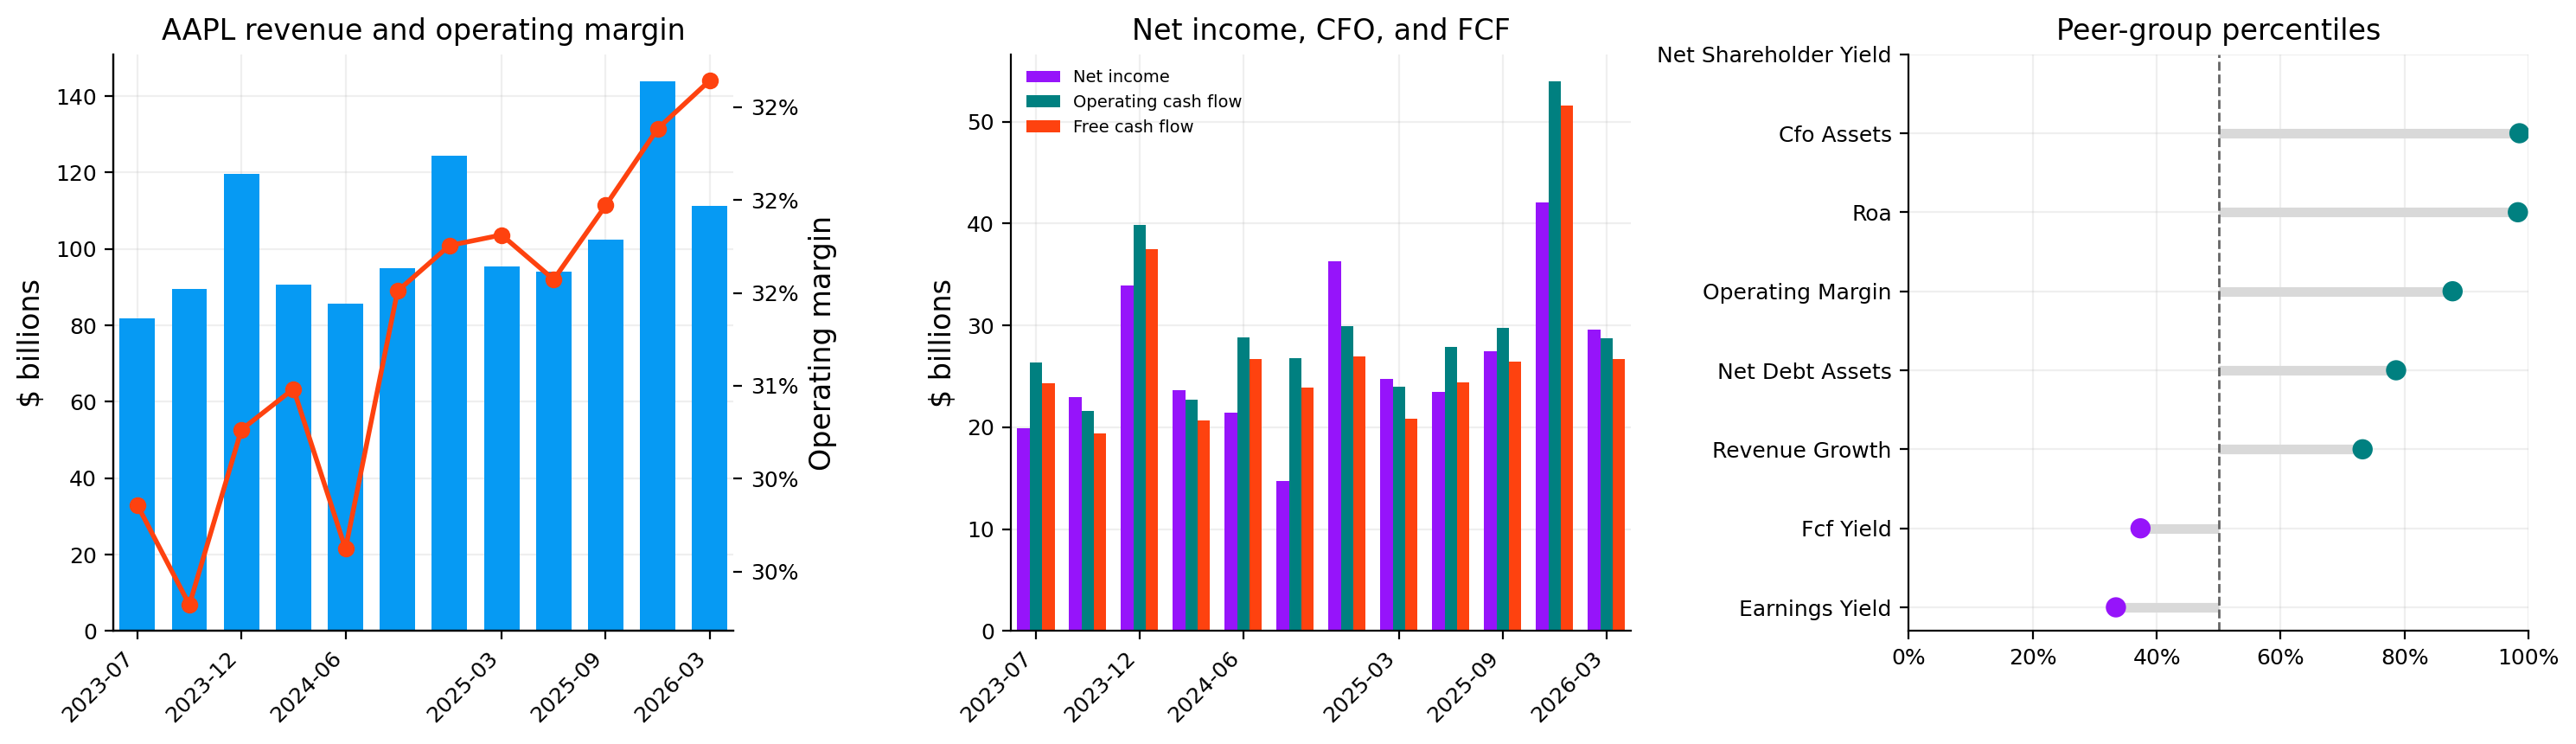

In [39]:
corporate_report("AAPL")


,Value
Price,$353.33
Market Cap,$4.28T
Enterprise Value,$4.25T
Latest Filing Date,2026-04-30
Latest Period End,2026-03-31
Industry,"SERVICES-COMPUTER PROGRAMMING, DATA PROCESSING, ETC."


,Value
Revenue Ttm,$422.50B
Operating Income Ttm,$138.13B
Net Income Ttm,$160.21B
Cfo Ttm,$174.35B
Fcf Ttm,$64.43B
Assets,$703.92B
Debt,$10.89B
Equity,$478.75B


,Company,Peer 25Th Percentile,Peer Median,Peer 75Th Percentile,Favorable Percentile
Operating Margin,32.7%,10.2%,18.2%,25.5%,88.3%
Roa,0.247,0.037,0.069,0.116,95.8%
Cfo Assets,26.8%,7.5%,11.5%,17.3%,94.3%
Revenue Growth,17.5%,3.4%,7.9%,13.3%,81.7%
Net Debt Assets,-3.9%,11.9%,22.2%,34.4%,92.2%
Earnings Yield,3.7%,2.5%,3.7%,5.3%,51.9%
Fcf Yield,1.5%,2.2%,3.6%,5.9%,17.7%
Net Shareholder Yield,—,2.2%,3.4%,5.4%,—


,Value
Piotroski F-Score,8.000000
Altman Z-Score,13.593468
Beneish M-Score,-2.115414
Weighted Red-Flag Points,0
Active Red Flags,None


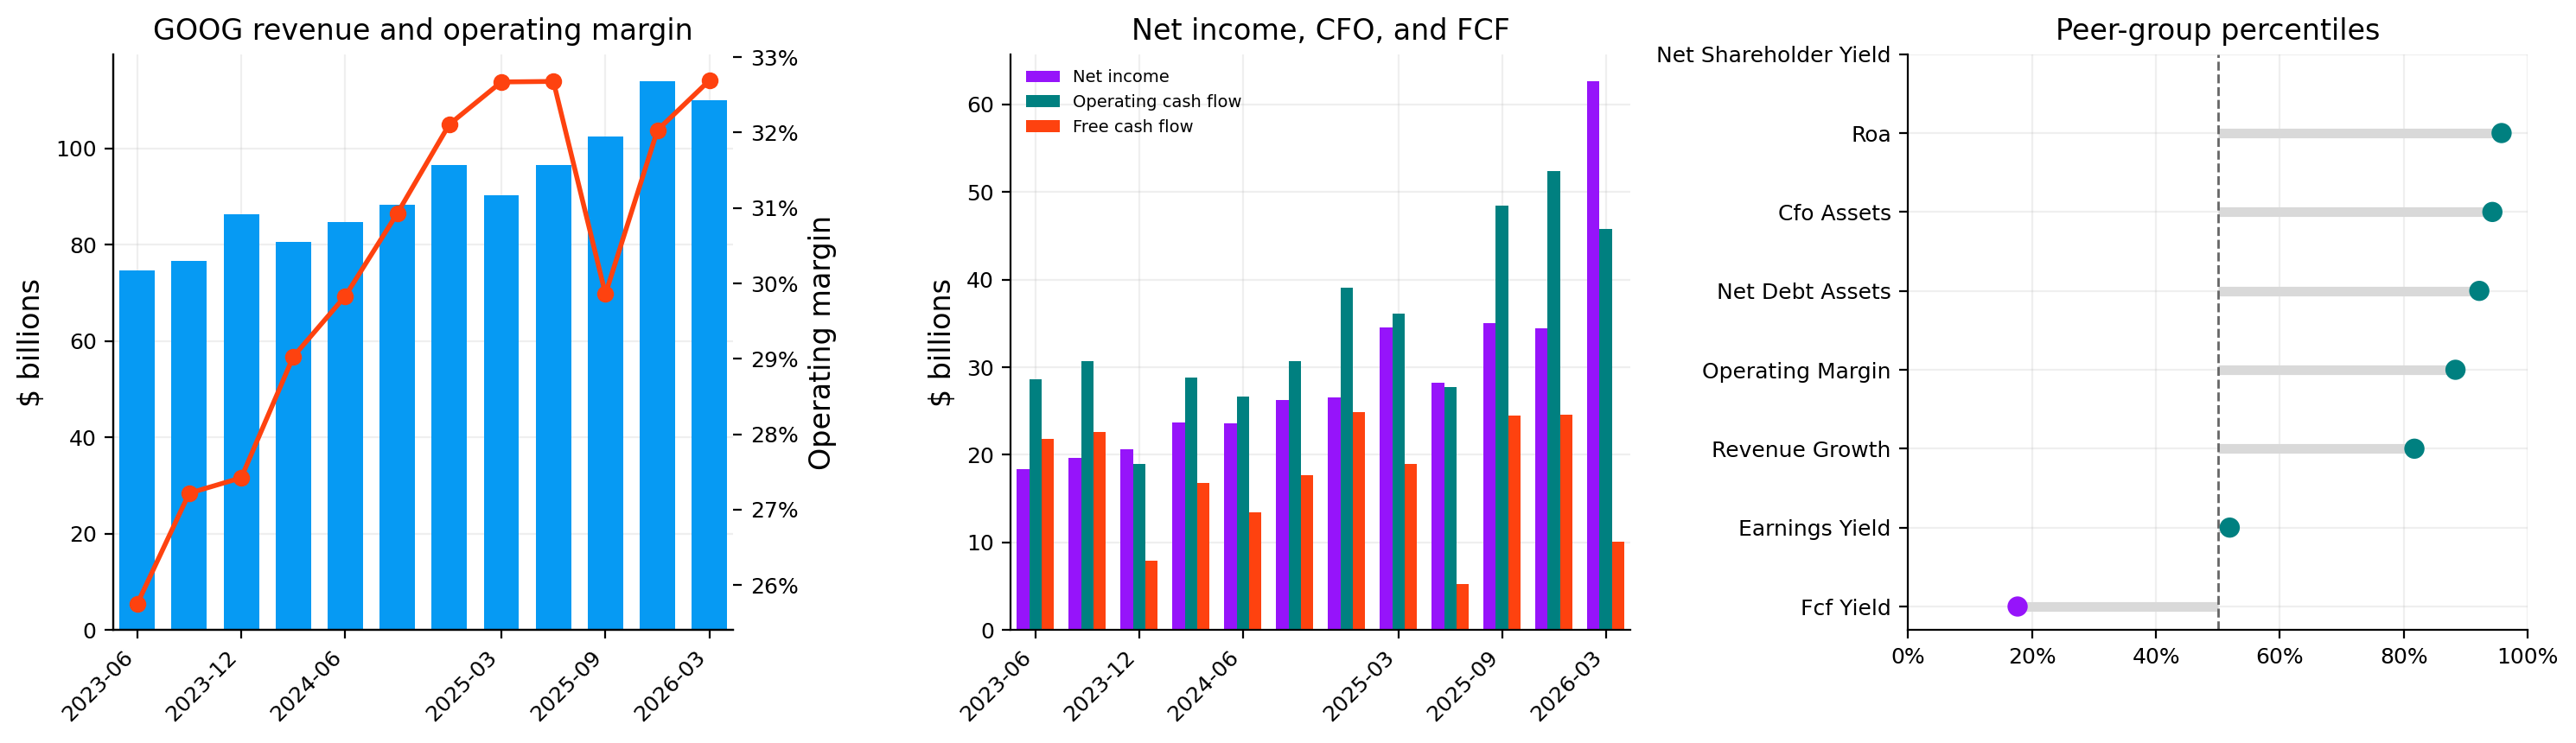

In [40]:
corporate_report("GOOG")


,Value
Price,"$1,199.43"
Market Cap,$1.13T
Enterprise Value,$1.17T
Latest Filing Date,2026-04-30
Latest Period End,2026-04-27
Industry,PHARMACEUTICAL PREPARATIONS


,Value
Revenue Ttm,$72.25B
Operating Income Ttm,—
Net Income Ttm,$25.28B
Cfo Ttm,$20.48B
Fcf Ttm,—
Assets,$116.58B
Debt,$43.37B
Equity,$31.20B


,Company,Peer 25Th Percentile,Peer Median,Peer 75Th Percentile,Favorable Percentile
Operating Margin,—,17.1%,24.3%,24.4%,—
Roa,0.221,0.050,0.082,0.138,100.0%
Cfo Assets,17.9%,10.5%,13.5%,16.0%,90.9%
Revenue Growth,47.4%,2.2%,5.9%,8.7%,100.0%
Net Debt Assets,32.7%,30.2%,34.0%,40.3%,55.6%
Earnings Yield,2.2%,2.4%,3.4%,5.1%,30.0%
Fcf Yield,—,4.4%,4.7%,7.4%,—
Net Shareholder Yield,—,3.0%,3.5%,6.6%,—


,Value
Piotroski F-Score,8.000000
Altman Z-Score,nan
Beneish M-Score,-1.773866
Weighted Red-Flag Points,5
Active Red Flags,Beneish Warning


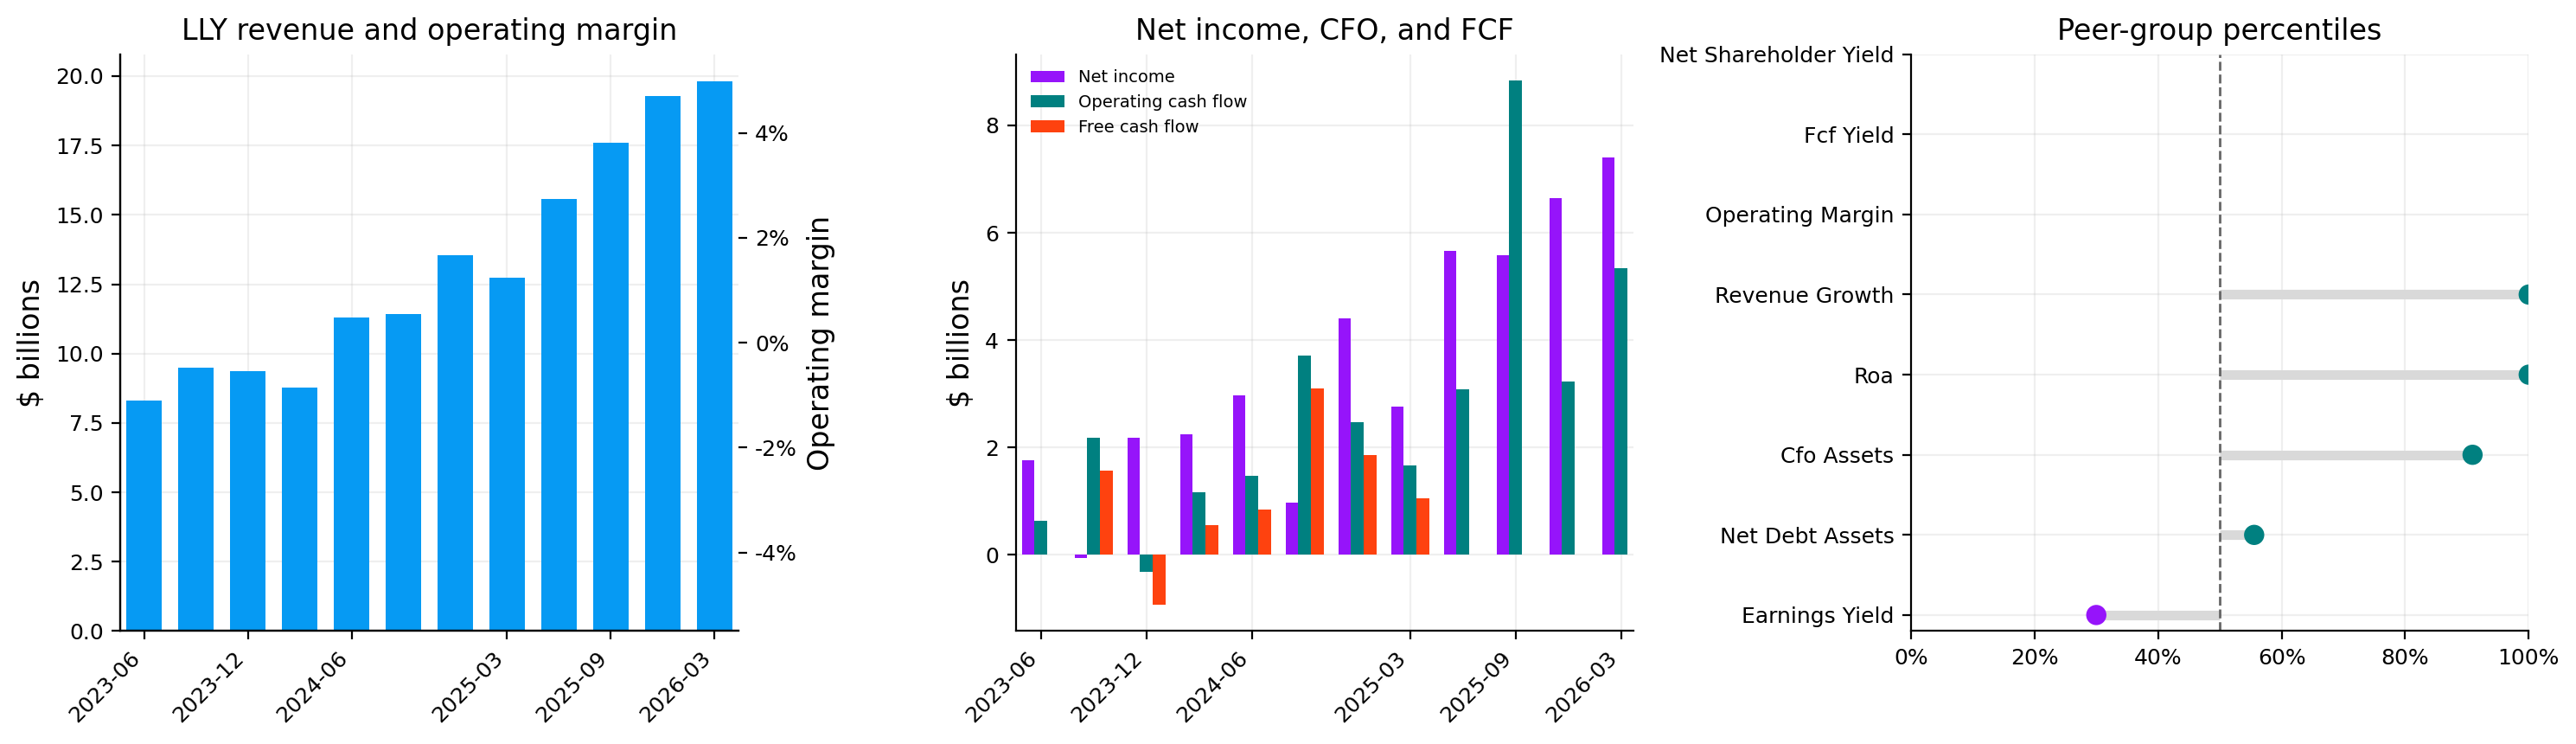

In [41]:
corporate_report("LLY")


,Value
Price,"$1,062.93"
Market Cap,$490.53B
Enterprise Value,$522.67B
Latest Filing Date,2026-05-06
Latest Period End,2026-03-31
Industry,CONSTRUCTION MACHINERY & EQUIP


,Value
Revenue Ttm,$70.75B
Operating Income Ttm,$11.66B
Net Income Ttm,$9.43B
Cfo Ttm,$12.32B
Fcf Ttm,$9.48B
Assets,$95.55B
Debt,$36.21B
Equity,—


,Company,Peer 25Th Percentile,Peer Median,Peer 75Th Percentile,Favorable Percentile
Operating Margin,16.5%,10.2%,18.2%,25.5%,43.4%
Roa,0.097,0.037,0.069,0.116,65.8%
Cfo Assets,12.7%,7.5%,11.5%,17.3%,58.0%
Revenue Growth,11.8%,3.4%,7.9%,13.3%,69.2%
Net Debt Assets,33.6%,11.9%,22.2%,34.4%,26.5%
Earnings Yield,1.9%,2.5%,3.7%,5.3%,18.8%
Fcf Yield,1.9%,2.2%,3.6%,5.9%,20.9%
Net Shareholder Yield,—,2.2%,3.4%,5.4%,—


,Value
Piotroski F-Score,5.000000
Altman Z-Score,6.126261
Beneish M-Score,-2.334820
Weighted Red-Flag Points,0
Active Red Flags,None


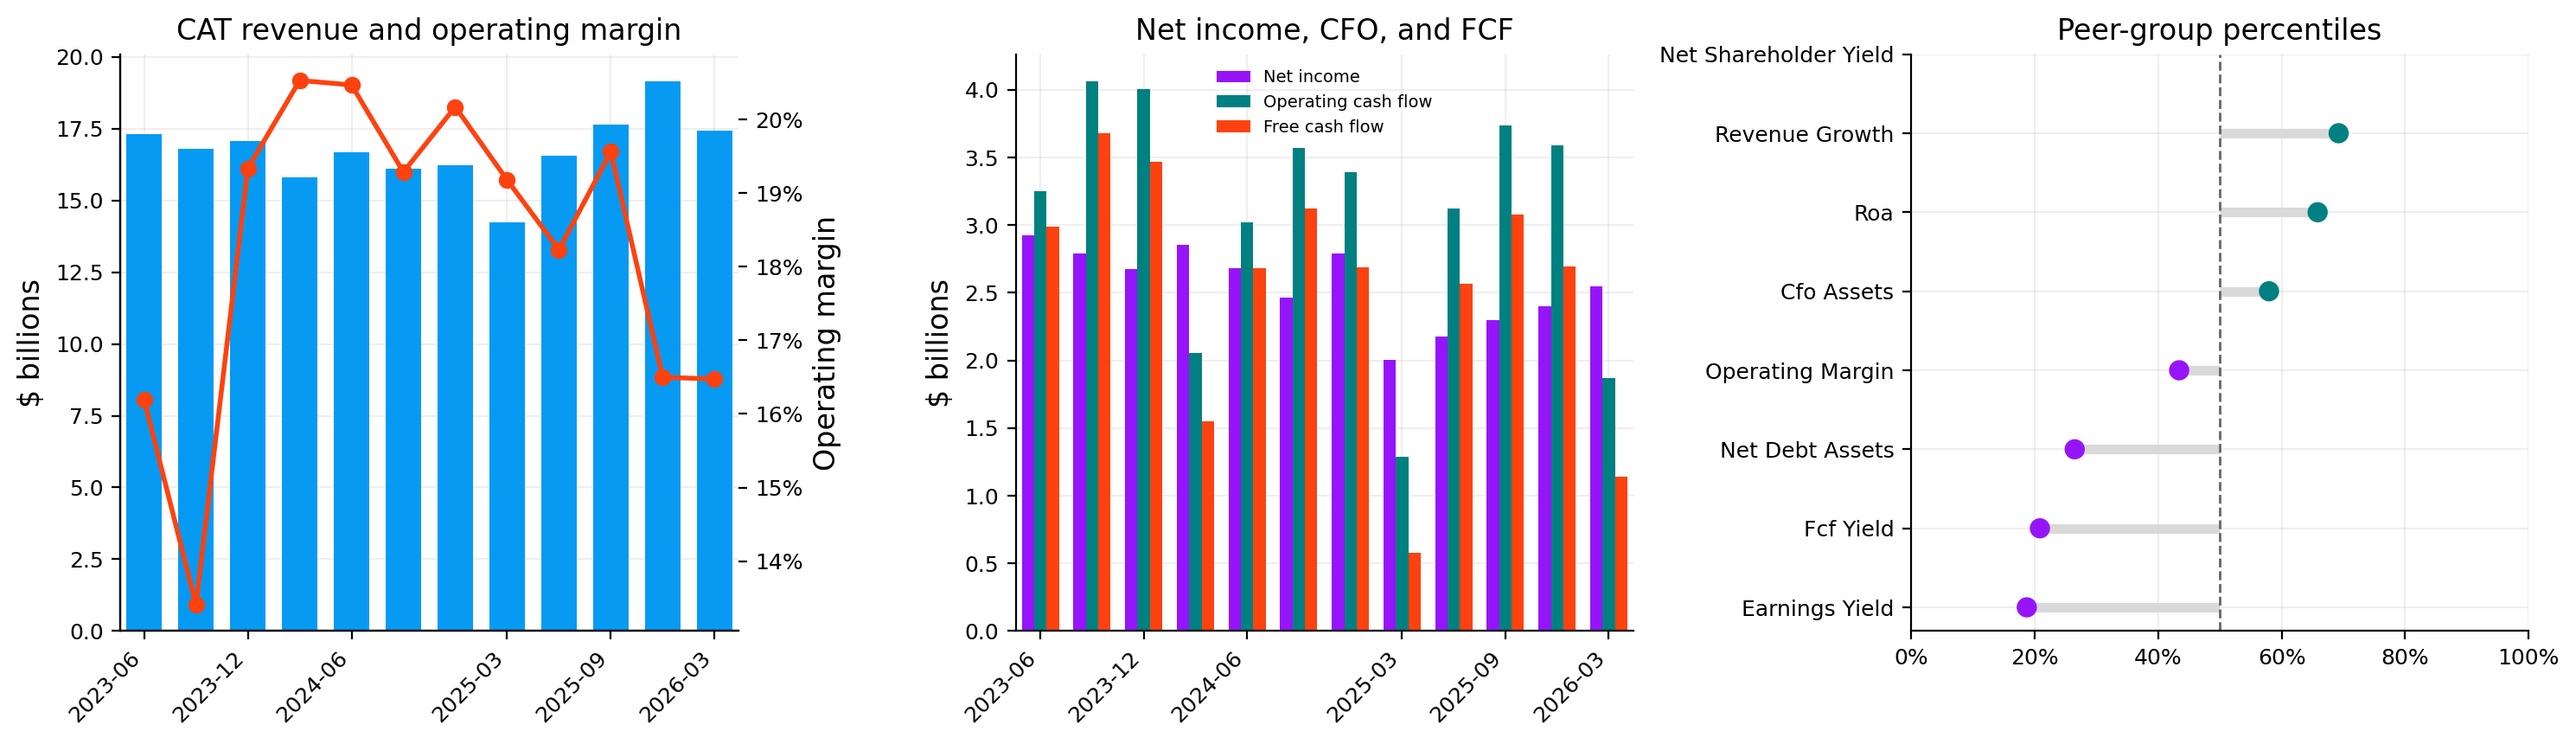

In [42]:
corporate_report("CAT")


,Value
Price,$325.86
Market Cap,$877.08B
Enterprise Value,—
Latest Filing Date,2026-05-01
Latest Period End,2026-03-31
Industry,NATIONAL COMMERCIAL BANKS


,Value
Revenue Ttm,$182.45B
Operating Income Ttm,—
Net Income Ttm,$58.90B
Cfo Ttm,$-107.70B
Fcf Ttm,—
Assets,$4.90T
Debt,—
Equity,$364.04B


,Company,Peer 25Th Percentile,Peer Median,Peer 75Th Percentile,Favorable Percentile
Fin Roa,0.013,0.010,0.022,0.042,35.3%
Fin Roe,0.162,0.097,0.139,0.195,65.2%
Fin Equity Assets,7.4%,9.5%,16.4%,26.7%,16.7%
Fin Assets Equity,1346.1%,374.7%,608.1%,1049.7%,15.2%
Fin Bvps Growth,7.4%,6.0%,8.8%,14.7%,43.9%
Fin Earnings Yield,6.7%,4.9%,6.7%,8.5%,52.5%
Fin Book To Market,0.415,0.375,0.507,0.709,35.6%
Fin Net Payout Yield,—,3.8%,5.6%,6.8%,—
Fin Share Dilution,-3.6%,-4.8%,-2.5%,-0.6%,62.7%


,Value
Weighted Red-Flag Points,0
Active Red Flags,None
Net Payout Yield,—
Share Dilution,-3.6%


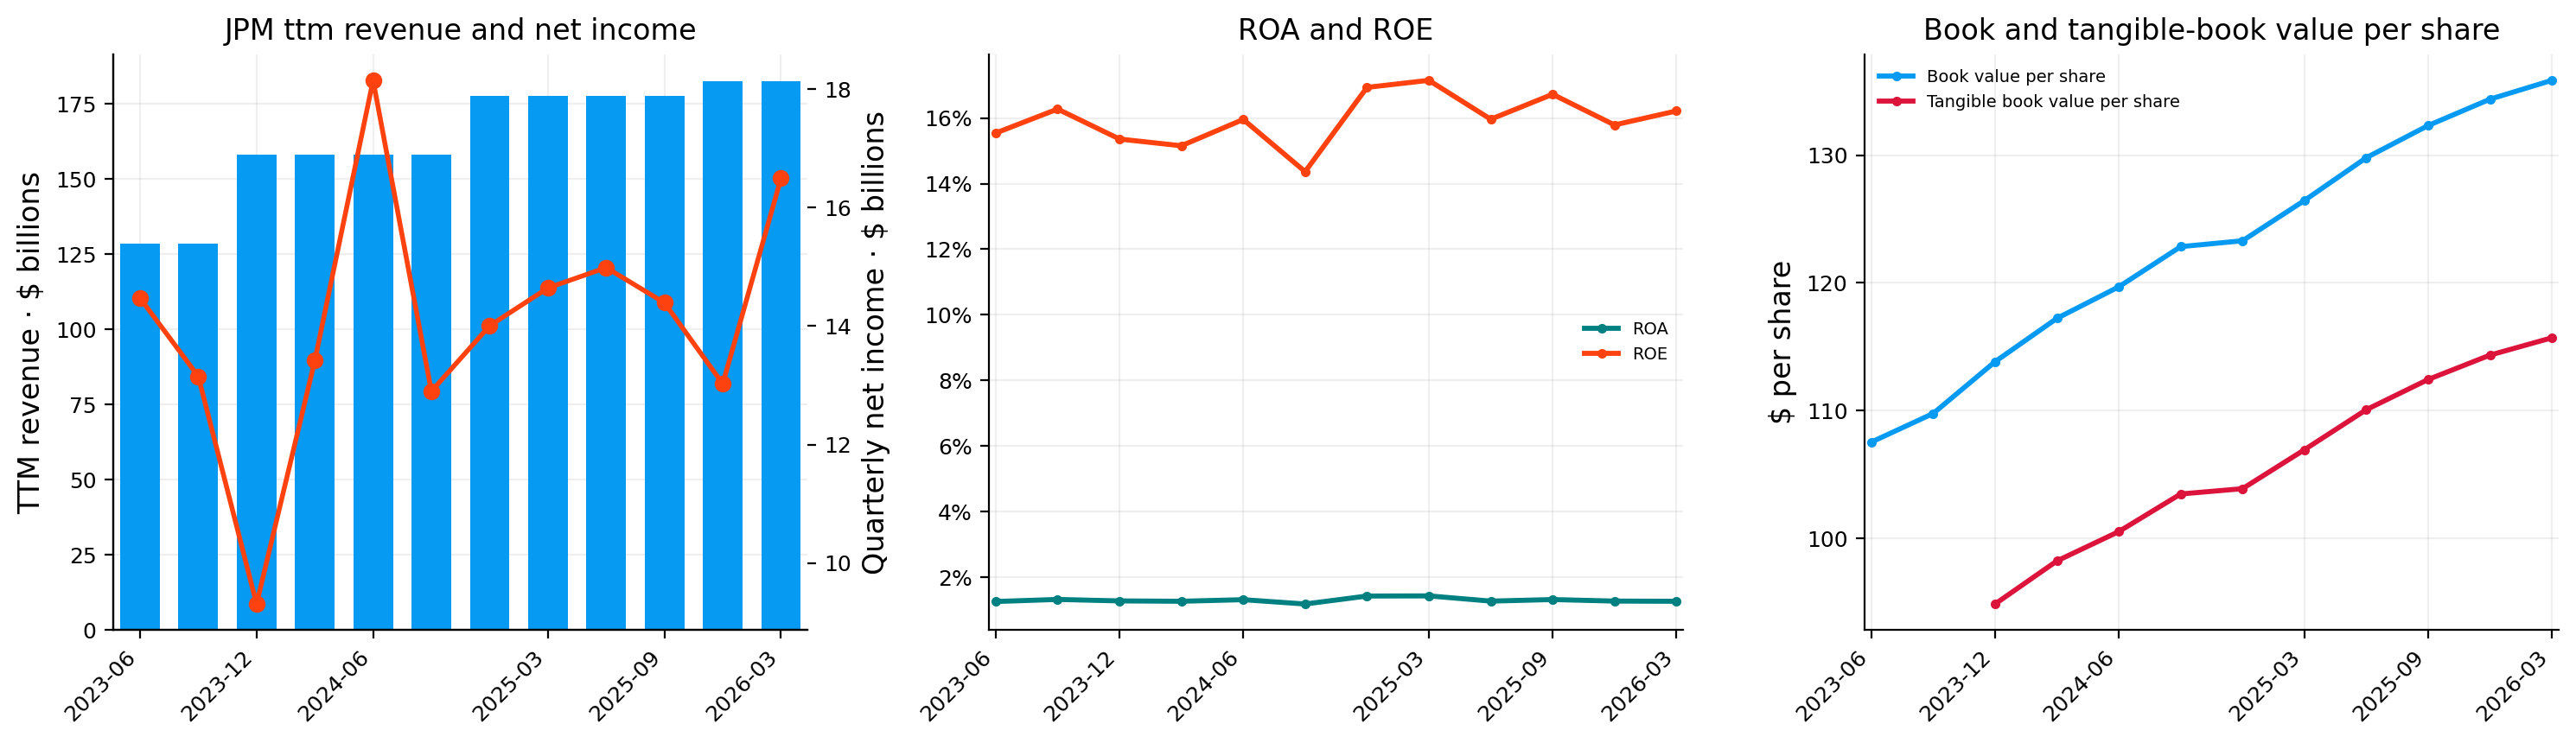

In [43]:
financial_report("JPM")


,Value
Price,"$1,011.37"
Market Cap,$298.36B
Enterprise Value,—
Latest Filing Date,2026-05-01
Latest Period End,2026-04-17
Industry,"SECURITY BROKERS, DEALERS & FLOTATION COMPANIES"


,Value
Revenue Ttm,—
Operating Income Ttm,—
Net Income Ttm,$18.07B
Cfo Ttm,$-39.79B
Fcf Ttm,$-41.92B
Assets,$2.06T
Debt,—
Equity,$122.78B


,Company,Peer 25Th Percentile,Peer Median,Peer 75Th Percentile,Favorable Percentile
Fin Roa,0.009,0.010,0.022,0.042,22.1%
Fin Roe,0.146,0.097,0.139,0.195,53.0%
Fin Equity Assets,6.0%,9.5%,16.4%,26.7%,10.6%
Fin Assets Equity,1677.9%,374.7%,608.1%,1049.7%,9.1%
Fin Bvps Growth,2.7%,6.0%,8.8%,14.7%,8.8%
Fin Earnings Yield,6.1%,4.9%,6.7%,8.5%,41.0%
Fin Book To Market,0.412,0.375,0.507,0.709,33.9%
Fin Net Payout Yield,—,3.8%,5.6%,6.8%,—
Fin Share Dilution,-3.9%,-4.8%,-2.5%,-0.6%,66.1%


,Value
Weighted Red-Flag Points,0
Active Red Flags,None
Net Payout Yield,—
Share Dilution,-3.9%


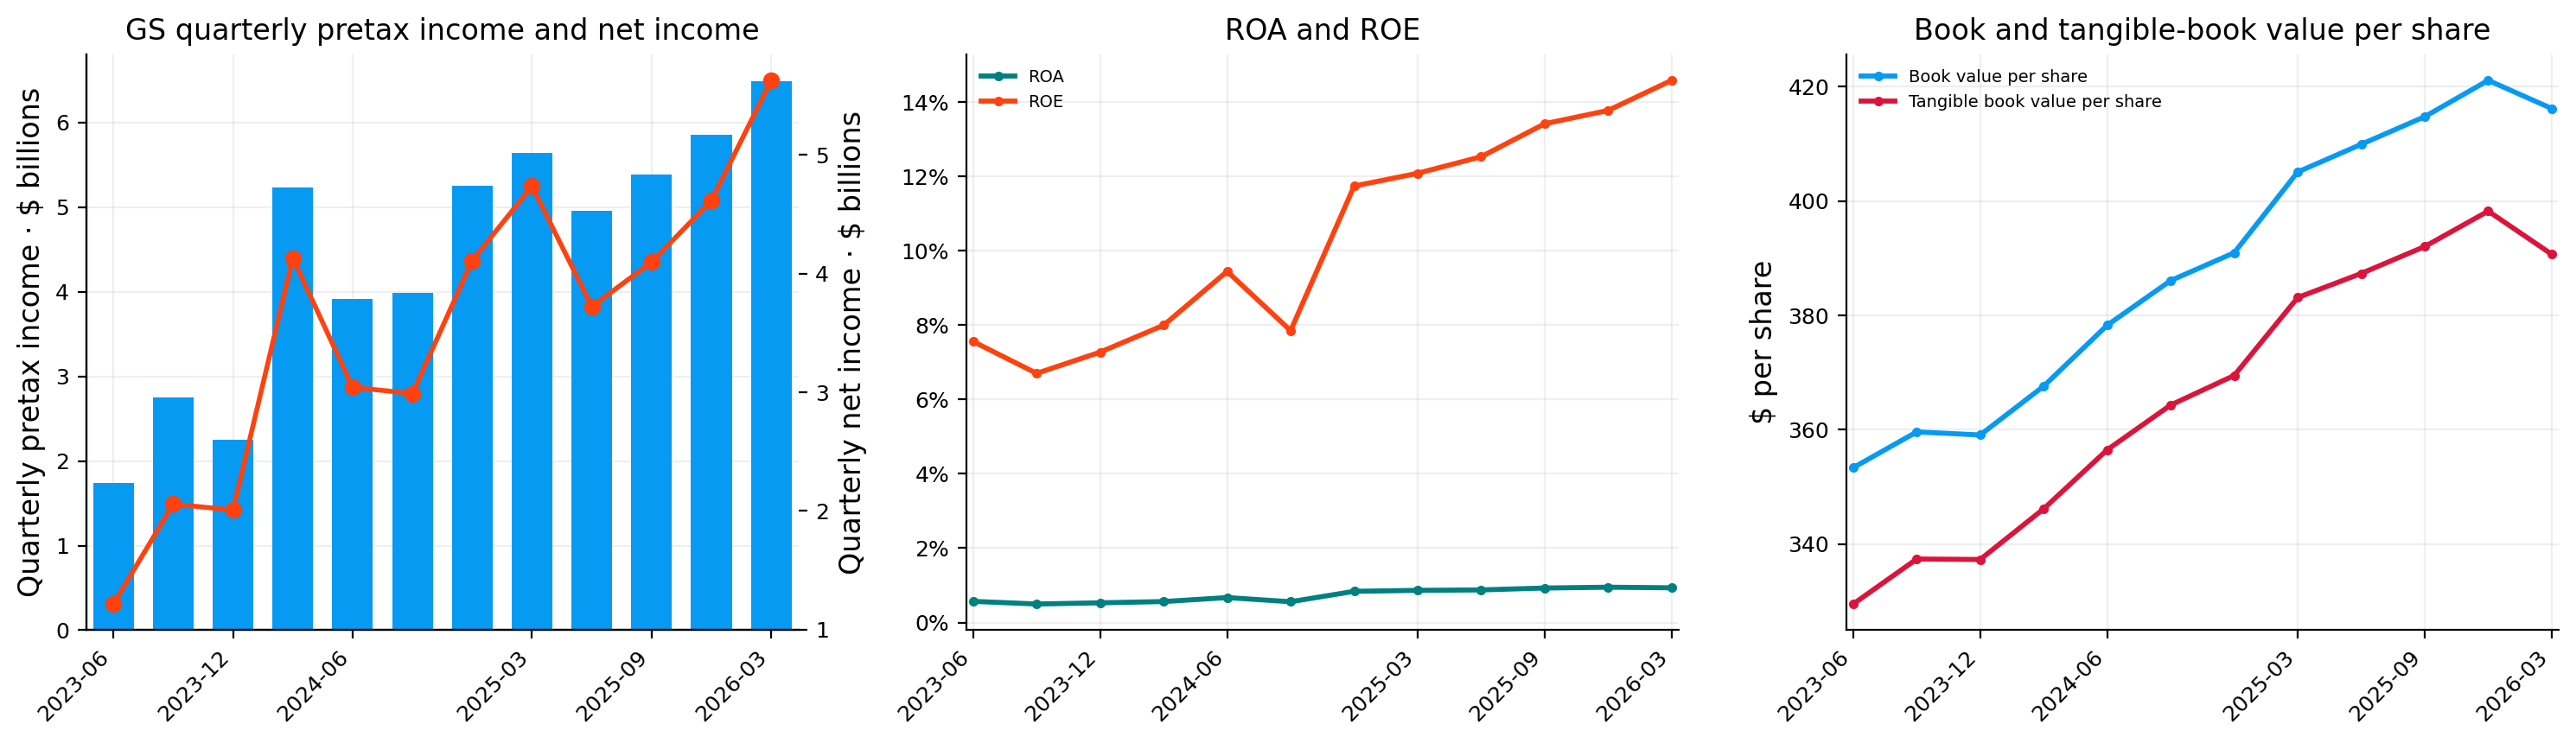

In [44]:
financial_report("GS")


In [45]:
corporate_blocks = {
    "profitability": {
        "gross_profitability_assets": 1.0, "roa": 1.0, "roe": 0.8,
        "roic_proxy": 1.0, "operating_margin": 0.8, "fcf_margin": 0.8,
    },
    "cash_quality": {
        "cfo_assets": 1.0, "fcf_assets": 1.0, "cfo_net_income": 0.8,
        "fcf_conversion": 0.8, "total_accruals": 1.0,
        "positive_cfo_frequency": 0.7, "positive_fcf_frequency": 0.7,
    },
    "growth": {
        "revenue_growth": 1.0, "gross_profit_growth": 0.7,
        "operating_income_growth": 0.8, "cfo_growth": 0.8, "fcf_growth": 0.8,
        "eps_growth": 0.8, "operating_margin_change": 0.7,
        "roa_change": 0.7, "roic_change": 0.7, "cash_conversion_change": 0.5,
    },
    "strength": {
        "net_debt_assets": 1.0, "debt_assets": 0.8, "liabilities_assets": 0.8,
        "interest_coverage": 0.8, "cfo_debt": 0.8, "current_ratio": 0.6,
        "cash_assets": 0.7, "tangible_equity_assets": 0.8,
    },
    "efficiency": {
        "asset_turnover": 1.0, "receivable_turnover": 0.7,
        "inventory_turnover": 0.7, "cash_conversion_cycle": 0.7,
    },
    "capital_allocation": {
        "net_shareholder_yield": 1.0, "share_count_dilution": 1.0,
        "dividend_coverage_cfo": 0.6, "repurchase_yield": 0.7,
        "per_share_growth_spread": 0.7,
    },
    "valuation": {
        "earnings_yield": 1.0, "fcf_yield": 1.0, "ebit_ev": 0.9,
        "sales_ev": 0.6, "book_to_market": 0.7, "tangible_book_to_market": 0.6,
    },
}
corporate_block_weights = {
    "profitability": 0.35, "cash_quality": 0.20, "growth": 0.15,
    "strength": 0.10, "efficiency": 0.05, "capital_allocation": 0.05,
    "valuation": 0.10,
}
financial_blocks = {
    "profitability": {
        "fin_roa": 1.0, "fin_roe": 1.0, "fin_pretax_assets": 0.8, "fin_net_margin": 0.6,
    },
    "capital_strength": {
        "fin_equity_assets": 1.0, "fin_tangible_equity_assets": 1.0,
        "fin_liabilities_assets": 0.8, "fin_assets_equity": 0.8,
    },
    "growth": {
        "fin_revenue_growth": 0.8, "fin_net_income_growth": 0.8,
        "fin_equity_growth": 0.8, "fin_bvps_growth": 1.0, "fin_tbvps_growth": 0.8,
        "fin_roa_change": 0.7, "fin_roe_change": 0.7, "fin_equity_assets_change": 0.8,
    },
    "stability": {
        "fin_roa_variability": 1.0, "fin_roe_variability": 0.8,
        "fin_net_income_variability": 0.8, "fin_positive_earnings_frequency": 1.0,
    },
    "efficiency": {
        "fin_operating_expense_ratio": 1.0, "fin_pretax_margin": 0.8,
        "fin_revenue_assets": 0.8,
    },
    "valuation_return": {
        "fin_earnings_yield": 1.0, "fin_book_to_market": 1.0,
        "fin_tangible_book_to_market": 0.8, "fin_revenue_market_cap": 0.6,
        "fin_net_payout_yield": 0.8, "fin_share_dilution": 0.8,
    },
}
financial_block_weights = {
    "profitability": 0.20, "capital_strength": 0.15, "growth": 0.05,
    "stability": 0.15, "efficiency": 0.15, "valuation_return": 0.30,
}
lower_is_better = {
    "total_accruals", "net_debt_assets", "debt_assets", "liabilities_assets",
    "cash_conversion_cycle", "share_count_dilution",
    "fin_liabilities_assets", "fin_assets_equity", "fin_roa_variability",
    "fin_roe_variability", "fin_net_income_variability",
    "fin_operating_expense_ratio", "fin_share_dilution",
}
all_score_metrics = sorted({
    metric for block in list(corporate_blocks.values()) + list(financial_blocks.values())
    for metric in block
})
metric_directions = {metric: (-1 if metric in lower_is_better else 1) for metric in all_score_metrics}
min_peer_size = 10
min_corporate_metrics = 12
min_financial_metrics = 8
score_metric_coverage = fundamental_metrics.groupby("score_family")[all_score_metrics].agg(
    lambda values: values.notna().mean()
).T
display(score_metric_coverage.style.format("{:.1%}"))


score_family,corporate,financial,unclassified
asset_turnover,91.1%,78.0%,0.0%
book_to_market,85.8%,89.8%,0.0%
cash_assets,97.6%,82.1%,0.0%
cash_conversion_change,73.7%,79.1%,0.0%
cash_conversion_cycle,35.5%,0.0%,0.0%
cfo_assets,94.3%,93.2%,0.0%
cfo_debt,79.0%,30.4%,0.0%
cfo_growth,84.3%,80.7%,0.0%
cfo_net_income,86.3%,90.0%,0.0%
current_ratio,95.9%,20.5%,0.0%


In [46]:
ranked_fundamentals = fundamental_metrics.copy()
raw_metrics = ranked_fundamentals[all_score_metrics].apply(
    pd.to_numeric, errors="coerce"
)
family_groups = [
    ranked_fundamentals["decision_date"],
    ranked_fundamentals["score_family"],
]
peer_groups = family_groups + [ranked_fundamentals["industry"]]

family_metric_groups = raw_metrics.groupby(family_groups, sort=False)
family_count = family_metric_groups.transform("count")
lower = family_metric_groups.transform("quantile", q=0.01)
upper = family_metric_groups.transform("quantile", q=0.99)
clipped = raw_metrics.clip(lower=lower, upper=upper).where(
    family_count.ge(20), raw_metrics
)
family_percentile = clipped.groupby(
    family_groups, sort=False
).rank(pct=True)
peer_metric_groups = clipped.groupby(peer_groups, sort=False)
peer_count = peer_metric_groups.transform("count")
peer_percentile = peer_metric_groups.rank(pct=True).where(
    peer_count.ge(min_peer_size)
)
metric_scores = 100.0 * (
    0.70 * peer_percentile + 0.30 * family_percentile
).fillna(family_percentile)
metric_scores = metric_scores.where(family_count.ge(10))
negative_metrics = [
    metric for metric, direction in metric_directions.items()
    if direction < 0
]
metric_scores[negative_metrics] = 100.0 - metric_scores[negative_metrics]
metric_scores = metric_scores.add_suffix("_score")
ranked_fundamentals = pd.concat([
    ranked_fundamentals, metric_scores,
], axis=1)
assert ranked_fundamentals.groupby(
    ["decision_date", "score_family"]
).ngroups > 0
display(metric_scores.describe().T[[
    "count", "mean", "std", "min", "max",
]])


,count,mean,std,min,max
asset_turnover_score,62094.0,53.079565,27.767371,0.652742,100.000000
book_to_market_score,60119.0,49.529805,28.497911,0.666667,100.000000
cash_assets_score,66375.0,51.416700,27.388784,0.625000,100.000000
cash_conversion_change_score,51819.0,50.807066,28.549485,0.668896,100.000000
cash_conversion_cycle_score,21203.0,50.392207,28.799757,0.000000,99.025974
...,...,...,...,...,...
sales_ev_score,44575.0,51.675128,28.924726,0.680272,100.000000
share_count_dilution_score,58564.0,50.685279,28.574533,0.000000,99.333333
tangible_book_to_market_score,49167.0,50.167706,28.980774,0.677966,100.000000
tangible_equity_assets_score,52852.0,50.114735,28.632630,0.666667,100.000000


In [47]:
def score_blocks(frame, blocks, prefix):
    weights = pd.DataFrame(blocks).fillna(0.0)
    metric_values = frame[
        [f"{metric}_score" for metric in weights.index]
    ].copy()
    metric_values.columns = weights.index
    numerator = metric_values.fillna(0.0).dot(weights)
    denominator = metric_values.notna().astype(float).dot(weights)
    scores = numerator.div(denominator).where(denominator.gt(0))
    scores.columns = [
        f"{prefix}_{block}_score" for block in scores.columns
    ]
    return scores


corporate_rows = ranked_fundamentals["score_family"].eq("corporate")
corporate_scores = score_blocks(
    ranked_fundamentals, corporate_blocks, "corporate"
).where(corporate_rows)
ranked_fundamentals = pd.concat([
    ranked_fundamentals, corporate_scores,
], axis=1)
corporate_block_columns = list(corporate_scores)
corporate_block_weights = pd.Series({
    f"corporate_{block}_score": weight
    for block, weight in corporate_block_weights.items()
})
corporate_numerator = ranked_fundamentals[
    corporate_block_columns
].mul(corporate_block_weights, axis=1).sum(axis=1, min_count=1)
corporate_denominator = ranked_fundamentals[
    corporate_block_columns
].notna().mul(corporate_block_weights, axis=1).sum(axis=1)
corporate_metrics = {
    metric for block in corporate_blocks.values() for metric in block
}
corporate_metric_count = ranked_fundamentals[
    [f"{metric}_score" for metric in corporate_metrics]
].notna().sum(axis=1)
corporate_block_count = ranked_fundamentals[
    corporate_block_columns
].notna().sum(axis=1)
corporate_required = (
    corporate_rows
    & corporate_block_count.ge(4)
    & corporate_metric_count.ge(min_corporate_metrics)
    & ranked_fundamentals["corporate_profitability_score"].notna()
    & (
        ranked_fundamentals["corporate_cash_quality_score"].notna()
        | ranked_fundamentals["corporate_strength_score"].notna()
    )
)
ranked_fundamentals["corporate_base_score"] = (
    corporate_numerator / corporate_denominator
).where(corporate_required)
ranked_fundamentals["corporate_valid_metrics"] = corporate_metric_count.where(
    corporate_rows
)
ranked_fundamentals["corporate_valid_blocks"] = corporate_block_count.where(
    corporate_rows
)

display(
    ranked_fundamentals[
        ranked_fundamentals["decision_date"].eq(
            ranked_fundamentals["decision_date"].max()
        ) & corporate_rows
    ][
        [
            "ticker", "corporate_base_score", "corporate_valid_metrics",
            "corporate_valid_blocks",
        ] + corporate_block_columns
    ]
    .sort_values("corporate_base_score", ascending=False).head(20)
    .style.format({
        column: "{:.1f}" for column in [
            "corporate_base_score", "corporate_valid_metrics",
            "corporate_valid_blocks", *corporate_block_columns,
        ]
    }, na_rep="—")
)


,ticker,corporate_base_score,corporate_valid_metrics,corporate_valid_blocks,corporate_profitability_score,corporate_cash_quality_score,corporate_growth_score,corporate_strength_score,corporate_efficiency_score,corporate_capital_allocation_score,corporate_valuation_score
69460,NEM,78.4,32.0,7.0,81.3,66.1,85.4,89.4,53.5,85.1,80.3
69428,DXCM,77.0,36.0,7.0,83.6,82.3,85.3,77.0,41.6,51.6,61.7
69565,APP,76.8,29.0,7.0,98.4,72.0,97.3,68.0,43.0,42.8,22.9
69388,VRSN,76.1,34.0,7.0,99.6,76.3,59.3,44.9,93.4,74.4,42.1
69455,MA,75.7,33.0,6.0,96.0,64.4,69.1,55.6,54.2,60.2,—
69404,NVDA,75.7,45.0,7.0,98.3,51.2,76.0,81.6,64.6,69.9,47.7
69276,MU,75.3,44.0,7.0,94.2,47.3,92.7,90.1,49.6,34.7,57.9
69359,DECK,74.8,36.0,7.0,85.2,63.2,49.1,96.5,77.8,68.4,79.5
69300,ADBE,74.4,35.0,7.0,94.7,71.0,39.4,46.6,87.6,93.2,74.9
69261,AAPL,74.2,43.0,7.0,93.5,64.6,73.9,69.2,90.0,66.7,27.0


In [48]:
financial_rows = ranked_fundamentals["score_family"].eq("financial")
financial_scores = score_blocks(
    ranked_fundamentals, financial_blocks, "financial"
).where(financial_rows)
ranked_fundamentals = pd.concat([
    ranked_fundamentals, financial_scores,
], axis=1)
financial_block_columns = list(financial_scores)
financial_block_weights = pd.Series({
    f"financial_{block}_score": weight
    for block, weight in financial_block_weights.items()
})
financial_numerator = ranked_fundamentals[
    financial_block_columns
].mul(financial_block_weights, axis=1).sum(axis=1, min_count=1)
financial_denominator = ranked_fundamentals[
    financial_block_columns
].notna().mul(financial_block_weights, axis=1).sum(axis=1)
financial_metrics = {
    metric for block in financial_blocks.values() for metric in block
}
financial_metric_count = ranked_fundamentals[
    [f"{metric}_score" for metric in financial_metrics]
].notna().sum(axis=1)
financial_block_count = ranked_fundamentals[
    financial_block_columns
].notna().sum(axis=1)
financial_required = (
    financial_rows
    & financial_block_count.ge(4)
    & financial_metric_count.ge(min_financial_metrics)
    & ranked_fundamentals["financial_profitability_score"].notna()
    & ranked_fundamentals["financial_capital_strength_score"].notna()
)
ranked_fundamentals["financial_base_score"] = (
    financial_numerator / financial_denominator
).where(financial_required)
ranked_fundamentals["financial_valid_metrics"] = financial_metric_count.where(
    financial_rows
)
ranked_fundamentals["financial_valid_blocks"] = financial_block_count.where(
    financial_rows
)

display(
    ranked_fundamentals[
        ranked_fundamentals["decision_date"].eq(
            ranked_fundamentals["decision_date"].max()
        ) & financial_rows
    ][
        [
            "ticker", "financial_base_score", "financial_valid_metrics",
            "financial_valid_blocks",
        ] + financial_block_columns
    ]
    .sort_values("financial_base_score", ascending=False)
    .style.format({
        column: "{:.1f}" for column in [
            "financial_base_score", "financial_valid_metrics",
            "financial_valid_blocks", *financial_block_columns,
        ]
    }, na_rep="—")
)


,ticker,financial_base_score,financial_valid_metrics,financial_valid_blocks,financial_profitability_score,financial_capital_strength_score,financial_growth_score,financial_stability_score,financial_efficiency_score,financial_valuation_return_score
69367,ERIE,74.7,16.0,4.0,85.1,97.6,33.7,—,51.5,—
69440,TROW,73.4,28.0,6.0,86.3,99.3,39.4,81.3,69.3,55.5
69572,HOOD,71.7,13.0,4.0,80.0,62.4,76.4,—,68.5,—
69379,ACGL,70.1,27.0,6.0,71.3,83.3,66.9,50.7,58.3,78.9
69540,SYF,69.1,22.0,5.0,67.7,50.8,56.2,64.5,—,83.5
69418,BRK.B,64.8,20.0,5.0,61.1,96.0,35.4,53.5,59.7,—
69470,RF,64.8,22.0,5.0,74.5,66.5,46.5,60.3,—,62.9
69129,AFL,63.2,26.0,6.0,65.1,69.0,75.5,40.1,69.2,65.4
69262,GL,62.7,25.0,6.0,65.2,56.5,57.5,79.6,49.1,63.3
69355,ALL,62.1,28.0,6.0,88.1,66.8,92.1,7.7,65.1,63.2


In [49]:
ranked_fundamentals = ranked_fundamentals.copy()
ranked_fundamentals["base_score"] = ranked_fundamentals[
    "corporate_base_score"
].combine_first(ranked_fundamentals["financial_base_score"])
f_score = ranked_fundamentals["piotroski_f_score"]
ranked_fundamentals["piotroski_penalty"] = (
    5.0 - f_score
).clip(lower=0).fillna(0.0) * 0.50
ranked_fundamentals.loc[~corporate_rows, "piotroski_penalty"] = 0.0
ranked_fundamentals["red_flag_penalty"] = (
    0.10 * ranked_fundamentals["warning_penalty"].fillna(0.0)
)
ranked_fundamentals["uncapped_score"] = (
    ranked_fundamentals["base_score"]
    - ranked_fundamentals["piotroski_penalty"]
    - ranked_fundamentals["red_flag_penalty"]
)
family_keys = [
    ranked_fundamentals["decision_date"],
    ranked_fundamentals["score_family"],
]
ranked_fundamentals["final_score"] = (
    ranked_fundamentals["uncapped_score"].groupby(family_keys).rank(pct=True) * 100.0
)
ranked_fundamentals["score_rank"] = ranked_fundamentals.groupby(
    "decision_date"
)["final_score"].rank(ascending=False, method="first")

score_columns = [
    "decision_date", "cik", "ticker", "display_ticker", "entity_name", "industry",
    "score_family", "market_cap", "price", "base_score", "corporate_base_score",
    "financial_base_score", "piotroski_penalty", "red_flag_penalty",
    "warning_penalty", "severe_warning_count", "uncapped_score", "final_score",
    "score_rank",
] + corporate_block_columns + financial_block_columns
fundamental_scores = ranked_fundamentals[score_columns].copy()
assert not fundamental_scores["industry"].isin(reit_industries).any()
assert not any(column.startswith("forward_") for column in fundamental_scores)
fundamental_scores.to_parquet(output_dir / "fundamental_scores.parquet", index=False)

latest_scores = fundamental_scores[
    fundamental_scores["decision_date"].eq(fundamental_scores["decision_date"].max())
]
display(latest_scores.nlargest(20, "final_score"))
display(latest_scores.nsmallest(20, "final_score"))


,decision_date,cik,ticker,display_ticker,entity_name,industry,score_family,market_cap,price,base_score,corporate_base_score,financial_base_score,piotroski_penalty,red_flag_penalty,warning_penalty,severe_warning_count,uncapped_score,final_score,score_rank,corporate_profitability_score,corporate_cash_quality_score,corporate_growth_score,corporate_strength_score,corporate_efficiency_score,corporate_capital_allocation_score,corporate_valuation_score,financial_profitability_score,financial_capital_strength_score,financial_growth_score,financial_stability_score,financial_efficiency_score,financial_valuation_return_score
69367,2026-06-30,922621,ERIE,ERIE,ERIE INDEMNITY CO,"INSURANCE AGENTS, BROKERS & SERVICE",financial,NaN,238.385880,74.671057,NaN,74.671057,0.0,0.8,8,2,73.871057,100.000000,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,85.115865,97.566364,33.690846,NaN,51.509410,NaN
69460,2026-06-30,1164727,NEM,NEM,NEWMONT Corp /DE/,GOLD AND SILVER ORES,corporate,9.970943e+10,93.400002,78.374790,78.374790,NaN,0.0,0.0,0,0,78.374790,100.000000,2.0,81.280560,66.101153,85.390447,89.396086,53.450465,85.069999,80.321642,NaN,NaN,NaN,NaN,NaN,NaN
69565,2026-06-30,1751008,APP,APP,AppLovin Corp,"SERVICES-COMPUTER PROGRAMMING, DATA PROCESSING...",corporate,1.732688e+11,515.229980,76.825723,76.825723,NaN,0.0,0.0,0,0,76.825723,99.751244,3.0,98.416296,71.987041,97.341959,67.983510,43.011560,42.767296,22.940239,NaN,NaN,NaN,NaN,NaN,NaN
69428,2026-06-30,1093557,DXCM,DXCM,DEXCOM INC,SURGICAL & MEDICAL INSTRUMENTS & APPARATUS,corporate,2.598854e+10,67.349998,77.035792,77.035792,NaN,0.0,0.3,3,0,76.735792,99.502488,4.0,83.557787,82.311907,85.293090,77.029141,41.593992,51.624995,61.703588,NaN,NaN,NaN,NaN,NaN,NaN
69455,2026-06-30,1141391,MA,MA,Mastercard Inc,"SERVICES-BUSINESS SERVICES, NEC",corporate,NaN,512.740479,75.713561,75.713561,NaN,0.0,0.0,0,0,75.713561,99.253731,5.0,96.020539,64.408511,69.141881,55.617820,54.212750,60.192253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69276,2026-06-30,723125,MU,MU,MICRON TECHNOLOGY INC,SEMICONDUCTORS & RELATED DEVICES,corporate,1.303647e+12,1154.112549,75.349093,75.349093,NaN,0.0,0.0,0,0,75.349093,99.004975,6.0,94.179000,47.256750,92.745486,90.139164,49.580498,34.737082,57.934745,NaN,NaN,NaN,NaN,NaN,NaN
69404,2026-06-30,1045810,NVDA,NVDA,NVIDIA CORP,SEMICONDUCTORS & RELATED DEVICES,corporate,4.842178e+12,200.089996,75.686390,75.686390,NaN,0.0,0.8,8,1,74.886390,98.756219,7.0,98.263759,51.236119,75.973344,81.560412,64.594816,69.915251,47.693041,NaN,NaN,NaN,NaN,NaN,NaN
69388,2026-06-30,1014473,VRSN,VRSN,VERISIGN INC/CA,SERVICES-COMPUTER PROGRAMMING SERVICES,corporate,2.289196e+10,251.559998,76.093528,76.093528,NaN,0.0,1.3,13,2,74.793528,98.507463,8.0,99.569600,76.290355,59.297618,44.923168,93.389020,74.441254,42.076239,NaN,NaN,NaN,NaN,NaN,NaN
69440,2026-06-30,1113169,TROW,TROW,PRICE T ROWE GROUP INC,INVESTMENT ADVICE,financial,2.435997e+10,113.690002,73.368262,NaN,73.368262,0.0,0.0,0,0,73.368262,98.507463,9.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.341093,99.331625,39.417422,81.255988,69.258558,55.507488
69359,2026-06-30,910521,DECK,DECK,DECKERS OUTDOOR CORP,RUBBER & PLASTICS FOOTWEAR,corporate,1.378949e+10,99.290001,74.755692,74.755692,NaN,0.0,0.0,0,0,74.755692,98.258706,10.0,85.223239,63.247927,49.106874,96.527493,77.770223,68.411353,79.501138,NaN,NaN,NaN,NaN,NaN,NaN


,decision_date,cik,ticker,display_ticker,entity_name,industry,score_family,market_cap,price,base_score,corporate_base_score,financial_base_score,piotroski_penalty,red_flag_penalty,warning_penalty,severe_warning_count,uncapped_score,final_score,score_rank,corporate_profitability_score,corporate_cash_quality_score,corporate_growth_score,corporate_strength_score,corporate_efficiency_score,corporate_capital_allocation_score,corporate_valuation_score,financial_profitability_score,financial_capital_strength_score,financial_growth_score,financial_stability_score,financial_efficiency_score,financial_valuation_return_score
69311,2026-06-30,820318,COHR,COHR,COHERENT CORP.,OPTICAL INSTRUMENTS & LENSES,corporate,7.717384e+10,394.470001,18.939344,18.939344,NaN,0.0,0.8,8,1,18.139344,0.248756,469.0,8.652379,2.673844,NaN,60.218099,20.412464,71.753247,19.052457,NaN,NaN,NaN,NaN,NaN,NaN
69553,2026-06-30,1682852,MRNA,MRNA,"Moderna, Inc.","BIOLOGICAL PRODUCTS, (NO DISGNOSTIC SUBSTANCES)",corporate,2.778694e+10,70.029999,21.623413,21.623413,NaN,0.0,1.3,13,1,20.323413,0.497512,468.0,0.723839,22.927588,8.386356,89.916812,59.764678,9.819510,30.557080,NaN,NaN,NaN,NaN,NaN,NaN
69566,2026-06-30,1751788,DOW,DOW,DOW INC.,"PLASTIC MATERIALS, SYNTH RESINS & NONVULCAN EL...",corporate,1.971949e+10,27.360001,21.816540,21.816540,NaN,1.0,0.3,3,0,20.516540,0.746269,467.0,3.450168,31.610276,3.920903,45.701186,60.329024,24.909083,48.667665,NaN,NaN,NaN,NaN,NaN,NaN
69472,2026-06-30,1285785,MOS,MOS,MOSAIC CO,AGRICULTURAL CHEMICALS,corporate,6.735171e+09,21.190001,22.765040,22.765040,NaN,0.0,2.1,21,3,20.665040,0.995025,466.0,5.059647,29.548427,24.685987,45.314958,35.041962,33.108607,34.425557,NaN,NaN,NaN,NaN,NaN,NaN
69419,2026-06-30,1069183,AXON,AXON,"AXON ENTERPRISE, INC.","ORDNANCE & ACCESSORIES, (NO VEHICLES/GUIDED MI...",corporate,4.518633e+10,560.609985,22.543493,22.543493,NaN,0.5,0.8,8,1,21.243493,1.243781,465.0,16.871965,17.204193,29.526255,51.565504,28.018171,10.719171,16.751104,NaN,NaN,NaN,NaN,NaN,NaN
69507,2026-06-30,1415404,ECHO,ECHO,EchoStar CORP,"COMMUNICATIONS SERVICES, NEC",corporate,NaN,101.500000,22.108737,22.108737,NaN,0.0,0.8,8,1,21.308737,1.492537,463.0,1.939168,35.371720,46.610117,19.041134,42.874849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69578,2026-06-30,1858681,APO,APO,"Apollo Global Management, Inc.",INVESTMENT ADVICE,financial,6.820779e+10,118.309998,20.285054,NaN,20.285054,0.0,0.4,4,1,19.885054,1.492537,464.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.486526,11.338413,42.357776,NaN,36.215738,19.646597
69509,2026-06-30,1437107,WBD,WBD,"Warner Bros. Discovery, Inc.",CABLE & OTHER PAY TELEVISION SERVICES,corporate,6.684026e+10,26.660000,23.110752,23.110752,NaN,0.0,1.1,11,2,22.010752,1.741294,462.0,6.715828,36.708932,39.650812,25.679013,20.157068,13.483146,32.208926,NaN,NaN,NaN,NaN,NaN,NaN
69444,2026-06-30,1123360,GPN,GPN,GLOBAL PAYMENTS INC,"SERVICES-BUSINESS SERVICES, NEC",corporate,1.984832e+10,72.559998,25.289772,25.289772,NaN,1.0,1.3,13,2,22.989772,1.990050,461.0,13.397359,31.128804,16.982900,33.574328,25.985682,61.500678,40.957497,NaN,NaN,NaN,NaN,NaN,NaN
69516,2026-06-30,1489393,LYB,LYB,LyondellBasell Industries N.V.,INDUSTRIAL ORGANIC CHEMICALS,corporate,1.699462e+10,52.650002,26.335701,26.335701,NaN,1.5,1.7,17,2,23.135701,2.238806,460.0,4.996040,47.367202,5.023043,44.523224,75.072182,17.844796,52.620184,NaN,NaN,NaN,NaN,NaN,NaN


,corporate,financial
corporate_profitability_score,20.6%,0.0%
corporate_cash_quality_score,14.6%,0.0%
corporate_growth_score,35.0%,0.0%
corporate_strength_score,8.2%,0.0%
corporate_efficiency_score,4.3%,0.0%
corporate_capital_allocation_score,9.8%,0.0%
corporate_valuation_score,7.5%,0.0%
financial_profitability_score,0.0%,14.0%
financial_capital_strength_score,0.0%,13.2%
financial_growth_score,0.0%,11.4%


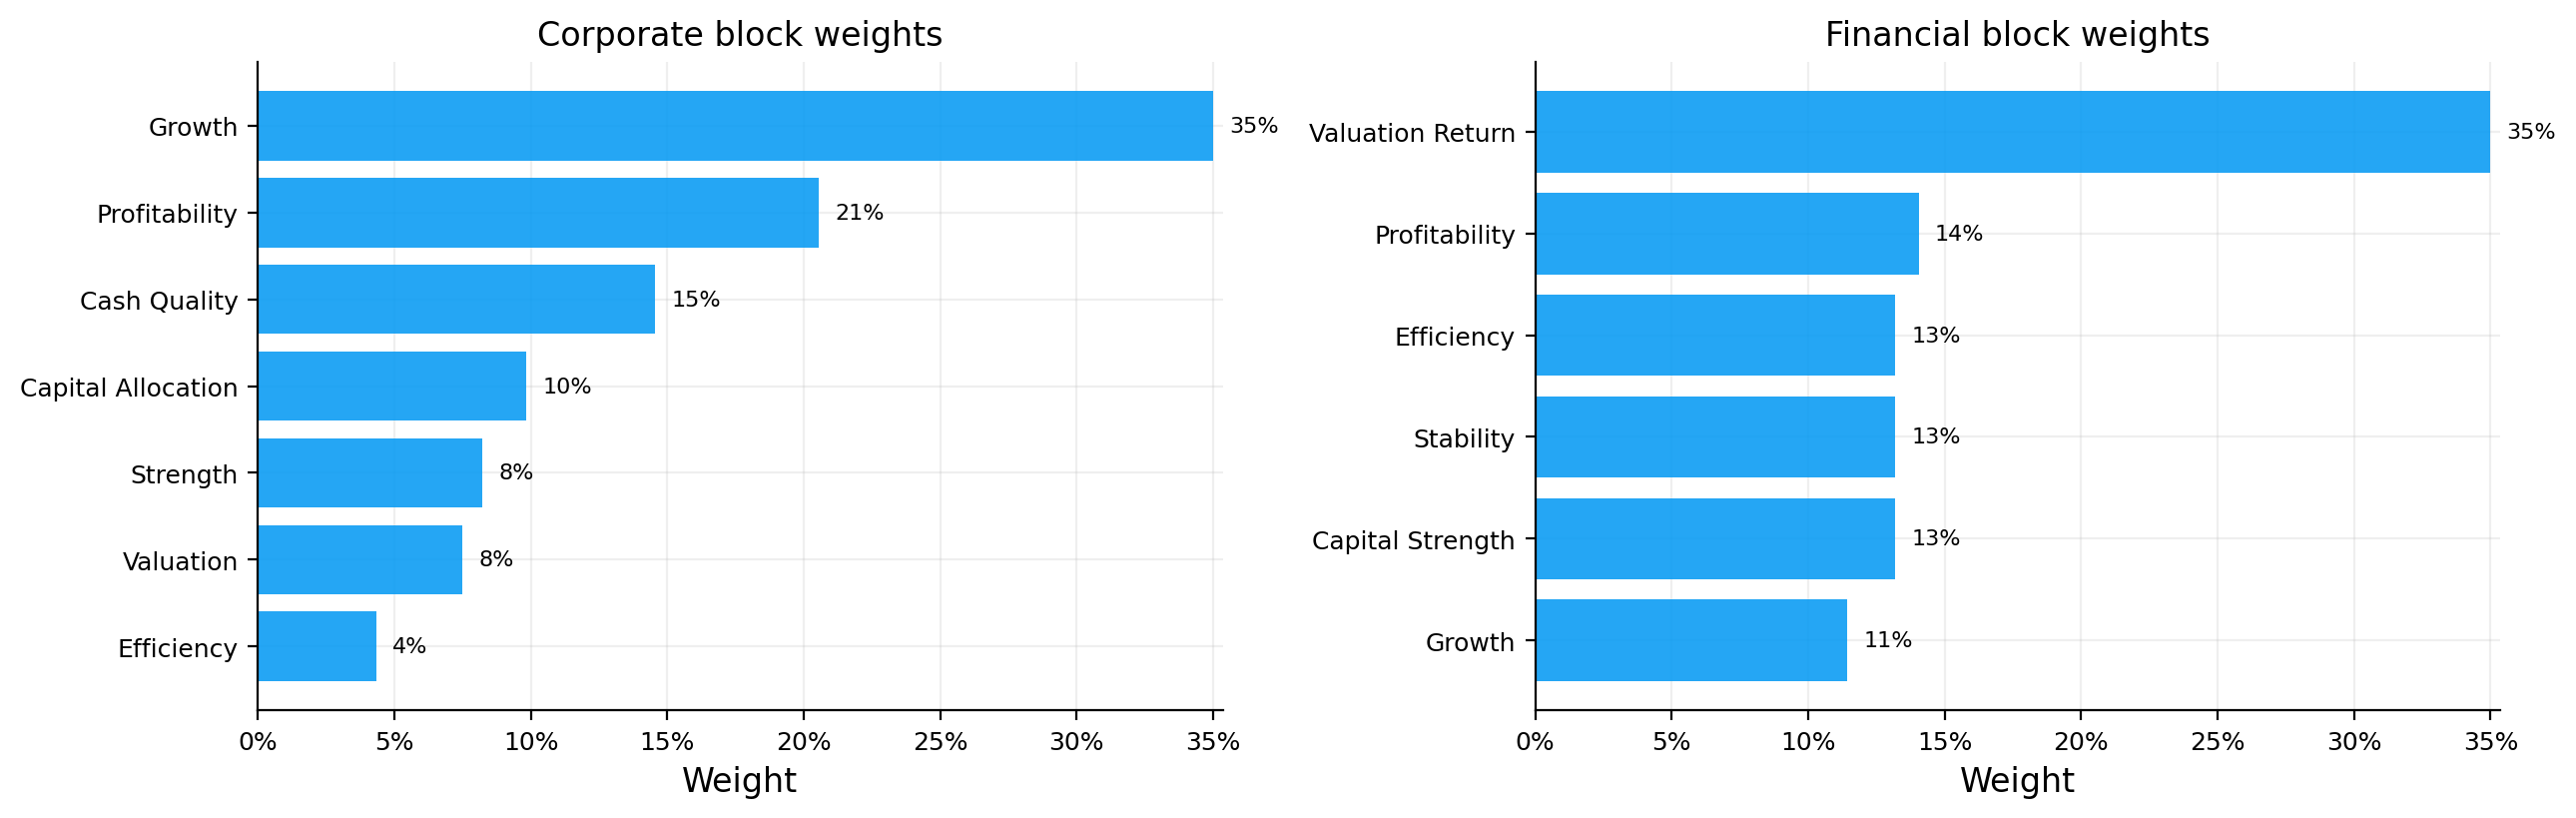

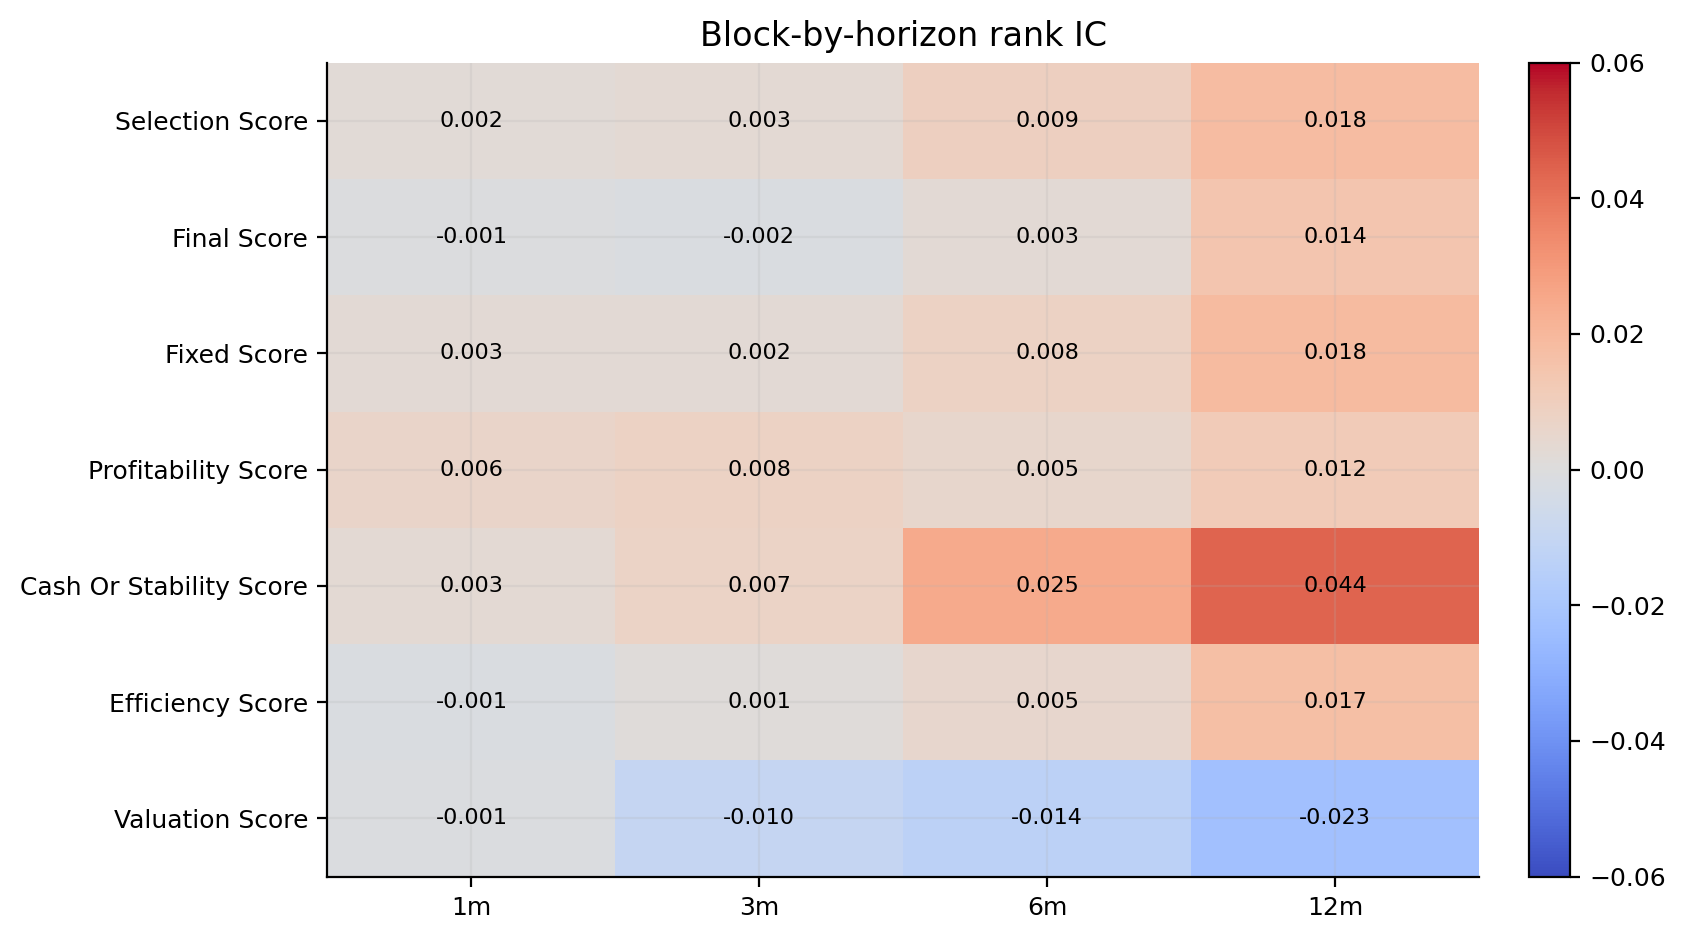

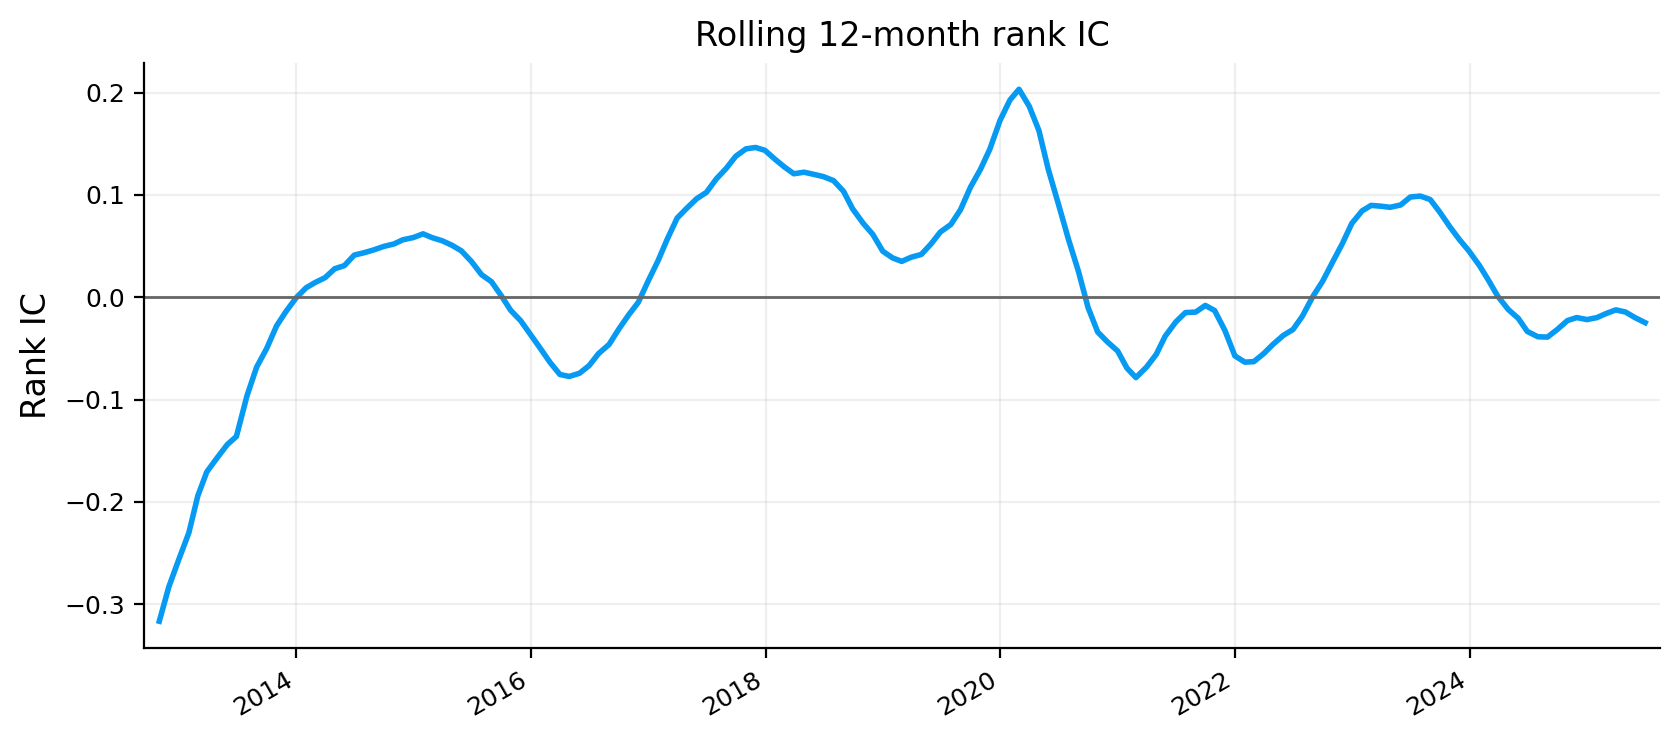

horizon_months,1,3,6,12
model,,,,
cash_or_stability_score,0.003,0.007,0.025,0.044
efficiency_score,-0.001,0.001,0.005,0.017
final_score,-0.001,-0.002,0.003,0.014
fixed_score,0.003,0.002,0.008,0.018
profitability_score,0.006,0.008,0.005,0.012
selection_score,0.002,0.003,0.009,0.018
valuation_score,-0.001,-0.010,-0.014,-0.023


64

In [50]:
monthly_prices = adj_close_filled.reindex(
    date_map["decision_date"]
)
price_signals = {}
for months in [1, 3, 6, 12]:
    if months in [3, 6, 12]:
        price_signals[f"momentum_{months}_1"] = (
            monthly_prices.shift(1) / monthly_prices.shift(months) - 1.0
        ).stack()
    price_signals[f"forward_{months}m"] = (
        monthly_prices.shift(-months) / monthly_prices - 1.0
    ).stack()
price_signals = pd.concat(price_signals, axis=1)
price_signals.index.names = ["decision_date", "ticker"]

score_validation_data = fundamental_scores.join(
    price_signals, on=["decision_date", "ticker"]
)
family_keys = [
    score_validation_data["decision_date"],
    score_validation_data["score_family"],
]
score_validation_data["momentum_score"] = (
    score_validation_data["momentum_6_1"]
    .groupby(family_keys).rank(pct=True) * 100.0
)
block_columns = {
    "corporate": corporate_block_columns,
    "financial": financial_block_columns,
}
prior_weights = {
    "corporate": corporate_block_weights,
    "financial": financial_block_weights,
}


def monthly_block_ic(family, months):
    rows = score_validation_data["score_family"].eq(family)
    columns = block_columns[family]
    values = {}
    for decision_date, month in score_validation_data.loc[
        rows, ["decision_date", f"forward_{months}m", *columns]
    ].groupby("decision_date"):
        values[decision_date] = month[columns].corrwith(
            month[f"forward_{months}m"], method="spearman"
        )
    return pd.DataFrame(values).T.sort_index()


def limit_score_weights(row, weight_cap=0.35):
    weights = row.copy()
    for _ in range(len(row)):
        excess = (weights - weight_cap).clip(lower=0.0).sum()
        weights = weights.clip(upper=weight_cap)
        if excess <= 1e-12:
            break
        room = (weight_cap - weights).clip(lower=0.0)
        weights = weights + excess * room / room.sum()
    return weights / weights.sum()


def walkforward_weights(family):
    observed_ic = (
        0.25 * monthly_block_ic(family, 3).shift(3)
        + 0.50 * monthly_block_ic(family, 6).shift(6)
        + 0.25 * monthly_block_ic(family, 12).shift(12)
    )
    strength = observed_ic.rolling(36, min_periods=12).mean().clip(lower=0.0)
    learned = strength.div(strength.sum(axis=1), axis=0)
    prior = prior_weights[family]
    learned = learned.fillna(pd.DataFrame(
        np.tile(prior.to_numpy(), (len(learned), 1)),
        index=learned.index,
        columns=learned.columns,
    ))
    weights = 0.25 * prior + 0.75 * learned
    weights = weights.div(weights.sum(axis=1), axis=0)
    return weights.apply(limit_score_weights, axis=1)


score_weight_history = {
    family: walkforward_weights(family)
    for family in block_columns
}
adaptive_base_score = pd.Series(
    np.nan, index=score_validation_data.index
)
for family, columns in block_columns.items():
    valid = (
        score_validation_data["score_family"].eq(family)
        & score_validation_data[f"{family}_base_score"].notna()
    )
    dates = score_validation_data.loc[valid, "decision_date"]
    row_weights = score_weight_history[family].reindex(
        dates
    ).set_axis(score_validation_data.index[valid])
    values = score_validation_data.loc[valid, columns]
    numerator = values.mul(row_weights).sum(axis=1, min_count=1)
    denominator = values.notna().mul(row_weights).sum(axis=1)
    adaptive_base_score.loc[valid] = numerator.div(
        denominator
    ).where(denominator.gt(0))
    for column in columns:
        score_validation_data[f"{column}_weight"] = row_weights[column]

penalty = (
    score_validation_data["piotroski_penalty"].fillna(0.0)
    + score_validation_data["red_flag_penalty"].fillna(0.0)
)
score_validation_data["fixed_score"] = score_validation_data["final_score"]
score_validation_data["final_score"] = (
    (adaptive_base_score - penalty)
    .groupby(family_keys).rank(pct=True) * 100.0
)
score_validation_data["selection_score"] = (
    0.90 * score_validation_data["final_score"]
    + 0.10 * score_validation_data["momentum_score"]
)
score_validation_data["profitability_score"] = score_validation_data[
    "corporate_profitability_score"
].combine_first(score_validation_data["financial_profitability_score"])
score_validation_data["efficiency_score"] = score_validation_data[
    "corporate_efficiency_score"
].combine_first(score_validation_data["financial_efficiency_score"])
score_validation_data["valuation_score"] = score_validation_data[
    "corporate_valuation_score"
].combine_first(score_validation_data["financial_valuation_return_score"])
score_validation_data["cash_or_stability_score"] = score_validation_data[
    "corporate_cash_quality_score"
].combine_first(score_validation_data["financial_stability_score"])

prediction_columns = [
    "selection_score", "final_score", "fixed_score",
    "profitability_score", "cash_or_stability_score",
    "efficiency_score", "valuation_score",
]
rank_tables = []
for months in [1, 3, 6, 12]:
    table = rank_metrics(
        score_validation_data,
        date_col="decision_date", asset_col="ticker",
        y_col=f"forward_{months}m", prediction_cols=prediction_columns,
        top_frac=0.20,
    ).reset_index()
    table["horizon_months"] = months
    rank_tables.append(table)
score_validation = pd.concat(rank_tables, ignore_index=True)
score_validation.to_csv(output_dir / "score_validation.csv", index=False)

score_output_columns = [
    column for column in score_validation_data
    if not column.startswith("forward_")
    and not column.startswith("momentum_")
]
fundamental_scores = score_validation_data[
    score_output_columns
].copy()
fundamental_scores.to_parquet(
    output_dir / "fundamental_scores.parquet", index=False
)

latest_weights = pd.concat({
    family: history.tail(1).T.iloc[:, 0]
    for family, history in score_weight_history.items()
}, axis=1).fillna(0.0)
display(
    latest_weights.style.format("{:.1%}").set_caption(
        "Latest walk-forward block weights"
    )
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for axis, family in zip(axes, ["corporate", "financial"]):
    values = latest_weights[family]
    values = values[values.gt(0)].sort_values()
    labels = [
        clean_label(value)
        .replace("Corporate ", "")
        .replace("Financial ", "")
        .replace(" Score", "")
        for value in values.index
    ]
    axis.barh(labels, values, color=blue, alpha=0.88)
    axis.set_title(f"{family.title()} block weights")
    axis.set_xlabel("Weight")
    axis.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
    for y, value in enumerate(values):
        axis.text(value + 0.006, y, f"{value:.0%}", va="center", fontsize=8)
    finish_axes(axis, axis="x")
plt.tight_layout()
plt.show()

rolling_ic_12m = rolling_rank_ic(
    score_validation_data,
    date_col="decision_date", asset_col="ticker",
    y_col="forward_12m", pred_col="selection_score", window=12,
)
ic_view = score_validation.pivot(
    index="model", columns="horizon_months", values="mean_rank_ic"
).reindex(prediction_columns)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
image = ax.imshow(
    ic_view, aspect="auto", cmap="coolwarm", vmin=-0.06, vmax=0.06
)
ax.set_yticks(
    range(len(ic_view)),
    [clean_label(value) for value in ic_view.index],
)
ax.set_xticks(
    range(len(ic_view.columns)),
    [f"{months}m" for months in ic_view.columns],
)
ax.set_title("Block-by-horizon rank IC")
for row in range(len(ic_view)):
    for column in range(len(ic_view.columns)):
        value = ic_view.iloc[row, column]
        ax.text(
            column, row, f"{value:.3f}",
            ha="center", va="center", fontsize=8,
        )
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 3.8))
rolling_ic_12m.plot(ax=ax, color=blue, linewidth=2)
ax.axhline(0, color=muted, linewidth=1)
ax.set_title("Rolling 12-month rank IC")
ax.set_xlabel("")
ax.set_ylabel("Rank IC")
finish_axes(ax)
plt.tight_layout()
plt.show()

display(
    score_validation.pivot(
        index="model", columns="horizon_months", values="mean_rank_ic"
    ).style.format("{:.3f}").set_caption(
        "Average rank IC by forward horizon"
    )
)


del fundamental_metrics, fundamental_scores, ranked_fundamentals
del raw_metrics, family_count, lower, upper, clipped
del family_percentile, peer_count, peer_percentile, metric_scores
del corporate_scores, financial_scores
gc.collect()


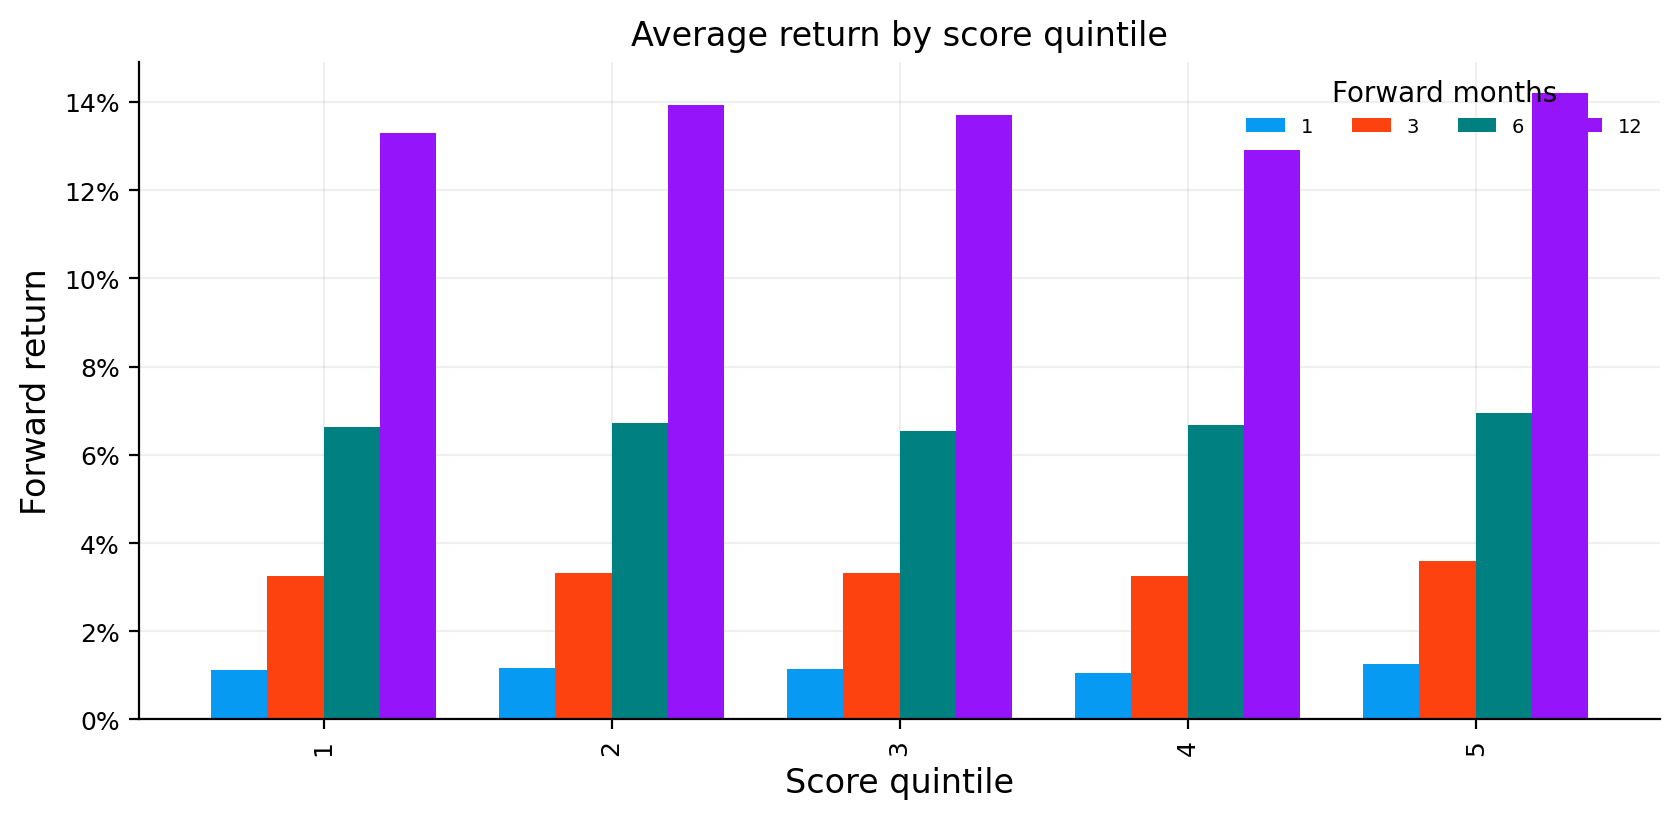

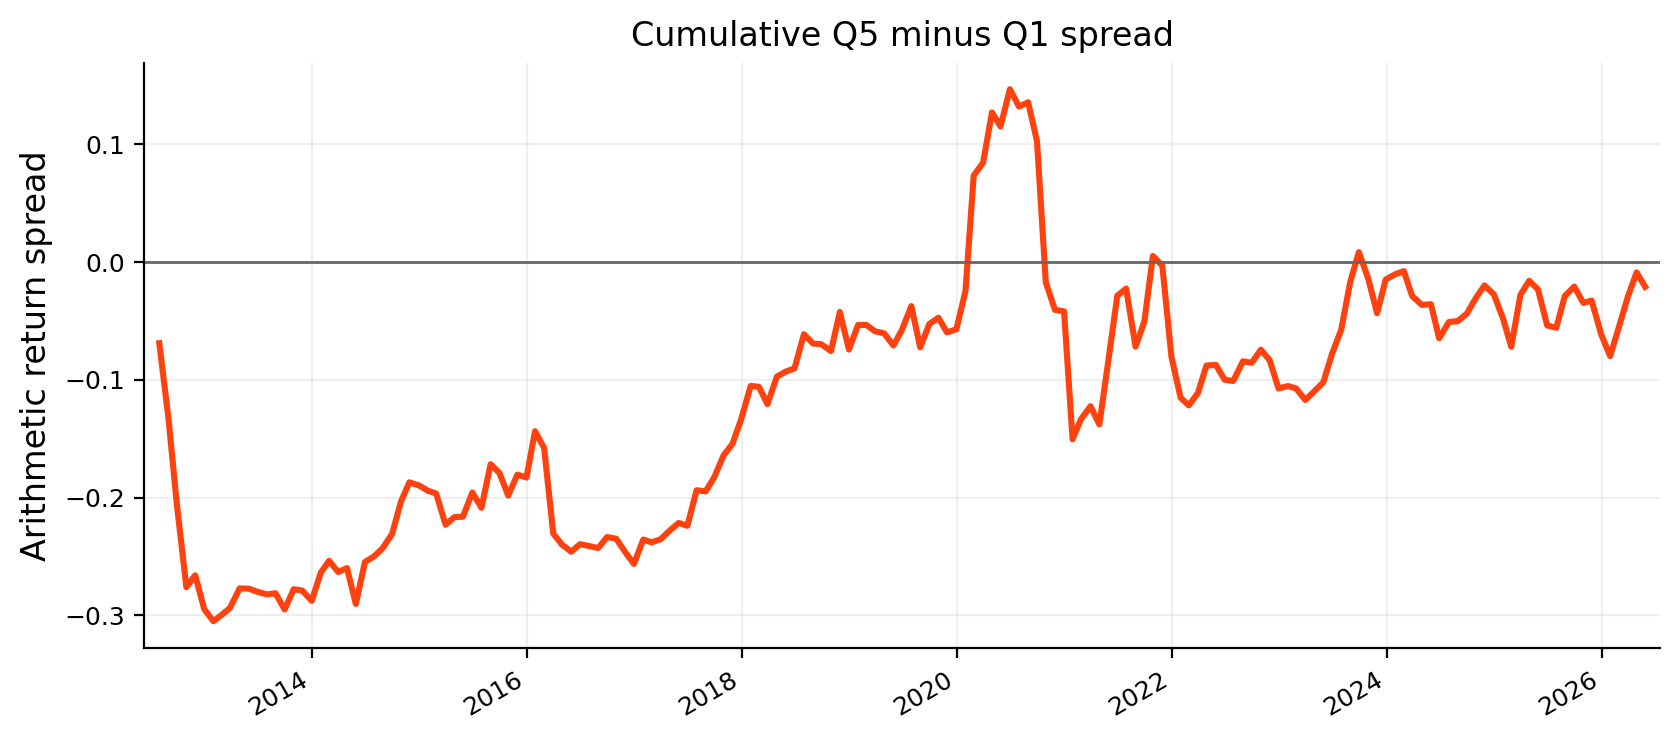

In [51]:
bucket_tables = []
for months in [1, 3, 6, 12]:
    table = forecast_buckets(
        score_validation_data,
        date_col="decision_date", y_col=f"forward_{months}m",
        score_col="selection_score", n_buckets=5,
    ).reset_index()
    table["horizon_months"] = months
    bucket_tables.append(table)
quintile_summary = pd.concat(bucket_tables, ignore_index=True)

monthly_bucket_rows = []
for decision_date, group in score_validation_data.dropna(
    subset=["selection_score", "forward_1m"]
).groupby("decision_date"):
    if len(group) < 25:
        continue
    bucket = pd.qcut(
        group["selection_score"].rank(method="first"), 5, labels=False
    ) + 1
    monthly_bucket_rows.append(
        group.assign(bucket=bucket)
        .groupby("bucket")["forward_1m"].mean().rename(decision_date)
    )
monthly_quintile_returns = pd.DataFrame(monthly_bucket_rows).sort_index()
monthly_quintile_returns.index = pd.to_datetime(monthly_quintile_returns.index)
quintile_spread = (
    monthly_quintile_returns[5] - monthly_quintile_returns[1]
).rename("Q5 − Q1")

return_by_quintile = quintile_summary.pivot(
    index="bucket", columns="horizon_months", values="mean"
)
fig, ax = plt.subplots(figsize=(8.5, 4.2))
return_by_quintile.plot.bar(
    ax=ax, color=[blue, gold, teal, coral], width=0.78,
)
ax.set_title("Average return by score quintile")
ax.set_xlabel("Score quintile")
ax.set_ylabel("Forward return")
ax.yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.legend(title="Forward months", ncol=4, frameon=False)
finish_axes(ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.5, 3.8))
quintile_spread.cumsum().plot(ax=ax, color=gold, linewidth=2.2)
ax.axhline(0, color=muted, linewidth=1)
ax.set_title("Cumulative Q5 minus Q1 spread")
ax.set_ylabel("Arithmetic return spread")
ax.set_xlabel("")
finish_axes(ax)
plt.tight_layout()
plt.show()


In [52]:
scoreable = score_validation_data[
    score_validation_data["decision_date"].ge(backtest_start)
    & score_validation_data["selection_score"].notna()
].sort_values(["decision_date", "selection_score"], ascending=[True, False])

selection_frames = []
for top_n in top_n_values:
    selected = scoreable.groupby("decision_date", group_keys=False).head(top_n).copy()
    selected["top_n"] = top_n
    selected["selection_rank"] = selected.groupby(
        "decision_date"
    )["selection_score"].rank(ascending=False, method="first")
    selection_frames.append(selected)
stock_selections = pd.concat(selection_frames, ignore_index=True)
stock_selections.to_parquet(
    output_dir / "monthly_stock_selections.parquet", index=False
)

selection_membership_check = stock_selections.merge(
    monthly_universe[[
        "decision_date", "ticker", "is_sp500_member", "score_family",
    ]],
    on=["decision_date", "ticker"], how="left", suffixes=("", "_universe"),
)
assert selection_membership_check["is_sp500_member"].eq(True).all()
assert stock_selections["score_family"].isin(["corporate", "financial"]).all()
assert stock_selections["score_family"].eq("financial").any()
assert not stock_selections["industry"].isin(reit_industries).any()
assert stock_selections.groupby(
    ["decision_date", "top_n"]
)["ticker"].nunique().le(
    stock_selections["top_n"].groupby([
        stock_selections["decision_date"], stock_selections["top_n"],
    ]).first()
).all()


del score_validation_data


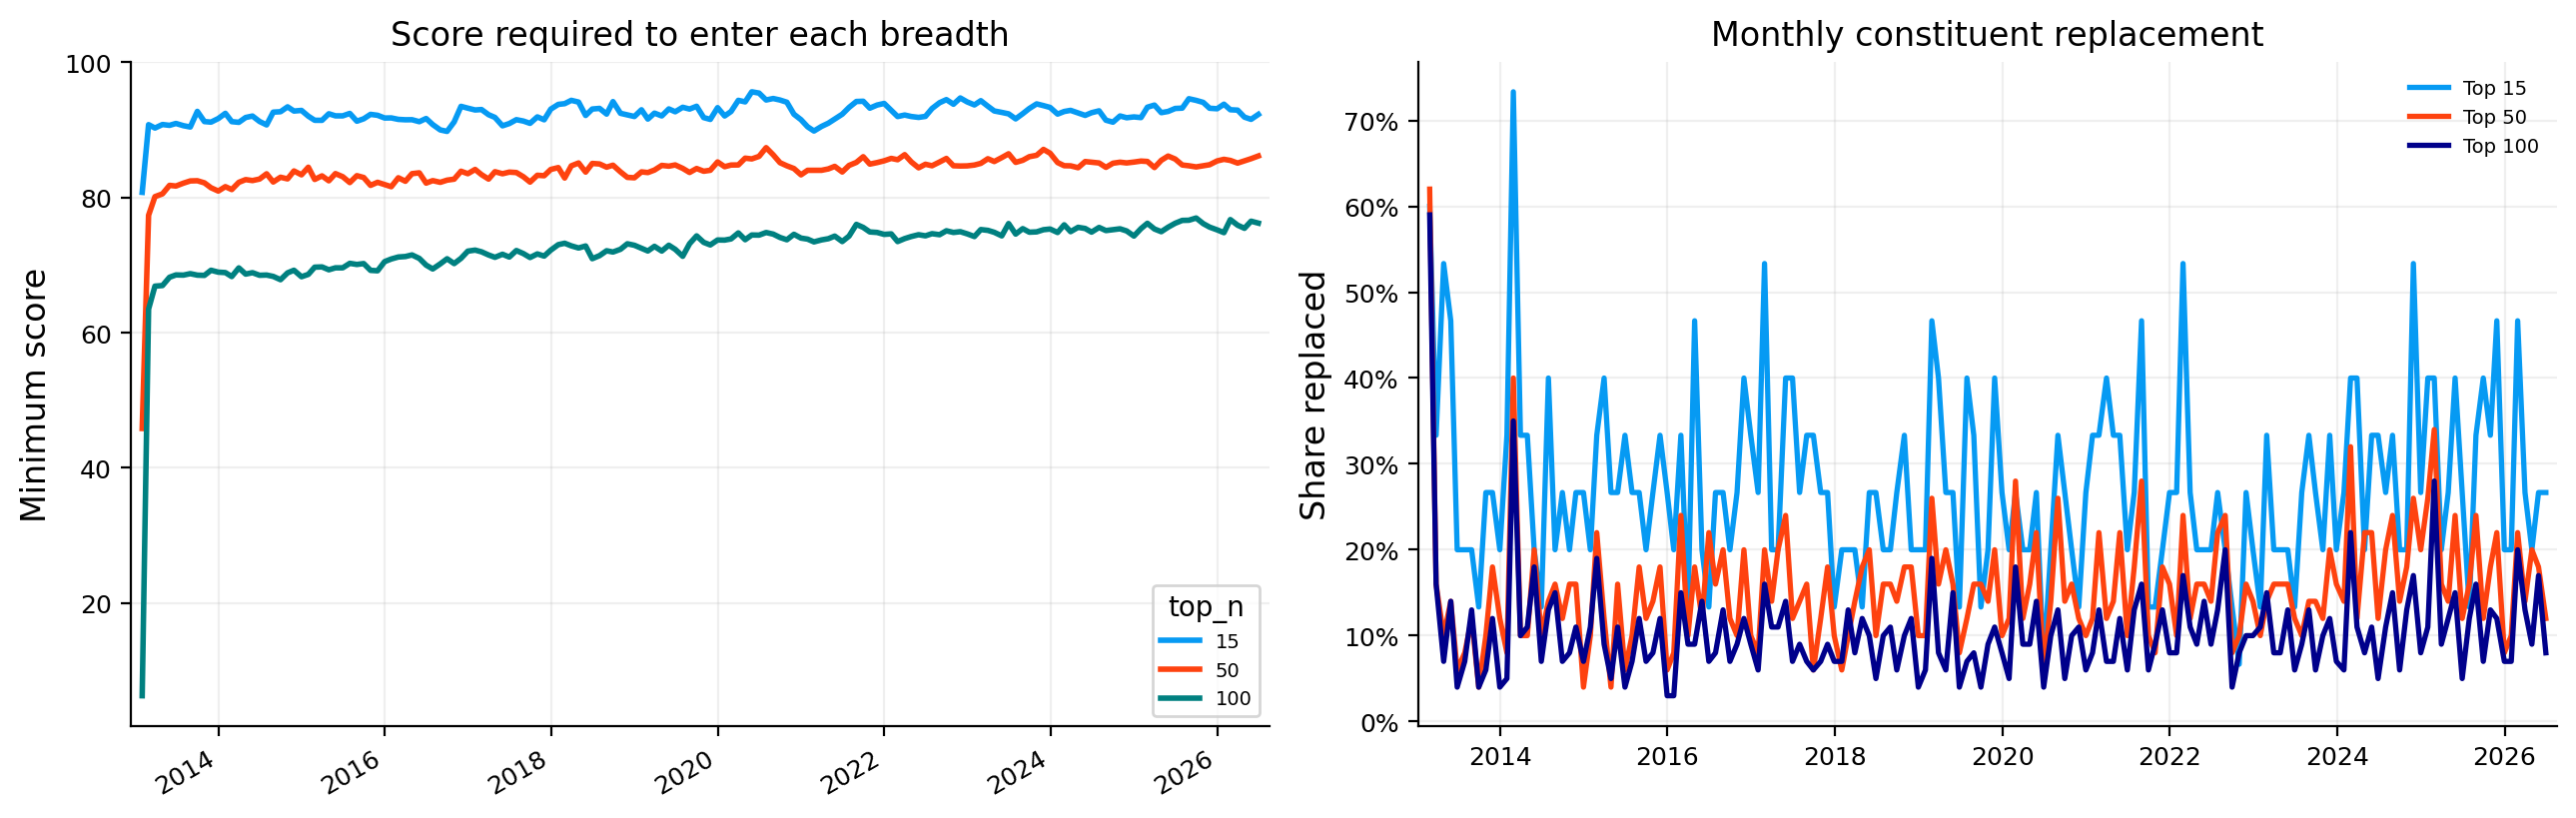

,ticker,entity_name,score_family,industry,market_cap,selection_score
selection_rank,,,,,,
1.000000,MU,MICRON TECHNOLOGY INC,corporate,SEMICONDUCTORS & RELATED DEVICES,$1.30T,99.3
2.000000,STX,Seagate Technology Holdings plc,corporate,COMPUTER STORAGE DEVICES,$216.38B,96.3
3.000000,NEM,NEWMONT Corp /DE/,corporate,GOLD AND SILVER ORES,$99.71B,95.9
4.000000,WDC,WESTERN DIGITAL CORP,corporate,COMPUTER STORAGE DEVICES,$220.16B,95.8
5.000000,DXCM,DEXCOM INC,corporate,SURGICAL & MEDICAL INSTRUMENTS & APPARATUS,$25.99B,95.6
6.000000,CF,"CF Industries Holdings, Inc.",corporate,AGRICULTURAL CHEMICALS,$16.63B,95.6
7.000000,NVDA,NVIDIA CORP,corporate,SEMICONDUCTORS & RELATED DEVICES,$4.84T,95.3
8.000000,AAPL,Apple Inc.,corporate,ELECTRONIC COMPUTERS,$4.25T,95.2
9.000000,VRT,Vertiv Holdings Co,corporate,"ELECTRONIC COMPONENTS, NEC",$128.61B,94.0


In [53]:
selection_cutoffs = stock_selections.groupby(
    ["decision_date", "top_n"]
)["selection_score"].min().unstack()
selection_turnover_rows = []
for top_n, group in stock_selections.groupby("top_n"):
    previous = None
    for decision_date, month in group.groupby("decision_date"):
        current = set(month["ticker"])
        if previous is not None:
            selection_turnover_rows.append({
                "decision_date": decision_date, "top_n": top_n,
                "constituent_turnover": 1.0 - len(current & previous) / len(current),
                "average_score": month["selection_score"].mean(),
            })
        previous = current
selection_turnover = pd.DataFrame(selection_turnover_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
selection_cutoffs.plot(ax=axes[0], color=[blue, gold, teal], linewidth=2)
axes[0].set_title("Score required to enter each breadth")
axes[0].set_xlabel("")
axes[0].set_ylabel("Minimum score")
finish_axes(axes[0])
for top_n, group in selection_turnover.groupby("top_n"):
    axes[1].plot(
        group["decision_date"], group["constituent_turnover"],
        linewidth=1.9, label=f"Top {top_n}",
    )
axes[1].set_title("Monthly constituent replacement")
axes[1].set_xlabel("")
axes[1].set_ylabel("Share replaced")
axes[1].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[1].legend(frameon=False)
finish_axes(axes[1])
plt.tight_layout()
plt.show()

latest_selection_date = stock_selections["decision_date"].max()
latest_top15 = stock_selections[
    stock_selections["decision_date"].eq(latest_selection_date)
    & stock_selections["top_n"].eq(15)
]
latest_selection_table = latest_top15[[
    "selection_rank", "ticker", "entity_name", "score_family", "industry",
    "market_cap", "selection_score",
]].set_index("selection_rank")
display(
    latest_selection_table.style.format({
        "market_cap": money, "selection_score": "{:.1f}",
    }, na_rep="—").set_caption(
        f"Latest Top 15 constituents · {latest_selection_date:%B %Y}"
    )
)


In [54]:
decision_dates = pd.DatetimeIndex(sorted(
    set(stock_selections["decision_date"]) & set(date_map["decision_date"])
))
decision_dates = decision_dates[decision_dates >= backtest_start]
decision_to_execution = date_map.set_index("decision_date")["execution_date"]
portfolio_dates = pd.DatetimeIndex([
    decision_to_execution.loc[decision_date] for decision_date in decision_dates
])

universe_source = {
    pd.Timestamp(decision_date): group["ticker"].tolist()
    for decision_date, group in monthly_universe[
        monthly_universe["decision_date"].isin(decision_dates)
    ].groupby("decision_date")
}
selection_source = {
    top_n: {
        pd.Timestamp(decision_date): group["ticker"].tolist()
        for decision_date, group in stock_selections[
            stock_selections["top_n"].eq(top_n)
            & stock_selections["decision_date"].isin(decision_dates)
        ].groupby("decision_date")
    }
    for top_n in top_n_values
}

portfolio_universes = {"Full": {}, "Top15": {}, "Top50": {}, "Top100": {}}
seasoned_observations = (
    adj_close_filled.notna().rolling(cov_lookback + 1).sum()
)
for decision_date in decision_dates:
    execution_date = pd.Timestamp(decision_to_execution.loc[decision_date])
    observations = seasoned_observations.loc[decision_date]
    for label, candidates in [
        ("Full", universe_source.get(decision_date, [])),
        ("Top15", selection_source[15].get(decision_date, [])),
        ("Top50", selection_source[50].get(decision_date, [])),
        ("Top100", selection_source[100].get(decision_date, [])),
    ]:
        names = [
            ticker for ticker in candidates
            if observations.get(ticker, 0) >= min_model_obs
        ]
        if len(names) >= 10:
            portfolio_universes[label][execution_date] = {"tickers": names}

,CAGR,Vol,Sharpe,Max Drawdown,Turnover,Effective N
Strategy,,,,,,
Full EW,13.3%,17.5%,0.69,-39.4%,2.8%,404.4
Top15 EW,19.9%,20.7%,0.89,-31.6%,27.3%,15.0


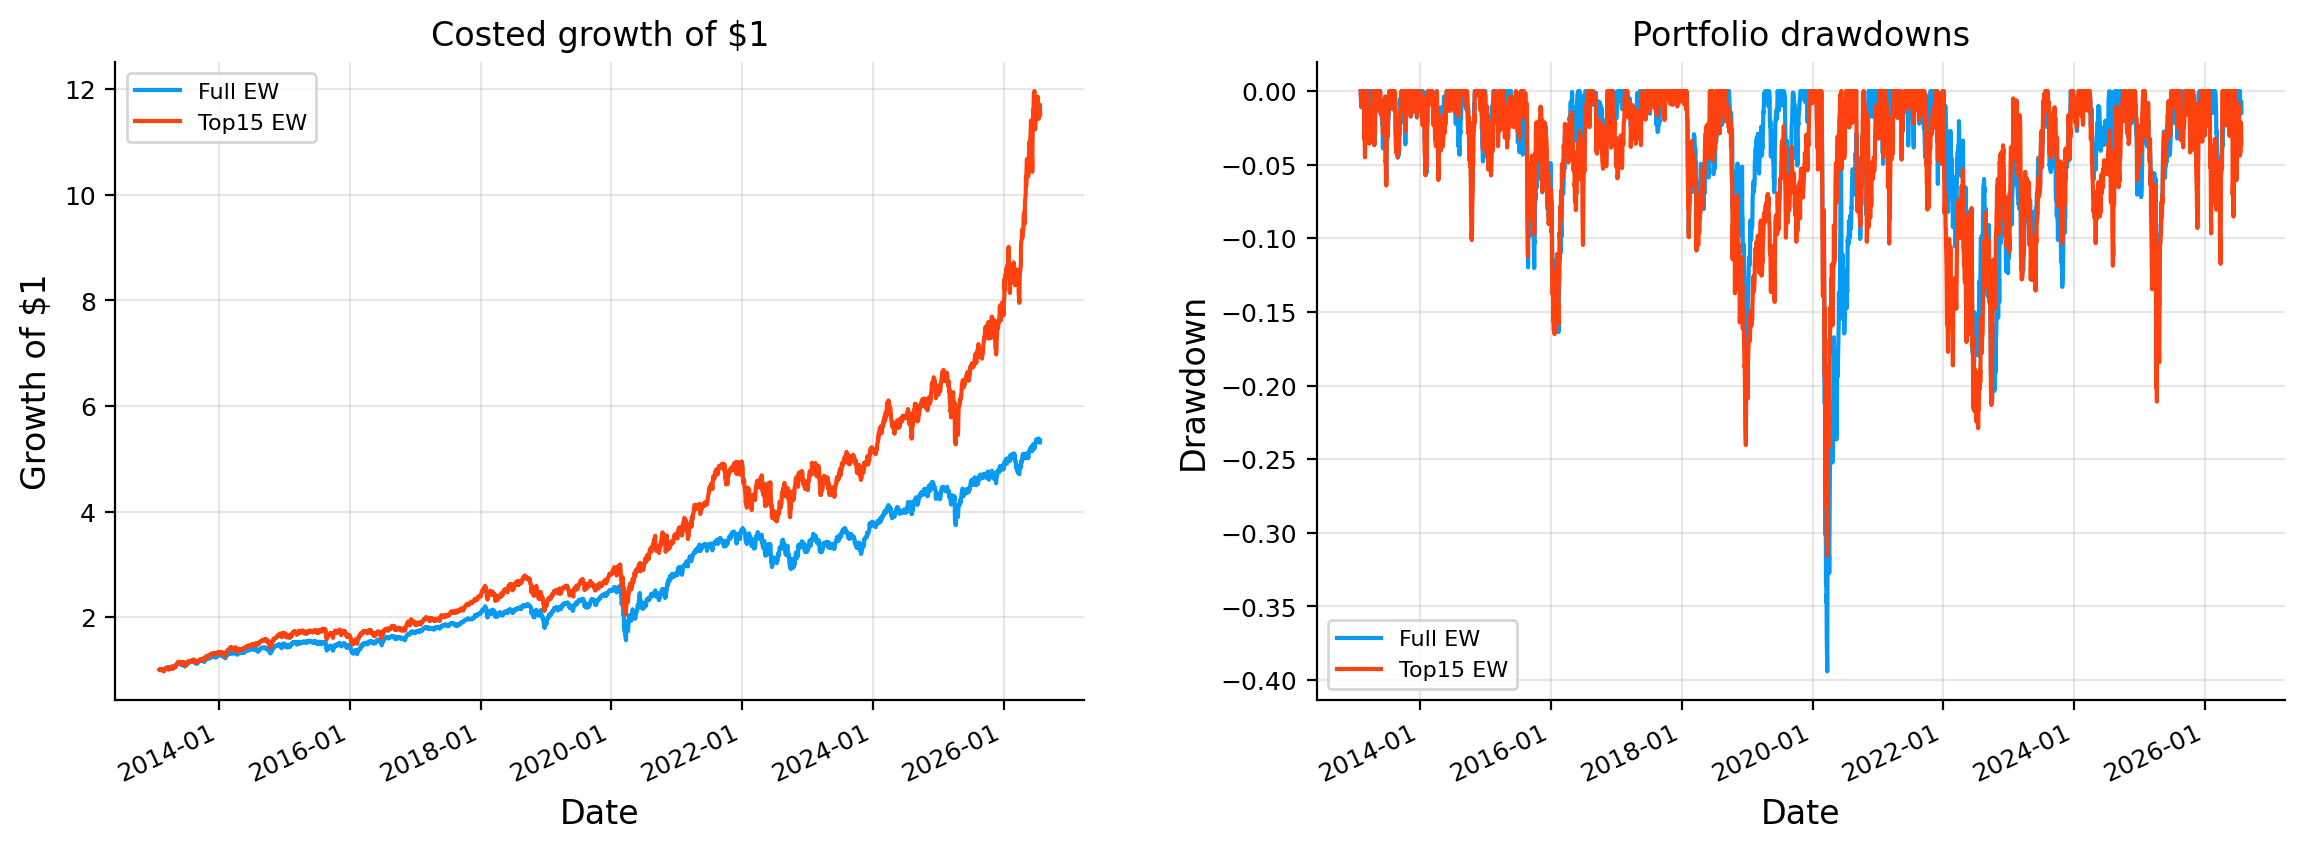

In [55]:
def portfolio_table(performance, caption):
    columns = ["CAGR", "Vol", "Sharpe", "Max Drawdown", "Turnover", "Effective N"]
    return (
        performance[columns].style
        .format({
            "CAGR": "{:.1%}", "Vol": "{:.1%}", "Sharpe": "{:.2f}",
            "Max Drawdown": "{:.1%}", "Turnover": "{:.1%}",
            "Effective N": "{:.1f}",
        }, na_rep="—")
        .set_caption(caption)
    )


full_ew = run_equal_weight_walkforward(
    returns=returns,
    rebalance_dates=portfolio_dates,
    universe_by_date=portfolio_universes["Full"],
    max_weight=max_weight,
    min_weight=0.0,
    long_only=True,
    trading_cost_bps=cost_bps,
    rf_daily=rf_daily,
)
top15_ew = run_equal_weight_walkforward(
    returns=returns,
    rebalance_dates=portfolio_dates,
    universe_by_date=portfolio_universes["Top15"],
    max_weight=max_weight,
    min_weight=0.0,
    long_only=True,
    trading_cost_bps=cost_bps,
    rf_daily=rf_daily,
)
layer1_results = {
    "Full EW": full_ew,
    "Top15 EW": top15_ew,
}
layer1_performance = selection.build_strategy_summary(
    layer1_results, rf_daily=rf_daily, annualization=annualization
)
layer1_performance.to_csv(output_dir / "layer1_performance.csv")
display(portfolio_table(
    layer1_performance,
    "Layer 1 · full eligible universe versus the research Top 15",
))
layer1_nav = pd.DataFrame({
    name: result.net_values for name, result in layer1_results.items()
}).dropna(how="all")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
portfolio_plots.plot_strategy_nav(
    layer1_nav, ax=axes[0], title="Costed growth of $1",
    summary=layer1_performance, apply_style=False,
)
portfolio_plots.plot_strategy_drawdowns(
    layer1_nav, ax=axes[1], title="Portfolio drawdowns",
    summary=layer1_performance, apply_style=False,
)
portfolio_plots.apply_portfolio_subplot_layout(
    fig, axes, hspace=0.28, wspace=0.24, bottom=0.18, top=0.94,
)
plt.show()

,CAGR,Vol,Sharpe,Max Drawdown,Turnover,Effective N
Strategy,,,,,,
Top15 EW,19.9%,20.7%,0.89,-31.6%,27.3%,15.0
Top50 EW,14.0%,18.3%,0.71,-34.7%,15.6%,50.0
Top100 EW,14.0%,17.3%,0.74,-34.5%,10.7%,99.9


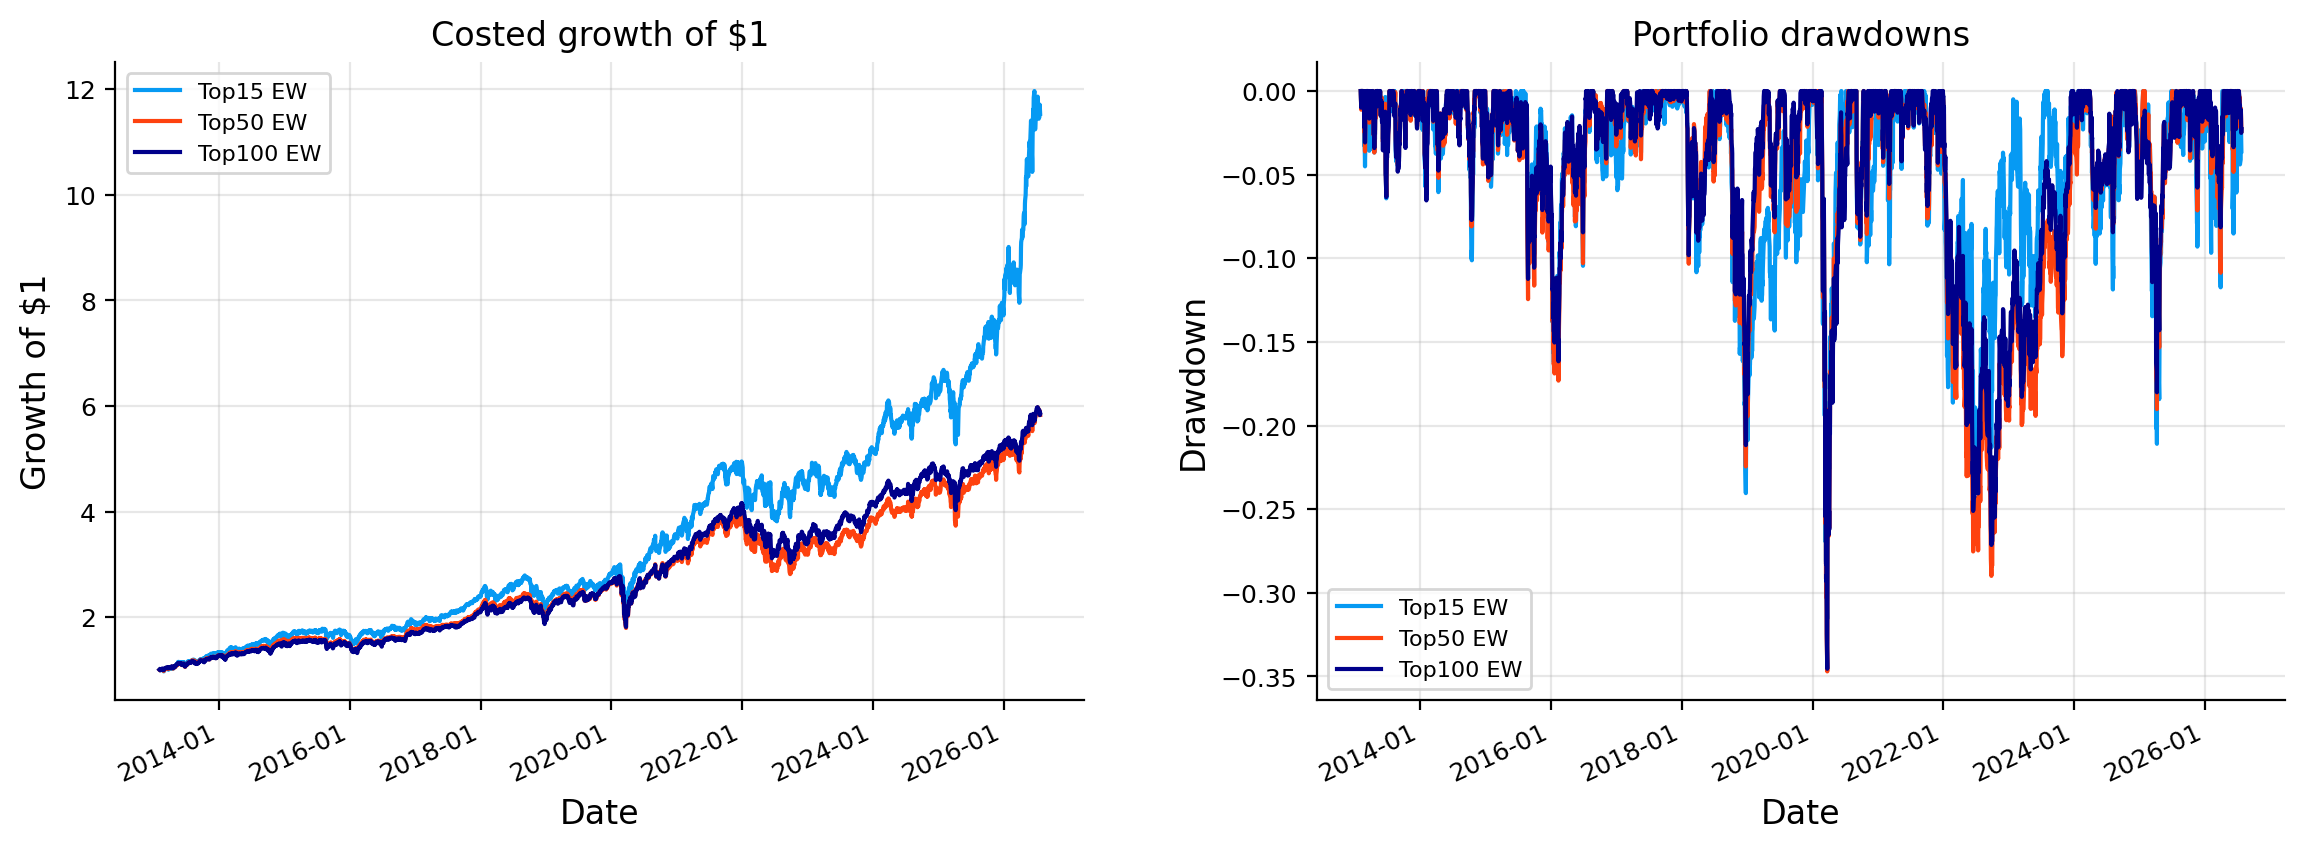

In [56]:
top50_ew = run_equal_weight_walkforward(
    returns=returns,
    rebalance_dates=portfolio_dates,
    universe_by_date=portfolio_universes["Top50"],
    max_weight=max_weight,
    min_weight=0.0,
    long_only=True,
    trading_cost_bps=cost_bps,
    rf_daily=rf_daily,
)
top100_ew = run_equal_weight_walkforward(
    returns=returns,
    rebalance_dates=portfolio_dates,
    universe_by_date=portfolio_universes["Top100"],
    max_weight=max_weight,
    min_weight=0.0,
    long_only=True,
    trading_cost_bps=cost_bps,
    rf_daily=rf_daily,
)
layer2_results = {
    "Top15 EW": top15_ew,
    "Top50 EW": top50_ew,
    "Top100 EW": top100_ew,
}
layer2_performance = selection.build_strategy_summary(
    layer2_results, rf_daily=rf_daily, annualization=annualization
)
layer2_performance.to_csv(output_dir / "layer2_performance.csv")
display(portfolio_table(
    layer2_performance,
    "Layer 2 · equal-weight breadth comparison",
))
layer2_nav = pd.DataFrame({
    name: result.net_values for name, result in layer2_results.items()
}).dropna(how="all")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
portfolio_plots.plot_strategy_nav(
    layer2_nav, ax=axes[0], title="Costed growth of $1",
    summary=layer2_performance, apply_style=False,
)
portfolio_plots.plot_strategy_drawdowns(
    layer2_nav, ax=axes[1], title="Portfolio drawdowns",
    summary=layer2_performance, apply_style=False,
)
portfolio_plots.apply_portfolio_subplot_layout(
    fig, axes, hspace=0.28, wspace=0.24, bottom=0.18, top=0.94,
)
plt.show()

,Optimizer,Covariance model,Mu model,Sharpe
EW,EW,—,—,0.89
MinVar (LedoitWolf),MinVar,LedoitWolf,—,1.05
"MV (LedoitWolf, BayesSteinMomentum)",MV,LedoitWolf,BayesSteinMomentum,0.99
"MaxSharpe (EWMA, BayesStein)",MaxSharpe,EWMA,BayesStein,1.01


,CAGR,Vol,Sharpe,Max Drawdown,Turnover,Effective N
Strategy,,,,,,
MinVar,21.1%,17.9%,1.05,-29.4%,17.8%,6.6
NCO,21.9%,19.1%,1.04,-28.3%,51.0%,8.3
MaxSharpe,28.7%,26.7%,1.01,-28.3%,38.5%,5.4
MV,20.3%,18.5%,0.99,-28.5%,27.9%,7.0
Mean-CVaR,24.7%,23.5%,0.98,-27.8%,43.8%,5.6
WRO,20.6%,19.2%,0.97,-28.6%,39.3%,6.6
Risk Parity,18.7%,18.9%,0.90,-31.1%,31.3%,13.6
HRP,18.0%,18.2%,0.90,-30.6%,35.9%,11.4
EW,19.9%,20.7%,0.89,-31.6%,27.3%,15.0


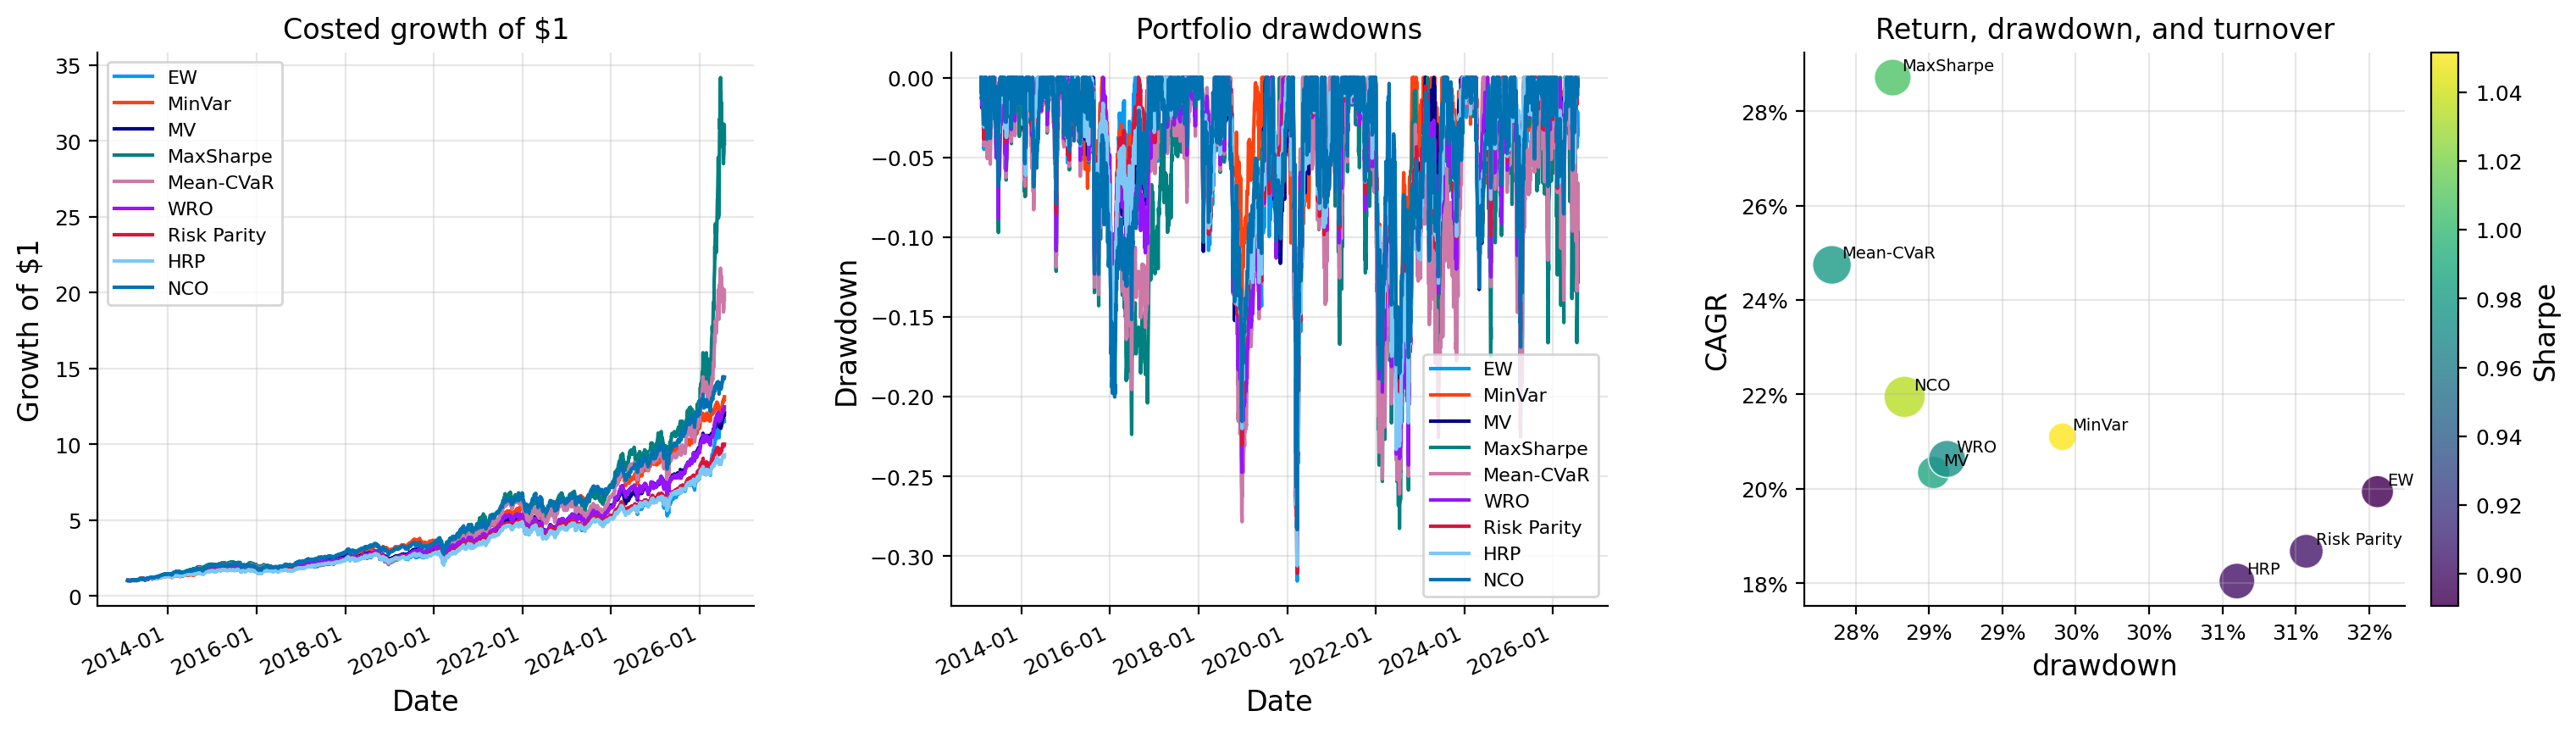

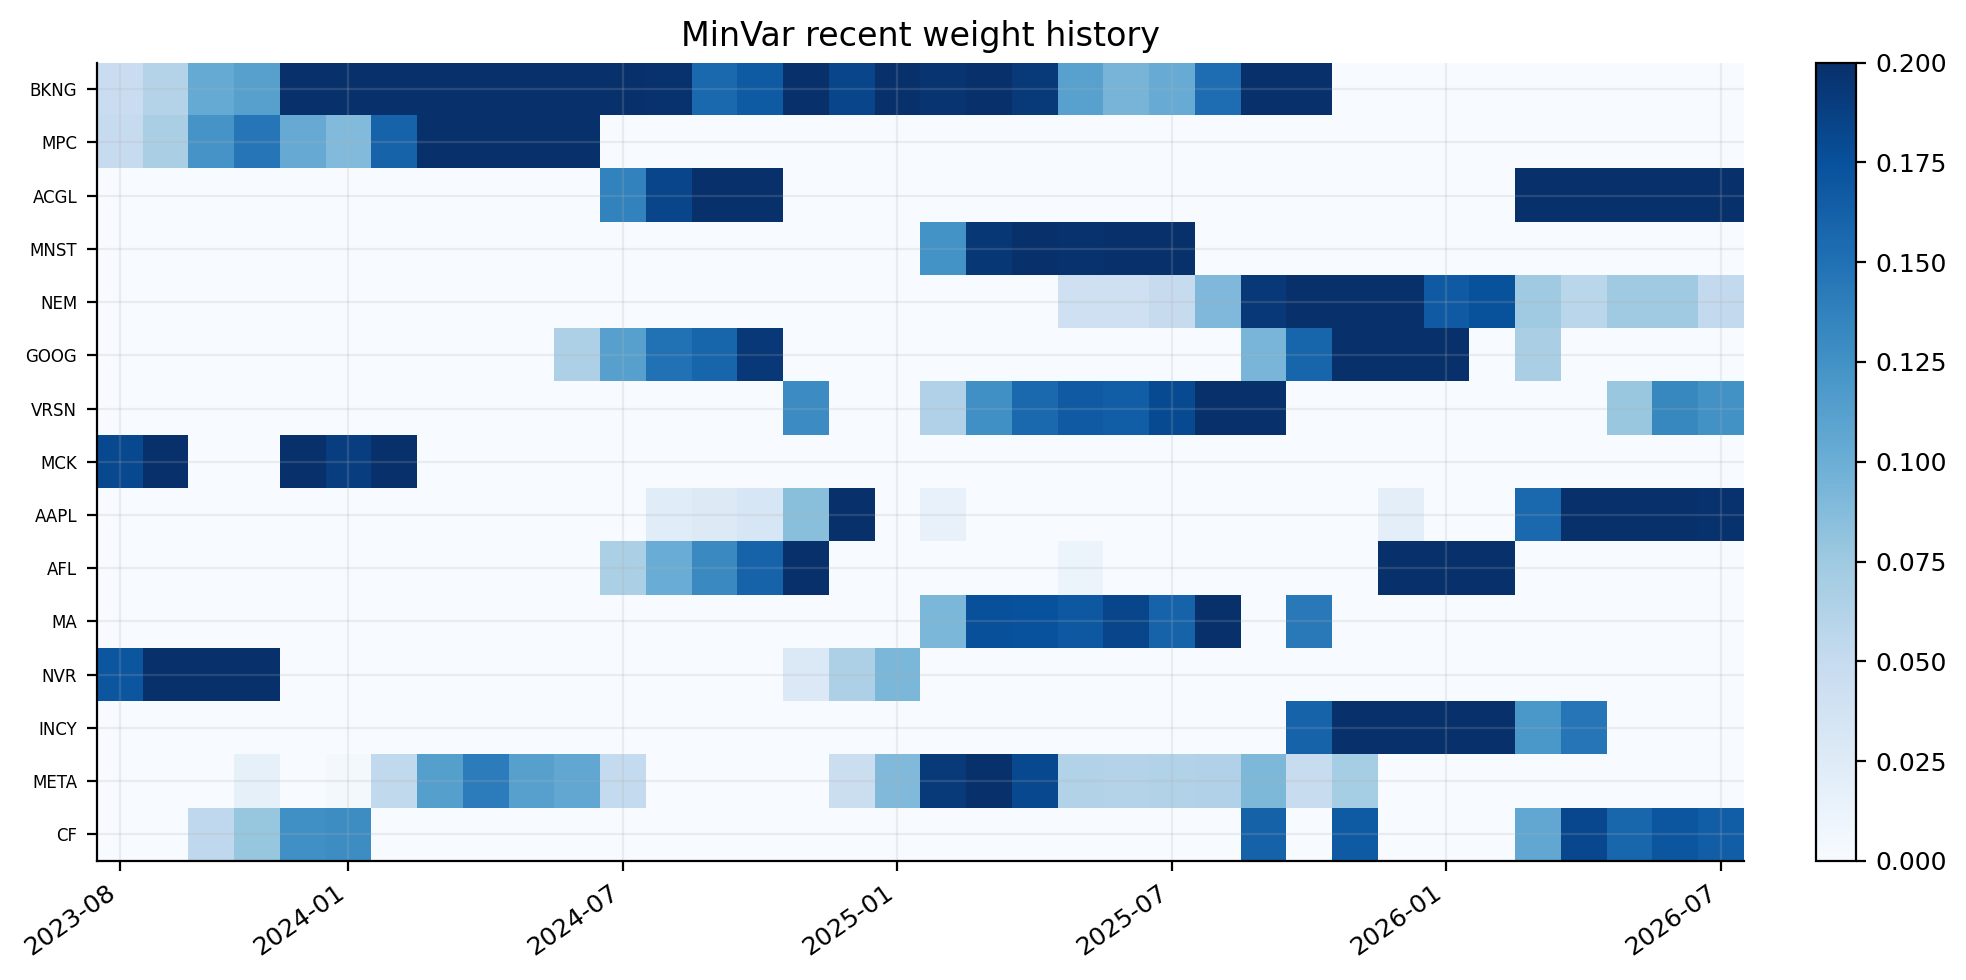

In [57]:
cov_models = {
    "Sample": covariance.sample_covariance,
    "LedoitWolf": covariance.ledoit_wolf_covariance,
    "OAS": covariance.oas_covariance,
    "EWMA": covariance.ewma_covariance,
}
mu_models = {
    "Momentum": expected_returns.momentum_mu,
    "BayesStein": expected_returns.bayes_stein_mu,
    "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu,
}
top15_optimizers = {
    "MinVar": optimizers.minimum_variance,
    "MV": optimizers.mean_variance,
    "MaxSharpe": optimizers.max_sharpe_slsqp,
}
top15_specs = []
top15_specs.extend(
    {"optimizer": "MinVar", "cov_model": cov_model}
    for cov_model in cov_models
)
top15_specs.extend(
    {
        "optimizer": "MV",
        "cov_model": cov_model,
        "mu_model": mu_model,
    }
    for cov_model in cov_models
    for mu_model in mu_models
)
top15_specs.append({
    "optimizer": "MaxSharpe",
    "cov_model": "EWMA",
    "mu_model": "BayesStein",
})
zero_blend = {"MinVar": 0.0, "MV": 0.0, "MaxSharpe": 0.0}
top15_grid = run_walkforward_grid(
    returns=returns,
    close=adj_close_filled,
    rebalance_dates=portfolio_dates,
    universe_by_date=portfolio_universes["Top15"],
    cov_lookback=cov_lookback,
    mu_lookback=mu_lookback,
    min_cov_observations=min_model_obs,
    min_mu_observations=min_model_obs,
    max_weight=max_weight,
    min_weight=0.0,
    long_only=True,
    trading_cost_bps=cost_bps,
    turnover_penalty_bps=turnover_penalty_bps,
    optimizer_params={"MV": {"mv_lambda": mv_lambda}},
    blend_by_optimizer=zero_blend,
    fallback="equal",
    rf_daily=rf_daily,
    annualization=annualization,
    momentum_mode="6-1",
    cov_models=cov_models,
    mu_models=mu_models,
    optimizers=top15_optimizers,
    strategy_specs=top15_specs,
)

top15_best = {
    model: selection.select_best_grid_strategy(top15_grid, optimizer=model)
    for model in ["MinVar", "MV", "MaxSharpe"]
}
top15_results = {
    "EW": top15_ew,
    **{
        model: top15_grid.backtests[name]
        for model, name in top15_best.items()
    },
}
core_choices = top15_grid.diagnostics.loc[
    list(top15_best.values())
].copy()
ew_choice = pd.DataFrame(
    {
        "Optimizer": ["EW"],
        "Covariance model": [None],
        "Mu model": [None],
    },
    index=["EW"],
)
core_choices = pd.concat([ew_choice, core_choices])
core_sharpes = selection.build_strategy_summary(
    top15_results, rf_daily=rf_daily, annualization=annualization
)["Sharpe"]
core_choices["Sharpe"] = core_sharpes.reindex(
    ["EW", "MinVar", "MV", "MaxSharpe"]
).to_numpy()
display(
    core_choices[[
        "Optimizer", "Covariance model", "Mu model", "Sharpe",
    ]].style
    .format({"Sharpe": "{:.2f}"}, na_rep="—")
    .set_caption("Estimator choices for the Top 15 core models")
)

top15_dates = list(top15_grid.metadata["rebalance_dates"])
weights_mean_cvar = mean_cvar_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="LedoitWolf",
    mu_model="BayesStein",
    reference="equal",
    alpha=0.90,
    budget_scale=1.0,
    w_min=0.0,
    w_max=max_weight,
)
weights_wro = wasserstein_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="Sample",
    mu_model="BayesStein",
    radius=0.50,
    mv_lambda=6.0,
    radius_scale="avg_vol",
    worst_case_variance=True,
    w_min=0.0,
    w_max=max_weight,
)
weights_risk_parity = risk_parity_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="Sample",
    w_min=0.0,
    w_max=max_weight,
)
weights_hrp = hrp_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="Sample",
    linkage_method="average",
    w_min=0.0,
    w_max=max_weight,
)
weights_nco = nco_mv_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="EWMA",
    mu_model="Momentum",
    n_clusters=6,
    inner_lambda=6.0,
    outer_lambda=6.0,
    cluster_cap=0.50,
    linkage_method="single",
    w_min=0.0,
    w_max=max_weight,
)
additional_weights = {
    "Mean-CVaR": weights_mean_cvar,
    "WRO": weights_wro,
    "Risk Parity": weights_risk_parity,
    "HRP": weights_hrp,
    "NCO": weights_nco,
}
additional_results = run_many_weights_backtests(
    additional_weights,
    returns=returns,
    cost_bps=cost_bps,
    rf_daily=rf_daily,
    w_min=0.0,
    w_max=max_weight,
    long_only=True,
    normalize=True,
    weight_timing="same_day",
)
top15_grid.cache.clear()
top15_grid.metadata.pop("_returns_source", None)
del additional_weights
del weights_mean_cvar, weights_wro, weights_risk_parity, weights_hrp, weights_nco
layer3_results = dict(top15_results)
layer3_results = {
    **layer3_results,
    **additional_results,
}
layer3_performance = selection.build_strategy_summary(
    layer3_results, rf_daily=rf_daily, annualization=annualization
).sort_values(["Sharpe", "Max Drawdown"], ascending=[False, False])
layer3_performance.to_csv(output_dir / "layer3_performance.csv")

strategy_returns = pd.DataFrame({
    name: result.net_returns for name, result in layer3_results.items()
}).dropna(how="all")
strategy_weights = pd.concat(
    {
        name: result.weights.stack().rename("weight")
        for name, result in layer3_results.items()
    },
    names=["strategy", "execution_date", "ticker"],
).reset_index()
strategy_returns.to_parquet(output_dir / "strategy_returns.parquet")
strategy_weights.to_parquet(output_dir / "strategy_weights.parquet", index=False)

weight_sums = strategy_weights.groupby(["strategy", "execution_date"])["weight"].sum()
assert np.allclose(weight_sums, 1.0, atol=1e-6)
assert all(
    result.metadata.get("weight_timing") == "same_day"
    for result in additional_results.values()
)
display(portfolio_table(
    layer3_performance,
    "Layer 3 · Top 15 model comparison with externally selected settings",
))
layer3_nav = pd.DataFrame({
    name: result.net_values for name, result in layer3_results.items()
}).dropna(how="all")
layer3_plot = layer3_performance.assign(
    drawdown=layer3_performance["Max Drawdown"].abs()
)
fig, axes = plt.subplots(1, 3, figsize=(18, 4.3))
portfolio_plots.plot_strategy_nav(
    layer3_nav, ax=axes[0], title="Costed growth of $1",
    summary=layer3_performance, apply_style=False,
)
portfolio_plots.plot_strategy_drawdowns(
    layer3_nav, ax=axes[1], title="Portfolio drawdowns",
    summary=layer3_performance, apply_style=False,
)
portfolio_plots.plot_risk_return_scatter(
    layer3_plot, ax=axes[2], title="Return, drawdown, and turnover",
    risk_col="drawdown", return_col="CAGR", color_col="Sharpe",
    size_col="Turnover", apply_style=False,
)
axes[2].xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
axes[2].yaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
portfolio_plots.apply_portfolio_subplot_layout(
    fig, axes, hspace=0.28, wspace=0.30, bottom=0.18, top=0.94,
)
plt.show()

best_model = layer3_performance.index[0]
best_weights = layer3_results[best_model].weights.sort_index().tail(36)
main_tickers = best_weights.mean().nlargest(15).index
weight_view = best_weights[main_tickers].T
fig, ax = plt.subplots(figsize=(10, 5.0))
portfolio_plots.weight_heatmap(
    ax, weight_view, title=f"{best_model} recent weight history",
    top_n=15, cmap="Blues",
)
tick_positions = np.linspace(0, len(weight_view.columns) - 1, 7).astype(int)
ax.set_xticks(
    tick_positions,
    [weight_view.columns[position].strftime("%Y-%m") for position in tick_positions],
    rotation=35, ha="right",
)
plt.tight_layout()
plt.show()


,ann_return,ann_vol,sharpe,sortino
object,,,,
EW,0.1986,0.2072,0.8906,1.2610
HRP,0.1793,0.1815,0.8996,1.2715
MV,0.2016,0.1852,0.9867,1.3934
MaxSharpe,0.2858,0.2672,1.0074,1.4375
Mean-CVaR,0.2463,0.2346,0.9793,1.3886
MinVar,0.2100,0.1794,1.0515,1.5020
NCO,0.2180,0.1906,1.0351,1.4740
Risk Parity,0.1858,0.1886,0.9021,1.2751
WRO,0.2047,0.1920,0.9720,1.3693


,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
EW,0.0199,0.0312,0.0190,0.0460,0.0314,0.0466
HRP,0.0170,0.0272,0.0165,0.0433,0.0112,0.0169
MV,0.0176,0.0276,0.0171,0.0435,0.0113,0.0170
MaxSharpe,0.0259,0.0404,0.0259,0.0516,0.0775,0.1114
Mean-CVaR,0.0231,0.0354,0.0230,0.0448,0.0510,0.0730
MinVar,0.0167,0.0262,0.0160,0.0442,0.0122,0.0184
NCO,0.0183,0.0284,0.0177,0.0411,0.0137,0.0203
Risk Parity,0.0180,0.0283,0.0170,0.0449,0.0125,0.0188
WRO,0.0187,0.0288,0.0184,0.0414,0.0124,0.0185


breach_count  breach_rate  coverage_error  abs_coverage_error  longest_breach_streak  avg_gap_days  kupiec_p  christoffersen_p  quantile_loss  accuracy_rank  \
object      method                                                                                                                                                                 
EW          cf               174       0.0555          0.0055              0.0055                      3       18.0173    0.1670            0.0006         0.0016            2.0   
            fhs              174       0.0555          0.0055              0.0055                      3       18.0000    0.1670            0.0040         0.0016            1.0   
            hist             178       0.0567          0.0067              0.0067                      3       17.6102    0.0896            0.0001         0.0016            3.0   
HRP         cf               162       0.0516          0.0016              0.0016                      3       19.2733    0.6747            0.0002         0.0014            3.0   
            fhs              158       0.0504          0.0004              0.0004                      3       19.8344    0.9250            0.0010         0.0014            1.0   
            hist             160       0.0510          0.0010              0.0010                      3       19.5849    0.7970            0.0005         0.0014            2.0   
MV          cf               154       0.0491         -0.0009              0.0009                      3       20.2810    0.8149            0.0005         0.0014            1.0   
            fhs              174       0.0555          0.0055              0.0055                      3       18.0000    0.1670            0.0006         0.0014            2.0   
            hist             163       0.0520          0.0020              0.0020                      3       19.1543    0.6165            0.0001         0.0015            3.0   
MaxSharpe   cf               171       0.0545          0.0045              0.0045                      3       18.3588    0.2529            0.0001         0.0021            2.0   
            fhs              169       0.0539          0.0039              0.0039                      3       18.3214    0.3253            0.0001         0.0020            1.0   
            hist             177       0.0564          0.0064              0.0064                      3       17.7330    0.1055            0.0004         0.0021            3.0   
Mean-CVaR   cf               169       0.0539          0.0039              0.0039                      3       18.6250    0.3253            0.0020         0.0018            1.0   
            fhs              172       0.0548          0.0048              0.0048                      3       18.0526    0.2214            0.0002         0.0018            2.0   
            hist             172       0.0548          0.0048              0.0048                      3       18.2982    0.2214            0.0012         0.0018            2.0   
MinVar      cf               172       0.0548          0.0048              0.0048                      3       18.1462    0.2214            0.0004         0.0014            3.0   
            fhs              169       0.0539          0.0039              0.0039                      3       18.4762    0.3253            0.0001         0.0013            2.0   
            hist             162       0.0516          0.0016              0.0016                      3       19.2733    0.6747            0.0116         0.0014            1.0   
NCO         cf               174       0.0555          0.0055              0.0055                      3       18.0000    0.1670            0.0040         0.0015            2.0   
            fhs              173       0.0551          0.0051              0.0051                      3       17.9477    0.1928            0.0198         0.0014            1.0   
            hist             176       0.0561          0.006

,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2018 Q4,EW,-0.1687,-0.2222,-0.0417,-0.0699
2018 Q4,HRP,-0.1431,-0.1973,-0.0402,-0.0580
2018 Q4,MV,-0.1399,-0.1883,-0.0533,-0.0569
2018 Q4,MaxSharpe,-0.1872,-0.2332,-0.0476,-0.0737
2018 Q4,Mean-CVaR,-0.2096,-0.2495,-0.0472,-0.0795
2018 Q4,MinVar,-0.0890,-0.1400,-0.0426,-0.0564
2018 Q4,NCO,-0.1217,-0.1739,-0.0407,-0.0546
2018 Q4,Risk Parity,-0.1577,-0.2106,-0.0414,-0.0652
2018 Q4,WRO,-0.1709,-0.2146,-0.0433,-0.0734


,alpha_daily,alpha_ann,beta,r2,tracking_error,information_ratio,up_capture,down_capture,systematic_var_share
object,,,,,,,,,
EW,0.0003,0.0698,0.9660,0.6656,0.1200,0.5282,1.0258,0.9557,0.6656
HRP,0.0002,0.0599,0.8676,0.6991,0.1022,0.4125,0.8984,0.8323,0.6991
MV,0.0003,0.0880,0.8118,0.5882,0.1233,0.4994,0.8485,0.7514,0.5882
MaxSharpe,0.0006,0.1717,0.9129,0.3574,0.2147,0.6892,1.0688,0.9065,0.3574
Mean-CVaR,0.0005,0.1297,0.8892,0.4399,0.1766,0.6146,1.0040,0.8773,0.4399
MinVar,0.0004,0.0963,0.7982,0.6061,0.1180,0.5719,0.8317,0.7250,0.6061
NCO,0.0004,0.0992,0.8474,0.6053,0.1227,0.6204,0.9126,0.8091,0.6053
Risk Parity,0.0002,0.0622,0.9065,0.7072,0.1034,0.4739,0.9456,0.8792,0.7072
WRO,0.0003,0.0914,0.8186,0.5564,0.1318,0.4969,0.8771,0.7802,0.5564


,EW,MinVar,MV,MaxSharpe,Mean-CVaR,WRO,Risk Parity,HRP,NCO
EW,1.0000,0.8773,0.9007,0.8772,0.9068,0.9025,0.9759,0.9469,0.9256
MinVar,0.8773,1.0000,0.9559,0.7173,0.8112,0.9307,0.9377,0.9542,0.9086
MV,0.9007,0.9559,1.0000,0.7906,0.8727,0.9735,0.9493,0.9588,0.9435
MaxSharpe,0.8772,0.7173,0.7906,1.0000,0.9477,0.8467,0.8135,0.7713,0.8117
Mean-CVaR,0.9068,0.8112,0.8727,0.9477,1.0000,0.9192,0.8810,0.8526,0.8699
WRO,0.9025,0.9307,0.9735,0.8467,0.9192,1.0000,0.9386,0.9410,0.9309
Risk Parity,0.9759,0.9377,0.9493,0.8135,0.8810,0.9386,1.0000,0.9910,0.9517
HRP,0.9469,0.9542,0.9588,0.7713,0.8526,0.9410,0.9910,1.0000,0.9471
NCO,0.9256,0.9086,0.9435,0.8117,0.8699,0.9309,0.9517,0.9471,1.0000


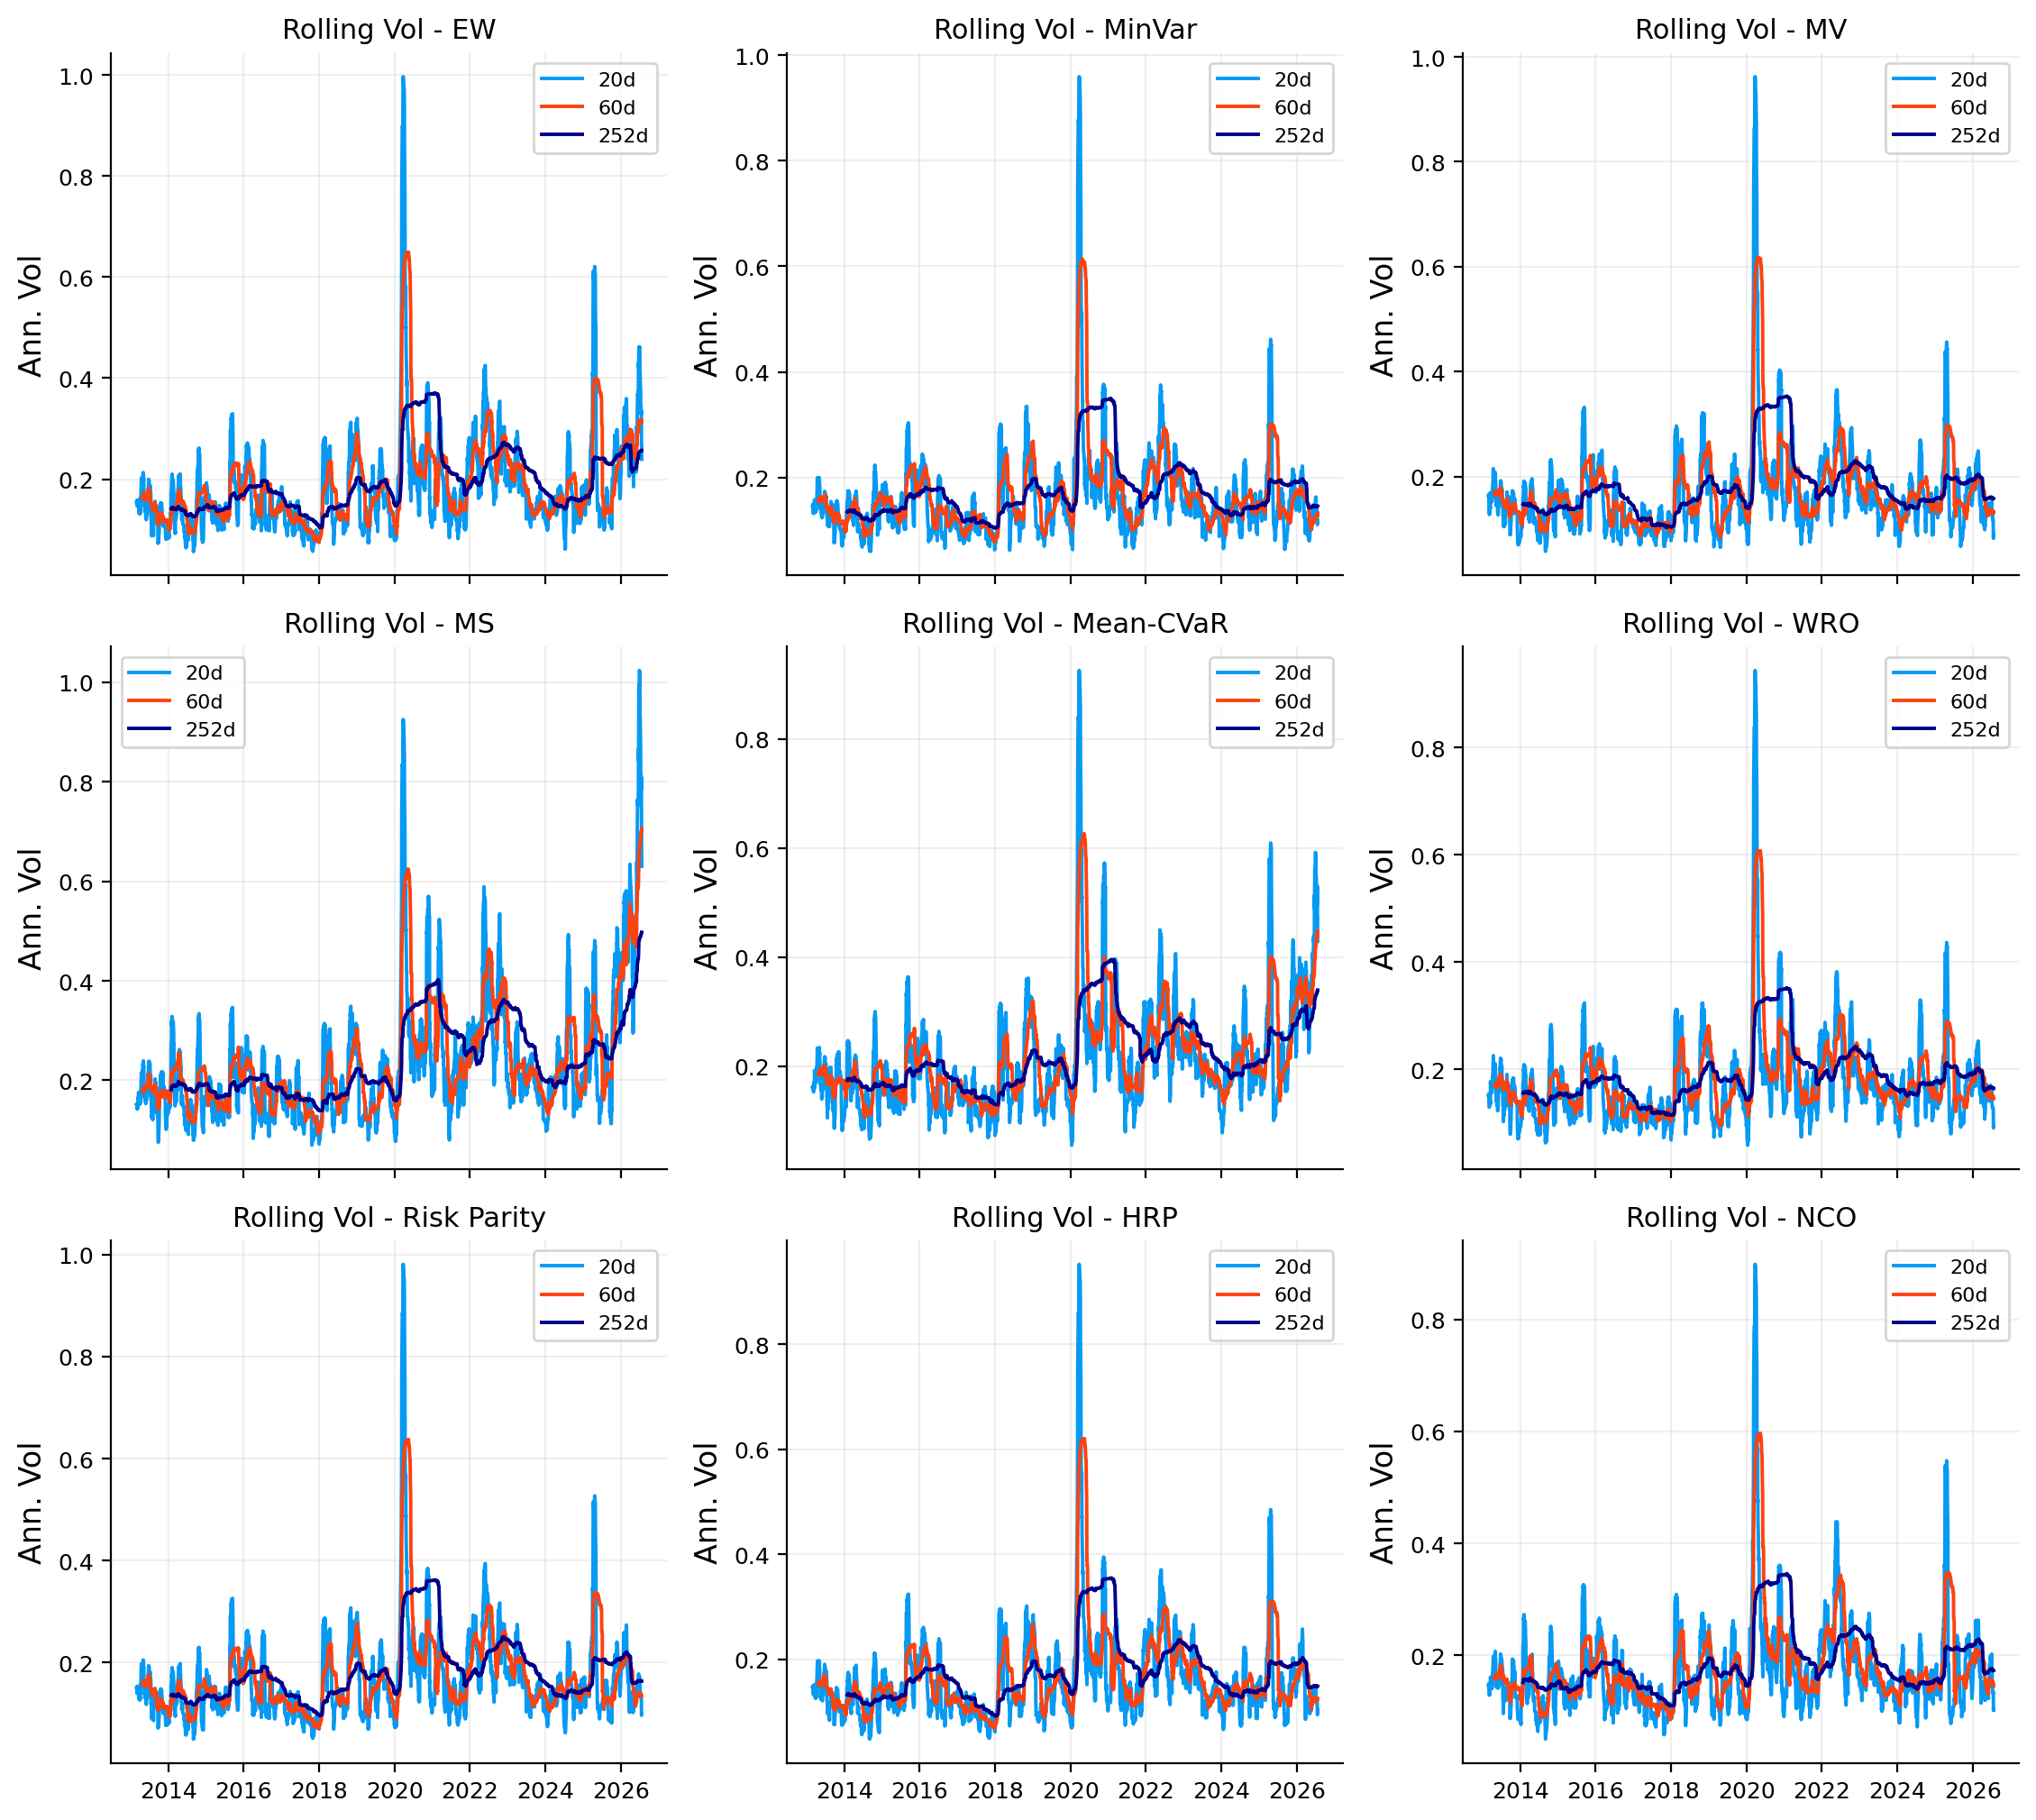

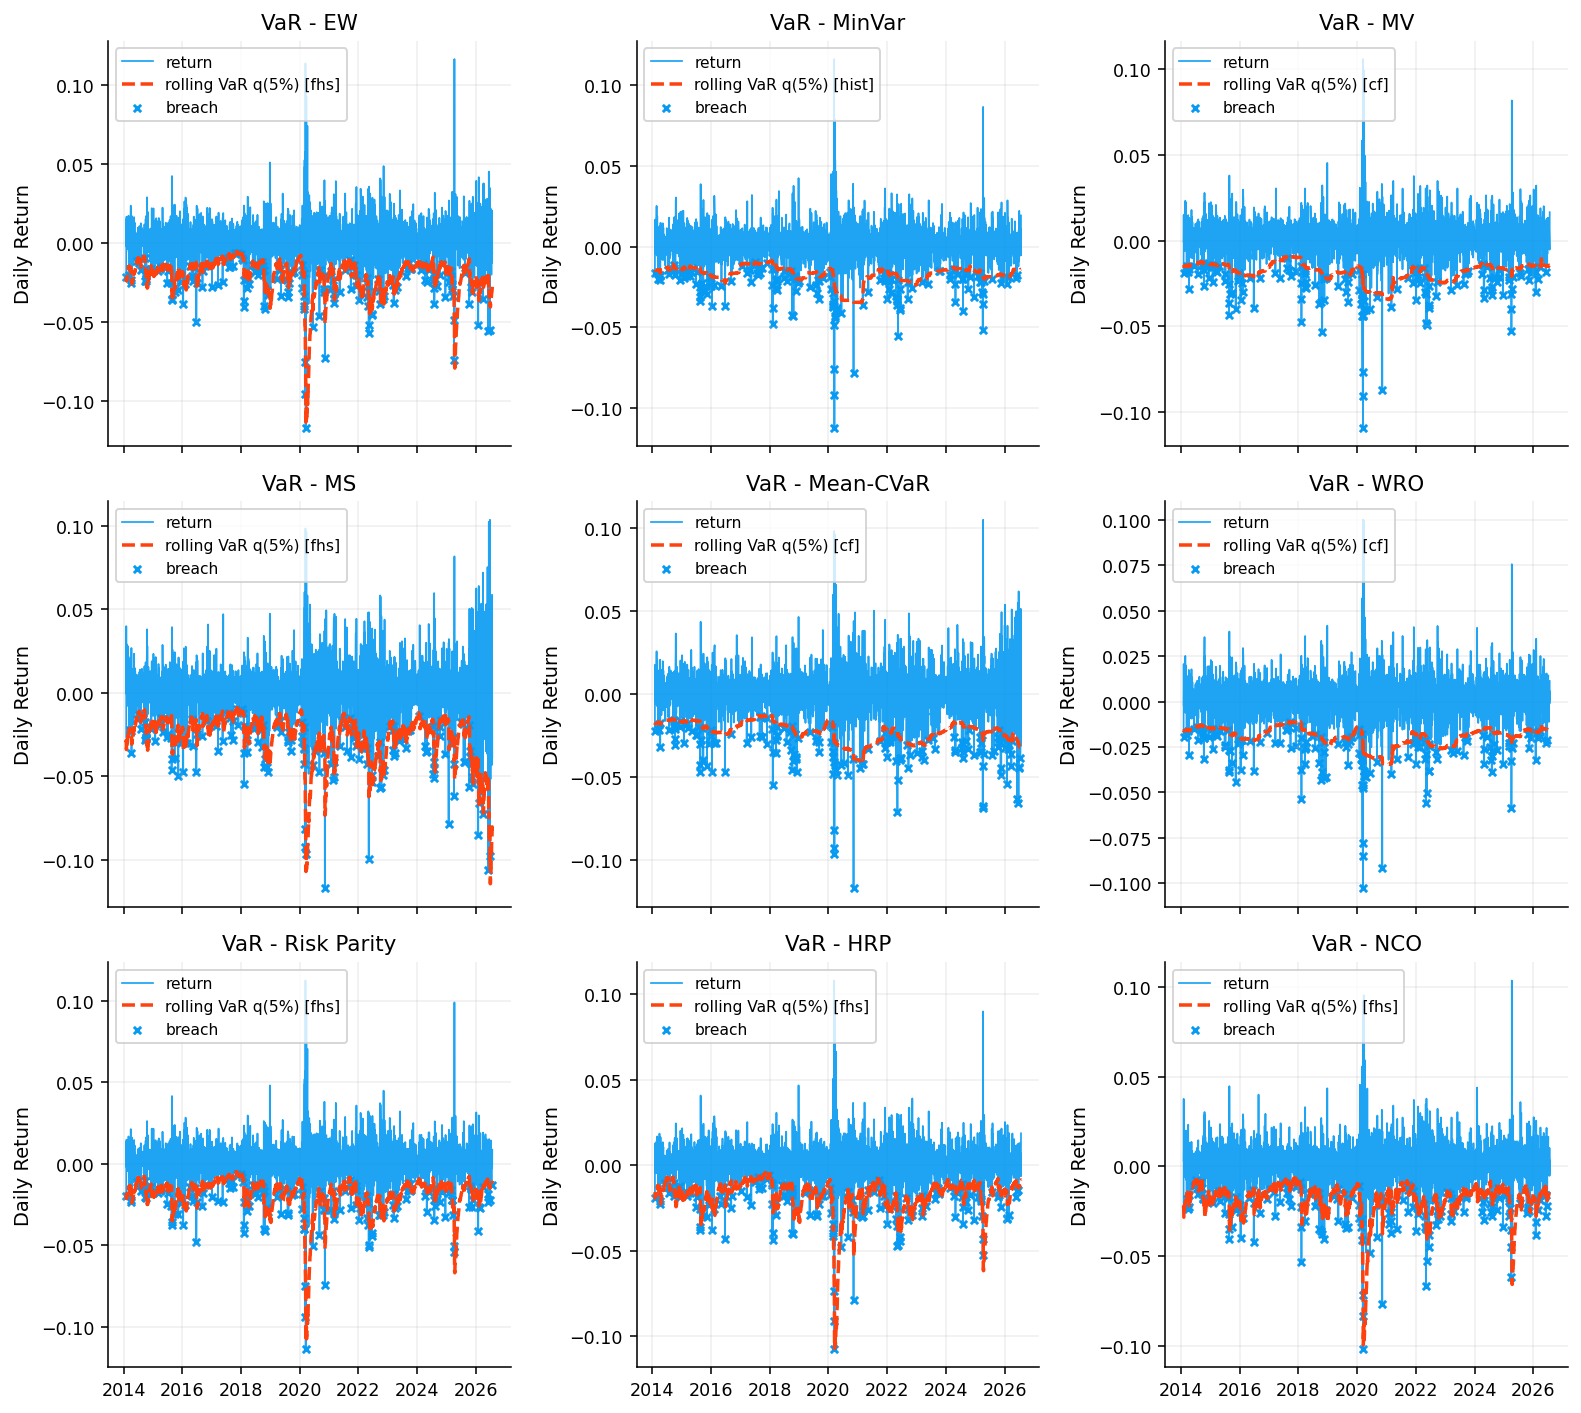

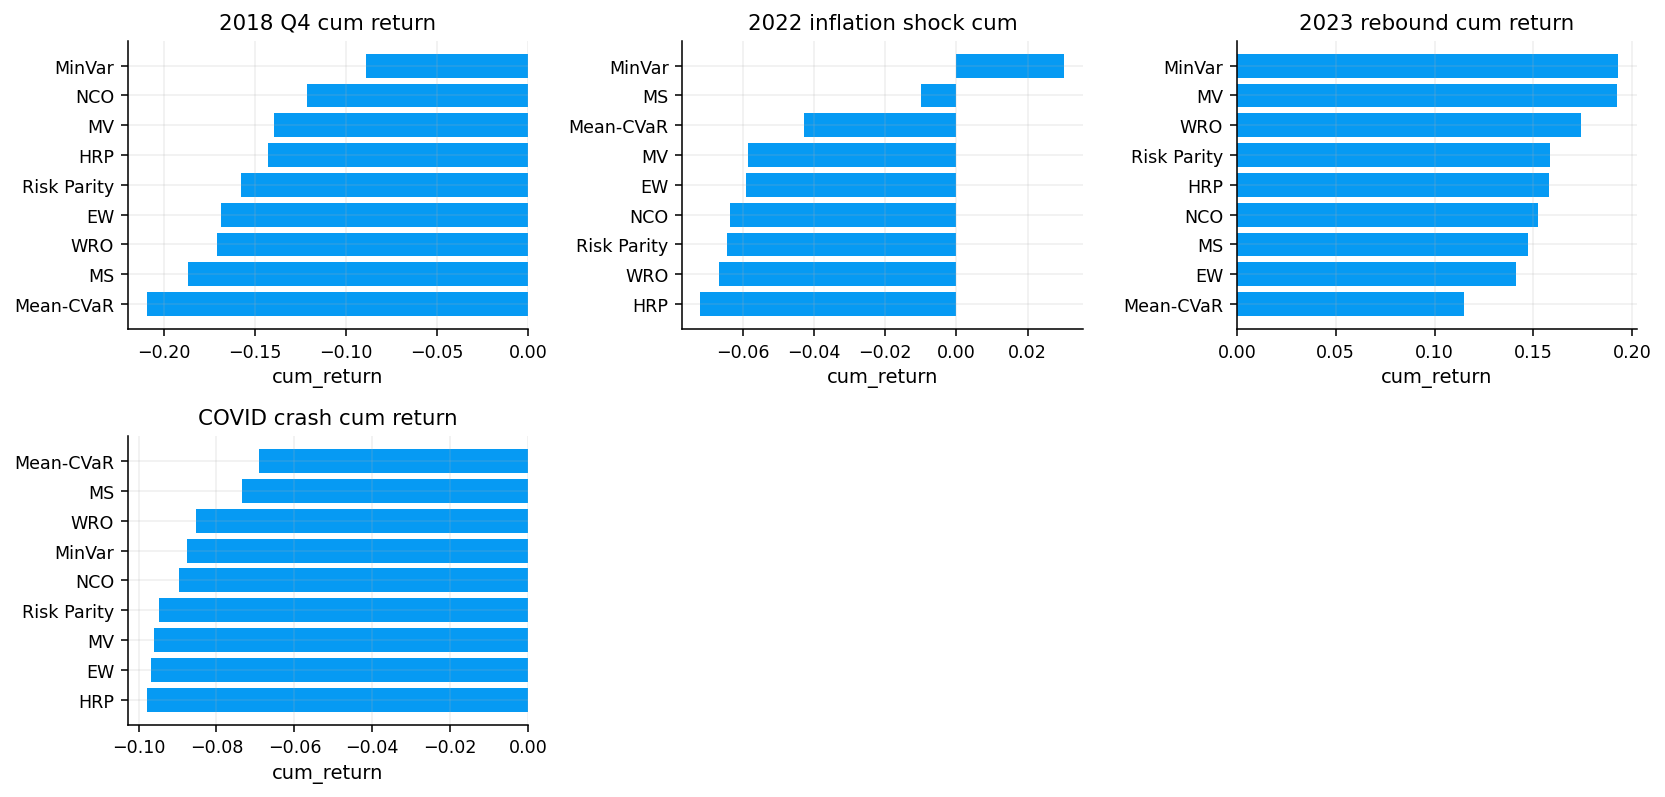

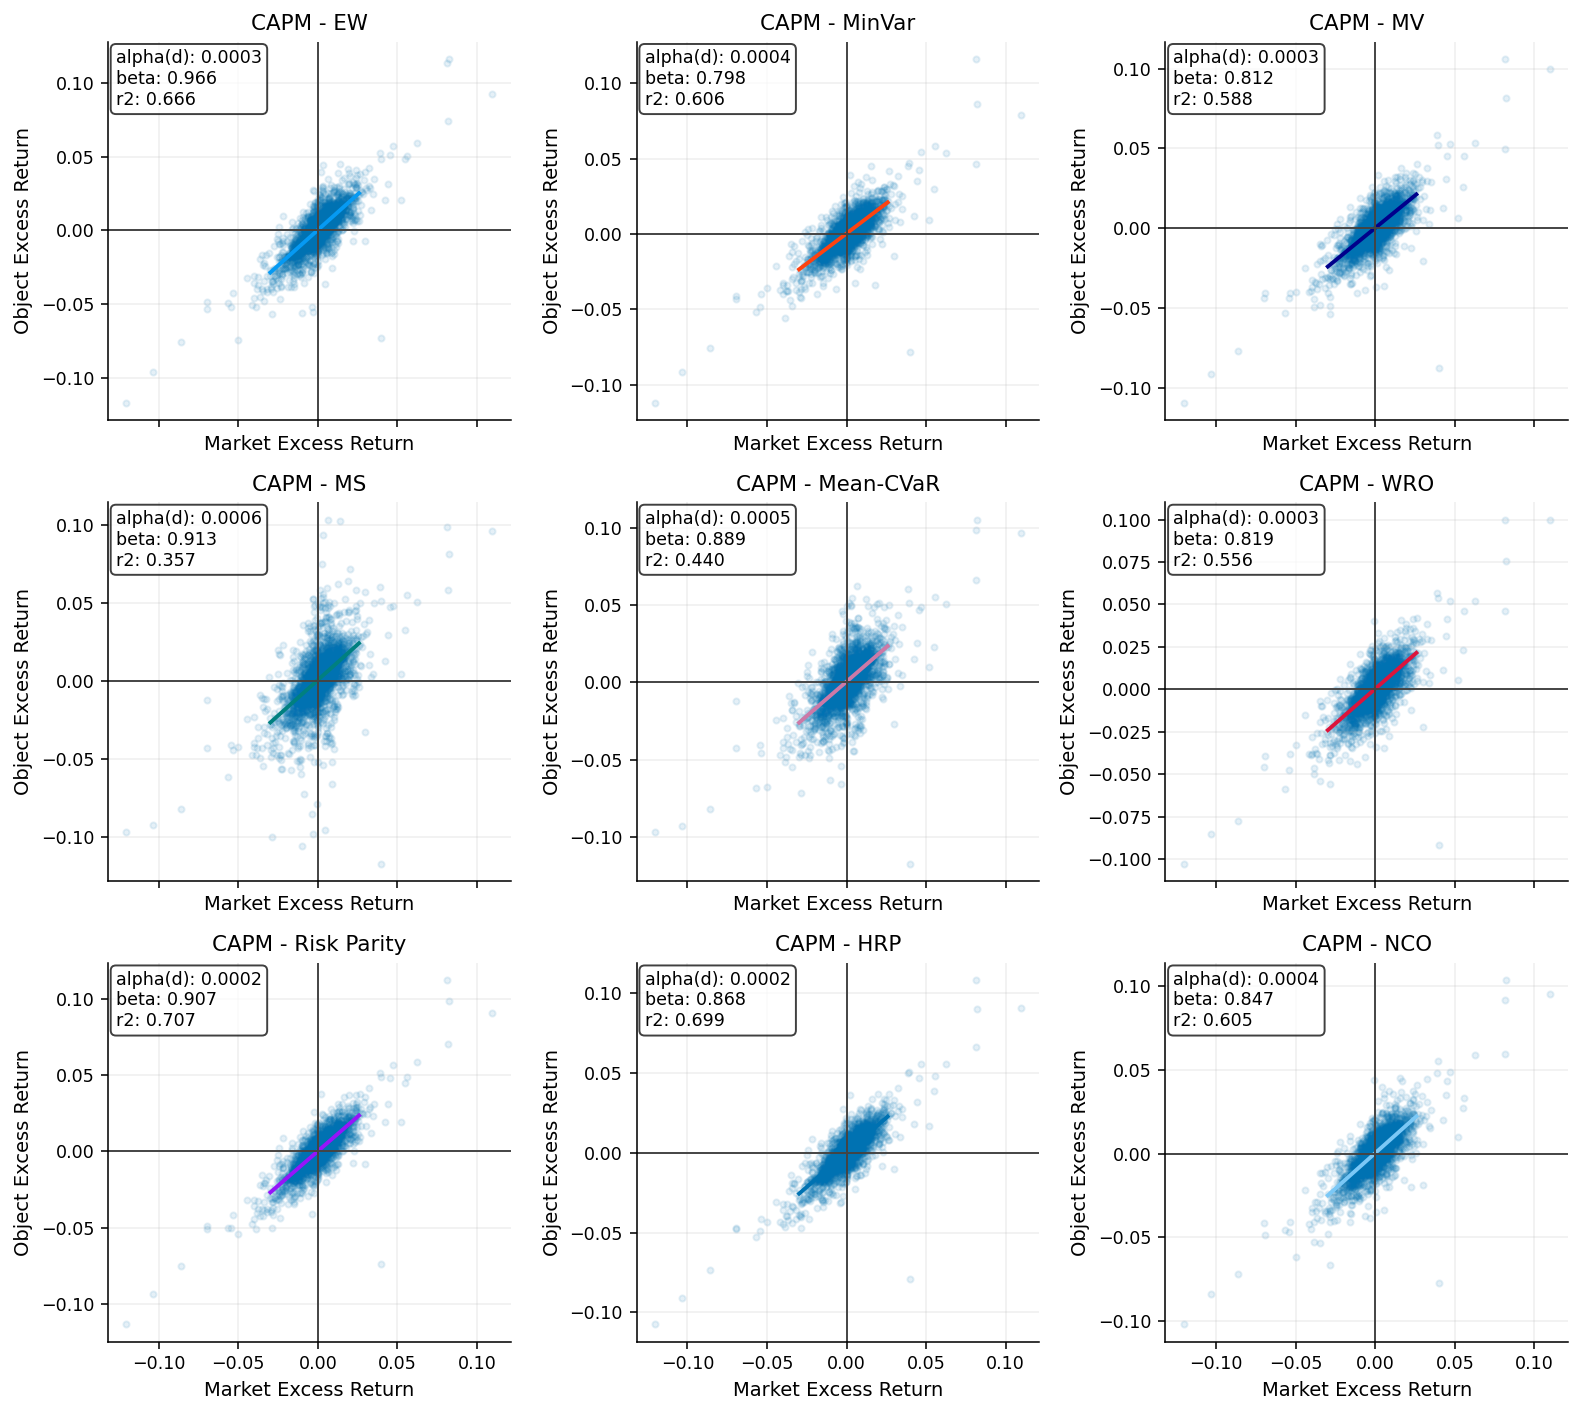

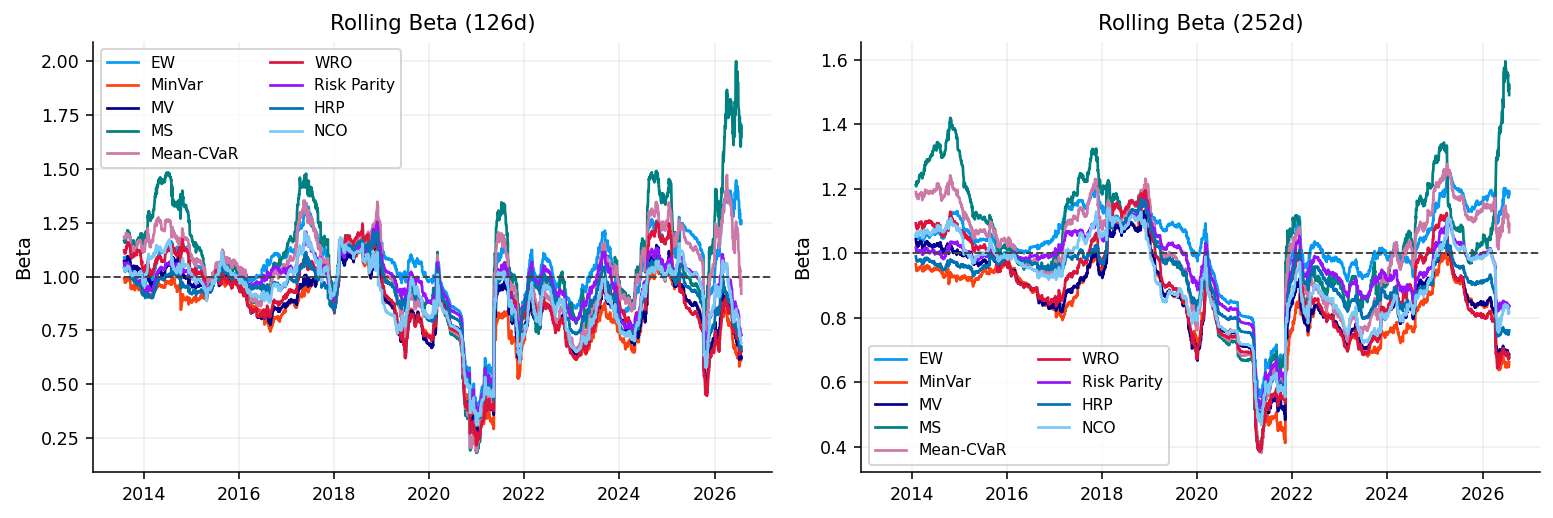

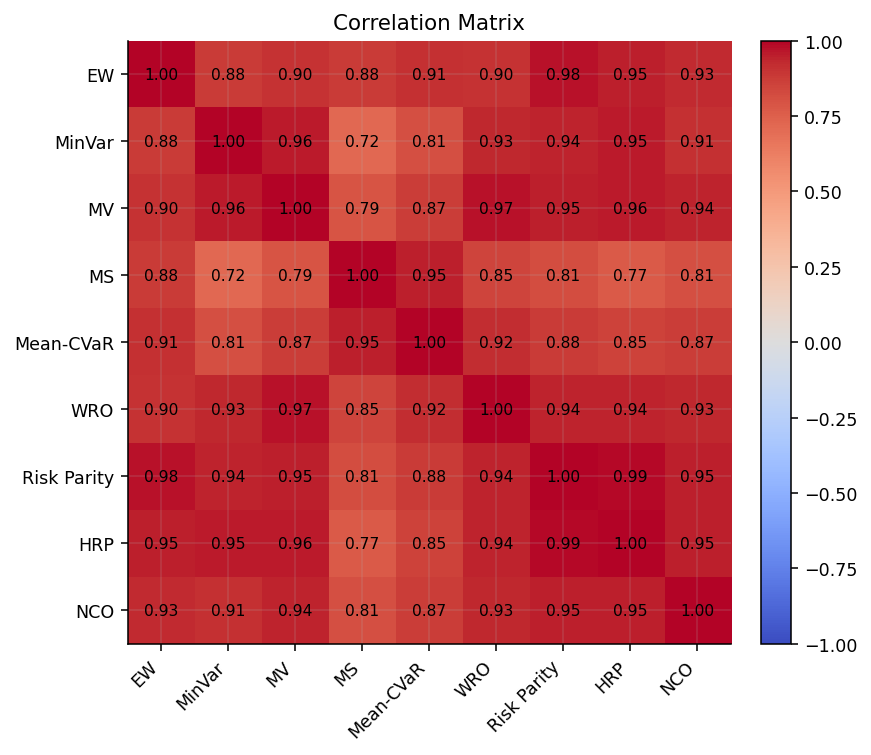

39

In [58]:
stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-03", "2023-12-29"),
}
available_stress_windows = {
    name: window for name, window in stress_windows.items()
    if strategy_returns.index.min() <= pd.Timestamp(window[1])
    and strategy_returns.index.max() >= pd.Timestamp(window[0])
}
full_market_return = full_ew.net_returns.reindex(strategy_returns.index)

layer3_risk_report = risk_report(
    objects={name: strategy_returns[name].dropna() for name in layer3_results},
    market_ret=full_market_return,
    rf_daily=rf_daily,
    include={
        "performance_tables": True,
        "shape_tables": False,
        "drawdowns": False,
        "rolling_vol": True,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": True,
        "rolling_beta": True,
        "correlation": True,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={
        "alpha": 0.05, "methods": ["hist", "cf", "fhs"],
        "lookback": 252, "plot_method": "best",
    },
    rolling_settings={
        "vol_windows": [20, 60, 252],
        "beta_windows": [126, 252],
    },
    stress_settings={
        "windows": available_stress_windows, "worst_only": False,
    },
    layout={"ncols": 3, "sharex": True, "sharey": False},
    output={
        "display_tables": True,
        "show_figures": True,
        "display_table_keys": [
            "performance", "var_es", "var_backtest", "stress", "capm", "corr",
        ],
        "print_exec_bullets": False,
        "short_labels": False,
        "round_tables": 4,
    },
)


del top15_grid, top15_results, additional_results
del layer1_results, layer2_results, layer3_results
del full_ew, top50_ew, top100_ew, strategy_weights
del adj_close, adj_close_filled, returns, monthly_universe
del stock_selections, portfolio_universes, seasoned_observations
del strategy_returns, monthly_prices, price_signals
gc.collect()


,section,value
metric,,
gross_margin,profitability,0.4081
operating_margin,profitability,NaN
net_margin,profitability,0.0484
fcf_margin,profitability,0.0225
gross_profitability_assets,profitability,0.5073
...,...,...
ev_fcf,valuation,NaN
ebit_ev,valuation,NaN
sales_ev,valuation,NaN


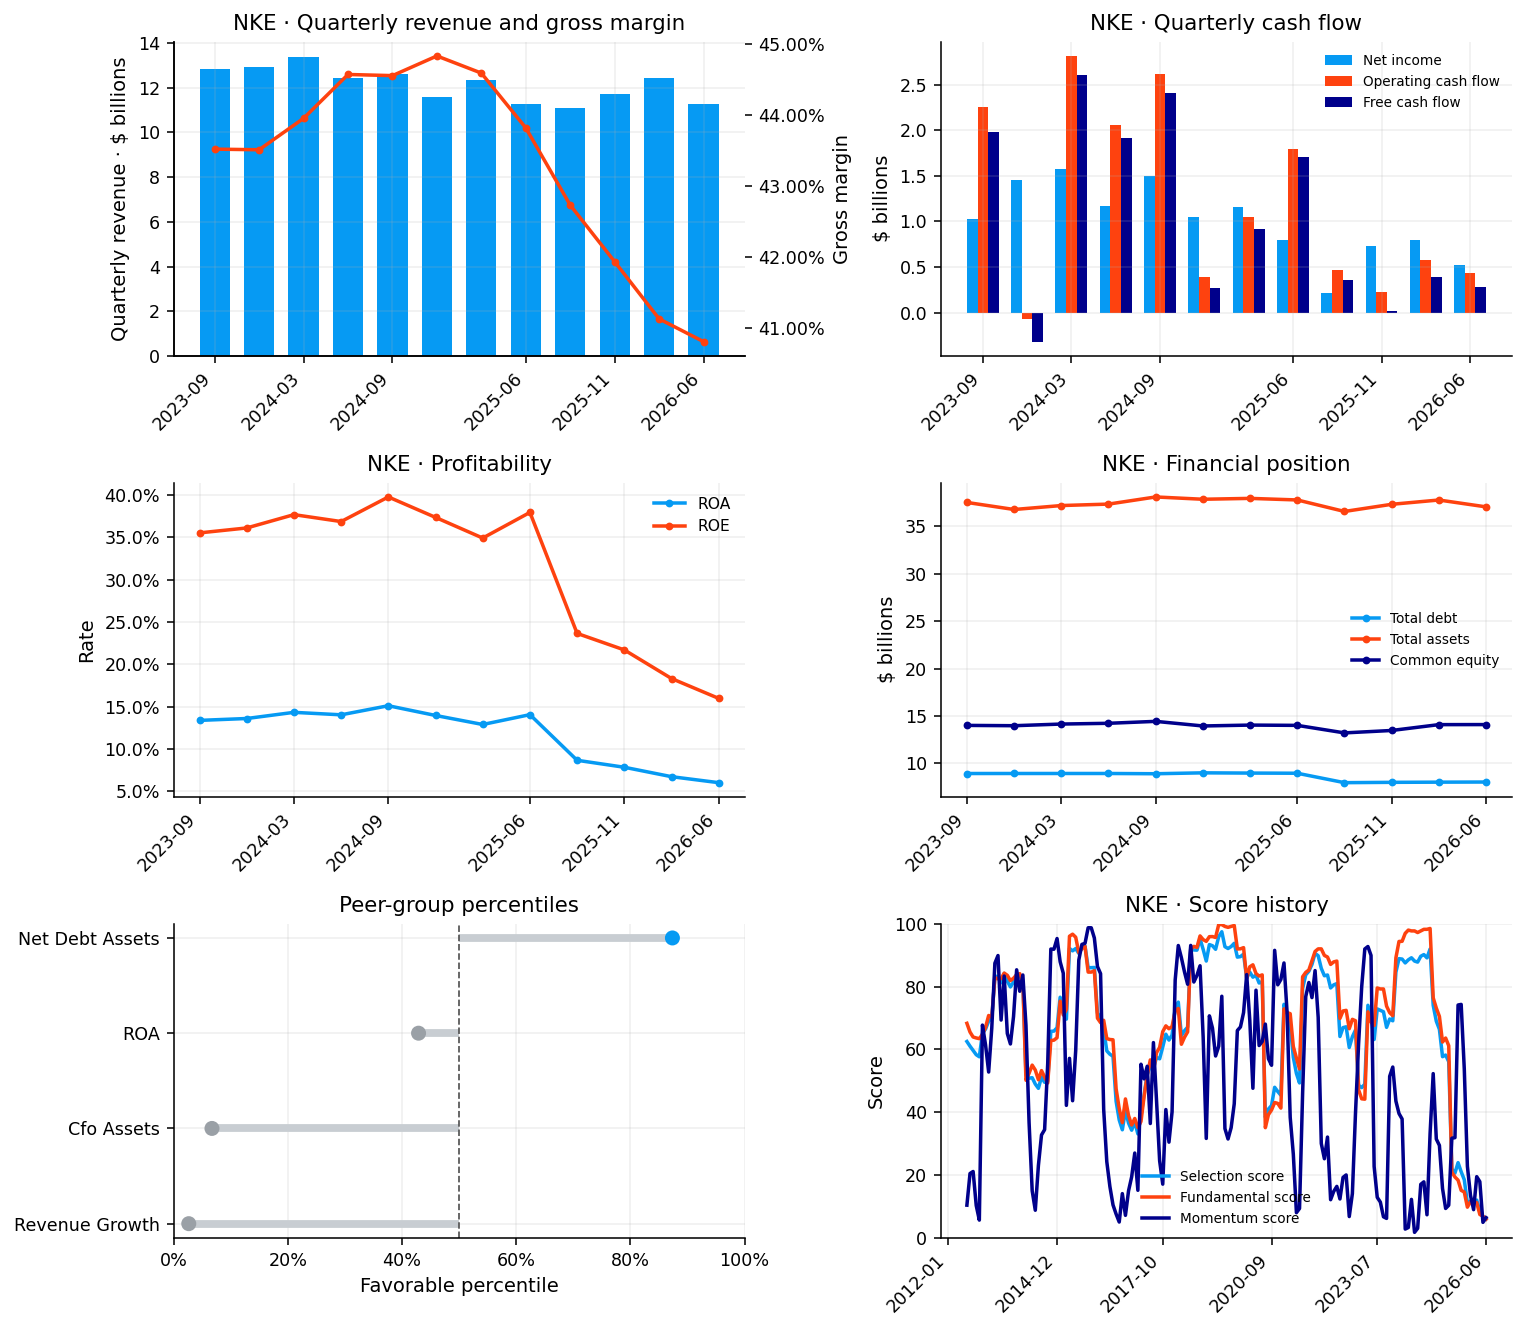

NKE fundamental report as of 2026-06-30.
selection score: 6.02.
Active reported warnings: 1.


,section,value
metric,,
fin_roa,profitability,0.0369
fin_roe,profitability,0.3326
fin_pretax_assets,profitability,0.0468
fin_net_margin,profitability,0.2659
fin_positive_earnings_frequency,profitability,1.0000
fin_net_income_variability,cash_quality,0.1257
fin_roa_variability,cash_quality,0.0661
fin_roe_variability,cash_quality,0.0628
positive_earnings_frequency,cash_quality,1.0000


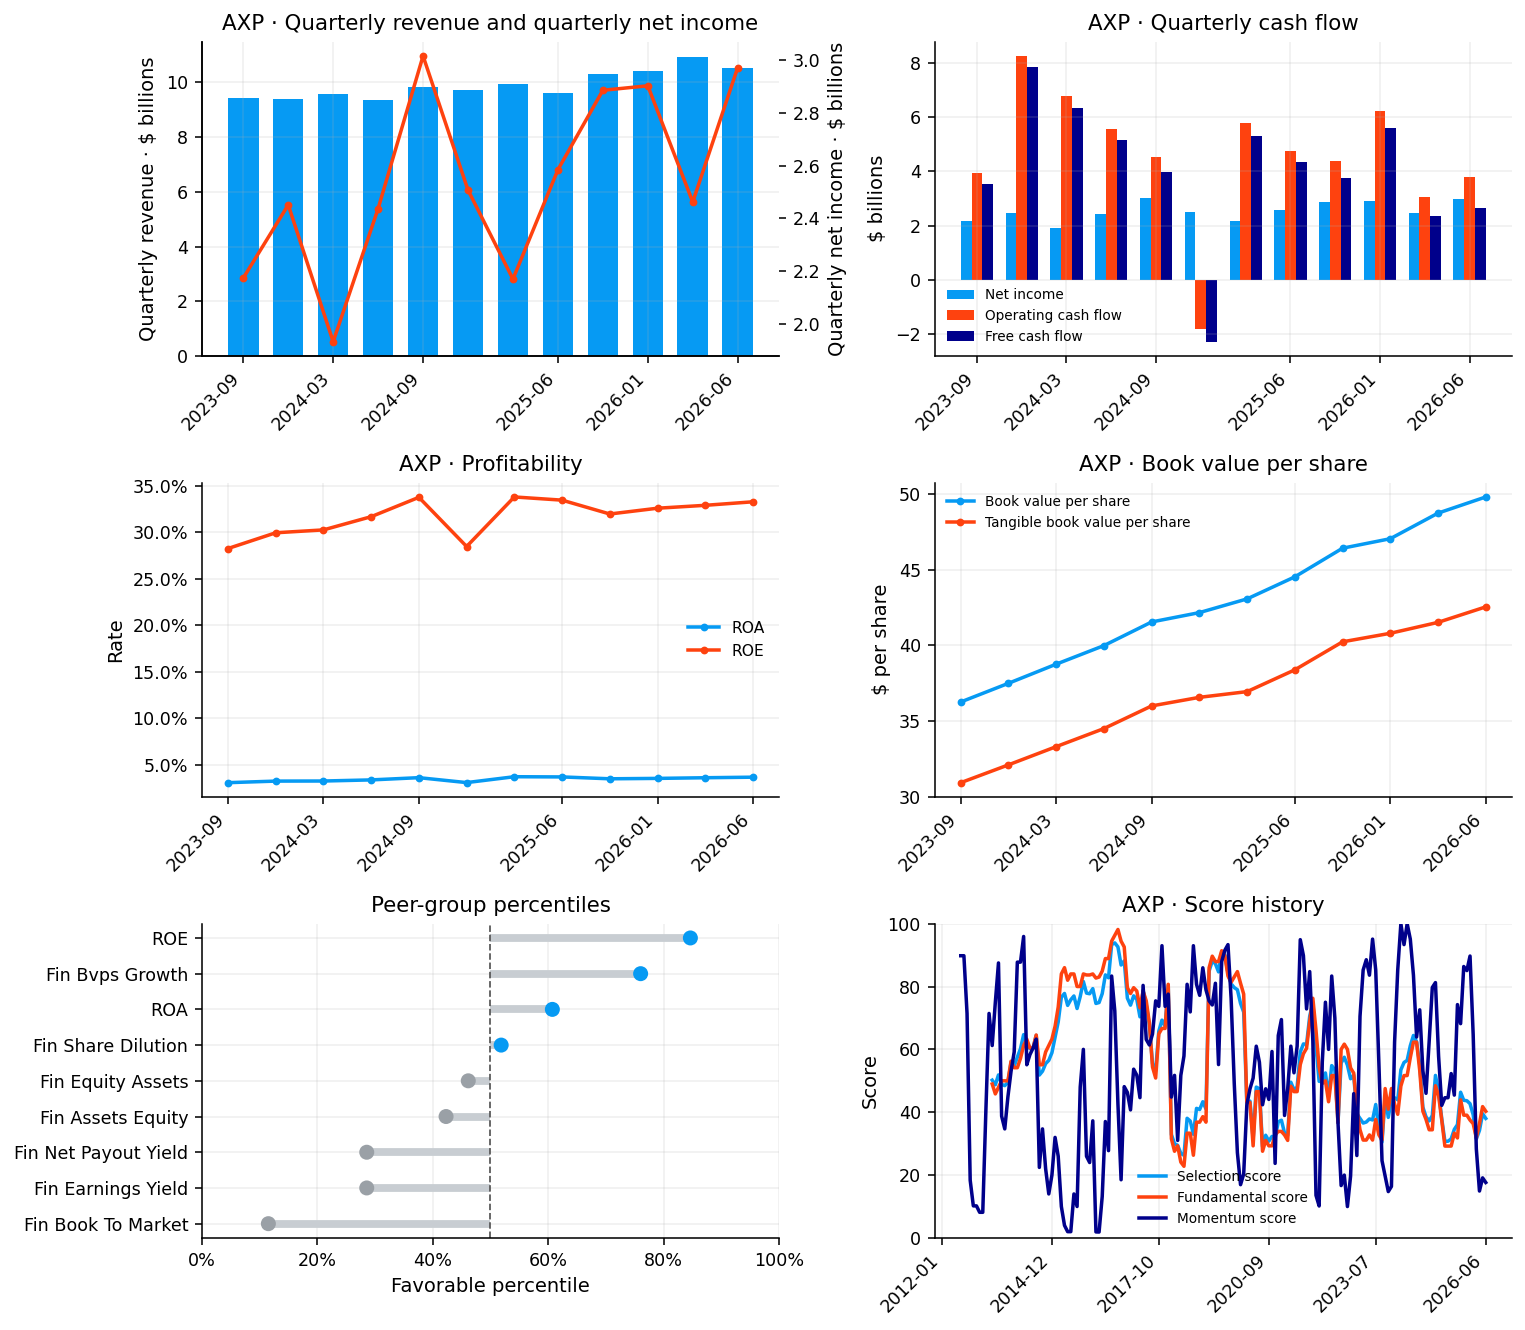

AXP fundamental report as of 2026-06-30.
selection score: 38.03.
Active reported warnings: 0.


In [59]:
from pathlib import Path as path_cls

import gc

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.ticker import PercentFormatter as percent_formatter

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio import (
    load_par_yield_curve,
    read_equity_history,
    read_sec_facts,
    read_sec_metadata,
    risk_free_returns,
)
from quantfinlab.fundamentals import (
    analysis as fundamental_math,
    classify_duration_facts,
    issuer_universe,
    monthly_statement_values,
    periodic_forms,
    reconstruct_quarters,
    scoring as score_math,
    select_filing_facts,
    statement_concepts,
    statement_reconstruction_checks,
)
from quantfinlab.plotting import fundamentals as fundamental_plots, portfolio as portfolio_plots
from quantfinlab.portfolio import covariance, expected_returns, optimizers, selection
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.hrp import hrp_weight_frame, nco_mv_weight_frame
from quantfinlab.portfolio.risk_parity import risk_parity_weight_frame
from quantfinlab.portfolio.robust import wasserstein_weight_frame
from quantfinlab.portfolio.walkforward import (
    run_equal_weight_walkforward, run_walkforward_grid,
)
from quantfinlab.reports import fundamental_report, risk_report

repo_root = path_cls.cwd()
if not (repo_root / "data" / "sp500_market_data.parquet").exists():
    repo_root = repo_root.parent

market_path = repo_root / "data" / "sp500_market_data.parquet"
fundamentals_path = repo_root / "data" / "sp500_fundamentals.parquet"
treasury_path = repo_root / "data" / "us_treasury_yields.csv"
statement_cache = (
    repo_root / "data" / "datasets" / "project21" / "monthly_filing_financials_v2.parquet"
)

warmup_start = pd.Timestamp("2012-01-01")
backtest_start = pd.Timestamp("2013-01-01")
top_n_values = (15, 50, 100)
lookback = 189
minimum_observations = 177
maximum_weight = 0.20
mean_variance_lambda = 10.0
trading_cost_bps = 10.0
turnover_penalty_bps = 10.0
annualization = 252.0

equity_data = read_equity_history(
    market_path,
    start=warmup_start,
    columns=[
        "date", "ticker", "adj_close", "is_sp500_member",
        "industry", "market_cap",
    ],
    drop_partial_last_date=True,
    validate=True,
)
market_data = equity_data["market"]
adj_close = equity_data["adj_close"]
adj_close_filled = equity_data["adj_close_filled"]
volume = equity_data["volume"]
returns = equity_data["returns"]
date_map = equity_data["date_map"]
del equity_data, volume

sec_data = read_sec_metadata(
    fundamentals_path,
    include_concepts=False,
    include_mappings=True,
    validate=True,
)
monthly_issuers = issuer_universe(
    market_data,
    sec_data["mappings"],
    date_map,
    exclude_reits=True,
)
required_concepts = sorted(
    {
        concept
        for statement_group in statement_concepts.values()
        for candidates in statement_group.values()
        for concept in candidates
    }
)
sec_facts = read_sec_facts(
    fundamentals_path,
    concepts=required_concepts,
    ciks=monthly_issuers["cik"].unique(),
    forms=periodic_forms,
    period_start=warmup_start,
    validate=True,
)
classified_facts = classify_duration_facts(sec_facts)
latest_facts = select_filing_facts(classified_facts)
_, quarter_candidates = reconstruct_quarters(latest_facts)
monthly_statements = monthly_statement_values(
    classified_facts,
    monthly_issuers,
    cache=statement_cache,
    force=False,
)
statement_checks = statement_reconstruction_checks(
    quarter_candidates,
    monthly_statements,
)
del sec_data, sec_facts, classified_facts, latest_facts, quarter_candidates
del market_data
fundamental_metrics = monthly_issuers.merge(
    monthly_statements,
    on=["decision_date", "cik"],
    how="left",
    validate="one_to_one",
)
del monthly_statements
gc.collect()

for statement_name in statement_concepts["duration"]:
    fundamental_metrics[statement_name] = fundamental_metrics[f"{statement_name}_ttm"]

fundamental_metrics["gross_profit"] = fundamental_metrics["gross_profit"].combine_first(
    fundamental_metrics["revenue"] - fundamental_metrics["cost_of_revenue"]
)
fundamental_metrics["free_cash_flow"] = fundamental_math.free_cash_flow(
    fundamental_metrics["cfo"],
    fundamental_metrics["capex"],
)
fundamental_metrics["free_cash_flow_q"] = fundamental_math.free_cash_flow(
    fundamental_metrics["cfo_q"],
    fundamental_metrics["capex_q"],
)
fundamental_metrics["total_liabilities"] = fundamental_metrics["total_liabilities"].combine_first(
    fundamental_metrics["total_assets"] - fundamental_metrics["common_equity"]
)
fundamental_metrics["total_debt"] = fundamental_math.total_debt(
    fundamental_metrics["total_debt_reported"],
    fundamental_metrics["long_term_debt_noncurrent"],
    fundamental_metrics["debt_current"],
    fundamental_metrics["short_term_borrowings"],
)
current_debt = fundamental_metrics["debt_current"].combine_first(
    fundamental_metrics["short_term_borrowings"]
)
component_debt = (fundamental_metrics["long_term_debt_noncurrent"] + current_debt).where(
    fundamental_metrics["long_term_debt_noncurrent"].notna() & current_debt.notna()
)
fundamental_metrics["total_debt_source"] = np.select(
    [
        fundamental_metrics["total_debt_reported"].notna(),
        component_debt.notna(),
    ],
    ["reported total", "long-term plus current"],
    default="missing",
)
fundamental_metrics["tangible_equity"] = fundamental_math.tangible_equity(
    fundamental_metrics["common_equity"],
    fundamental_metrics["goodwill"],
    fundamental_metrics["intangibles"],
)
fundamental_metrics["tangible_equity_approx"] = fundamental_math.tangible_equity(
    fundamental_metrics["common_equity"],
    fundamental_metrics["goodwill"],
    fundamental_metrics["intangibles"],
    approximate=True,
)
fundamental_metrics["tangible_equity_source"] = np.where(
    fundamental_metrics["tangible_equity"].notna(),
    "reported components",
    "approximation",
)
fundamental_metrics["enterprise_value"] = fundamental_math.enterprise_value(
    fundamental_metrics["market_cap"],
    fundamental_metrics["total_debt"],
    fundamental_metrics["cash"],
)
fundamental_metrics["net_debt"] = fundamental_math.net_debt(
    fundamental_metrics["total_debt"],
    fundamental_metrics["cash"],
)
fundamental_metrics["working_capital"] = fundamental_math.working_capital(
    fundamental_metrics["current_assets"],
    fundamental_metrics["current_liabilities"],
)
fundamental_metrics["net_payout_amount"] = fundamental_math.net_payout_amount(
    fundamental_metrics["dividends"],
    fundamental_metrics["repurchases"],
    fundamental_metrics["share_issuance"],
)

fundamental_metrics["average_assets"] = fundamental_math.average_balance(
    fundamental_metrics["total_assets"],
    fundamental_metrics["total_assets_prior"],
)
fundamental_metrics["average_equity"] = fundamental_math.average_balance(
    fundamental_metrics["common_equity"],
    fundamental_metrics["common_equity_prior"],
)
prior_tangible_equity = fundamental_math.tangible_equity(
    fundamental_metrics["common_equity_prior"],
    fundamental_metrics["goodwill_prior"],
    fundamental_metrics["intangibles_prior"],
)
fundamental_metrics["average_tangible_equity"] = fundamental_math.average_balance(
    fundamental_metrics["tangible_equity"],
    prior_tangible_equity,
)
fundamental_metrics["average_receivables"] = fundamental_math.average_balance(
    fundamental_metrics["receivables"],
    fundamental_metrics["receivables_prior"],
)
fundamental_metrics["average_inventory"] = fundamental_math.average_balance(
    fundamental_metrics["inventory"],
    fundamental_metrics["inventory_prior"],
)
fundamental_metrics["average_payables"] = fundamental_math.average_balance(
    fundamental_metrics["accounts_payable"],
    fundamental_metrics["accounts_payable_prior"],
)
prior_debt = fundamental_math.annual_lag(
    fundamental_metrics["total_debt"],
    fundamental_metrics["cik"],
)
fundamental_metrics["average_debt"] = fundamental_math.average_balance(
    fundamental_metrics["total_debt"],
    prior_debt,
)

fundamental_metrics["revenue_per_share"] = fundamental_math.revenue_per_share(
    fundamental_metrics["revenue"],
    fundamental_metrics["shares_outstanding"],
)
fundamental_metrics["earnings_per_share"] = fundamental_math.earnings_per_share(
    fundamental_metrics["eps_diluted"],
    fundamental_metrics["net_income"],
    shares_outstanding=fundamental_metrics["shares_outstanding"],
)
fundamental_metrics["eps_source"] = np.where(
    fundamental_metrics["eps_diluted"].notna(),
    "reported diluted EPS",
    "point-in-time share approximation",
)
fundamental_metrics["fcf_per_share"] = fundamental_math.fcf_per_share(
    fundamental_metrics["free_cash_flow"],
    fundamental_metrics["shares_outstanding"],
)
fundamental_metrics["book_value_per_share"] = fundamental_math.book_value_per_share(
    fundamental_metrics["common_equity"],
    fundamental_metrics["shares_outstanding"],
)
fundamental_metrics["tangible_book_value_per_share"] = (
    fundamental_math.tangible_book_value_per_share(
        fundamental_metrics["tangible_equity"],
        fundamental_metrics["shares_outstanding"],
    )
)
fundamental_metrics["shareholder_yield"] = fundamental_math.shareholder_yield(
    fundamental_metrics["net_payout_amount"],
    fundamental_metrics["market_cap"],
)

issuer_keys = fundamental_metrics["cik"]
fundamental_metrics["assets_growth"] = fundamental_math.annual_growth(
    fundamental_metrics["total_assets"],
    issuer_keys,
)
fundamental_metrics["equity_growth"] = fundamental_math.annual_growth(
    fundamental_metrics["common_equity"],
    issuer_keys,
)
fundamental_metrics["shares_growth"] = fundamental_math.annual_growth(
    fundamental_metrics["shares_outstanding"],
    issuer_keys,
)
fundamental_metrics["working_capital_change"] = fundamental_math.annual_change(
    fundamental_metrics["working_capital"],
    issuer_keys,
)

fundamental_metrics["gross_margin"] = fundamental_math.gross_margin(
    fundamental_metrics["gross_profit"],
    fundamental_metrics["revenue"],
)
fundamental_metrics["operating_margin"] = fundamental_math.operating_margin(
    fundamental_metrics["operating_income"],
    fundamental_metrics["revenue"],
)
fundamental_metrics["pretax_margin"] = fundamental_math.pretax_margin(
    fundamental_metrics["pretax_income"],
    fundamental_metrics["revenue"],
)
fundamental_metrics["net_margin"] = fundamental_math.net_margin(
    fundamental_metrics["net_income"],
    fundamental_metrics["revenue"],
)
fundamental_metrics["fcf_margin"] = fundamental_math.fcf_margin(
    fundamental_metrics["free_cash_flow"],
    fundamental_metrics["revenue"],
)
fundamental_metrics["gross_profitability_assets"] = fundamental_math.gross_profitability_assets(
    fundamental_metrics["gross_profit"],
    fundamental_metrics["average_assets"],
)
fundamental_metrics["roa"] = fundamental_math.return_on_assets(
    fundamental_metrics["net_income"],
    fundamental_metrics["average_assets"],
)
fundamental_metrics["roe"] = fundamental_math.return_on_equity(
    fundamental_metrics["net_income"],
    fundamental_metrics["average_equity"],
)
fundamental_metrics["return_on_tangible_equity"] = fundamental_math.return_on_tangible_equity(
    fundamental_metrics["net_income"],
    fundamental_metrics["average_tangible_equity"],
)
tax_rate = fundamental_math.effective_tax_rate(
    fundamental_metrics["tax_expense"],
    fundamental_metrics["pretax_income"],
)
fundamental_metrics["nopat"] = fundamental_math.net_operating_profit_after_tax(
    fundamental_metrics["operating_income"],
    tax_rate,
)
capital = fundamental_math.invested_capital(
    fundamental_metrics["average_debt"],
    fundamental_metrics["average_equity"],
    fundamental_metrics["cash"],
)
fundamental_metrics["roic_proxy"] = fundamental_math.return_on_invested_capital(
    fundamental_metrics["nopat"],
    capital,
)
fundamental_metrics["asset_turnover"] = fundamental_math.asset_turnover(
    fundamental_metrics["revenue"],
    fundamental_metrics["average_assets"],
)

fundamental_metrics["cfo_assets"] = fundamental_math.cfo_to_assets(
    fundamental_metrics["cfo"],
    fundamental_metrics["average_assets"],
)
fundamental_metrics["fcf_assets"] = fundamental_math.fcf_to_assets(
    fundamental_metrics["free_cash_flow"],
    fundamental_metrics["average_assets"],
)
fundamental_metrics["cfo_net_income"] = fundamental_math.cfo_to_net_income(
    fundamental_metrics["cfo"],
    fundamental_metrics["net_income"],
)
fundamental_metrics["fcf_conversion"] = fundamental_math.fcf_conversion(
    fundamental_metrics["free_cash_flow"],
    fundamental_metrics["net_income"],
)
fundamental_metrics["total_accruals"] = fundamental_math.total_accruals(
    fundamental_metrics["net_income"],
    fundamental_metrics["cfo"],
    fundamental_metrics["average_assets"],
)
fundamental_metrics["working_capital_accruals"] = fundamental_math.working_capital_accruals(
    fundamental_metrics["working_capital_change"],
    fundamental_metrics["average_assets"],
)
fundamental_metrics["cash_earnings_gap"] = fundamental_math.cash_earnings_gap(
    fundamental_metrics["net_income"],
    fundamental_metrics["cfo"],
)
fundamental_metrics["positive_cfo_frequency"] = fundamental_math.positive_cfo_frequency(
    fundamental_metrics["cfo"],
    issuer_keys,
)
fundamental_metrics["positive_fcf_frequency"] = fundamental_math.positive_fcf_frequency(
    fundamental_metrics["free_cash_flow"],
    issuer_keys,
)

fundamental_metrics["revenue_growth"] = fundamental_metrics["revenue_ttm_yoy"].combine_first(
    fundamental_math.annual_growth(fundamental_metrics["revenue"], issuer_keys)
)
fundamental_metrics["gross_profit_growth"] = fundamental_metrics[
    "gross_profit_ttm_yoy"
].combine_first(
    fundamental_math.annual_growth(
        fundamental_metrics["gross_profit"],
        issuer_keys,
    )
)
fundamental_metrics["operating_income_growth"] = fundamental_metrics[
    "operating_income_ttm_yoy"
].combine_first(
    fundamental_math.annual_growth(
        fundamental_metrics["operating_income"],
        issuer_keys,
    )
)
fundamental_metrics["net_income_growth"] = fundamental_metrics["net_income_ttm_yoy"].combine_first(
    fundamental_math.annual_growth(
        fundamental_metrics["net_income"],
        issuer_keys,
    )
)
fundamental_metrics["cfo_growth"] = fundamental_metrics["cfo_ttm_yoy"].combine_first(
    fundamental_math.annual_growth(fundamental_metrics["cfo"], issuer_keys)
)
fundamental_metrics["fcf_growth"] = fundamental_math.annual_growth(
    fundamental_metrics["free_cash_flow"],
    issuer_keys,
)
fundamental_metrics["eps_growth"] = fundamental_math.annual_growth(
    fundamental_metrics["earnings_per_share"],
    issuer_keys,
)
fundamental_metrics["revenue_per_share_growth"] = fundamental_math.annual_growth(
    fundamental_metrics["revenue_per_share"],
    issuer_keys,
)
fundamental_metrics["book_value_per_share_growth"] = fundamental_math.annual_growth(
    fundamental_metrics["book_value_per_share"],
    issuer_keys,
)
fundamental_metrics["tangible_book_value_per_share_growth"] = fundamental_math.annual_growth(
    fundamental_metrics["tangible_book_value_per_share"],
    issuer_keys,
)
fundamental_metrics["gross_margin_change"] = fundamental_math.annual_change(
    fundamental_metrics["gross_margin"],
    issuer_keys,
)
fundamental_metrics["operating_margin_change"] = fundamental_math.annual_change(
    fundamental_metrics["operating_margin"],
    issuer_keys,
)
fundamental_metrics["roa_change"] = fundamental_math.annual_change(
    fundamental_metrics["roa"],
    issuer_keys,
)
fundamental_metrics["roe_change"] = fundamental_math.annual_change(
    fundamental_metrics["roe"],
    issuer_keys,
)
fundamental_metrics["roic_change"] = fundamental_math.annual_change(
    fundamental_metrics["roic_proxy"],
    issuer_keys,
)
fundamental_metrics["cash_conversion_change"] = fundamental_math.annual_change(
    fundamental_metrics["cfo_net_income"],
    issuer_keys,
)

fundamental_metrics = fundamental_metrics.copy()
fundamental_metrics["current_ratio"] = fundamental_math.current_ratio(
    fundamental_metrics["current_assets"],
    fundamental_metrics["current_liabilities"],
)
fundamental_metrics["cash_ratio"] = fundamental_math.cash_ratio(
    fundamental_metrics["cash"],
    fundamental_metrics["current_liabilities"],
)
fundamental_metrics["debt_equity"] = fundamental_math.debt_to_equity(
    fundamental_metrics["total_debt"],
    fundamental_metrics["common_equity"],
)
fundamental_metrics["debt_assets"] = fundamental_math.debt_to_assets(
    fundamental_metrics["total_debt"],
    fundamental_metrics["total_assets"],
)
fundamental_metrics["debt_assets_prior"] = fundamental_math.annual_lag(
    fundamental_metrics["debt_assets"],
    issuer_keys,
)
fundamental_metrics["net_debt_assets"] = fundamental_math.net_debt_to_assets(
    fundamental_metrics["net_debt"],
    fundamental_metrics["total_assets"],
)
fundamental_metrics["liabilities_assets"] = fundamental_math.liabilities_to_assets(
    fundamental_metrics["total_liabilities"],
    fundamental_metrics["total_assets"],
)
fundamental_metrics["interest_coverage"] = fundamental_math.interest_coverage(
    fundamental_metrics["operating_income"],
    fundamental_metrics["interest_expense"],
)
fundamental_metrics["cfo_debt"] = fundamental_math.cfo_to_debt(
    fundamental_metrics["cfo"],
    fundamental_metrics["total_debt"],
)
fundamental_metrics["fcf_debt"] = fundamental_math.fcf_to_debt(
    fundamental_metrics["free_cash_flow"],
    fundamental_metrics["total_debt"],
)
fundamental_metrics["cash_assets"] = fundamental_math.cash_to_assets(
    fundamental_metrics["cash"],
    fundamental_metrics["total_assets"],
)
fundamental_metrics["tangible_equity_assets"] = fundamental_math.tangible_equity_to_assets(
    fundamental_metrics["tangible_equity"],
    fundamental_metrics["total_assets"],
)
fundamental_metrics["leverage_improvement"] = fundamental_math.leverage_improvement(
    fundamental_metrics["net_debt_assets"],
    issuer_keys,
)

fundamental_metrics["receivable_turnover"] = fundamental_math.receivables_turnover(
    fundamental_metrics["revenue"],
    fundamental_metrics["average_receivables"],
)
fundamental_metrics["days_sales_outstanding"] = fundamental_math.days_sales_outstanding(
    fundamental_metrics["average_receivables"],
    fundamental_metrics["revenue"],
)
fundamental_metrics["inventory_turnover"] = fundamental_math.inventory_turnover(
    fundamental_metrics["cost_of_revenue"],
    fundamental_metrics["average_inventory"],
)
fundamental_metrics["inventory_days"] = fundamental_math.inventory_days(
    fundamental_metrics["average_inventory"],
    fundamental_metrics["cost_of_revenue"],
)
fundamental_metrics["payable_days"] = fundamental_math.payable_days(
    fundamental_metrics["average_payables"],
    fundamental_metrics["cost_of_revenue"],
)
fundamental_metrics["cash_conversion_cycle"] = fundamental_math.cash_conversion_cycle(
    fundamental_metrics["days_sales_outstanding"],
    fundamental_metrics["inventory_days"],
    fundamental_metrics["payable_days"],
)
fundamental_metrics["working_capital_revenue"] = fundamental_math.working_capital_to_revenue(
    fundamental_metrics["working_capital"],
    fundamental_metrics["revenue"],
)

fundamental_metrics["capex_revenue"] = fundamental_math.capex_to_revenue(
    fundamental_metrics["capex"],
    fundamental_metrics["revenue"],
)
fundamental_metrics["capex_depreciation"] = fundamental_math.capex_to_depreciation(
    fundamental_metrics["capex"],
    fundamental_metrics["depreciation"],
)
fundamental_metrics["rd_revenue"] = fundamental_math.research_to_revenue(
    fundamental_metrics["rd_expense"],
    fundamental_metrics["revenue"],
)
fundamental_metrics["reinvestment_proxy"] = fundamental_math.reinvestment_rate(
    fundamental_metrics["capex"],
    fundamental_metrics["depreciation"],
    fundamental_metrics["working_capital_change"],
    fundamental_metrics["nopat"],
)
fundamental_metrics["dividend_payout_ratio"] = fundamental_math.dividend_payout_ratio(
    fundamental_metrics["dividends"],
    fundamental_metrics["net_income"],
)
fundamental_metrics["dividend_coverage_cfo"] = fundamental_math.dividend_coverage_cfo(
    fundamental_metrics["cfo"],
    fundamental_metrics["dividends"],
)
fundamental_metrics["dividend_coverage_fcf"] = fundamental_math.dividend_coverage_fcf(
    fundamental_metrics["free_cash_flow"],
    fundamental_metrics["dividends"],
)
fundamental_metrics["repurchase_yield"] = fundamental_math.repurchase_yield(
    fundamental_metrics["repurchases"],
    fundamental_metrics["market_cap"],
)
fundamental_metrics["issuance_yield"] = fundamental_math.issuance_yield(
    fundamental_metrics["share_issuance"],
    fundamental_metrics["market_cap"],
)
fundamental_metrics["dividend_yield"] = fundamental_math.dividend_yield(
    fundamental_metrics["dividends"],
    fundamental_metrics["market_cap"],
)
fundamental_metrics["net_shareholder_yield"] = fundamental_metrics["shareholder_yield"]
fundamental_metrics["share_count_dilution"] = fundamental_math.share_count_dilution(
    fundamental_metrics["shares_outstanding"],
    issuer_keys,
)
fundamental_metrics["per_share_growth_spread"] = fundamental_math.growth_spread(
    fundamental_metrics["eps_growth"],
    fundamental_metrics["net_income_growth"],
)
fundamental_metrics["book_per_share_growth_spread"] = fundamental_math.growth_spread(
    fundamental_metrics["book_value_per_share_growth"],
    fundamental_metrics["equity_growth"],
)
fundamental_metrics["reinvestment_quality"] = fundamental_math.reinvestment_quality(
    fundamental_metrics["reinvestment_proxy"],
)

fundamental_metrics["earnings_yield"] = fundamental_math.earnings_yield(
    fundamental_metrics["net_income"],
    fundamental_metrics["market_cap"],
)
fundamental_metrics["price_earnings"] = fundamental_math.price_to_earnings(
    fundamental_metrics["market_cap"],
    fundamental_metrics["net_income"],
)
fundamental_metrics["fcf_yield"] = fundamental_math.fcf_yield(
    fundamental_metrics["free_cash_flow"],
    fundamental_metrics["market_cap"],
)
fundamental_metrics["price_fcf"] = fundamental_math.price_to_fcf(
    fundamental_metrics["market_cap"],
    fundamental_metrics["free_cash_flow"],
)
fundamental_metrics["sales_yield"] = fundamental_math.sales_yield(
    fundamental_metrics["revenue"],
    fundamental_metrics["market_cap"],
)
fundamental_metrics["price_sales"] = fundamental_math.price_to_sales(
    fundamental_metrics["market_cap"],
    fundamental_metrics["revenue"],
)
fundamental_metrics["book_to_market"] = fundamental_math.book_to_market(
    fundamental_metrics["common_equity"],
    fundamental_metrics["market_cap"],
)
fundamental_metrics["price_book"] = fundamental_math.price_to_book(
    fundamental_metrics["market_cap"],
    fundamental_metrics["common_equity"],
)
fundamental_metrics["tangible_book_to_market"] = fundamental_math.tangible_book_to_market(
    fundamental_metrics["tangible_equity"],
    fundamental_metrics["market_cap"],
)
fundamental_metrics["price_tangible_book"] = fundamental_math.price_to_tangible_book(
    fundamental_metrics["market_cap"],
    fundamental_metrics["tangible_equity"],
)
fundamental_metrics["ebit_ev"] = fundamental_math.ebit_to_enterprise_value(
    fundamental_metrics["operating_income"],
    fundamental_metrics["enterprise_value"],
)
fundamental_metrics["ev_ebit"] = fundamental_math.enterprise_value_to_ebit(
    fundamental_metrics["enterprise_value"],
    fundamental_metrics["operating_income"],
)
fundamental_metrics["ev_sales"] = fundamental_math.enterprise_value_to_sales(
    fundamental_metrics["enterprise_value"],
    fundamental_metrics["revenue"],
)
fundamental_metrics["sales_ev"] = fundamental_math.sales_to_enterprise_value(
    fundamental_metrics["revenue"],
    fundamental_metrics["enterprise_value"],
)
fundamental_metrics["ev_fcf"] = fundamental_math.enterprise_value_to_fcf(
    fundamental_metrics["enterprise_value"],
    fundamental_metrics["free_cash_flow"],
)

fundamental_metrics = fundamental_metrics.copy()
financial_rows = fundamental_metrics["score_family"].eq("financial")
corporate_rows = fundamental_metrics["score_family"].eq("corporate")
fundamental_metrics["fin_roa"] = fundamental_metrics["roa"].where(financial_rows)
fundamental_metrics["fin_roe"] = fundamental_metrics["roe"].where(financial_rows)
fundamental_metrics["fin_pretax_assets"] = fundamental_math.pretax_return_on_assets(
    fundamental_metrics["pretax_income"],
    fundamental_metrics["average_assets"],
).where(financial_rows)
fundamental_metrics["fin_net_margin"] = fundamental_metrics["net_margin"].where(financial_rows)
fundamental_metrics["fin_equity_assets"] = fundamental_math.equity_to_assets(
    fundamental_metrics["common_equity"],
    fundamental_metrics["total_assets"],
).where(financial_rows)
fundamental_metrics["fin_tangible_equity_assets"] = fundamental_metrics[
    "tangible_equity_assets"
].where(financial_rows)
fundamental_metrics["fin_liabilities_assets"] = fundamental_metrics["liabilities_assets"].where(
    financial_rows
)
fundamental_metrics["fin_assets_equity"] = fundamental_math.assets_to_equity(
    fundamental_metrics["total_assets"],
    fundamental_metrics["common_equity"],
).where(financial_rows)
fundamental_metrics["fin_tangible_bvps"] = fundamental_metrics[
    "tangible_book_value_per_share"
].where(financial_rows)

fundamental_metrics["fin_revenue_growth"] = fundamental_metrics["revenue_growth"].where(
    financial_rows
)
fundamental_metrics["fin_net_income_growth"] = fundamental_metrics["net_income_growth"].where(
    financial_rows
)
fundamental_metrics["fin_asset_growth"] = fundamental_metrics["assets_growth"].where(financial_rows)
fundamental_metrics["fin_equity_growth"] = fundamental_metrics["equity_growth"].where(
    financial_rows
)
fundamental_metrics["fin_bvps_growth"] = fundamental_metrics["book_value_per_share_growth"].where(
    financial_rows
)
fundamental_metrics["fin_tbvps_growth"] = fundamental_metrics[
    "tangible_book_value_per_share_growth"
].where(financial_rows)
fundamental_metrics["fin_roa_change"] = fundamental_metrics["roa_change"].where(financial_rows)
fundamental_metrics["fin_roe_change"] = fundamental_metrics["roe_change"].where(financial_rows)
fundamental_metrics["fin_equity_assets_change"] = fundamental_math.annual_change(
    fundamental_metrics["fin_equity_assets"],
    issuer_keys,
).where(financial_rows)
fundamental_metrics["fin_roa_variability"] = fundamental_math.relative_variability(
    fundamental_metrics["fin_roa"],
    issuer_keys,
).where(financial_rows)
fundamental_metrics["fin_roe_variability"] = fundamental_math.relative_variability(
    fundamental_metrics["fin_roe"],
    issuer_keys,
).where(financial_rows)
fundamental_metrics["fin_net_income_variability"] = fundamental_math.relative_variability(
    fundamental_metrics["net_income"],
    issuer_keys,
).where(financial_rows)
fundamental_metrics["fin_positive_earnings_frequency"] = (
    fundamental_math.positive_earnings_frequency(
        fundamental_metrics["net_income"],
        issuer_keys,
    ).where(financial_rows)
)
fundamental_metrics["positive_earnings_frequency"] = fundamental_metrics[
    "fin_positive_earnings_frequency"
]

fundamental_metrics["fin_operating_expense_ratio"] = fundamental_math.operating_expense_ratio(
    fundamental_metrics["operating_expenses"],
    fundamental_metrics["revenue"],
).where(financial_rows)
fundamental_metrics["fin_pretax_margin"] = fundamental_metrics["pretax_margin"].where(
    financial_rows
)
fundamental_metrics["fin_revenue_assets"] = fundamental_math.revenue_to_assets(
    fundamental_metrics["revenue"],
    fundamental_metrics["average_assets"],
).where(financial_rows)
fundamental_metrics["fin_earnings_yield"] = fundamental_metrics["earnings_yield"].where(
    financial_rows
)
fundamental_metrics["fin_price_book"] = fundamental_metrics["price_book"].where(financial_rows)
fundamental_metrics["fin_book_to_market"] = fundamental_metrics["book_to_market"].where(
    financial_rows
)
fundamental_metrics["fin_price_tangible_book"] = fundamental_metrics["price_tangible_book"].where(
    financial_rows
)
fundamental_metrics["fin_tangible_book_to_market"] = fundamental_metrics[
    "tangible_book_to_market"
].where(financial_rows)
fundamental_metrics["fin_revenue_market_cap"] = fundamental_metrics["sales_yield"].where(
    financial_rows
)
fundamental_metrics["fin_dividend_yield"] = fundamental_metrics["dividend_yield"].where(
    financial_rows
)
fundamental_metrics["fin_repurchase_yield"] = fundamental_metrics["repurchase_yield"].where(
    financial_rows
)
fundamental_metrics["fin_issuance_yield"] = fundamental_metrics["issuance_yield"].where(
    financial_rows
)
fundamental_metrics["fin_net_payout_yield"] = fundamental_metrics["net_shareholder_yield"].where(
    financial_rows
)
fundamental_metrics["fin_share_dilution"] = fundamental_metrics["share_count_dilution"].where(
    financial_rows
)

fundamental_metrics["dupont_net_margin"] = fundamental_metrics["net_margin"].where(corporate_rows)
fundamental_metrics["dupont_asset_turnover"] = fundamental_metrics["asset_turnover"].where(
    corporate_rows
)
fundamental_metrics["dupont_equity_multiplier"] = fundamental_math.equity_multiplier(
    fundamental_metrics["average_assets"],
    fundamental_metrics["average_equity"],
).where(corporate_rows)
fundamental_metrics["dupont_roe"] = fundamental_math.dupont_return_on_equity(
    fundamental_metrics["dupont_net_margin"],
    fundamental_metrics["dupont_asset_turnover"],
    fundamental_metrics["dupont_equity_multiplier"],
)
fundamental_metrics["dupont_gap"] = fundamental_math.dupont_gap(
    fundamental_metrics["roe"],
    fundamental_metrics["dupont_roe"],
)
fundamental_metrics["cash_earnings_accrual"] = fundamental_math.cash_earnings_gap(
    fundamental_metrics["net_income"],
    fundamental_metrics["cfo"],
)
fundamental_metrics["cash_conversion_ratio"] = fundamental_metrics["cfo_net_income"]

prior_roa = fundamental_math.annual_lag(
    fundamental_metrics["roa"],
    issuer_keys,
)
prior_current_ratio = fundamental_math.annual_lag(
    fundamental_metrics["current_ratio"],
    issuer_keys,
)
prior_gross_margin = fundamental_math.annual_lag(
    fundamental_metrics["gross_margin"],
    issuer_keys,
)
prior_asset_turnover = fundamental_math.annual_lag(
    fundamental_metrics["asset_turnover"],
    issuer_keys,
)
fundamental_metrics["piotroski_f_score"] = fundamental_math.piotroski_score(
    roa=fundamental_metrics["roa"],
    cfo=fundamental_metrics["cfo"],
    net_income=fundamental_metrics["net_income"],
    prior_roa=prior_roa,
    debt_assets=fundamental_metrics["debt_assets"],
    prior_debt_assets=fundamental_metrics["debt_assets_prior"],
    current_ratio_value=fundamental_metrics["current_ratio"],
    prior_current_ratio=prior_current_ratio,
    share_dilution=fundamental_metrics["share_count_dilution"],
    gross_margin_value=fundamental_metrics["gross_margin"],
    prior_gross_margin=prior_gross_margin,
    asset_turnover_value=fundamental_metrics["asset_turnover"],
    prior_asset_turnover=prior_asset_turnover,
    eligible=corporate_rows,
)
fundamental_metrics["altman_z"] = fundamental_math.altman_z_score(
    working_capital_value=fundamental_metrics["working_capital"],
    retained_earnings=fundamental_metrics["retained_earnings"],
    operating_income=fundamental_metrics["operating_income"],
    market_cap=fundamental_metrics["market_cap"],
    total_liabilities=fundamental_metrics["total_liabilities"],
    revenue=fundamental_metrics["revenue"],
    total_assets=fundamental_metrics["total_assets"],
    eligible=corporate_rows,
)
fundamental_metrics["altman_class"] = pd.cut(
    fundamental_metrics["altman_z"],
    [-np.inf, 1.81, 2.99, np.inf],
    labels=["distress", "grey", "safe"],
    right=False,
)
prior_revenue = fundamental_math.annual_lag(
    fundamental_metrics["revenue"],
    issuer_keys,
)
prior_receivables = fundamental_math.annual_lag(
    fundamental_metrics["receivables"],
    issuer_keys,
)
prior_current_assets = fundamental_math.annual_lag(
    fundamental_metrics["current_assets"],
    issuer_keys,
)
prior_ppe = fundamental_math.annual_lag(
    fundamental_metrics["ppe"],
    issuer_keys,
)
prior_total_assets = fundamental_math.annual_lag(
    fundamental_metrics["total_assets"],
    issuer_keys,
)
prior_depreciation = fundamental_math.annual_lag(
    fundamental_metrics["depreciation"],
    issuer_keys,
)
prior_sga = fundamental_math.annual_lag(
    fundamental_metrics["sga_expense"],
    issuer_keys,
)
fundamental_metrics["beneish_m"] = fundamental_math.beneish_m_score(
    revenue=fundamental_metrics["revenue"],
    prior_revenue=prior_revenue,
    receivables=fundamental_metrics["receivables"],
    prior_receivables=prior_receivables,
    gross_margin_value=fundamental_metrics["gross_margin"],
    prior_gross_margin=prior_gross_margin,
    current_assets=fundamental_metrics["current_assets"],
    prior_current_assets=prior_current_assets,
    ppe=fundamental_metrics["ppe"],
    prior_ppe=prior_ppe,
    total_assets=fundamental_metrics["total_assets"],
    prior_total_assets=prior_total_assets,
    depreciation=fundamental_metrics["depreciation"],
    prior_depreciation=prior_depreciation,
    sga_expense=fundamental_metrics["sga_expense"],
    prior_sga_expense=prior_sga,
    debt_assets=fundamental_metrics["debt_assets"],
    prior_debt_assets=fundamental_metrics["debt_assets_prior"],
    net_income=fundamental_metrics["net_income"],
    cfo=fundamental_metrics["cfo"],
    eligible=corporate_rows,
)
fundamental_metrics["beneish_warning"] = (
    fundamental_metrics["beneish_m"].gt(-1.78).where(fundamental_metrics["beneish_m"].notna())
)
warning_values = fundamental_math.red_flag_penalties(fundamental_metrics)
fundamental_metrics = pd.concat(
    [
        fundamental_metrics,
        warning_values,
    ],
    axis=1,
)
fundamental_metrics = fundamental_metrics.replace(
    [np.inf, -np.inf],
    np.nan,
)

assert not fundamental_metrics.duplicated(["decision_date", "cik"]).any()
assert (
    fundamental_metrics.loc[
        fundamental_metrics["filed_date"].notna(),
        "filed_date",
    ]
    .lt(
        fundamental_metrics.loc[
            fundamental_metrics["filed_date"].notna(),
            "decision_date",
        ]
    )
    .all()
)

score_configs = {
    "corporate": score_math.corporate_score,
    "financial": score_math.financial_score,
}
score_metrics = sorted(
    {
        metric_name
        for score_config in score_configs.values()
        for block_metrics in score_config["blocks"].values()
        for metric_name in block_metrics
    }
)
lower_is_better = sorted(
    {
        metric_name
        for score_config in score_configs.values()
        for metric_name in score_config["lower_is_better"]
    }
)
metric_scores = score_math.metric_percentile_scores(
    fundamental_metrics,
    score_metrics,
    lower_is_better=lower_is_better,
    peer_weight=0.70,
    minimum_peers=10,
    winsor_limits=(0.01, 0.99),
)
fundamental_scores = pd.concat(
    [
        fundamental_metrics,
        metric_scores,
    ],
    axis=1,
)
corporate_block_scores = score_math.block_scores(
    fundamental_scores,
    score_math.corporate_score["blocks"],
    prefix="corporate",
).where(corporate_rows, axis=0)
financial_block_scores = score_math.block_scores(
    fundamental_scores,
    score_math.financial_score["blocks"],
    prefix="financial",
).where(financial_rows, axis=0)
fundamental_scores = pd.concat(
    [
        fundamental_scores,
        corporate_block_scores,
        financial_block_scores,
    ],
    axis=1,
)
corporate_base = score_math.family_composite_score(
    fundamental_scores,
    corporate_block_scores,
    score_math.corporate_score,
)
financial_base = score_math.family_composite_score(
    fundamental_scores,
    financial_block_scores,
    score_math.financial_score,
)
fundamental_scores = pd.concat(
    [
        fundamental_scores,
        corporate_base,
        financial_base,
    ],
    axis=1,
)
fundamental_scores["base_score"] = fundamental_scores["corporate_base_score"].combine_first(
    fundamental_scores["financial_base_score"]
)
fundamental_scores["piotroski_penalty"] = score_math.piotroski_penalty(
    fundamental_scores,
)
fundamental_scores["red_flag_penalty"] = score_math.red_flag_penalty(
    fundamental_scores,
)
total_penalty = fundamental_scores["piotroski_penalty"] + fundamental_scores["red_flag_penalty"]
fixed_uncapped = fundamental_scores["base_score"] - total_penalty
family_keys = [
    fundamental_scores["decision_date"],
    fundamental_scores["score_family"],
]
fundamental_scores["fixed_score"] = fixed_uncapped.groupby(family_keys).rank(pct=True) * 100.0

price_signals = score_math.price_signal_frame(
    adj_close_filled,
    decision_dates=date_map["decision_date"],
    horizons=(1, 3, 6, 12),
    momentum_horizons=(3, 6, 12),
    skip_recent_months=1,
)
fundamental_scores = fundamental_scores.join(
    price_signals,
    on=["decision_date", "ticker"],
)
score_weights = {}
adaptive_parts = []
for company_type, score_config in score_configs.items():
    block_columns = [
        f"{company_type}_{block_name}_score" for block_name in score_config["block_weights"]
    ]
    weight_history = score_math.walkforward_block_weights(
        fundamental_scores,
        block_columns,
        score_config["block_weights"],
        family=company_type,
        horizons=(3, 6, 12),
        horizon_weights=(0.25, 0.50, 0.25),
        window=36,
        minimum_periods=12,
        adaptive_share=0.75,
        weight_cap=0.35,
    )
    score_weights[company_type] = weight_history
    adaptive_parts.append(
        score_math.adaptive_family_score(
            fundamental_scores,
            fundamental_scores,
            weight_history,
            score_config,
            penalties=total_penalty,
        )
    )

adaptive_values = pd.concat(adaptive_parts)
adaptive_values = adaptive_values.groupby(level=0).first().reindex(fundamental_scores.index)
fundamental_scores["adaptive_base_score"] = adaptive_values["adaptive_base_score"]
fundamental_scores["uncapped_score"] = adaptive_values["uncapped_score"]
fundamental_scores["final_score"] = adaptive_values["final_score"]
selection_values = score_math.definitive_selection_score(
    fundamental_scores,
    fundamental_column="final_score",
    momentum_column="momentum_6_1",
    momentum_weight=0.10,
)
fundamental_scores = pd.concat(
    [
        fundamental_scores,
        selection_values,
    ],
    axis=1,
)
del metric_scores, corporate_block_scores, financial_block_scores
del corporate_base, financial_base, adaptive_parts, adaptive_values
del selection_values
gc.collect()
fundamental_scores["score_rank"] = fundamental_scores.groupby("decision_date")[
    "selection_score"
].rank(ascending=False, method="first")
fundamental_scores["profitability_score"] = fundamental_scores[
    "corporate_profitability_score"
].combine_first(fundamental_scores["financial_profitability_score"])
fundamental_scores["efficiency_score"] = fundamental_scores[
    "corporate_efficiency_score"
].combine_first(fundamental_scores["financial_efficiency_score"])
fundamental_scores["valuation_score"] = fundamental_scores[
    "corporate_valuation_score"
].combine_first(fundamental_scores["financial_valuation_return_score"])
fundamental_scores["cash_or_stability_score"] = fundamental_scores[
    "corporate_cash_quality_score"
].combine_first(fundamental_scores["financial_stability_score"])

prediction_columns = [
    "selection_score",
    "final_score",
    "fixed_score",
    "profitability_score",
    "cash_or_stability_score",
    "efficiency_score",
    "valuation_score",
]
score_validation = score_math.rank_ic_table(
    fundamental_scores,
    score_columns=prediction_columns,
    horizons=(1, 3, 6, 12),
    top_fraction=0.20,
)
bucket_returns = score_math.bucket_return_table(
    fundamental_scores,
    score_column="selection_score",
    horizons=(1, 3, 6, 12),
    buckets=5,
)
stock_selections = score_math.select_stocks(
    fundamental_scores,
    top_n=top_n_values,
    score_column="selection_score",
    start=backtest_start,
)
universes = score_math.investment_universes(
    monthly_issuers,
    stock_selections,
    returns,
    date_map,
    top_n=top_n_values,
    lookback=lookback,
    minimum_observations=minimum_observations,
    minimum_assets=10,
    prices=adj_close_filled,
)
del monthly_issuers
gc.collect()

treasury_curve = load_par_yield_curve(
    treasury_path,
    source="us_treasury",
)
rf_daily = risk_free_returns(
    treasury_curve["3M"],
    returns.index,
)

selection_dates = pd.DatetimeIndex(
    sorted(set(stock_selections["decision_date"]) & set(date_map["decision_date"]))
)
selection_dates = selection_dates[selection_dates >= backtest_start]
execution_by_decision = date_map.set_index("decision_date")["execution_date"]
portfolio_dates = [
    pd.Timestamp(execution_by_decision.loc[decision_date]) for decision_date in selection_dates
]

equal_weight_settings = {
    "returns": returns,
    "rebalance_dates": portfolio_dates,
    "max_weight": maximum_weight,
    "min_weight": 0.0,
    "long_only": True,
    "trading_cost_bps": trading_cost_bps,
    "rf_daily": rf_daily,
}

latest_date = fundamental_scores["decision_date"].max()
latest_top15 = stock_selections[
    stock_selections["decision_date"].eq(latest_date) & stock_selections["top_n"].eq(15)
].sort_values("selection_rank")
latest_top15 = latest_top15[
    [
        "selection_rank",
        "ticker",
        "entity_name",
        "score_family",
        "industry",
        "market_cap",
        "final_score",
        "momentum_score",
        "selection_score",
    ]
].set_index("selection_rank")

full_ew = run_equal_weight_walkforward(
    universe_by_date=universes["full"],
    **equal_weight_settings,
)
top15_ew = run_equal_weight_walkforward(
    universe_by_date=universes["top15"],
    **equal_weight_settings,
)
layer1_results = {
    "Full EW": full_ew,
    "Top15 EW": top15_ew,
}
layer1_performance = selection.build_strategy_summary(
    layer1_results,
    rf_daily=rf_daily,
    annualization=annualization,
)

top50_ew = run_equal_weight_walkforward(
    universe_by_date=universes["top50"],
    **equal_weight_settings,
)
top100_ew = run_equal_weight_walkforward(
    universe_by_date=universes["top100"],
    **equal_weight_settings,
)
layer2_results = {
    "Top15 EW": top15_ew,
    "Top50 EW": top50_ew,
    "Top100 EW": top100_ew,
}
layer2_performance = selection.build_strategy_summary(
    layer2_results,
    rf_daily=rf_daily,
    annualization=annualization,
)

cov_models = {
    "Sample": covariance.sample_covariance,
    "LedoitWolf": covariance.ledoit_wolf_covariance,
    "OAS": covariance.oas_covariance,
    "EWMA": covariance.ewma_covariance,
}
mu_models = {
    "Momentum": expected_returns.momentum_mu,
    "BayesStein": expected_returns.bayes_stein_mu,
    "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu,
}
top15_optimizers = {
    "MinVar": optimizers.minimum_variance,
    "MV": optimizers.mean_variance,
    "MaxSharpe": optimizers.max_sharpe_slsqp,
}
top15_specs = []
top15_specs.extend(
    {
        "optimizer": "MinVar",
        "cov_model": cov_model,
    }
    for cov_model in cov_models
)
top15_specs.extend(
    {
        "optimizer": "MV",
        "cov_model": cov_model,
        "mu_model": mu_model,
    }
    for cov_model in cov_models
    for mu_model in mu_models
)
top15_specs.append(
    {
        "optimizer": "MaxSharpe",
        "cov_model": "EWMA",
        "mu_model": "BayesStein",
    }
)
zero_blend = {
    "MinVar": 0.0,
    "MV": 0.0,
    "MaxSharpe": 0.0,
}

grid_settings = {
    "returns": returns,
    "close": adj_close_filled,
    "rebalance_dates": portfolio_dates,
    "cov_lookback": lookback,
    "mu_lookback": lookback,
    "min_cov_observations": minimum_observations,
    "min_mu_observations": minimum_observations,
    "max_weight": maximum_weight,
    "min_weight": 0.0,
    "long_only": True,
    "trading_cost_bps": trading_cost_bps,
    "turnover_penalty_bps": turnover_penalty_bps,
    "optimizer_params": {
        "MV": {
            "mv_lambda": mean_variance_lambda,
        },
    },
    "blend_by_optimizer": zero_blend,
    "fallback": "equal",
    "rf_daily": rf_daily,
    "annualization": annualization,
    "momentum_mode": "6-1",
}

top15_grid = run_walkforward_grid(
    universe_by_date=universes["top15"],
    cov_models=cov_models,
    mu_models=mu_models,
    optimizers=top15_optimizers,
    strategy_specs=top15_specs,
    **grid_settings,
)

top15_best = {
    optimizer_name: selection.select_best_grid_strategy(
        top15_grid,
        optimizer=optimizer_name,
    )
    for optimizer_name in ("MinVar", "MV", "MaxSharpe")
}
top15_core = {
    "EW": top15_ew,
    **{
        optimizer_name: top15_grid.backtests[strategy_name]
        for optimizer_name, strategy_name in top15_best.items()
    },
}

top15_dates = list(top15_grid.metadata["rebalance_dates"])
mean_cvar_weights = mean_cvar_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="LedoitWolf",
    mu_model="BayesStein",
    reference="equal",
    alpha=0.90,
    budget_scale=1.0,
    w_min=0.0,
    w_max=maximum_weight,
)
wro_weights = wasserstein_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="Sample",
    mu_model="BayesStein",
    radius=0.50,
    mv_lambda=6.0,
    radius_scale="avg_vol",
    worst_case_variance=True,
    w_min=0.0,
    w_max=maximum_weight,
)
risk_parity_weights = risk_parity_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="Sample",
    w_min=0.0,
    w_max=maximum_weight,
)
hrp_weights = hrp_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="Sample",
    linkage_method="average",
    w_min=0.0,
    w_max=maximum_weight,
)
nco_weights = nco_mv_weight_frame(
    cache=top15_grid.cache,
    rebalance_dates=top15_dates,
    cov_model="EWMA",
    mu_model="Momentum",
    n_clusters=6,
    inner_lambda=6.0,
    outer_lambda=6.0,
    cluster_cap=0.50,
    linkage_method="single",
    w_min=0.0,
    w_max=maximum_weight,
)
advanced_results = run_many_weights_backtests(
    {
        "Mean-CVaR": mean_cvar_weights,
        "WRO": wro_weights,
        "Risk Parity": risk_parity_weights,
        "HRP": hrp_weights,
        "NCO": nco_weights,
    },
    returns=returns,
    cost_bps=trading_cost_bps,
    rf_daily=rf_daily,
    w_min=0.0,
    w_max=maximum_weight,
    long_only=True,
    normalize=True,
    weight_timing="same_day",
)
top15_grid.cache.clear()
top15_grid.metadata.pop("_returns_source", None)
del mean_cvar_weights, wro_weights, risk_parity_weights, hrp_weights, nco_weights
layer3_results = {
    **top15_core,
    **advanced_results,
}
layer3_performance = selection.build_strategy_summary(
    layer3_results,
    rf_daily=rf_daily,
    annualization=annualization,
).sort_values(
    ["Sharpe", "Max Drawdown"],
    ascending=[False, False],
)
layer3_nav = pd.DataFrame(
    {strategy_name: result.net_values for strategy_name, result in layer3_results.items()}
).dropna(how="all")
layer3_plot = layer3_performance.assign(drawdown=layer3_performance["Max Drawdown"].abs())


fig, axes = plt.subplots(5, 2, figsize=(16, 20))
fundamental_plots.plot_statement_coverage(
    statement_checks["coverage"],
    ax=axes[0, 0],
)
fundamental_plots.plot_reconstruction_sources(
    statement_checks["ttm_sources"],
    ax=axes[0, 1],
)
fundamental_plots.plot_score_counts(
    fundamental_scores,
    ax=axes[1, 0],
)
fundamental_plots.plot_score_weights(
    score_weights,
    company_type="corporate",
    ax=axes[1, 1],
)
fundamental_plots.plot_score_weights(
    score_weights,
    company_type="financial",
    ax=axes[2, 0],
)
fundamental_plots.plot_rank_ic(
    score_validation,
    score="selection_score",
    ax=axes[2, 1],
)
fundamental_plots.plot_bucket_returns(
    bucket_returns,
    horizon=12,
    ax=axes[3, 0],
)
portfolio_plots.plot_strategy_nav(
    layer3_nav,
    ax=axes[3, 1],
    title="Costed growth of $1",
    summary=layer3_performance,
    apply_style=False,
)
portfolio_plots.plot_strategy_drawdowns(
    layer3_nav,
    ax=axes[4, 0],
    title="Portfolio drawdowns",
    summary=layer3_performance,
    apply_style=False,
)
portfolio_plots.plot_risk_return_scatter(
    layer3_plot,
    ax=axes[4, 1],
    title="Return, drawdown, and turnover",
    risk_col="drawdown",
    return_col="CAGR",
    color_col="Sharpe",
    size_col="Turnover",
    apply_style=False,
)
axes[4, 1].xaxis.set_major_formatter(percent_formatter(1.0))
axes[4, 1].yaxis.set_major_formatter(percent_formatter(1.0))
portfolio_plots.apply_portfolio_subplot_layout(
    fig,
    axes,
    hspace=0.45,
    wspace=0.28,
    bottom=0.04,
    top=0.98,
)
plt.close(fig)

report_include = {
    "snapshot": True,
    "statements": True,
    "profitability": True,
    "cash_quality": True,
    "growth": True,
    "financial_strength": True,
    "efficiency": True,
    "capital_allocation": True,
    "valuation": True,
    "dupont": True,
    "traditional_models": True,
    "warnings": True,
    "peer_comparison": True,
    "score": True,
    "score_history": True,
    "summary": True,
}
report_statement_settings = {
    "scale": "billions",
    "periods": 8,
    "show_common_size": True,
    "show_growth": True,
}
report_history_settings = {
    "periods": 12,
    "frequency": "quarterly",
    "rolling_periods": 4,
    "show_latest_value": True,
}
report_peer_settings = {
    "group": "industry",
    "minimum_peers": 10,
    "percentiles": (0.25, 0.50, 0.75),
    "market_cap_band": (0.25, 4.0),
}
report_score_settings = {
    "score": "selection_score",
    "fundamental_score": "final_score",
    "momentum_score": "momentum_score",
    "show_blocks": True,
    "show_rank": True,
    "show_weight_history": True,
}
report_warning_settings = {
    "active_only": True,
    "minimum_severity": 1,
    "show_history": True,
    "show_penalty": True,
}
report_layout = {
    "ncols": 2,
    "sharex": False,
    "sharey": False,
    "figure_width": 11.0,
    "panel_height": 3.2,
    "combine_figures": True,
}
report_output = {
    "round_tables": 4,
    "display_tables": True,
    "display_table_keys": ["fundamental_summary"],
    "show_figures": True,
    "display_figure_keys": ["overview"],
    "print_summary": True,
    "short_labels": False,
}

nke_report = fundamental_report(
    metrics=fundamental_metrics,
    scores=fundamental_scores,
    ticker="NKE",
    asof=latest_date,
    include=report_include,
    statement_settings=report_statement_settings,
    history_settings=report_history_settings,
    peer_settings=report_peer_settings,
    score_settings=report_score_settings,
    warning_settings=report_warning_settings,
    layout=report_layout,
    output=report_output,
)
axp_report = fundamental_report(
    metrics=fundamental_metrics,
    scores=fundamental_scores,
    ticker="AXP",
    asof=latest_date,
    include=report_include,
    statement_settings=report_statement_settings,
    history_settings=report_history_settings,
    peer_settings=report_peer_settings,
    score_settings=report_score_settings,
    warning_settings=report_warning_settings,
    layout=report_layout,
    output=report_output,
)

strategy_returns = pd.DataFrame(
    {strategy_name: result.net_returns for strategy_name, result in layer3_results.items()}
).dropna(how="all")
market_return = layer1_results["Full EW"].net_returns.reindex(strategy_returns.index)
stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-03", "2023-12-29"),
}
available_stress_windows = {
    stress_name: stress_dates
    for stress_name, stress_dates in stress_windows.items()
    if strategy_returns.index.min() <= pd.Timestamp(stress_dates[1])
    and strategy_returns.index.max() >= pd.Timestamp(stress_dates[0])
}
layer3_risk_report = risk_report(
    objects={
        strategy_name: strategy_returns[strategy_name].dropna() for strategy_name in layer3_results
    },
    market_ret=market_return,
    rf_daily=rf_daily,
    include={
        "performance_tables": True,
        "shape_tables": False,
        "drawdowns": False,
        "rolling_vol": True,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": True,
        "rolling_beta": True,
        "correlation": True,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={
        "alpha": 0.05,
        "methods": ["hist", "cf", "fhs"],
    },
    backtest_settings={
        "alpha": 0.05,
        "methods": ["hist", "cf", "fhs"],
        "lookback": 252,
        "plot_method": "best",
    },
    rolling_settings={
        "vol_windows": [20, 60, 252],
        "beta_windows": [126, 252],
    },
    stress_settings={
        "windows": available_stress_windows,
        "worst_only": False,
    },
    layout={
        "ncols": 3,
        "sharex": True,
        "sharey": False,
    },
    output={
        "display_tables": False,
        "display_table_keys": [
            "var_es",
            "stress",
            "capm",
            "corr",
        ],
        "show_figures": False,
        "print_exec_bullets": False,
        "short_labels": False,
        "round_tables": 4,
    },
)
plt.close("all")
